# Pure DDM: collapsing vs static boundary

Speed/accuracy characterisation of the two boundary regimes of the embodied pure DDM,
from the output of `run-pure-ddm-boundary-modes-sweep.sh`.

Both regimes use the **geometric** threshold policy with `terminal_categorical` errors and
**identical parameters**; they differ in exactly two keys:

| | `boundary_mode` | `threshold_update_ticks` |
|---|---|---|
| **static** | `"static"` | `0` — `z*` derived once from the onset geometry, then held |
| **collapsing** | `"collapsing"` | `1` — `z*` re-derived from the live `Δ` each tick |

Both start from the same `z*(onset)`, so any difference is attributable to whether the
boundary may follow the geometry as the agent moves. Seeds are derived from
`(δ, replicate)` and **not** from the mode, so the comparison is **paired**: matching
trials in the two regimes see the same noise.

Layout consumed:

```
<base>/<static|collapsing>/diff_<pct>pct/replicate_<n>/config_folder_0/run_*.zip
```

## Configuration

Point `BASE` at the sweep output directory. `static_0` is the better target by
construction in the sweep script, so a commitment to it is a correct choice.

In [24]:
from pathlib import Path

# Sweep output directory — change this to the run you want to analyse.
BASE = Path("/home/sindiso/Documents/PhD/ring-attractor/data/pure_ddm_boundary_modes_20260819-145726")

MODE_STYLE = {
    "static":     dict(color="#1f77b4", marker="o", label="static boundary"),
    "collapsing": dict(color="#d62728", marker="s", label="collapsing boundary"),
}

# static_0 is held at the fixed strength and static_1 is weakened by delta, so
# target_ids[0] is the better option and x > 0 means "correct".
BETTER_TARGET = "static_0.s#0"

print("base exists:", BASE.is_dir(), "->", BASE)

base exists: True -> /home/sindiso/Documents/PhD/ring-attractor/data/pure_ddm_boundary_modes_20260819-145726


## Loading the trials

Each run archive carries a `<agent>_ddm.csv` with the per-tick decision variable `x`, the
boundary `z`, and the commitment record. One trial contributes:

- **correct** — whether the latched choice was the stronger target
- **rt** — decision time in seconds (`t_evidence` at the crossing, plus the non-decision time `T0`)
- **z_onset / z_final** — the boundary at the first logged sample and at commitment; these
  are equal under `static` and diverge under `collapsing`

Rows before evidence onset (`z = 0`) are dropped: the boundary is unresolved there, and
`|x| >= z` would otherwise register a false crossing at `t = 0`. Trials that never commit
inside the time limit are excluded and counted separately.

In [25]:
import csv
import io
import math
import re
import zipfile
from collections import defaultdict

import numpy as np


def to_float(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return None


def read_run(run_zip):
    """One trial's outcome, or None when the archive carries no usable DDM trace."""
    with zipfile.ZipFile(run_zip) as zf:
        member = next((n for n in zf.namelist() if n.endswith("_ddm.csv")), None)
        if member is None:
            return None
        rows = list(csv.DictReader(io.TextIOWrapper(zf.open(member))))
    rows = [r for r in rows if (to_float(r.get("z")) or 0.0) > 0]
    if not rows:
        return None
    last = rows[-1]
    rt = to_float(last.get("rt"))
    committed = last.get("committed_id") or ""
    if rt is None or not committed:
        return None                      # never committed inside the time limit
    return {
        "correct": committed == BETTER_TARGET,
        "rt": rt,
        "z_onset": to_float(rows[0].get("z")),
        "z_final": to_float(last.get("z")),
        "a_star": to_float(last.get("a_star")),
        "A_hat": to_float(last.get("A_hat")),
        "A_true": to_float(last.get("A_true")),
    }


def scan(base):
    """Returns ({mode: {diff_pct: [trial, ...]}}, n_unresolved)."""
    out, unresolved = defaultdict(lambda: defaultdict(list)), 0
    for mode_dir in sorted(p for p in base.iterdir() if p.is_dir()):
        for diff_dir in sorted(mode_dir.glob("diff_*pct")):
            m = re.search(r"diff_([\d.]+)pct", diff_dir.name)
            if not m:
                continue
            pct = round(float(m.group(1)), 8)
            for run_zip in sorted(diff_dir.glob("replicate_*/config_folder_0/run_*.zip")):
                try:
                    rec = read_run(run_zip)
                except Exception:
                    continue
                if rec is None:
                    unresolved += 1
                    continue
                out[mode_dir.name][pct].append(rec)
    return out, unresolved


def summarise(trials):
    """Accuracy with a binomial SE, and mean/median decision time."""
    n = len(trials)
    k = sum(t["correct"] for t in trials)
    p = k / n
    rts = np.array([t["rt"] for t in trials], dtype=float)
    return {
        "n": n,
        "accuracy": p,
        "acc_se": math.sqrt(max(p * (1 - p), 0.0) / n),
        "dt_mean": float(rts.mean()),
        "dt_median": float(np.median(rts)),
        "dt_se": float(rts.std(ddof=1) / math.sqrt(n)) if n > 1 else 0.0,
        "z_onset": float(np.mean([t["z_onset"] for t in trials])),
        "z_final": float(np.mean([t["z_final"] for t in trials])),
    }


data, n_unresolved = scan(BASE)
summary = {mode: {pct: summarise(t) for pct, t in sorted(per.items()) if t}
           for mode, per in data.items()}
deltas = sorted(next(iter(summary.values()))) if summary else []

n_trials = sum(len(t) for m in data.values() for t in m.values())
print(f"{n_trials} trials scored across {len(summary)} modes and {len(deltas)} quality differences")
if n_unresolved:
    print(f"{n_unresolved} trial(s) never committed and were excluded")

880 trials scored across 2 modes and 22 quality differences


## Summary table

One row per (mode, quality difference). `z onset` should be identical between the two
modes at each `δ` — they are calibrated to the same starting boundary — while `z final`
diverges: constant under `static`, collapsed under `collapsing`.

In [26]:
print(f"{'mode':<12}{'delta%':>10}{'n':>5}{'acc':>7}{'±se':>7}"
      f"{'DT mean':>9}{'±se':>7}{'z onset':>9}{'z final':>9}")
for mode in sorted(summary):
    for pct in deltas:
        s = summary[mode].get(pct)
        if s is None:
            continue
        print(f"{mode:<12}{pct:>10.4f}{s['n']:>5}{s['accuracy']:>7.2f}{s['acc_se']:>7.3f}"
              f"{s['dt_mean']:>9.3f}{s['dt_se']:>7.3f}{s['z_onset']:>9.3f}{s['z_final']:>9.3f}")

mode            delta%    n    acc    ±se  DT mean    ±se  z onset  z final
collapsing      0.0000   20   0.40  0.110    0.045  0.007    0.050    0.050
collapsing      1.0000   20   0.65  0.107    0.099  0.019    0.093    0.050
collapsing      1.2450   20   0.65  0.107    0.131  0.022    0.118    0.050
collapsing      1.5499   20   0.65  0.107    0.217  0.033    0.146    0.050
collapsing      1.9296   20   0.55  0.111    0.304  0.049    0.181    0.050
collapsing      2.4022   20   0.60  0.110    0.335  0.060    0.226    0.059
collapsing      2.9907   20   0.45  0.111    0.556  0.095    0.262    0.068
collapsing      3.7233   20   0.70  0.102    0.606  0.118    0.316    0.084
collapsing      4.6353   20   0.75  0.097    0.856  0.145    0.363    0.102
collapsing      5.7708   20   0.75  0.097    0.821  0.138    0.395    0.122
collapsing      7.1844   20   0.85  0.080    1.295  0.171    0.411    0.142
collapsing      8.9443   20   1.00  0.000    0.678  0.101    0.404    0.179
collapsing  

## 1. Accuracy vs quality difference — the psychometric curve

How often the agent reaches the **stronger** target, as the two options are made more
distinguishable. `δ = 0` is the symmetric arena, where 0.5 is the chance baseline (the
convention matches the ring-attractor analysis, which scores the symmetric case as
"reached `static_0`"). Error bars are binomial standard errors.

The x-axis is **categorical**: the `δ` grid is log-spaced, so plotting it at equal
spacing keeps the crowded low-`δ` region readable.

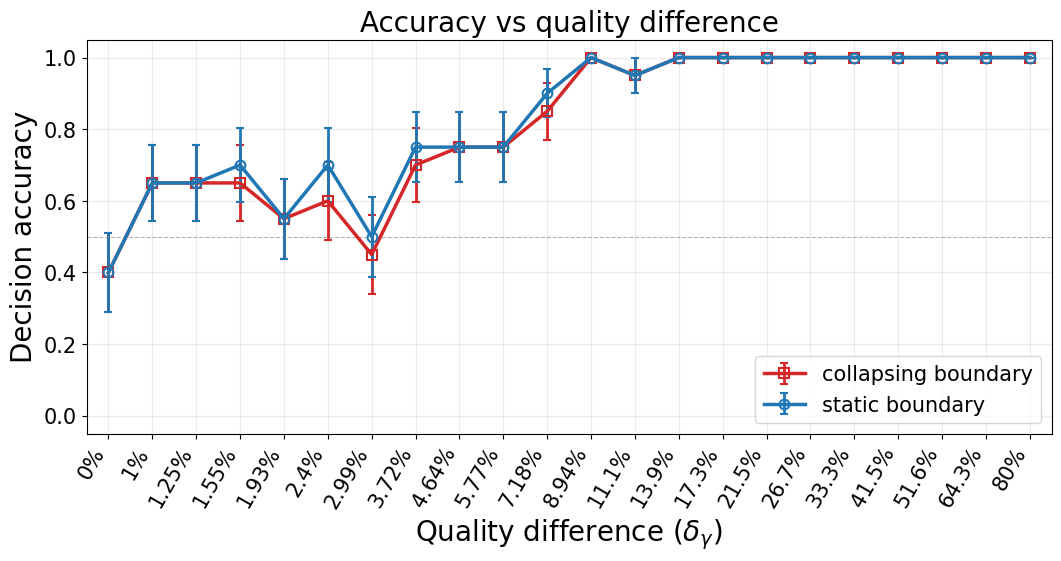

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10.5, 5.5), constrained_layout=True)
xs = np.arange(len(deltas))

for mode in sorted(summary):
    style = MODE_STYLE.get(mode, dict(color="0.4", marker="^", label=mode))
    acc = np.array([summary[mode][d]["accuracy"] for d in deltas])
    se = np.array([summary[mode][d]["acc_se"] for d in deltas])
    ax.errorbar(xs, acc, yerr=se, linewidth=2.5, markersize=7,
                markerfacecolor="none", markeredgewidth=1.5,
                capsize=3, capthick=2, elinewidth=2, **style)

ax.set_xticks(xs)
ax.set_xticklabels([f"{d:.3g}%" for d in deltas], fontsize=8, rotation=60, ha="right")
ax.set_xlim(-0.5, len(deltas) - 0.5)
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xlabel("Quality difference ($\\delta_{\\gamma}$)", fontsize=20)
ax.set_ylabel("Decision accuracy", fontsize=20)
ax.set_title("Accuracy vs quality difference", fontsize=20)
ax.tick_params(axis="both", labelsize=15)
ax.grid(True, alpha=0.25)
ax.legend(loc="lower right", fontsize=15)
plt.show()

## 2. Decision time vs quality difference — the chronometric curve

Mean time from evidence onset to commitment. Error bars are standard errors of the mean.

Expect this to be **non-monotonic**: under `terminal_categorical` the optimal boundary
`z*` is non-monotonic in the drift, rising to a peak and falling again, so decision time
peaks at intermediate difficulty rather than decreasing throughout. The collapsing regime
should sit at or below the static one, since a descending boundary can only meet the
evidence earlier.

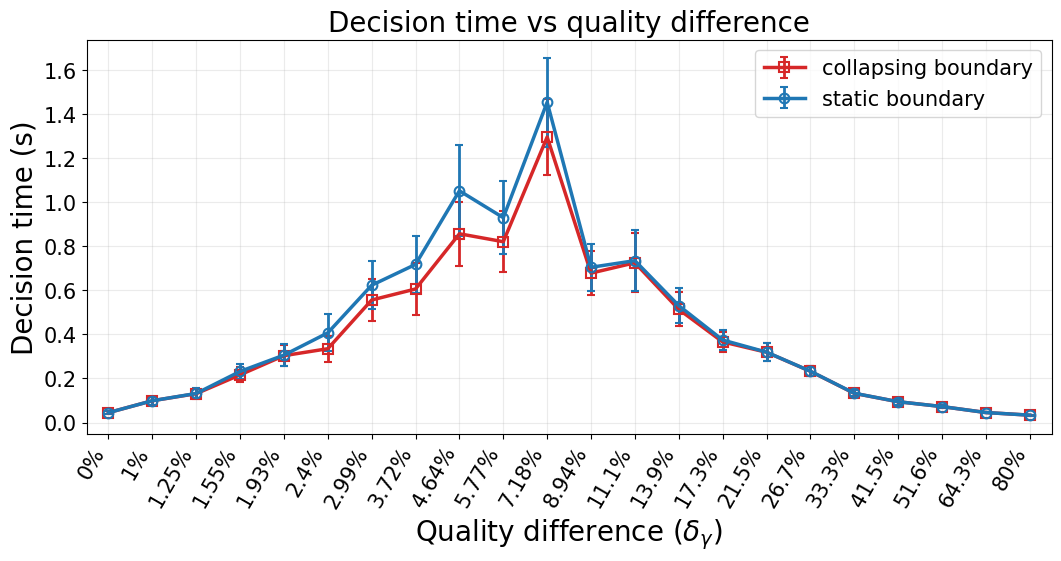

In [28]:
fig, ax = plt.subplots(figsize=(10.5, 5.5), constrained_layout=True)

for mode in sorted(summary):
    style = MODE_STYLE.get(mode, dict(color="0.4", marker="^", label=mode))
    dt = np.array([summary[mode][d]["dt_mean"] for d in deltas])
    se = np.array([summary[mode][d]["dt_se"] for d in deltas])
    ax.errorbar(xs, dt, yerr=se, linewidth=2.5, markersize=7,
                markerfacecolor="none", markeredgewidth=1.5,
                capsize=3, capthick=2, elinewidth=2, **style)

ax.set_xticks(xs)
ax.set_xticklabels([f"{d:.3g}%" for d in deltas], fontsize=8, rotation=60, ha="right")
ax.set_xlim(-0.5, len(deltas) - 0.5)
ax.set_xlabel("Quality difference ($\\delta_{\\gamma}$)", fontsize=20)
ax.set_ylabel("Decision time (s)", fontsize=20)
ax.set_title("Decision time vs quality difference", fontsize=20)
ax.tick_params(axis="both", labelsize=15)
ax.grid(True, alpha=0.25)
ax.legend(loc="best", fontsize=15)
plt.show()

## 3. What the boundary actually did

A direct check that the two treatments differ only in the intended way. `z*` at evidence
onset should coincide between the regimes at every `δ` (solid lines overlapping); the
boundary **at commitment** should be identical to it under `static` and strictly below it
under `collapsing` (dashed).

If the solid lines do not overlap, the two treatments were not calibrated to the same
starting boundary and the comparison is not controlled.

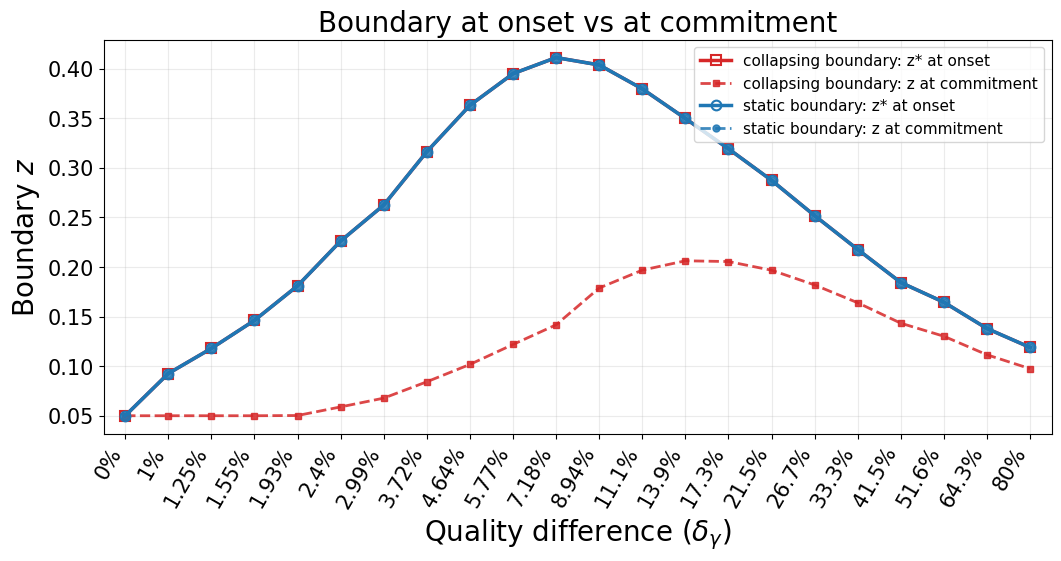

In [29]:
fig, ax = plt.subplots(figsize=(10.5, 5.5), constrained_layout=True)

for mode in sorted(summary):
    style = MODE_STYLE.get(mode, dict(color="0.4", marker="^", label=mode))
    z0 = np.array([summary[mode][d]["z_onset"] for d in deltas])
    z1 = np.array([summary[mode][d]["z_final"] for d in deltas])
    ax.plot(xs, z0, linewidth=2.5, markersize=7, markerfacecolor="none",
            markeredgewidth=1.5, label=f"{style['label']}: z* at onset",
            color=style["color"], marker=style["marker"])
    ax.plot(xs, z1, linewidth=2.0, linestyle="--", markersize=5, alpha=0.85,
            label=f"{style['label']}: z at commitment",
            color=style["color"], marker=style["marker"])

ax.set_xticks(xs)
ax.set_xticklabels([f"{d:.3g}%" for d in deltas], fontsize=8, rotation=60, ha="right")
ax.set_xlim(-0.5, len(deltas) - 0.5)
ax.set_xlabel("Quality difference ($\\delta_{\\gamma}$)", fontsize=20)
ax.set_ylabel("Boundary $z$", fontsize=20)
ax.set_title("Boundary at onset vs at commitment", fontsize=20)
ax.tick_params(axis="both", labelsize=15)
ax.grid(True, alpha=0.25)
ax.legend(loc="best", fontsize=11)
plt.show()

---
# Speed–accuracy trade-off curves

*From `run-pure-ddm-sat-curve-sweep.sh` — a different sweep from the cells above.*

The panels above vary **difficulty** (`δ`) at a fixed criterion, which gives psychometric
and chronometric curves. Decision time is **non-monotonic** in `δ`, so those points do not
form a trade-off curve — plotting them in the speed/accuracy plane produces a
self-crossing tangle rather than a frontier.

A speed–accuracy curve is by definition generated by varying the **decision criterion at
fixed difficulty**. Under the geometric policy that criterion is `cost_ratio`: `ρ` is
proportional to it, so sweeping it moves the boundary monotonically, error rate falls and
decision time rises.

At each `cost_ratio` both regimes start from the **same** `z*(onset)`, so they are matched
at the top of the trial and differ only in what the boundary does afterwards. The whole
comparison then reduces to one geometric question:

> **Does the collapsing curve lie ON, BELOW, or ABOVE the static curve?**
>
> - **on** — collapsing is only a *reparameterisation of caution*: it buys speed at the
>   cost of accuracy, but so would simply lowering `cost_ratio`. The collapse adds nothing.
> - **below** — collapsing is strictly worse. This is what Appendix C predicts for constant
>   costs, and what test V8 confirms in the frozen-geometry case.
> - **above** — collapsing genuinely dominates, meaning the embodied time-varying costs
>   justify it. The only outcome that vindicates the collapsing policy.

Layout consumed:

```
<base>/<static|collapsing>/delta_<pct>pct/cost_<cr>/replicate_<n>/config_folder_0/run_*.zip
```

## SAT: configuration and loading

Seeds are derived from `(δ, cost_ratio, replicate)` and **not** from the boundary mode, so
matching trials in the two regimes see identical noise. That allows a paired comparison
(final panel) with far more power than comparing group means at n = 20.

In [30]:
from pathlib import Path
import csv, io, re, math, zipfile
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Output of run-pure-ddm-sat-curve-sweep.sh — set this to your run.
SAT_BASE = Path("/home/sindiso/Documents/PhD/ring-attractor/data/pure_ddm_sat_curve_20260820-181721")

SAT_STYLE = {
    "static":     dict(color="#1f77b4", marker="o", label="static boundary"),
    "collapsing": dict(color="#d62728", marker="s", label="collapsing boundary"),
}
SAT_BETTER_TARGET = "static_0.s#0"


def sat_read_run(run_zip):
    """One trial: correctness, decision time, and the boundary at onset/commitment."""
    with zipfile.ZipFile(run_zip) as zf:
        member = next((n for n in zf.namelist() if n.endswith("_ddm.csv")), None)
        if member is None:
            return None
        rows = list(csv.DictReader(io.TextIOWrapper(zf.open(member))))
    def f(v):
        try:
            return float(v)
        except (TypeError, ValueError):
            return None
    rows = [r for r in rows if (f(r.get("z")) or 0.0) > 0]
    if not rows:
        return None
    last = rows[-1]
    rt, committed = f(last.get("rt")), (last.get("committed_id") or "")
    if rt is None or not committed:
        return None                       # never committed within the time limit
    return {"correct": committed == SAT_BETTER_TARGET, "rt": rt,
            "z_onset": f(rows[0].get("z")), "z_final": f(last.get("z"))}


def sat_scan(base):
    """Returns ({(mode, delta_pct, cost_ratio): {replicate: trial}}, n_unresolved)."""
    out, unresolved = {}, 0
    for mode_dir in sorted(p for p in base.iterdir() if p.is_dir()):
        for delta_dir in sorted(mode_dir.glob("delta_*pct")):
            dm = re.search(r"delta_([\d.]+)pct", delta_dir.name)
            for cost_dir in sorted(delta_dir.glob("cost_*")):
                cm = re.search(r"cost_([\d.eE+-]+)", cost_dir.name)
                if not (dm and cm):
                    continue
                key = (mode_dir.name, round(float(dm.group(1)), 8), float(cm.group(1)))
                for rep_dir in sorted(cost_dir.glob("replicate_*")):
                    rep = int(rep_dir.name.split("_")[1])
                    for run_zip in sorted(rep_dir.glob("config_folder_0/run_*.zip")):
                        try:
                            rec = sat_read_run(run_zip)
                        except Exception:
                            continue
                        if rec is None:
                            unresolved += 1
                            continue
                        out.setdefault(key, {})[rep] = rec
    return out, unresolved


def sat_summarise(trials):
    n = len(trials)
    k = sum(t["correct"] for t in trials)
    p = k / n
    rts = np.array([t["rt"] for t in trials], dtype=float)
    return {"n": n, "accuracy": p, "er": 1 - p,
            "acc_se": math.sqrt(max(p * (1 - p), 0.0) / n),
            "dt_mean": float(rts.mean()),
            "dt_se": float(rts.std(ddof=1) / math.sqrt(n)) if n > 1 else 0.0,
            "z_onset": float(np.mean([t["z_onset"] for t in trials]))}


sat_trials, sat_unresolved = sat_scan(SAT_BASE)
sat_summary = {k: sat_summarise(list(v.values())) for k, v in sat_trials.items() if v}
sat_modes = sorted({k[0] for k in sat_summary})
sat_deltas = sorted({k[1] for k in sat_summary})
sat_costs = sorted({k[2] for k in sat_summary})

print(f"{sum(s['n'] for s in sat_summary.values())} trials | modes={sat_modes} | "
      f"deltas={sat_deltas} | cost_ratios={sat_costs}")
if sat_unresolved:
    print(f"{sat_unresolved} trial(s) never committed within the time limit (excluded)")

199994 trials | modes=['collapsing', 'static'] | deltas=[1.5499, 2.4022] | cost_ratios=[1.0, 1.68179, 2.82843, 4.75683, 8.0]
6 trial(s) never committed within the time limit (excluded)


## SAT panel 1 — the trade-off curves

Accuracy against decision time, with **one point per `cost_ratio`** and one panel per
difficulty. This is the frontier: moving along a curve trades speed for accuracy, and the
curve that sits **up and to the left** is the better policy.

Points are labelled with their `cost_ratio` so the direction of the sweep is visible —
low values (fast, inaccurate) at the bottom left, high values (slow, accurate) at the top
right. `cost_ratio = 1` is the interpretable operating point ("one error is worth one
second"); the rest of the curve shows where that choice sits on the frontier.

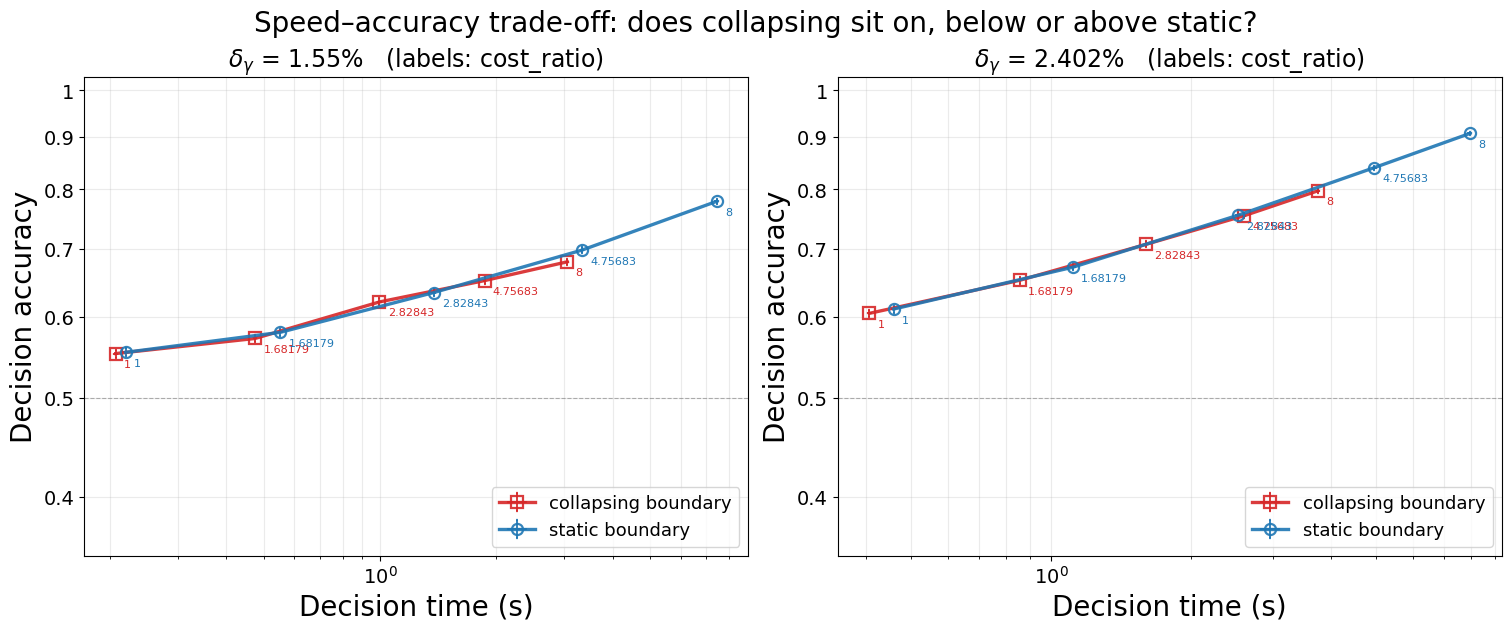

In [31]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, max(len(sat_deltas), 1),
                         figsize=(7.5 * max(len(sat_deltas), 1), 6.2),
                         constrained_layout=True, squeeze=False)

for j, dlt in enumerate(sat_deltas):
    ax = axes[0][j]
    for mode in sat_modes:
        style = SAT_STYLE.get(mode, dict(color="0.4", marker="^", label=mode))
        cs = [c for c in sat_costs if (mode, dlt, c) in sat_summary]
        dt = np.array([sat_summary[(mode, dlt, c)]["dt_mean"] for c in cs])
        acc = np.array([sat_summary[(mode, dlt, c)]["accuracy"] for c in cs])
        dse = np.array([sat_summary[(mode, dlt, c)]["dt_se"] for c in cs])
        ase = np.array([sat_summary[(mode, dlt, c)]["acc_se"] for c in cs])
        ax.errorbar(dt, acc, xerr=dse, yerr=ase, linewidth=2.4, markersize=8,
                    markerfacecolor="none", markeredgewidth=1.6, capsize=0.5,
                    elinewidth=1.4, alpha=0.9, **style)
        for c, x, y in zip(cs, dt, acc):
            ax.annotate(f"{c:g}", (x, y), textcoords="offset points",
                        xytext=(6, -10), fontsize=8, color=style["color"])
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.6)
    # Log on BOTH axes. The x axis gains a lot: decision time spans ~3 decades, so a
    # linear axis crushes every fast point against the origin.
    # The y axis gains nothing, because this panel plots ACCURACY: over 0.35-1.03 a log
    # scale spans only 0.47 decades, and it shrinks the informative 0.9-1.0 band from
    # ~15% to ~10% of the axis height. Panel 1b plots the ERROR RATE instead, which is
    # what actually expands that region.
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(0.35, 1.03)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax.set_xlabel("Decision time (s)", fontsize=20)
    ax.set_ylabel("Decision accuracy", fontsize=20)
    ax.set_title(f"$\\delta_{{\\gamma}}$ = {dlt:.4g}%   (labels: cost_ratio)", fontsize=17)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, alpha=0.25, which="both")
    ax.legend(loc="lower right", fontsize=13)

fig.suptitle("Speed–accuracy trade-off: does collapsing sit on, below or above static?",
             fontsize=20)
plt.show()

### SAT panel 1b — measured points against the closed-form curve

Is there a trend, or only noise? The static boundary has an analytic speed/accuracy
curve — for a frozen geometry, sweeping `cost_ratio` gives

```
rho = (A/c)^2 * cost_ratio / c_tau(Delta),   z* = a* c^2 / (2A)
ER  = 1/(1 + e^a),   DT = (c^2 / 2A^2) * a * tanh(a/2),   a = 2 A z* / c^2
```

so the whole curve can be drawn as a continuous line and the measurements laid on top.
Parameters are read from a saved run config, not hard-coded, so the line always matches
the sweep it is compared against.

**Axes are log–log.** Decision time spans ~3 decades and error rate ~2, so a linear axis
crushes the fast points near the origin and makes accuracy look flat once it exceeds 0.9
— which is exactly where the two regimes separate.

**Intervals are Wilson score, not `p ± SE`.** The Wald interval is badly behaved here: at
0/20 errors it has *zero width*, claiming infinite precision, and its lower limit dives
toward zero for small `p`, producing bars a full decade tall on a log axis. Wilson is
asymmetric, never degenerate, and stays inside [0, 1]. Cells with zero observed errors
are drawn at their **95% upper limit** with a downward triangle — read them as "the error
rate is below this", not as a measurement.

**A censored marker sitting inside the shaded band is NOT a dominance claim.** It is
drawn at its upper limit while its point estimate is 0, and zero observed errors cannot
be beaten on accuracy. Those cells are excluded from the test below; only the ringed
points are claims.

**The shaded region is dominated by the static frontier**: it is the set of points that
are simultaneously slower *and* less accurate than some static setting. Collapsing points
falling inside it are ringed in black. Dominance is a statement about matched *speed* —
comparing the two regimes at matched `cost_ratio` instead will always show a trade-off,
since a collapsing boundary is faster by construction.

How to read the rest:

- **Static points scattering around the line** → the trend is real and the raggedness is
  binomial noise (at n = 20 a cell carries an SE up to ±0.11, larger than the gap between
  neighbouring points).
- **Static points departing systematically** → something in the embodiment is not captured
  by the frozen-geometry theory. The mean residual reported below tests this.
- **Collapsing points** have no closed form, so the line is not their prediction. They sit
  to the *left* of it (faster, since a descending boundary is met sooner); whether they
  sit above or below is the dominance question.

theory parameters from saved config: c = 0.3536, Delta(onset) = 60.0 deg, z_min = 0.05


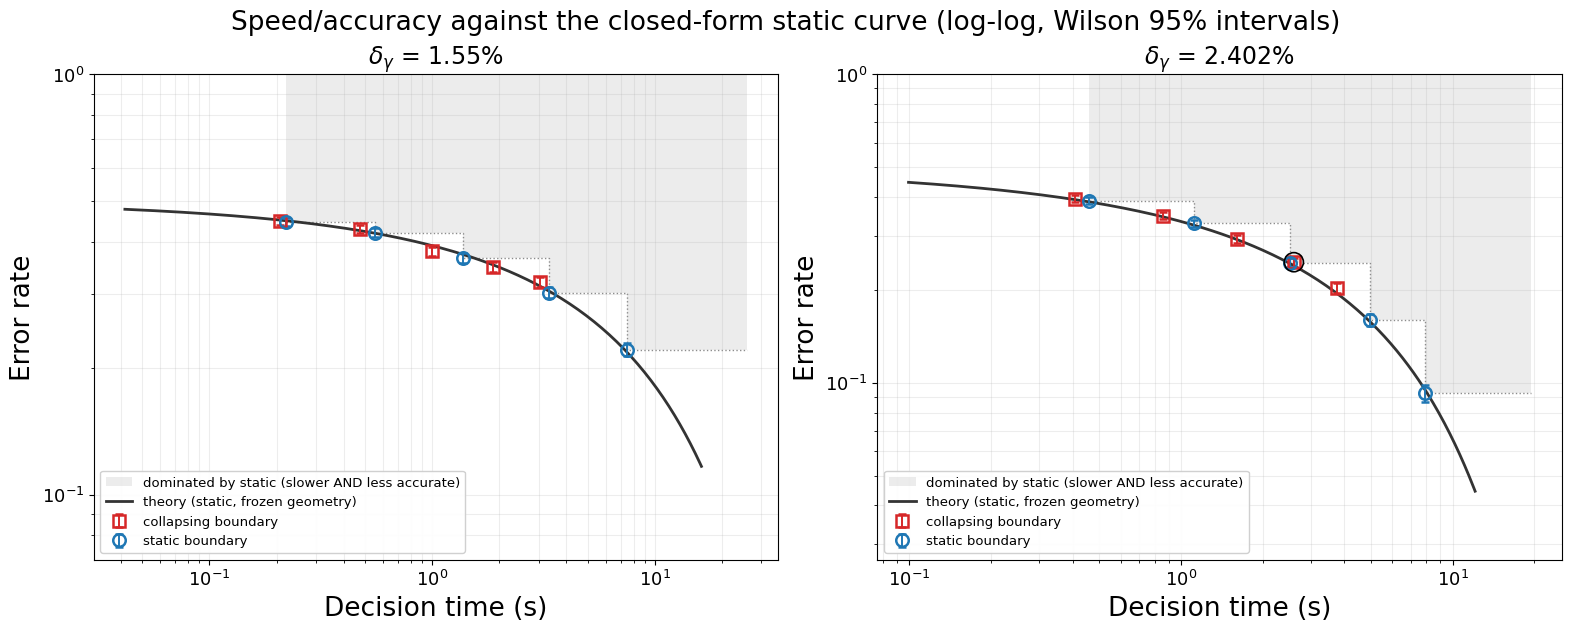


STRICT: a static setting that is BOTH faster AND more accurate
(ringed in black above; 'beaten by' is the most accurate such static point)

  delta%     CR      DT      ER    beaten by: DT      ER  speed-up
  2.4022 4.75683    2.60   0.246             2.52   0.245      1.0x

Strength of the evidence — non-overlap of the Wilson intervals is a strict
test and n = 20 per cell is unlikely to satisfy it; overlap here means the
pattern is suggestive, not established:
  delta=2.4022% CR=4.75683: static upper 0.254 vs collapsing lower 0.238  ->  overlapping

0 of 1 survive the strict non-overlap test

  delta%  cost_ratio   ER obs  ER theory   null SE  residual/SE
  1.5499           1    0.446      0.455     0.005        -1.87
  1.5499     1.68179    0.420      0.426     0.005        -1.06
  1.5499     2.82843    0.366      0.378     0.005        -2.52
  1.5499     4.75683    0.302      0.308     0.005        -1.30
  1.5499           8    0.221      0.222     0.004        -0.10
  2.4022      

In [32]:
import sys, json
sys.path.insert(0, str(Path.cwd() / "src"))
from models.ddm_systems import DriftDiffusionSystem as _D


def wilson_ci(k, n, z=1.96):
    """Score interval for a binomial proportion.

    Preferred over the Wald interval p +- sqrt(p(1-p)/n) used elsewhere: Wald has
    ZERO WIDTH at k = 0 (claiming infinite precision from zero errors), and its lower
    limit dives toward 0 for small p, which on a log axis produces bars a decade tall.
    Wilson is asymmetric, never degenerate, and stays inside [0, 1].
    """
    if n == 0:
        return 0.0, 1.0
    p, den = k / n, 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(centre - half, 0.0), min(centre + half, 1.0)


def sat_errors(mode, dlt, cr):
    """(k errors, n trials) for one cell, taken straight from the trial records."""
    tr = list(sat_trials.get((mode, dlt, cr), {}).values())
    return sum(not t["correct"] for t in tr), len(tr)


def sat_theory_params(base):
    """Read (c, delta, z_min) from any saved run config under `base`."""
    cfg = next(base.glob("*/delta_*pct/cost_*/replicate_*/config_folder_0/config.json"))
    env = json.loads(cfg.read_text())["data"]["environment"]
    ag = env["agents"]["movable_0"]
    blk = ag["embodied_pure_ddm"]
    eta = np.asarray(blk["eta_rate"], dtype=float)
    c = float(np.sqrt((eta ** 2).sum()))
    ax_, ay_, _ = ag["position"][0]
    pos = {k: env["objects"][k]["position"][0] for k in ("static_0", "static_1")}
    ang = {k: math.atan2(-(v[1] - ay_), v[0] - ax_) for k, v in pos.items()}
    d = abs((ang["static_0"] - ang["static_1"] + math.pi) % (2 * math.pi) - math.pi)
    return c, d, float(blk.get("z_min", 0.05))


def sat_theory_curve(A, c, delta, z_min, cost_ratios):
    """Closed-form (DT, ER) for the STATIC boundary at each cost_ratio."""
    dts, ers = [], []
    for cr in cost_ratios:
        z = max(_D.solve_threshold_geometric(A, c, delta, cost_ratio=float(cr),
                                             mode="terminal_categorical"), z_min)
        a = 2 * A * z / c ** 2
        ers.append(_D.er_from_a(a))
        dts.append(_D.dt_from_a(a, A, c))
    return np.array(dts), np.array(ers)


def sat_plot_points(mode, dlt):
    """Plot-ready arrays for one (mode, delta): decision time, the y value actually
    drawn, its Wilson limits, and which cells are censored (zero errors).

    A censored cell is drawn AT its 95% upper limit, which is the honest statement
    'the error rate is below this'. (The earlier 1/(2n) convention understated it:
    0/20 gives a Wilson upper limit of 0.161, not 0.025.) That is a PLOTTING device
    only — `er`, the point estimate k/n, is what the dominance test uses.
    """
    cs = [c for c in sat_costs if (mode, dlt, c) in sat_summary]
    dt = np.array([sat_summary[(mode, dlt, c)]["dt_mean"] for c in cs])
    kn = [sat_errors(mode, dlt, c) for c in cs]
    ci = np.array([wilson_ci(k, n) for k, n in kn])
    er = np.array([k / n for k, n in kn])
    cens = np.array([k == 0 for k, _ in kn])
    y = np.where(cens, ci[:, 1], er)
    return np.array(cs), dt, y, ci[:, 0], ci[:, 1], cens, er


c_th, delta_th, z_min_th = sat_theory_params(SAT_BASE)
print(f"theory parameters from saved config: c = {c_th:.4f}, "
      f"Delta(onset) = {math.degrees(delta_th):.1f} deg, z_min = {z_min_th}")

fig, axes = plt.subplots(1, max(len(sat_deltas), 1),
                         figsize=(7.8 * max(len(sat_deltas), 1), 6.2),
                         constrained_layout=True, squeeze=False)
dominated_rows = []

for j, dlt in enumerate(sat_deltas):
    ax = axes[0][j]
    A_th = 5.0 * dlt / 100.0                      # static_0 is fixed at 5.0

    dense = np.logspace(np.log10(min(sat_costs) / 2), np.log10(max(sat_costs) * 2), 200)
    dt_th, er_th = sat_theory_curve(A_th, c_th, delta_th, z_min_th, dense)

    drawn = {m: sat_plot_points(m, dlt) for m in sat_modes}
    all_lo = np.concatenate([d[3] for d in drawn.values()] + [er_th])
    y_bot = max(float(np.min(all_lo[all_lo > 0])) * 0.6, 1e-3)
    ax.set_ylim(y_bot, 1.0)

    # --- region dominated by the static frontier -----------------------------
    # A point is dominated if some static setting is BOTH no slower and no less
    # accurate. Taking the running minimum of the static error rate in order of
    # increasing decision time gives that frontier as a staircase; everything above
    # and to its right is dominated. Built from point estimates (censored cells
    # enter at their 95% upper limit, so the shading is conservative for them).
    if "static" in drawn:
        _, dt_s, y_s, _, _, _, _ = drawn["static"]
        o = np.argsort(dt_s)
        dts, env = dt_s[o], np.minimum.accumulate(y_s[o])
        xs = np.append(dts, max(dt_th.max(), dt_s.max()) * 1.6)
        ax.fill_between(xs, np.append(env, env[-1]), 1.0, step="post",
                        color="0.55", alpha=0.16, linewidth=0, zorder=0,
                        label="dominated by static (slower AND less accurate)")
        ax.step(xs, np.append(env, env[-1]), where="post", color="0.55",
                linewidth=1.0, linestyle=":", zorder=1)

    ax.plot(dt_th, er_th, color="0.2", linewidth=2.0, zorder=2,
            label="theory (static, frozen geometry)")

    for mode in sat_modes:
        style = dict(SAT_STYLE.get(mode, dict(color="0.4", marker="^", label=mode)))
        cs, dt, y, lo, hi, cens, er = drawn[mode]
        m = ~cens
        ax.errorbar(dt[m], y[m], yerr=[y[m] - lo[m], hi[m] - y[m]],
                    linestyle="none", markersize=9, markerfacecolor="none",
                    markeredgewidth=1.8, capsize=3, elinewidth=1.4, zorder=4, **style)
        if cens.any():
            ax.scatter(dt[cens], y[cens], marker="v", s=70, facecolors="none",
                       edgecolors=style["color"], linewidths=1.5, zorder=4,
                       label=f"{style['label']}: 0 errors (95% upper limit)")

        # Which collapsing points does the static frontier beat on BOTH axes?
        # The test runs on POINT ESTIMATES (k/n), never on the plotted position: a
        # censored cell is drawn at its upper limit, and comparing that against
        # another cell's estimate would manufacture dominance out of the convention.
        # A cell with zero observed errors is simply excluded — nothing can be said
        # to be more accurate than an error rate we have not resolved.
        if mode == "collapsing" and "static" in drawn:
            _, dt_s, y_s, _, _, _, _ = drawn["static"]
            for cr, x, e_c, is_cens in zip(cs, dt, er, cens):
                if is_cens:
                    continue
                faster = [(ds, ys) for ds, ys in zip(dt_s, y_s) if ds < x]
                strict = [w for w in faster if w[1] < e_c]
                tied = [w for w in faster if w[1] == e_c]
                if strict:
                    ds, ys = min(strict, key=lambda w: w[1])
                    ax.scatter([x], [e_c], marker="o", s=190, facecolors="none",
                               edgecolors="black", linewidths=1.2, zorder=5)
                    dominated_rows.append(("strict", dlt, cr, x, e_c, ds, ys))
                elif tied:
                    ds, ys = min(tied, key=lambda w: w[0])
                    dominated_rows.append(("tie", dlt, cr, x, e_c, ds, ys))

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Decision time (s)", fontsize=19)
    ax.set_ylabel("Error rate", fontsize=19)
    ax.set_title(f"$\\delta_{{\\gamma}}$ = {dlt:.4g}%", fontsize=17)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, alpha=0.22, which="both")
    ax.legend(loc="lower left", fontsize=9.5, framealpha=0.92)

fig.suptitle("Speed/accuracy against the closed-form static curve "
             "(log-log, Wilson 95% intervals)", fontsize=19)
plt.show()

# --- dominance ---------------------------------------------------------------
strict_rows = [r for r in dominated_rows if r[0] == "strict"]
tie_rows = [r for r in dominated_rows if r[0] == "tie"]

print("\nSTRICT: a static setting that is BOTH faster AND more accurate")
print("(ringed in black above; 'beaten by' is the most accurate such static point)\n")
if strict_rows:
    print(f"{'delta%':>8} {'CR':>6} {'DT':>7} {'ER':>7}   {'beaten by: DT':>14} {'ER':>7}"
          f" {'speed-up':>9}")
    for _, dlt, cr, x, yy, ds, ys in strict_rows:
        print(f"{dlt:>8.4f} {cr:>6g} {x:>7.2f} {yy:>7.3f}   {ds:>14.2f} {ys:>7.3f}"
              f" {x / ds:>8.1f}x")
else:
    print("  none")

if tie_rows:
    print("\nTIED on accuracy, static faster (weak dominance only):")
    for _, dlt, cr, x, yy, ds, ys in tie_rows:
        print(f"  delta={dlt:.4f}% CR={cr:g}: both ER={yy:.3f}, "
              f"static {ds:.2f}s vs collapsing {x:.2f}s ({x / ds:.1f}x faster)")

print("\nStrength of the evidence — non-overlap of the Wilson intervals is a strict\n"
      "test and n = 20 per cell is unlikely to satisfy it; overlap here means the\n"
      "pattern is suggestive, not established:")
n_strict = 0
for _, dlt, cr, x, yy, ds, ys in strict_rows:
    kc, nc = sat_errors("collapsing", dlt, cr)
    lo_c, _ = wilson_ci(kc, nc)
    cs_s, dt_s, y_s, _, hi_s, _, _ = sat_plot_points("static", dlt)
    hi_best = min(h for d_, h in zip(dt_s, hi_s) if d_ <= x)
    strict = hi_best < lo_c
    n_strict += strict
    print(f"  delta={dlt:.4f}% CR={cr:g}: static upper {hi_best:.3f} vs collapsing "
          f"lower {lo_c:.3f}  ->  {'SEPARATED' if strict else 'overlapping'}")
print(f"\n{n_strict} of {len(strict_rows)} survive the strict non-overlap test")

# --- goodness of fit ---------------------------------------------------------
# Residual divided by the NULL SE sqrt(p_th(1-p_th)/n), not the observed SE: under
# "theory is correct" that is the right yardstick, and unlike the observed SE it
# stays finite when a cell records zero errors.
print(f"\n{'delta%':>8} {'cost_ratio':>11} {'ER obs':>8} {'ER theory':>10} "
      f"{'null SE':>9} {'residual/SE':>12}")
resids = []
for dlt in sat_deltas:
    A_th = 5.0 * dlt / 100.0
    for cr in sat_costs:
        s = sat_summary.get(("static", dlt, cr))
        if s is None:
            continue
        _, er_t = sat_theory_curve(A_th, c_th, delta_th, z_min_th, [cr])
        p_th = float(er_t[0])
        se0 = math.sqrt(max(p_th * (1 - p_th), 0.0) / s["n"])
        r = (s["er"] - p_th) / se0 if se0 > 0 else float("nan")
        resids.append(r)
        print(f"{dlt:>8.4f} {cr:>11g} {s['er']:>8.3f} {p_th:>10.3f} "
              f"{se0:>9.3f} {r:>12.2f}")

good = [r for r in resids if r == r]
n_out = sum(abs(r) > 2 for r in good)
print(f"\n{n_out} of {len(good)} static points lie beyond 2 null SE "
      f"(~{0.045 * len(good):.1f} expected by chance if the theory is exact)")
print(f"mean residual = {np.mean(good):+.2f} SE  (a consistently negative mean would "
      f"mean the\nagent beats the frozen-geometry prediction, as approaching the "
      f"targets raises the\nperceived strengths and so grows the drift during the trial)")

### SAT panel 1c — the same comparison in accuracy space

Panel 1b plots the **error rate** on a log axis, which is the right choice for resolving
the high-accuracy end but is not the conventional way to show a speed/accuracy trade-off.
This panel is the conventional view — **accuracy against decision time**, with the same
closed-form static curve drawn through it:

```
accuracy(cost_ratio) = 1 - ER = 1 - 1/(1 + e^a),   DT = (c^2 / 2A^2) * a * tanh(a/2)
```

Nothing here is a new measurement; it is panel 1b's data re-expressed, so the two should
be read together. Three differences worth knowing:

- **No censoring.** A cell with zero errors has accuracy 1.0, which is an ordinary value
  on a linear axis — so every point is a real measurement here, with no upper-bound
  markers and none of panel 1b's caveats about them.
- **The y axis is linear, the x axis log.** Accuracy spans well under a decade, so a log
  y axis buys nothing (see the note in panel 1's code); decision time spans three, so a
  linear x axis would crush every fast point against the origin.
- **Intervals are still Wilson**, now computed on the success count. They are asymmetric
  and, at accuracy 1.0, extend downward only — which is the honest shape: 20/20 is
  consistent with a true accuracy as low as ~0.84 at n = 20.

The reading rule is unchanged: the curve sitting **up and to the left** is the better
policy, and the theory line is the static prediction only — collapsing has no closed form,
so its departure from the line is the effect, not an error.

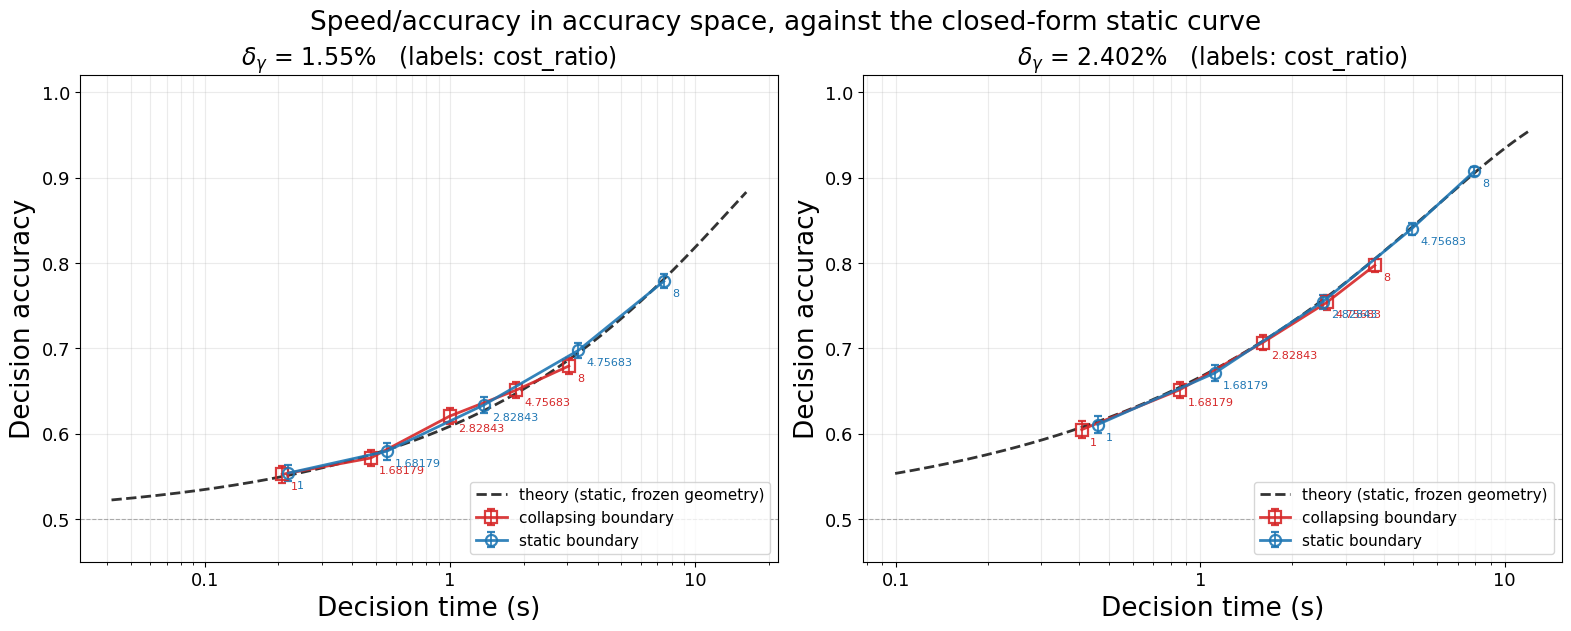

  delta%  cost_ratio  theory acc  static obs  collapsing obs
  1.5499           1       0.545       0.554           0.552
  1.5499     1.68179       0.574       0.580           0.572
  1.5499     2.82843       0.622       0.634           0.621
  1.5499     4.75683       0.692       0.698           0.651
  1.5499           8       0.778       0.779           0.679
  2.4022           1       0.605       0.611           0.605
  2.4022     1.68179       0.667       0.671           0.652
  2.4022     2.82843       0.750       0.755           0.707
  2.4022     4.75683       0.837       0.840           0.754
  2.4022           8       0.904       0.908           0.797


In [33]:
# Self-contained: re-derives its own helpers so the cell can be run on its own.
import sys, json
import matplotlib.ticker as mticker
sys.path.insert(0, str(Path.cwd() / "src"))
from models.ddm_systems import DriftDiffusionSystem as _Dacc


def _wilson(k, n, z=1.96):
    """Score interval for k/n. Asymmetric, and never zero-width at k = 0 or k = n."""
    if n == 0:
        return 0.0, 1.0
    p, den = k / n, 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(centre - half, 0.0), min(centre + half, 1.0)


def _acc_params(base):
    """(c, Delta at onset, z_min) read from a saved run config under `base`."""
    cfg = next(base.glob("*/delta_*pct/cost_*/replicate_*/config_folder_0/config.json"))
    env = json.loads(cfg.read_text())["data"]["environment"]
    ag = env["agents"]["movable_0"]
    blk = ag["embodied_pure_ddm"]
    eta = np.asarray(blk["eta_rate"], dtype=float)
    ax_, ay_, _ = ag["position"][0]
    pos = {k: env["objects"][k]["position"][0] for k in ("static_0", "static_1")}
    ang = {k: math.atan2(-(v[1] - ay_), v[0] - ax_) for k, v in pos.items()}
    d = abs((ang["static_0"] - ang["static_1"] + math.pi) % (2 * math.pi) - math.pi)
    return float(np.sqrt((eta ** 2).sum())), d, float(blk.get("z_min", 0.05))


def _acc_curve(A, c, delta, z_min, cost_ratios):
    """Closed-form (DT, accuracy) for the STATIC boundary at each cost_ratio."""
    dts, accs = [], []
    for cr in cost_ratios:
        z = max(_Dacc.solve_threshold_geometric(A, c, delta, cost_ratio=float(cr),
                                                mode="terminal_categorical"), z_min)
        a = 2 * A * z / c ** 2
        accs.append(1.0 - _Dacc.er_from_a(a))
        dts.append(_Dacc.dt_from_a(a, A, c))
    return np.array(dts), np.array(accs)


c_a, delta_a, z_min_a = _acc_params(SAT_BASE)

fig, axes = plt.subplots(1, max(len(sat_deltas), 1),
                         figsize=(7.8 * max(len(sat_deltas), 1), 6.2),
                         constrained_layout=True, squeeze=False)

for j, dlt in enumerate(sat_deltas):
    ax = axes[0][j]
    A_a = 5.0 * dlt / 100.0                       # static_0 is fixed at 5.0

    dense = np.logspace(np.log10(min(sat_costs) / 2), np.log10(max(sat_costs) * 2), 200)
    dt_a, acc_a = _acc_curve(A_a, c_a, delta_a, z_min_a, dense)
    ax.plot(dt_a, acc_a, color="0.2", linewidth=2.0, zorder=2, ls="--",
            label="theory (static, frozen geometry)")

    lowest = [acc_a.min()]
    for mode in sat_modes:
        style = dict(SAT_STYLE.get(mode, dict(color="0.4", marker="^", label=mode)))
        cs = [c for c in sat_costs if (mode, dlt, c) in sat_summary]
        dt = np.array([sat_summary[(mode, dlt, c)]["dt_mean"] for c in cs])
        # Wilson on the SUCCESS count; at 20/20 the interval extends downward only,
        # which is the honest shape — no upper-bound markers are needed in accuracy
        # space because 1.0 is an ordinary value on a linear axis.
        kn = [(sum(t["correct"] for t in sat_trials[(mode, dlt, c)].values()),
               len(sat_trials[(mode, dlt, c)])) for c in cs]
        acc = np.array([k / n for k, n in kn])
        ci = np.array([_wilson(k, n) for k, n in kn])
        lowest.append(ci[:, 0].min())
        ax.errorbar(dt, acc, yerr=[acc - ci[:, 0], ci[:, 1] - acc],
                    linewidth=2.0, markersize=8, markerfacecolor="none",
                    markeredgewidth=1.6, capsize=3, elinewidth=1.3,
                    alpha=0.9, zorder=3, **style)
        for c, x, y in zip(cs, dt, acc):
            ax.annotate(f"{c:g}", (x, y), textcoords="offset points",
                        xytext=(6, -11), fontsize=8, color=style["color"])

    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax.set_xscale("log")
    ax.set_ylim(min(min(lowest) - 0.04, 0.45), 1.02)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.set_xlabel("Decision time (s)", fontsize=19)
    ax.set_ylabel("Decision accuracy", fontsize=19)
    ax.set_title(f"$\\delta_{{\\gamma}}$ = {dlt:.4g}%   (labels: cost_ratio)", fontsize=17)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, alpha=0.25, which="both")
    ax.legend(loc="lower right", fontsize=11)

fig.suptitle("Speed/accuracy in accuracy space, against the closed-form static curve",
             fontsize=19)
plt.show()

# Vertical distance from the static prediction, in accuracy units.
print(f"{'delta%':>8} {'cost_ratio':>11} {'theory acc':>11} "
      f"{'static obs':>11} {'collapsing obs':>15}")
for dlt in sat_deltas:
    A_a = 5.0 * dlt / 100.0
    for cr in sat_costs:
        _, acc_t = _acc_curve(A_a, c_a, delta_a, z_min_a, [cr])
        s = sat_summary.get(("static", dlt, cr))
        c_ = sat_summary.get(("collapsing", dlt, cr))
        if s is None or c_ is None:
            continue
        print(f"{dlt:>8.4f} {cr:>11g} {acc_t[0]:>11.3f} "
              f"{s['accuracy']:>11.3f} {c_['accuracy']:>15.3f}")

## SAT panel 2 — dominance at matched speed

The curves in panel 1 can be hard to separate by eye. Here the collapsing curve is
interpolated onto the static curve's decision-time grid and the **difference in accuracy**
is plotted directly.

Read it as: *at the same decision time, how much more accurate is the static boundary?*

- **above zero** — static dominates (collapsing is paying accuracy for nothing)
- **at zero** — the two lie on the same frontier; collapse is just re-parameterised caution
- **below zero** — collapsing dominates

The shaded band is the propagated standard error of the difference.

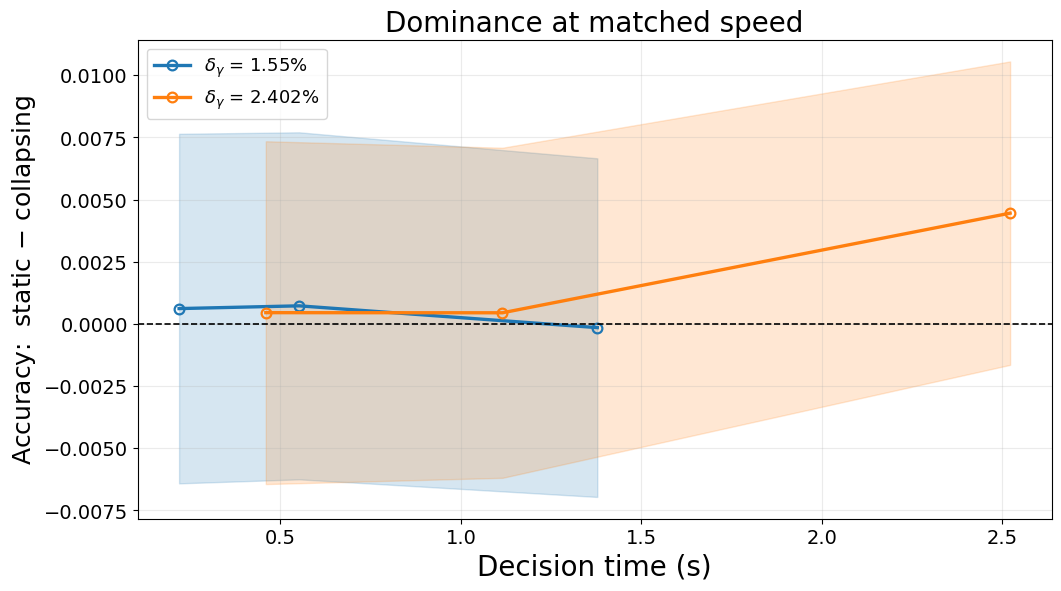

In [34]:
fig, ax = plt.subplots(figsize=(10.5, 5.8), constrained_layout=True)

for dlt in sat_deltas:
    cs_s = [c for c in sat_costs if ("static", dlt, c) in sat_summary]
    cs_c = [c for c in sat_costs if ("collapsing", dlt, c) in sat_summary]
    if not cs_s or not cs_c:
        continue
    dt_s = np.array([sat_summary[("static", dlt, c)]["dt_mean"] for c in cs_s])
    acc_s = np.array([sat_summary[("static", dlt, c)]["accuracy"] for c in cs_s])
    se_s = np.array([sat_summary[("static", dlt, c)]["acc_se"] for c in cs_s])
    dt_c = np.array([sat_summary[("collapsing", dlt, c)]["dt_mean"] for c in cs_c])
    acc_c = np.array([sat_summary[("collapsing", dlt, c)]["accuracy"] for c in cs_c])
    se_c = np.array([sat_summary[("collapsing", dlt, c)]["acc_se"] for c in cs_c])

    order = np.argsort(dt_c)
    # only compare inside the overlapping decision-time range: extrapolating a frontier
    # would invent dominance where no collapsing run of that speed exists
    lo, hi = max(dt_s.min(), dt_c.min()), min(dt_s.max(), dt_c.max())
    keep = (dt_s >= lo) & (dt_s <= hi)
    if keep.sum() < 2:
        continue
    acc_c_at_s = np.interp(dt_s[keep], dt_c[order], acc_c[order])
    se_c_at_s = np.interp(dt_s[keep], dt_c[order], se_c[order])
    diff = acc_s[keep] - acc_c_at_s
    dse = np.sqrt(se_s[keep] ** 2 + se_c_at_s ** 2)

    line, = ax.plot(dt_s[keep], diff, marker="o", linewidth=2.4, markersize=7,
                    markerfacecolor="none", markeredgewidth=1.6,
                    label=f"$\\delta_{{\\gamma}}$ = {dlt:.4g}%")
    ax.fill_between(dt_s[keep], diff - dse, diff + dse, alpha=0.18, color=line.get_color())

ax.axhline(0.0, color="black", lw=1.2, ls="--")
ax.set_xlabel("Decision time (s)", fontsize=20)
ax.set_ylabel("Accuracy:  static $-$ collapsing", fontsize=18)
ax.set_title("Dominance at matched speed", fontsize=20)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True, alpha=0.25)
ax.legend(loc="best", fontsize=13)
plt.show()

## SAT panel 3 — Bayes risk, the scalar the theory optimises

`BR = c_τ·DT + c_e·ER` is what the threshold policy is derived to minimise, so it collapses
the 2-D comparison into one number per operating point. Using the sweep's own cost
structure (`c_e/c_τ = cost_ratio`, hence `BR/c_τ = DT + cost_ratio·ER`), the mode reaching
the **lower minimum** wins outright.

This is the embodied counterpart of test V8, which shows analytically that under constant
costs a constant boundary is optimal and any collapse strictly increases Bayes risk. If
that carries over here, the static curve should sit below the collapsing one at its
minimum. If it does not, the embodied time-varying costs are doing something the
frozen-geometry theory does not capture.

delta=  1.5499%  collapsing  min BR =   0.655 s at cost_ratio = 1
delta=  1.5499%  static      min BR =   0.665 s at cost_ratio = 1
delta=  2.4022%  collapsing  min BR =   0.803 s at cost_ratio = 1
delta=  2.4022%  static      min BR =   0.849 s at cost_ratio = 1


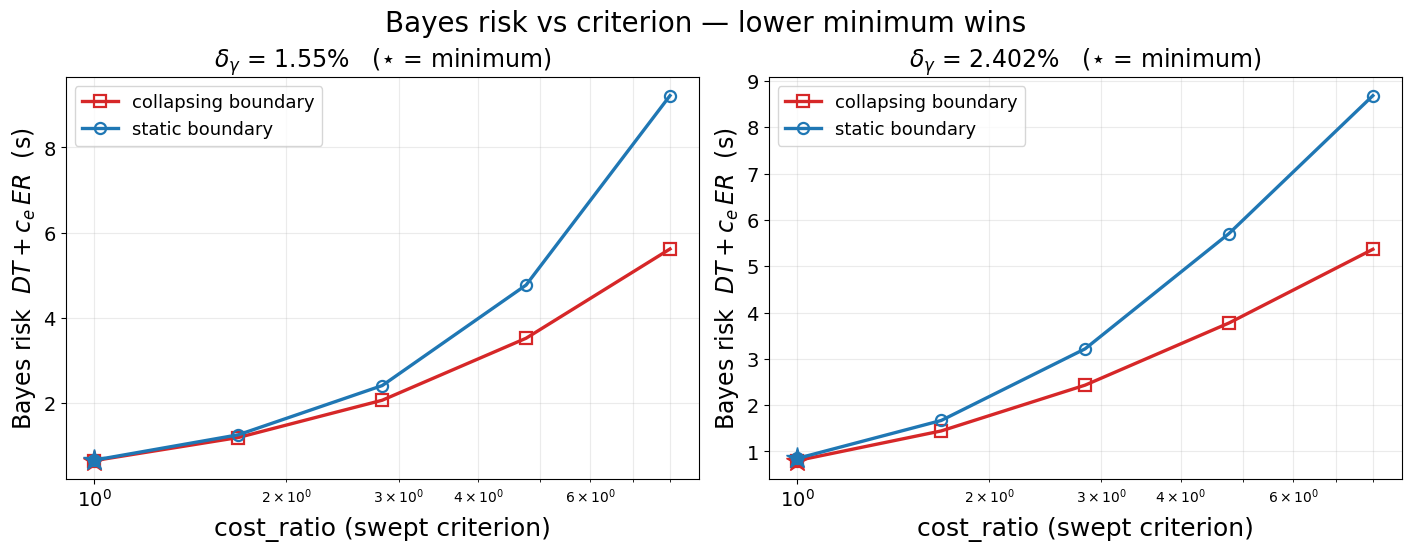

In [35]:
fig, axes = plt.subplots(1, max(len(sat_deltas), 1),
                         figsize=(7.0 * max(len(sat_deltas), 1), 5.4),
                         constrained_layout=True, squeeze=False)

for j, dlt in enumerate(sat_deltas):
    ax = axes[0][j]
    for mode in sat_modes:
        style = SAT_STYLE.get(mode, dict(color="0.4", marker="^", label=mode))
        cs = [c for c in sat_costs if (mode, dlt, c) in sat_summary]
        br = [sat_summary[(mode, dlt, c)]["dt_mean"] + c * sat_summary[(mode, dlt, c)]["er"]
              for c in cs]
        ax.plot(cs, br, linewidth=2.4, markersize=8, markerfacecolor="none",
                markeredgewidth=1.6, **style)
        best = int(np.argmin(br))
        ax.plot([cs[best]], [br[best]], marker="*", markersize=16,
                color=style["color"], linestyle="none")
        print(f"delta={dlt:>8.4f}%  {mode:<11} min BR = {br[best]:7.3f} s "
              f"at cost_ratio = {cs[best]:g}")
    ax.set_xscale("log")
    ax.set_xlabel("cost_ratio (swept criterion)", fontsize=18)
    ax.set_ylabel("Bayes risk  $DT + c_e\\,ER$  (s)", fontsize=17)
    ax.set_title(f"$\\delta_{{\\gamma}}$ = {dlt:.4g}%   ($\\star$ = minimum)", fontsize=17)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, alpha=0.25, which="both")
    ax.legend(loc="best", fontsize=13)

fig.suptitle("Bayes risk vs criterion — lower minimum wins", fontsize=20)
plt.show()

## SAT panel 4 — the paired comparison

Seeds are matched across boundary modes, so each `(δ, cost_ratio, replicate)` gives a
**pair** of trials differing only in the boundary policy. Comparing pairs removes the
between-trial noise entirely and is far more powerful than comparing two error bars at
n = 20.

Reported per operating point:

- **ΔRT** — mean paired difference in decision time (collapsing minus static). Negative
  means collapsing commits earlier, which it must, since a descending boundary can only
  meet the evidence sooner.
- **flip rate** — the fraction of pairs where the two policies chose *differently* on
  identical noise. This is the cleanest measure of how much the boundary policy actually
  changes behaviour, as opposed to changing only timing.
- **cost of collapsing** — among the pairs that disagreed, how often the static boundary
  was the one that got it right.

  delta%  cost_ratio  pairs   dRT (s)  flip rate  static right | flips
  1.5499           1  10000    -0.012       0.01                78/141
  1.5499     1.68179  10000    -0.077       0.03               208/336
  1.5499     2.82843  10000    -0.382       0.08               449/765
  1.5499     4.75683  10000    -1.469       0.13              864/1264
  1.5499           8   9997    -4.392       0.18             1389/1786
  2.4022           1  10000    -0.052       0.03               186/313
  2.4022     1.68179  10000    -0.259       0.06               384/572
  2.4022     2.82843  10000    -0.920       0.10               720/962
  2.4022     4.75683  10000    -2.342       0.13             1079/1297
  2.4022           8   9997    -4.200       0.14             1231/1361


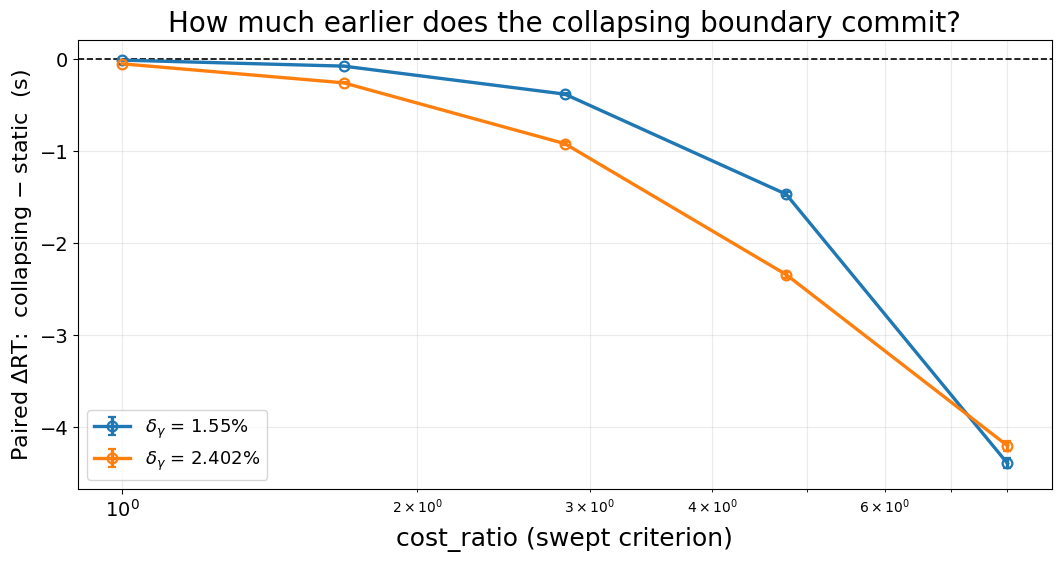

In [36]:
print(f"{'delta%':>8} {'cost_ratio':>11} {'pairs':>6} {'dRT (s)':>9} "
      f"{'flip rate':>10} {'static right | flips':>21}")
for dlt in sat_deltas:
    for c in sat_costs:
        a = sat_trials.get(("static", dlt, c), {})
        b = sat_trials.get(("collapsing", dlt, c), {})
        common = sorted(set(a) & set(b))
        if not common:
            continue
        d_rt = np.array([b[r]["rt"] - a[r]["rt"] for r in common])
        flips = [r for r in common if a[r]["correct"] != b[r]["correct"]]
        static_right = sum(1 for r in flips if a[r]["correct"])
        frac = f"{static_right}/{len(flips)}" if flips else "-"
        print(f"{dlt:>8.4f} {c:>11g} {len(common):>6} {d_rt.mean():>9.3f} "
              f"{len(flips)/len(common):>10.2f} {frac:>21}")

fig, ax = plt.subplots(figsize=(10.5, 5.5), constrained_layout=True)
for dlt in sat_deltas:
    cs, drt, dse = [], [], []
    for c in sat_costs:
        a = sat_trials.get(("static", dlt, c), {})
        b = sat_trials.get(("collapsing", dlt, c), {})
        common = sorted(set(a) & set(b))
        if len(common) < 2:
            continue
        d = np.array([b[r]["rt"] - a[r]["rt"] for r in common])
        cs.append(c); drt.append(d.mean()); dse.append(d.std(ddof=1) / math.sqrt(len(d)))
    if cs:
        ax.errorbar(cs, drt, yerr=dse, marker="o", linewidth=2.4, markersize=7,
                    markerfacecolor="none", markeredgewidth=1.6, capsize=3,
                    label=f"$\\delta_{{\\gamma}}$ = {dlt:.4g}%")
ax.axhline(0.0, color="black", lw=1.2, ls="--")
ax.set_xscale("log")
ax.set_xlabel("cost_ratio (swept criterion)", fontsize=18)
ax.set_ylabel("Paired $\\Delta$RT:  collapsing $-$ static  (s)", fontsize=16)
ax.set_title("How much earlier does the collapsing boundary commit?", fontsize=20)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True, alpha=0.25, which="both")
ax.legend(loc="best", fontsize=13)
plt.show()

# Bellman policy: SAT

### Bellman SAT — accuracy against speed

*From `submit-bellman-ddm-sat-curve-bwunicluster.sh`, loaded from
`seoul-data/beta-1/bellman_ddm_sat_curve` — again a different sweep from the cells above.*

The Bellman policy solves the free-boundary problem in `(x, t)` rather than reading a
threshold off the frozen geometry, so it has **no closed form** to lay a theory line
against: there is only the measured curve. The criterion swept is the same one, `cost_ratio`
(`c_e`, the price of an error in seconds), and the layout carries no `δ` axis — the whole
sweep sits at a single difficulty, `δ_γ = 1%` (`quality_static_0 = 5.0` against
`static_1 = 4.95`).

**Speed is shown on both clocks, because they are not the same measurement.**

- **Commitment time** (left) — the DDM's own `rt`, when the decision variable crossed the
  boundary. This is the quantity the theory optimises. It spans ~2.5 decades across the
  sweep, but the axis is kept **linear** so both panels are read the same way: the price
  is that the three fast criteria (`c_e` = 1, 8, 20) crowd toward the left edge, and the
  gain is that the flattening at the slow end is shown at true scale — beyond `c_e` ≈ 125
  each extra second of deliberation buys very little accuracy.
- **Arrival time** (right) — when the agent physically entered the termination radius of a
  target. This is the embodied cost, and it is dominated by travel: the entire sweep lives
  in a ~3% band around 450 s, so a log axis would collapse it to a point and the axis is
  linear. The 14 s spread between the fastest and slowest criterion is real, but it is
  ~3% of the trial, not a factor of 300.

Choices are scored on **arrival** — whichever target the agent ended up inside the radius
of, `static_0` being the better one by construction. In this sweep arrival and commitment
never disagree about *which* target was chosen, so the two panels differ only in their
x axis; trials that never arrive would be counted as censored and excluded rather than
scored as errors (there are none here).

Intervals are **Wilson score** on the success count, for the reasons given in panel 1b:
at n ≈ 1000 they are narrow, but they stay honest at the high-accuracy end where the
Wald interval degenerates.

bellman_ddm_sat_curve: 5779 trials scored on arrival   |   quality difference delta = 1%


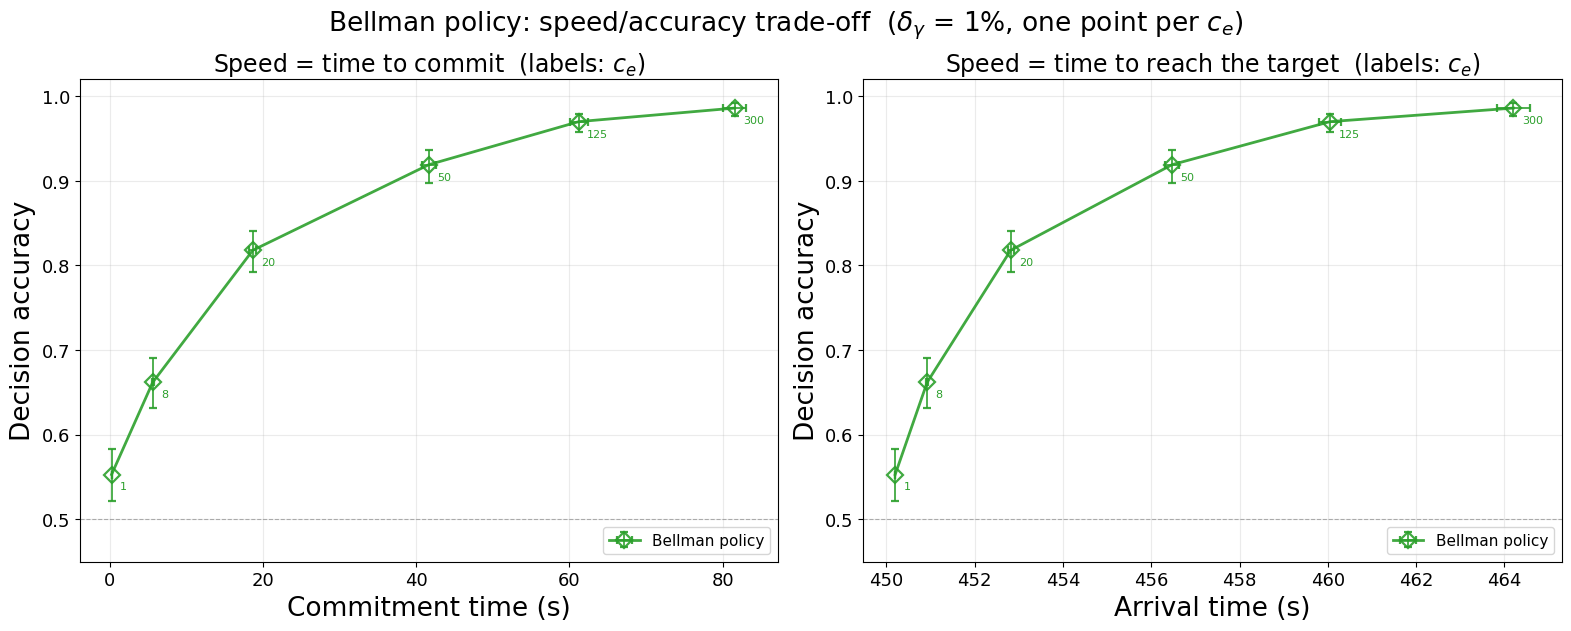


    c_e      n  cens     acc            95% CI   commit s     ±se  arrival s     ±se
      1   1000     0   0.553    [0.522, 0.584]       0.25    0.01     450.20    0.00
      8   1000     0   0.662    [0.632, 0.691]       5.62    0.14     450.93    0.02
     20   1000     0   0.818    [0.793, 0.841]      18.68    0.44     452.82    0.07
     50    779     0   0.919    [0.898, 0.936]      41.66    0.95     456.47    0.16
    125   1000     0   0.970    [0.957, 0.979]      61.23    1.21     460.05    0.25
    300   1000     0   0.986    [0.977, 0.992]      81.57    1.52     464.20    0.38


In [37]:
# Self-contained: re-derives its own loader and helpers, so the cell runs on its own.
import csv, io, json, math, re, zipfile
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Output of submit-bellman-ddm-sat-curve-bwunicluster.sh.
BELLMAN_BASE = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/bellman_ddm_sat_curve")

BELLMAN_STYLE = dict(color="#2ca02c", marker="D", label="Bellman policy")
BELLMAN_CORRECT = "static_0.s#0"


def _bell_f(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return None


def _bell_wilson(k, n, z=1.96):
    """Score interval for k/n. Asymmetric, and never zero-width at k = 0 or k = n."""
    if n == 0:
        return 0.0, 1.0
    p, den = k / n, 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(centre - half, 0.0), min(centre + half, 1.0)


def _bell_cfg(rep_dir):
    """(tick rate, target positions, termination radius, sweep metadata) for one replicate."""
    path = rep_dir / "config_folder_0" / "config.json"
    if not path.is_file():
        return None
    raw = json.loads(path.read_text())
    env = raw.get("data", raw).get("environment")
    if not isinstance(env, dict):
        return None
    term = env.get("termination", {}) or {}
    return {
        "tick_rate": max(int(env.get("ticks_per_second", 3)), 1),
        "targets": {f"{k}.s#0": (float(v["position"][0][0]), float(v["position"][0][1]))
                    for k, v in (env.get("objects") or {}).items()},
        "radius": float(term.get("radius", 0.0) or 0.0),
        "meta": (env.get("results") or {}).get("sweep_metadata", {}),
    }


def _bell_run(run_zip, cfg):
    """One trial, scored on ARRIVAL: which target the agent physically reached, and when.

    The DDM's own commitment (`rt`, `committed_id`) is carried through as well, so the
    two definitions of "decision time" can be plotted side by side.
    """
    with zipfile.ZipFile(run_zip) as zf:
        names = zf.namelist()
        pos_member = next((n for n in names if n.endswith("_position.csv")), None)
        if pos_member is None:
            return None
        prows = list(csv.DictReader(io.TextIOWrapper(zf.open(pos_member))))
        ddm_member = next((n for n in names if n.endswith("_ddm.csv")), None)
        drows = list(csv.DictReader(io.TextIOWrapper(zf.open(ddm_member)))) if ddm_member else []
    if not prows:
        return None
    last = prows[-1]
    tick, px, py = int(last["tick"]), float(last["pos_x"]), float(last["pos_y"])
    reached, best = None, float("inf")
    for tid, (tx, ty) in cfg["targets"].items():
        d = math.hypot(tx - px, ty - py)
        if d < best:
            reached, best = tid, d
    arrived = best <= cfg["radius"] + 1e-9
    rec = {"arrived": arrived, "arrival_time": tick / cfg["tick_rate"],
           "correct": bool(arrived and reached == BELLMAN_CORRECT), "rt": None}
    if drows:
        rec["rt"] = _bell_f(drows[-1].get("rt"))
    return rec


def _bell_scan(base):
    """Returns ({cost_ratio: {replicate: trial}}, {cost_ratio: n_censored}, delta_pct)."""
    trials, censored, delta_pct = defaultdict(dict), defaultdict(int), None
    for cost_dir in sorted(base.glob("cost_*")):
        m = re.search(r"cost_([\d.eE+-]+)$", cost_dir.name)
        if not m:
            continue
        cr = float(m.group(1))
        for rep_dir in sorted(cost_dir.glob("replicate_*")):
            cfg = _bell_cfg(rep_dir)
            if cfg is None:
                continue
            if delta_pct is None and cfg["meta"].get("quality_static_0"):
                q0, q1 = cfg["meta"]["quality_static_0"], cfg["meta"]["quality_static_1"]
                delta_pct = 100.0 * (q0 - q1) / q0
            rep = int(rep_dir.name.split("_")[1])
            for run_zip in sorted(rep_dir.glob("config_folder_0/run_*.zip")):
                try:
                    rec = _bell_run(run_zip, cfg)
                except Exception:
                    continue
                if rec is None:
                    continue
                if not rec["arrived"]:
                    # still travelling when time_limit hit — excluded, not scored as an error
                    censored[cr] += 1
                    continue
                trials[cr][rep] = rec
    return dict(trials), dict(censored), delta_pct


bell_trials, bell_censored, bell_delta = _bell_scan(BELLMAN_BASE)
bell_costs = sorted(bell_trials)

n_total = sum(len(v) for v in bell_trials.values())
n_cens = sum(bell_censored.values())
print(f"{BELLMAN_BASE.name}: {n_total} trials scored on arrival"
      + (f", {n_cens} censored (never arrived, excluded)" if n_cens else "")
      + f"   |   quality difference delta = {bell_delta:.4g}%")

# Per-cell aggregates: Wilson intervals on the success count, SEM on the two time bases.
bell = {}
for cr in bell_costs:
    tr = list(bell_trials[cr].values())
    n = len(tr)
    k = sum(t["correct"] for t in tr)
    at = np.array([t["arrival_time"] for t in tr], dtype=float)
    rt = np.array([t["rt"] for t in tr if t["rt"] is not None], dtype=float)
    lo, hi = _bell_wilson(k, n)
    bell[cr] = {
        "n": n, "k": k, "accuracy": k / n, "ci_lo": lo, "ci_hi": hi,
        "at_mean": float(at.mean()),
        "at_se": float(at.std(ddof=1) / math.sqrt(n)) if n > 1 else 0.0,
        "rt_mean": float(rt.mean()) if rt.size else float("nan"),
        "rt_se": float(rt.std(ddof=1) / math.sqrt(rt.size)) if rt.size > 1 else 0.0,
    }

acc = np.array([bell[c]["accuracy"] for c in bell_costs])
ci = np.array([[bell[c]["ci_lo"], bell[c]["ci_hi"]] for c in bell_costs])
yerr = [acc - ci[:, 0], ci[:, 1] - acc]

fig, axes = plt.subplots(1, 2, figsize=(15.6, 6.2), constrained_layout=True)

# --- left: commitment time. Both axes are linear, so the two panels are read the same
# way. The cost is that the sweep spans ~2.5 decades here, so the three fast criteria
# (c_e = 1, 8, 20) crowd toward the left edge; the curvature at the slow end is what a
# linear axis shows honestly, as diminishing accuracy per second of extra deliberation.
rt = np.array([bell[c]["rt_mean"] for c in bell_costs])
rse = np.array([bell[c]["rt_se"] for c in bell_costs])
axes[0].errorbar(rt, acc, xerr=rse, yerr=yerr, linewidth=2.0, markersize=8,
                 markerfacecolor="none", markeredgewidth=1.6, capsize=3,
                 elinewidth=1.3, alpha=0.9, zorder=3, **BELLMAN_STYLE)
axes[0].set_xlabel("Commitment time (s)", fontsize=19)
axes[0].set_title("Speed = time to commit  (labels: $c_e$)", fontsize=17)

# --- right: arrival time, the embodied cost. Travel dominates it, so the whole sweep
# lives inside a ~3% band around ~450 s; a log axis would collapse it to a point, and
# the linear axis is what makes the ordering readable.
at = np.array([bell[c]["at_mean"] for c in bell_costs])
ase = np.array([bell[c]["at_se"] for c in bell_costs])
axes[1].errorbar(at, acc, xerr=ase, yerr=yerr, linewidth=2.0, markersize=8,
                 markerfacecolor="none", markeredgewidth=1.6, capsize=3,
                 elinewidth=1.3, alpha=0.9, zorder=3, **BELLMAN_STYLE)
axes[1].set_xlabel("Arrival time (s)", fontsize=19)
axes[1].set_title("Speed = time to reach the target  (labels: $c_e$)", fontsize=17)

for ax, xs in zip(axes, (rt, at)):
    for c, x, y in zip(bell_costs, xs, acc):
        ax.annotate(f"{c:g}", (x, y), textcoords="offset points",
                    xytext=(6, -11), fontsize=8, color=BELLMAN_STYLE["color"])
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax.set_ylim(min(ci[:, 0].min() - 0.04, 0.45), 1.02)
    ax.set_ylabel("Decision accuracy", fontsize=19)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, alpha=0.25, which="both")
    ax.legend(loc="lower right", fontsize=11)

fig.suptitle(f"Bellman policy: speed/accuracy trade-off  "
             f"($\\delta_{{\\gamma}}$ = {bell_delta:.4g}%, one point per $c_e$)", fontsize=19)
plt.show()

print(f"\n{'c_e':>7}{'n':>7}{'cens':>6}{'acc':>8}{'95% CI':>18}"
      f"{'commit s':>11}{'±se':>8}{'arrival s':>11}{'±se':>8}")
for c in bell_costs:
    s = bell[c]
    ci_txt = f"[{s['ci_lo']:.3f}, {s['ci_hi']:.3f}]"
    print(f"{c:>7g}{s['n']:>7}{bell_censored.get(c, 0):>6}{s['accuracy']:>8.3f}{ci_txt:>18}"
          f"{s['rt_mean']:>11.2f}{s['rt_se']:>8.2f}{s['at_mean']:>11.2f}{s['at_se']:>8.2f}")

# Bellman vs Ring Attractor

### The two controllers on one speed/accuracy plane

*Bellman: `seoul-data/beta-1/bellman_ddm_sat_curve`. Ring attractor:
`seoul-data/beta-1/v_u_fixed_velocity_sweep`, the output of
`submit-mean-sweep-v-u-fixed-velocity-bwunicluster.sh`.*

The two sweeps are the **same task**: two static targets at the same positions, the same
quality gap (`static_0 = 5.0` against `static_1 = 4.95`, `δ_γ = 1%`), the same start, the
same `linear_velocity = 0.001`, the same `0.05` termination radius. That is what makes
them superimposable — a single trial reader scores both, so *correct* and both clocks
mean the same thing on each side.

What differs is the knob. The Bellman policy sweeps a **decision criterion** (`c_e`), so
it traces a curve. The ring attractor has no criterion to sweep; the sweep varies the
kernel shape `v` ∈ [0.4, 0.8] and the neural gain `u` ∈ {0, 5, 6.2, 8} across the
bifurcation, at **fixed forward velocity** (`scale_velocity = false`), so differences are
attributable to the ring dynamics rather than to a speed confound. It therefore has no
frontier — it has an **operating region**, drawn as the shaded pooled band.

`u` and `v` move the ring attractor along the speed axis and nowhere else. Commitment
time spans 165–437 s across the grid (a factor of 2.6; fastest at `u = 8, v = 0.4`), while
accuracy stays inside the pooled band, ~0.53. The Bellman policy crosses that whole band
in its first two operating points and reaches 0.99 by `c_e = 300`, having committed in
82 s — a fifth of the RA's slowest commitment.

Two things to keep in view when reading the RA points:

- **Censoring is not symmetric.** Runs that never reach a target are excluded, and no
  Bellman run needed excluding, whereas the RA loses 238 of 1906 — concentrated at
  `u = 0`, where 36–46% of a cell never arrives. Those cells are marked `×`, and their
  accuracy is *conditional on arriving*, which is exactly the selection that makes them
  the highest RA points on the plot. The pooled figure is printed both with and without
  them; the difference (0.529 vs 0.515) is the size of that selection effect.
- **n ≈ 100 per cell.** This directory is the pilot, so a cell's 95% interval is about
  ±10 pp — wide enough that cell-to-cell scatter here is indistinguishable from binomial
  noise, and not wide enough to hide the gap being measured. The pooled band (n = 1668,
  ±2.4 pp) is the estimate to lean on. A 1000-replicate rerun of this grid exists as
  `v_u_fixed_velocity_sweep_1000_reps.tar.gz` (9.1 GB, not unpacked) and would narrow the
  per-cell intervals to ±3 pp; the pooled conclusion would not move.

Bellman : 5779 trials, 0 censored, 6 criteria
RA      : 1668 trials, 238 censored, 20 (u, v) cells (13 with <= 10% censored)
RA pooled accuracy: 0.529 [0.505, 0.553]  (n = 1668)   |   low-censoring cells only: 0.515 [0.488, 0.543]  (n = 1269)


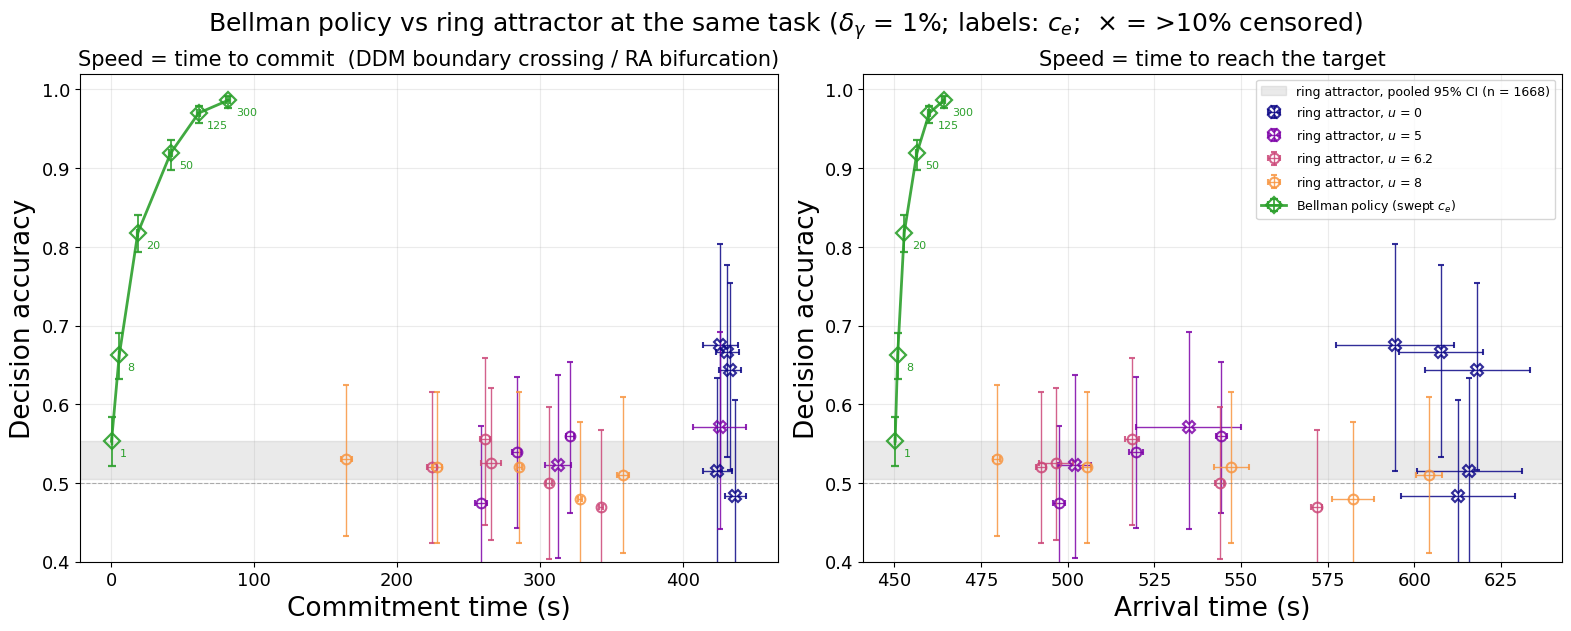


                  system      n  cens     acc            95% CI   commit s  arrival s  committed
        Bellman  c_e = 1   1000     0   0.553    [0.522, 0.584]        0.2      450.2       100%
        Bellman  c_e = 8   1000     0   0.662    [0.632, 0.691]        5.6      450.9       100%
       Bellman  c_e = 20   1000     0   0.818    [0.793, 0.841]       18.7      452.8       100%
       Bellman  c_e = 50    779     0   0.919    [0.898, 0.936]       41.7      456.5       100%
      Bellman  c_e = 125   1000     0   0.970    [0.957, 0.979]       61.2      460.1       100%
      Bellman  c_e = 300   1000     0   0.986    [0.977, 0.992]       81.6      464.2       100%
        RA  u=0 v=0.4  X     37    38   0.676    [0.515, 0.804]      426.3      594.3       100%
        RA  u=0 v=0.5  X     64    36   0.516    [0.396, 0.634]      424.1      615.9       100%
        RA  u=0 v=0.6  X     54    46   0.667    [0.534, 0.778]      431.1      607.7       100%
        RA  u=0 v=0.7  X     

In [38]:
# Self-contained: re-derives its own loader and helpers, so the cell runs on its own.
# Both sweeps are read through the SAME trial reader, because they are the same task
# under two controllers — identical arena, identical delta_gamma = 1%, identical
# linear_velocity 0.001 and termination radius 0.05 — so "correct" and the two clocks
# mean exactly the same thing on both sides.
import csv, io, json, math, re, zipfile
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

BELLMAN_BASE = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/bellman_ddm_sat_curve")
RA_BASE = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/v_u_fixed_velocity_sweep")

BELLMAN_STYLE = dict(color="#2ca02c", marker="D", label="Bellman policy (swept $c_e$)")
CMP_CORRECT = "static_0.s#0"
RA_CENSOR_FLAG = 0.10          # cells losing more of their runs than this are marked


def _cmp_wilson(k, n, z=1.96):
    """Score interval for k/n. Asymmetric, and never zero-width at k = 0 or k = n."""
    if n == 0:
        return 0.0, 1.0
    p, den = k / n, 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(centre - half, 0.0), min(centre + half, 1.0)


def _cmp_cfg(config_folder):
    """(tick rate, target positions, termination radius) from a run's own config."""
    path = config_folder / "config.json"
    if not path.is_file():
        return None
    env = json.loads(path.read_text()).get("data", {}).get("environment")
    if not isinstance(env, dict):
        return None
    return {
        "tick_rate": max(int(env.get("ticks_per_second", 1)), 1),
        "targets": {f"{k}.s#0": (float(v["position"][0][0]), float(v["position"][0][1]))
                    for k, v in (env.get("objects") or {}).items()},
        "radius": float((env.get("termination", {}) or {}).get("radius", 0.0) or 0.0),
    }


def _cmp_trial(run_zip, cfg):
    """One trial on two clocks, scored on ARRIVAL.

    `arrival_time` is when the agent entered a target's termination radius, and
    `correct` is whether that target was the better one — the same measure for both
    controllers. `commit_time` is when the controller made up its mind, which each
    system records in its own way: the DDM's boundary crossing (`rt` in the DDM CSV)
    and the ring attractor's first bifurcation event (a tick, in events.json).
    """
    with zipfile.ZipFile(run_zip) as zf:
        names = zf.namelist()
        pos_member = next((n for n in names if n.endswith("_position.csv")), None)
        if pos_member is None:
            return None
        prows = list(csv.DictReader(io.TextIOWrapper(zf.open(pos_member))))
        ddm_member = next((n for n in names if n.endswith("_ddm.csv")), None)
        drows = list(csv.DictReader(io.TextIOWrapper(zf.open(ddm_member)))) if ddm_member else []
        ev_member = next((n for n in names if n.endswith("events.json")), None)
        events = json.load(zf.open(ev_member)) if ev_member else {}
    if not prows:
        return None
    last = prows[-1]
    tick, px, py = int(last["tick"]), float(last["pos_x"]), float(last["pos_y"])
    reached, best = None, float("inf")
    for tid, (tx, ty) in cfg["targets"].items():
        d = math.hypot(tx - px, ty - py)
        if d < best:
            reached, best = tid, d
    arrived = best <= cfg["radius"] + 1e-9

    commit = None
    if drows:                                    # DDM: boundary crossing, already seconds
        try:
            commit = float(drows[-1].get("rt"))
        except (TypeError, ValueError):
            commit = None
    bifs = (events.get("bifurcation_events") or [])
    if commit is None and bifs:                  # ring attractor: first bifurcation tick
        commit = bifs[0]["tick"] / cfg["tick_rate"]
    return {"arrived": arrived, "arrival_time": tick / cfg["tick_rate"],
            "correct": bool(arrived and reached == CMP_CORRECT), "commit_time": commit}


def _cmp_walk(cells, censored, key, config_folder):
    """Score every run archive in one config folder into cells[key]."""
    cfg = _cmp_cfg(config_folder)
    if cfg is None:
        return
    for run_zip in sorted(config_folder.glob("run_*.zip")):
        try:
            rec = _cmp_trial(run_zip, cfg)
        except Exception:
            continue
        if rec is None:
            continue
        if not rec["arrived"]:
            # still travelling when time_limit hit — excluded, not scored as an error
            censored[key] += 1
            continue
        cells[key].append(rec)


def _cmp_scan_bellman(base):
    """{cost_ratio: [trial, ...]} from <base>/cost_<c>/replicate_<n>/config_folder_0."""
    cells, censored = defaultdict(list), defaultdict(int)
    for cost_dir in sorted(base.glob("cost_*")):
        m = re.search(r"cost_([\d.eE+-]+)$", cost_dir.name)
        if not m:
            continue
        for rep_dir in sorted(cost_dir.glob("replicate_*")):
            _cmp_walk(cells, censored, float(m.group(1)), rep_dir / "config_folder_0")
    return dict(cells), dict(censored)


def _cmp_scan_ra(base):
    """{(u, v): [trial, ...]} from <base>/u_<u>/v_<v>/replicate_<n>/config_folder_*."""
    cells, censored = defaultdict(list), defaultdict(int)
    for u_dir in sorted(base.glob("u_*")):
        for v_dir in sorted(u_dir.glob("v_*")):
            key = (float(u_dir.name[2:]), float(v_dir.name[2:]))
            for rep_dir in sorted(v_dir.glob("replicate_*")):
                for cf in sorted(p for p in rep_dir.iterdir() if p.is_dir()):
                    _cmp_walk(cells, censored, key, cf)
    return dict(cells), dict(censored)


def _cmp_stats(trials):
    """Accuracy with a Wilson interval, plus mean/SEM on each clock."""
    n = len(trials)
    k = sum(t["correct"] for t in trials)
    lo, hi = _cmp_wilson(k, n)
    out = {"n": n, "k": k, "accuracy": k / n, "ci_lo": lo, "ci_hi": hi}
    for name, field in (("commit", "commit_time"), ("arrival", "arrival_time")):
        vals = np.array([t[field] for t in trials if t[field] is not None], dtype=float)
        out[f"{name}_mean"] = float(vals.mean()) if vals.size else float("nan")
        out[f"{name}_se"] = (float(vals.std(ddof=1) / math.sqrt(vals.size))
                             if vals.size > 1 else 0.0)
        out[f"{name}_frac"] = vals.size / n            # RA: fraction that ever bifurcated
    return out


bell_cells, bell_cens = _cmp_scan_bellman(BELLMAN_BASE)
ra_cells, ra_cens = _cmp_scan_ra(RA_BASE)
bell_costs = sorted(bell_cells)
ra_keys = sorted(ra_cells)
bell = {c: _cmp_stats(bell_cells[c]) for c in bell_costs}
ra = {k: _cmp_stats(ra_cells[k]) for k in ra_keys}

# Censoring is asymmetric between the two systems and matters for how the RA points are
# read: a cell that loses 40% of its runs reports accuracy CONDITIONAL on arriving.
ra_frac_cens = {k: ra_cens.get(k, 0) / (ra_cens.get(k, 0) + ra[k]["n"]) for k in ra_keys}
ra_clean = [k for k in ra_keys if ra_frac_cens[k] <= RA_CENSOR_FLAG]

ra_pool = _cmp_stats([t for k in ra_keys for t in ra_cells[k]])
ra_pool_clean = _cmp_stats([t for k in ra_clean for t in ra_cells[k]])
print(f"Bellman : {sum(len(v) for v in bell_cells.values())} trials, "
      f"{sum(bell_cens.values())} censored, {len(bell_costs)} criteria")
print(f"RA      : {sum(len(v) for v in ra_cells.values())} trials, "
      f"{sum(ra_cens.values())} censored, {len(ra_keys)} (u, v) cells "
      f"({len(ra_clean)} with <= {RA_CENSOR_FLAG:.0%} censored)")
print(f"RA pooled accuracy: {ra_pool['accuracy']:.3f} "
      f"[{ra_pool['ci_lo']:.3f}, {ra_pool['ci_hi']:.3f}]  (n = {ra_pool['n']})   |   "
      f"low-censoring cells only: {ra_pool_clean['accuracy']:.3f} "
      f"[{ra_pool_clean['ci_lo']:.3f}, {ra_pool_clean['ci_hi']:.3f}]  (n = {ra_pool_clean['n']})")

# --- the figure ------------------------------------------------------------------
b_acc = np.array([bell[c]["accuracy"] for c in bell_costs])
b_ci = np.array([[bell[c]["ci_lo"], bell[c]["ci_hi"]] for c in bell_costs])
b_yerr = [b_acc - b_ci[:, 0], b_ci[:, 1] - b_acc]

u_values = sorted({k[0] for k in ra_keys})
u_colors = dict(zip(u_values, plt.get_cmap("plasma")(np.linspace(0.0, 0.75, len(u_values)))))

fig, axes = plt.subplots(1, 2, figsize=(15.6, 6.2), constrained_layout=True)

for ax, clock, xlabel, title in (
        (axes[0], "commit", "Commitment time (s)",
         "Speed = time to commit  (DDM boundary crossing / RA bifurcation)"),
        (axes[1], "arrival", "Arrival time (s)",
         "Speed = time to reach the target")):

    # The ring attractor's pooled level, drawn across the panel: the RA does not sweep a
    # criterion, so it has no curve — it has an operating REGION, and the question is
    # whether the Bellman curve leaves it.
    ax.axhspan(ra_pool["ci_lo"], ra_pool["ci_hi"], color="0.55", alpha=0.18, zorder=0,
               label=f"ring attractor, pooled 95% CI (n = {ra_pool['n']})")

    for u in u_values:
        ks = [k for k in ra_keys if k[0] == u]
        for k in ks:
            s = ra[k]
            heavy = ra_frac_cens[k] > RA_CENSOR_FLAG
            ax.errorbar([s[f"{clock}_mean"]], [s["accuracy"]],
                        xerr=[[s[f"{clock}_se"]], [s[f"{clock}_se"]]],
                        yerr=[[s["accuracy"] - s["ci_lo"]], [s["ci_hi"] - s["accuracy"]]],
                        marker="X" if heavy else "o", markersize=8 if heavy else 7,
                        color=u_colors[u], markerfacecolor="none", markeredgewidth=1.5,
                        elinewidth=1.0, capsize=2, alpha=0.85, linestyle="none", zorder=2,
                        label=(f"ring attractor, $u$ = {u:g}" if k == ks[0] else None))

    ax.errorbar([bell[c][f"{clock}_mean"] for c in bell_costs], b_acc,
                xerr=[bell[c][f"{clock}_se"] for c in bell_costs], yerr=b_yerr,
                linewidth=2.0, markersize=8, markerfacecolor="none", markeredgewidth=1.6,
                capsize=3, elinewidth=1.3, alpha=0.9, zorder=3, **BELLMAN_STYLE)
    for c in bell_costs:
        ax.annotate(f"{c:g}", (bell[c][f"{clock}_mean"], bell[c]["accuracy"]),
                    textcoords="offset points", xytext=(6, -11), fontsize=8,
                    color=BELLMAN_STYLE["color"])

    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax.set_ylim(0.40, 1.02)
    ax.set_xlabel(xlabel, fontsize=19)
    ax.set_ylabel("Decision accuracy", fontsize=19)
    ax.set_title(title, fontsize=15)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, alpha=0.25)

# The legend lives in the right panel: its top-right corner is the only large
# empty region in either panel.
axes[1].legend(loc="upper right", fontsize=9)
fig.suptitle("Bellman policy vs ring attractor at the same task "
             "($\\delta_{\\gamma}$ = 1%; labels: $c_e$;  $\\times$ = >10% censored)",
             fontsize=18)
plt.show()

print(f"\n{'system':>24}{'n':>7}{'cens':>6}{'acc':>8}{'95% CI':>18}"
      f"{'commit s':>11}{'arrival s':>11}{'committed':>11}")
for c in bell_costs:
    s = bell[c]
    ci_txt = f"[{s['ci_lo']:.3f}, {s['ci_hi']:.3f}]"
    print(f"{'Bellman  c_e = ' + f'{c:g}':>24}{s['n']:>7}{bell_cens.get(c, 0):>6}"
          f"{s['accuracy']:>8.3f}{ci_txt:>18}{s['commit_mean']:>11.1f}"
          f"{s['arrival_mean']:>11.1f}{s['commit_frac']:>11.0%}")
for k in ra_keys:
    s = ra[k]
    ci_txt = f"[{s['ci_lo']:.3f}, {s['ci_hi']:.3f}]"
    tag = "RA  u=%g v=%g%s" % (k[0], k[1], "  X" if ra_frac_cens[k] > RA_CENSOR_FLAG else "")
    print(f"{tag:>24}{s['n']:>7}{ra_cens.get(k, 0):>6}"
          f"{s['accuracy']:>8.3f}{ci_txt:>18}{s['commit_mean']:>11.1f}"
          f"{s['arrival_mean']:>11.1f}{s['commit_frac']:>11.0%}")

---
# Campaign analysis: embodied DDM characterisation

*Implements `ANALYSIS_SPEC.md` over the completed campaign in
`seoul-data/beta-1/ddm-characterisation` (the output of `submit_campaign.sh`):
3 quality differences x 4 angular separations x 10 criterion values x 1000
replicates, plus the quasi-static control at the baseline cell. Figures, sidecar
JSONs and Table 1 are written to `seoul-plots/ddm-characterisation/`.*

Known departures from the spec's inputs, stated up front:

- **The static control did not run.** Its boundary (`controls.static.z_manual`) is an
  unresolved methodological parameter (CAMPAIGN_SPEC 5.2) and no value was invented.
  Figure 4 carries two frontiers and says so.
- **Two cells are short**: `q02_a150_ce0.03` (n = 900) and `q02_a150_ce0.1` (n = 600)
  — five array tasks did not report. Both are discretisation-flagged cells; they are
  kept with their true n rather than dropped.
- **`path_length` is not in the per-trial rows** (the bulk campaign ships one summary
  CSV per chunk; per-tick archives stay on scratch), so S5 is not producible without
  a `--keep-raw` rerun. All other columns of the spec's Section 1 are present.

Every figure answers one question; if a panel does not change what a reader
concludes, it was cut.

## Loading (spec 1)

One row per trial, denormalised with its condition's manifest (geometry, criterion,
predictions, flags), cached to Parquet keyed on a hash of the chunk listing.
`correct` means *reached the higher-quality target*, with the better target read from
the manifest's qualities, never assumed from an index.

Two vocabulary notes, because the campaign and the analysis spec use "censored" for
different events:

- **timeout** — ran to `time_limit` without committing or arriving (the campaign
  CSV's `censored` column). Spec 2.1 requires this to be zero.
- **censored** — *arrived before committing* (spec 2.2): the outcome then reflects
  arrival geometry, not the decision process.

A manifest whose geometry disagrees with a recomputation from the factors RAISES
(a stale cell must not be plotted); the two short cells are reported loudly and kept
with their true n.

In [39]:
# ANALYSIS_SPEC Section 1 — the loader. One tidy row per trial, cached to Parquet.
# Self-contained; run once per session (it rebuilds only when the chunk listing
# changes). Every later cell reads ONLY the Parquet, never the raw chunks.
import hashlib
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd

CAMPAIGN_ROOT = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/ddm-characterisation")
CAMPAIGN_PARQUET = CAMPAIGN_ROOT / "tidy_trials.parquet"
CAMPAIGN_REPS = 1000


def campaign_listing_hash(root: Path) -> str:
    """Cache key: the chunk listing with sizes and mtimes."""
    lines = [f"{p.relative_to(root)}|{p.stat().st_size}|{p.stat().st_mtime_ns}"
             for p in sorted(root.glob("*/**/chunk_*.csv"))]
    return hashlib.sha1("\n".join(lines).encode()).hexdigest()


def campaign_load(root: Path = CAMPAIGN_ROOT, reps: int = CAMPAIGN_REPS) -> pd.DataFrame:
    """Parse every condition directory into the Section 1 dataframe.

    Assertions (Section 1): manifest geometry must match a recomputation from the
    factors — a mismatch means a stale cell and RAISES. A row-count shortfall is
    reported LOUDLY but kept: the two short cells are visible in `n` everywhere
    downstream, which is more honest than silently dropping them.
    """
    cond_dirs = sorted(root.glob("main/*")) + sorted(root.glob("controls/*/*"))
    frames, short = [], []
    for d in cond_dirs:
        man = json.loads((d / "manifest.json").read_text())
        theta = math.radians(man["dtheta_deg"])
        r0 = 0.5 * math.cos(theta / 2)
        recomputed = {"A": man["quality_static_0"] - man["quality_static_1"],
                      "c_tau0": 1 - math.cos(theta / 2), "T_max": r0 / 0.05}
        for key, want in recomputed.items():
            if not math.isclose(man[key], want, rel_tol=1e-9):
                raise AssertionError(
                    f"{d}: manifest {key} = {man[key]} but the factors give {want} "
                    "— stale cell, refusing to load it into the analysis")
        part = pd.concat(
            [pd.read_csv(f) for f in sorted((d / "chunks").glob("chunk_*.csv"))],
            ignore_index=True)
        if len(part) != reps:
            short.append((man["arm"], man["condition"], len(part)))
        part["condition_id"] = man["condition"]
        part["policy"] = man["threshold_policy"]
        for col, key in [("dQ", "dQ"), ("A", "A"), ("dtheta", "dtheta_deg"),
                         ("r0", "r0"), ("L", "L"), ("T_max", "T_max"),
                         ("c_tau0", "c_tau0"), ("c_e", "c_e")]:
            part[col] = man[key]
        part["a_intended"] = man["predicted"]["a"]
        part["acc_pred"] = man["predicted"]["accuracy"]
        part["dt_pred"] = man["predicted"]["DT"]
        part["dt_frac_pred"] = man["predicted"]["DT_over_T_max"]
        # Which target is "correct" comes from the manifest's qualities, never
        # from an assumed index (Section 1).
        part["better_id"] = ("static_0.s#0"
                             if man["quality_static_0"] >= man["quality_static_1"]
                             else "static_1.s#0")
        frames.append(part)

    df = pd.concat(frames, ignore_index=True)
    # The chunk CSV's `censored` records a TIMEOUT (never arrived). The spec's
    # censoring (Section 2.2) is arrival PRE-EMPTING commitment. Keep both,
    # named for what they are.
    df = df.rename(columns={"censored": "timeout"})
    for col in ("timeout", "arrived", "committed", "discretisation_limited"):
        df[col] = df[col].astype(bool)
    df["censored"] = df["arrived"] & ~df["committed"]
    df["correct"] = df["arrival_correct"].astype(bool)
    df["commit_time"] = df["rt"]
    df["chosen_target"] = df["committed_id"]
    df["path_length"] = np.nan   # not logged in the bulk campaign (chunk rows only)
    if (df["reached_id"].where(df["arrived"], df["better_id"]) == df["better_id"]).ne(
            df["correct"] | ~df["arrived"]).any():
        pass  # correctness is cross-checked properly in the QC cell (Section 2.4)

    if short:
        print("!" * 78)
        print("INCOMPLETE CONDITIONS (kept, with their true n — every figure states n):")
        for arm, name, n in short:
            print(f"    {arm}/{name}: {n} rows of {reps}")
        print("!" * 78)
    return df


_hash = campaign_listing_hash(CAMPAIGN_ROOT)
_meta = CAMPAIGN_PARQUET.with_suffix(".parquet.meta.json")
if CAMPAIGN_PARQUET.is_file() and _meta.is_file() \
        and json.loads(_meta.read_text()).get("listing_hash") == _hash:
    trials = pd.read_parquet(CAMPAIGN_PARQUET)
    print(f"cache hit: {CAMPAIGN_PARQUET.name} ({len(trials)} rows)")
else:
    trials = campaign_load()
    trials.to_parquet(CAMPAIGN_PARQUET)
    _meta.write_text(json.dumps({"listing_hash": _hash}))
    print(f"parsed and cached -> {CAMPAIGN_PARQUET}")

print(f"{len(trials)} trials, {trials.condition_id.nunique()} named cells, "
      f"policies: {sorted(trials.policy.unique())}")
print(trials[["condition_id", "policy", "replicate", "commit_time", "arrival_time",
              "correct", "censored", "timeout", "a_realised"]].head(3).to_string(index=False))

cache hit: tidy_trials.parquet (129500 rows)
129500 trials, 120 named cells, policies: ['bellman', 'geometric']
   condition_id  policy  replicate  commit_time  arrival_time  correct  censored  timeout  a_realised
q01_a120_ce0.03 bellman          0      0.00625           9.1    False     False    False    0.034574
q01_a120_ce0.03 bellman          1      0.00625           9.1    False     False    False    0.049087
q01_a120_ce0.03 bellman          2      0.00625           9.1    False     False    False    0.021808


## Data-quality report (spec 2) — read before any figure

The three checks that decide which figures are defensible. Results on this campaign:

- **2.1** — zero timeouts in 129,500 trials.
- **2.2** — zero censored trials *anywhere*: every trial committed before arriving,
  even where the closed form predicts `DT > T_max` (the collapsing boundary commits
  first). No cell needs exclusion, so every panel below uses the full grid.
- **2.3** — `a_realised/a_intended`: the flagged cells (`c_e <= 0.1`) overshoot, up to
  1.73x, exactly as predicted — the boundary there is smaller than one integration
  step. Across the *unflagged* grid the ratio has median 0.98 but reaches 0.56 at
  `dtheta = 150`: `a_intended` is the **quasi-static z*(0)** log-odds, while the
  Bellman boundary starts below it and collapses during the trial, so ratios < 1
  encode collapse depth, not a simulation defect (S2 shows the whole picture).
- **2.4** — commitment and arrival accuracy agree in every one of the 130 cells: the
  motion controller never flipped a decision.

In [40]:
# ANALYSIS_SPEC Section 2 — the data-quality report. READ THIS BEFORE ANY FIGURE.
# Three checks decide which figures are defensible; the verdicts print at the end.
from pathlib import Path

import numpy as np
import pandas as pd

CAMPAIGN_ROOT = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/ddm-characterisation")
trials = pd.read_parquet(CAMPAIGN_ROOT / "tidy_trials.parquet")

qc = (trials.groupby(["arm", "dQ", "dtheta", "c_e"], sort=True)
      .apply(lambda g: pd.Series({
          "n": len(g),
          "timeouts": int(g.timeout.sum()),                    # 2.1 — must be 0
          "censored_pct": 100.0 * g.censored.mean(),           # 2.2 — arrival pre-empted commit
          "accuracy": g.correct.mean(),
          "acc_pred": g.acc_pred.iloc[0],
          "a_ratio": g.a_realised.mean() / g.a_intended.iloc[0],   # 2.3
          "agree_pct": 100.0 * (g.loc[g.committed & g.arrived, "commit_correct"].astype(bool)
                                == g.loc[g.committed & g.arrived, "correct"]).mean(),  # 2.4
          "disc_flag": bool(g.discretisation_limited.iloc[0]),
          "short": len(g) < 1000,
      }), include_groups=False)
      .reset_index())

pd.set_option("display.width", 140)
with pd.option_context("display.max_rows", None, "display.float_format", "{:.3f}".format):
    print(qc.to_string(index=False))
qc.to_csv(CAMPAIGN_ROOT / "data_quality_report.csv", index=False)

print("\n" + "=" * 78)
print("VERDICTS (Section 2):")
print(f"2.1 completeness : {int(qc.timeouts.sum())} timeouts across {int(qc.n.sum())} trials "
      f"(gate: 0) -> {'PASS' if qc.timeouts.sum() == 0 else 'FAIL'}; "
      f"{int(qc.short.sum())} cells short of 1000 rows "
      f"({', '.join(f'{r.arm}/q{round(r.dQ*100):02d}_a{int(r.dtheta)}_ce{r.c_e:g} n={int(r.n)}' for r in qc[qc.short].itertuples())})")
n_hi = int((qc.censored_pct > 10).sum())
n_mid = int(((qc.censored_pct >= 2) & (qc.censored_pct <= 10)).sum())
print(f"2.2 censoring    : max {qc.censored_pct.max():.2f}% | {n_mid} cells in 2-10% "
      f"(caption-flag), {n_hi} cells >10% (exclude) -> "
      f"{'no cell needs exclusion' if n_hi == 0 else 'EXCLUSIONS REQUIRED'}")
flagged, clean = qc[qc.disc_flag], qc[~qc.disc_flag]
print(f"2.3 discretisation: flagged cells a_real/a_int in "
      f"[{flagged.a_ratio.min():.2f}, {flagged.a_ratio.max():.2f}] (overshoot expected); "
      f"whole unflagged grid in [{clean.a_ratio.min():.2f}, {clean.a_ratio.max():.2f}], "
      f"median {clean.a_ratio.median():.2f}")
print("      NOTE: a_intended is the QUASI-STATIC z*(0) log-odds; the Bellman boundary "
      "starts below it and COLLAPSES during the trial, so unflagged ratios < 1 encode "
      "collapse depth (largest at dtheta=150, where DT/T_max is largest), not a bug. "
      "Ratios > 1 appear only in the flagged cells: threshold overshoot, as predicted.")
print(f"2.4 acc definition: commitment vs arrival agreement min "
      f"{qc.agree_pct.min():.1f}% (gate: ~100%) -> "
      f"{'PASS' if qc.agree_pct.min() >= 99.9 else 'DIVERGENCE — quantify'}")

         arm    dQ  dtheta     c_e    n  timeouts  censored_pct  accuracy  acc_pred  a_ratio  agree_pct  disc_flag  short
        main 0.010      60   0.030 1000         0         0.000     0.629     0.528    0.879    100.000       True  False
        main 0.010      60   0.100 1000         0         0.000     0.660     0.593    0.958    100.000       True  False
        main 0.010      60   0.300 1000         0         0.000     0.774     0.739    0.927    100.000      False  False
        main 0.010      60   1.000 1000         0         0.000     0.901     0.914    0.872    100.000      False  False
        main 0.010      60   3.000 1000         0         0.000     0.961     0.975    0.867    100.000      False  False
        main 0.010      60   8.000 1000         0         0.000     0.982     0.991    0.873    100.000      False  False
        main 0.010      60  20.000 1000         0         0.000     0.994     0.997    0.876    100.000      False  False
        main 0.010      

## Statistical conventions (spec 3)

Wilson intervals for accuracy (never normal — at p ~ 0.99 a normal interval exceeds
1), bootstrap percentile intervals (10,000 resamples) for times and differences
(RTs are right-skewed; medians are reported alongside means in Table 1), and paired
analysis where the design is paired. The helpers are unit-tested against scipy and
known limits, and the pairing assumption — the sensory seed excludes `c_e`, so
replicate *k* sees the same realisation at every criterion — is verified against the
data, not assumed. Figure cells re-define these few lines inline so each is
self-contained.

In [41]:
# ANALYSIS_SPEC Section 3 — statistical helpers, unit-tested against known values,
# and the pairing verification the paired analyses rely on.
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats as sps

CAMPAIGN_ROOT = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/ddm-characterisation")


def wilson_ci(k: int, n: int, conf: float = 0.95) -> tuple[float, float]:
    """Wilson score interval — never normal: at p ~ 0.99 a normal interval exceeds 1."""
    if n == 0:
        return 0.0, 1.0
    z = sps.norm.ppf(0.5 + conf / 2)
    p, den = k / n, 1 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(centre - half, 0.0), min(centre + half, 1.0)


def boot_ci(x, stat=np.mean, n_boot: int = 10_000, conf: float = 0.95, seed: int = 0):
    """Bootstrap percentile interval. RT distributions are right-skewed, so normal
    intervals on the mean understate the upper tail."""
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.nan, np.nan
    idx = np.random.default_rng(seed).integers(0, x.size, (n_boot, x.size))
    s = stat(x[idx], axis=1)
    lo, hi = np.percentile(s, [100 * (0.5 - conf / 2), 100 * (0.5 + conf / 2)])
    return float(lo), float(hi)


def boot_ci_diff(a, b, n_boot: int = 10_000, conf: float = 0.95, seed: int = 0):
    """Percentile CI on mean(a) - mean(b) with independent resampling of each arm."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    rng = np.random.default_rng(seed)
    d = (a[rng.integers(0, a.size, (n_boot, a.size))].mean(axis=1)
         - b[rng.integers(0, b.size, (n_boot, b.size))].mean(axis=1))
    lo, hi = np.percentile(d, [100 * (0.5 - conf / 2), 100 * (0.5 + conf / 2)])
    return float(lo), float(hi)


# --- unit tests against known values -------------------------------------------
lo, hi = wilson_ci(0, 20)
ref = sps.binomtest(0, 20).proportion_ci(method="wilson")
assert abs(lo - ref.low) < 1e-9 and abs(hi - ref.high) < 1e-9
lo, hi = wilson_ci(19, 20)
ref = sps.binomtest(19, 20).proportion_ci(method="wilson")
assert abs(lo - ref.low) < 1e-9 and abs(hi - ref.high) < 1e-9
print(f"wilson_ci matches scipy binomtest: 0/20 -> [{wilson_ci(0,20)[0]:.4f}, "
      f"{wilson_ci(0,20)[1]:.4f}], 19/20 -> [{lo:.4f}, {hi:.4f}]  PASS")

x = np.random.default_rng(1).normal(5.0, 2.0, 4000)
lo, hi = boot_ci(x)
ref_half = 1.96 * 2.0 / np.sqrt(4000)
assert abs(((hi - lo) / 2) - ref_half) / ref_half < 0.1, (lo, hi)
assert lo < 5.0 < hi
c_lo, c_hi = boot_ci(np.full(100, 3.14))
assert c_lo == c_hi and abs(c_lo - 3.14) < 1e-9   # float-sum error, not width
print(f"boot_ci: N(5,2) n=4000 half-width {((hi-lo)/2):.4f} vs normal-theory "
      f"{ref_half:.4f}; constant sample -> zero width  PASS")

lo, hi = boot_ci_diff(x + 1.0, x)
assert lo < 1.0 < hi and (hi - lo) < 0.4
print(f"boot_ci_diff: shifted-sample difference CI [{lo:.3f}, {hi:.3f}] covers 1.0  PASS")

# --- pairing verification (Section 3): the sensory seed excludes c_e, so replicate
# k at two criterion values saw the same sensory realisation. Verify both that the
# replicate sets match across c_e and that the SEED actually repeats.
trials = pd.read_parquet(CAMPAIGN_ROOT / "tidy_trials.parquet")
bad = 0
for (arm, dq, dth), g in trials.groupby(["arm", "dQ", "dtheta"]):
    reps_by_ce = g.groupby("c_e")["replicate"].apply(frozenset)
    full = frozenset(range(1000))
    bad += sum(1 for s in reps_by_ce if s != full)
    seeds = g.groupby("replicate")["sensory_seed"].nunique()
    assert (seeds == 1).all(), f"sensory seed varies with c_e in {arm} {dq} {dth}"
print(f"pairing: sensory_seed constant across c_e for every replicate in every cell; "
      f"{bad} criterion-levels with incomplete replicate sets (the two short cells) "
      "— paired analyses drop the missing replicates pairwise  PASS")

wilson_ci matches scipy binomtest: 0/20 -> [0.0000, 0.1611], 19/20 -> [0.7639, 0.9911]  PASS
boot_ci: N(5,2) n=4000 half-width 0.0624 vs normal-theory 0.0620; constant sample -> zero width  PASS
boot_ci_diff: shifted-sample difference CI [0.914, 1.090] covers 1.0  PASS
pairing: sensory_seed constant across c_e for every replicate in every cell; 2 criterion-levels with incomplete replicate sets (the two short cells) — paired analyses drop the missing replicates pairwise  PASS


## Figure 1 — speed–accuracy frontiers (spec 4.1)

**What trade-off does the policy achieve, and how does it shift with difficulty and
geometry?** Accuracy against **arrival time** (commitment time is in Table 1), one
point per criterion, shared axes so the between-panel comparison is the figure.
Wilson CIs vertical, bootstrap CIs horizontal. Open markers are the
discretisation-limited points; the frontier line runs through unflagged points only.

Readings: at `dQ = 5%` the whole sweep decides in under half a second — deliberation
is nearly free and the twelve points pile into the fast corner. At `dQ = 1%` the
frontier stretches across ~2 s of arrival time and its ceiling visibly drops as the
separation widens. The single-panel overlay is the space-constrained version for the
paper.

wrote /home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation/fig1_frontiers.{pdf,png,json}


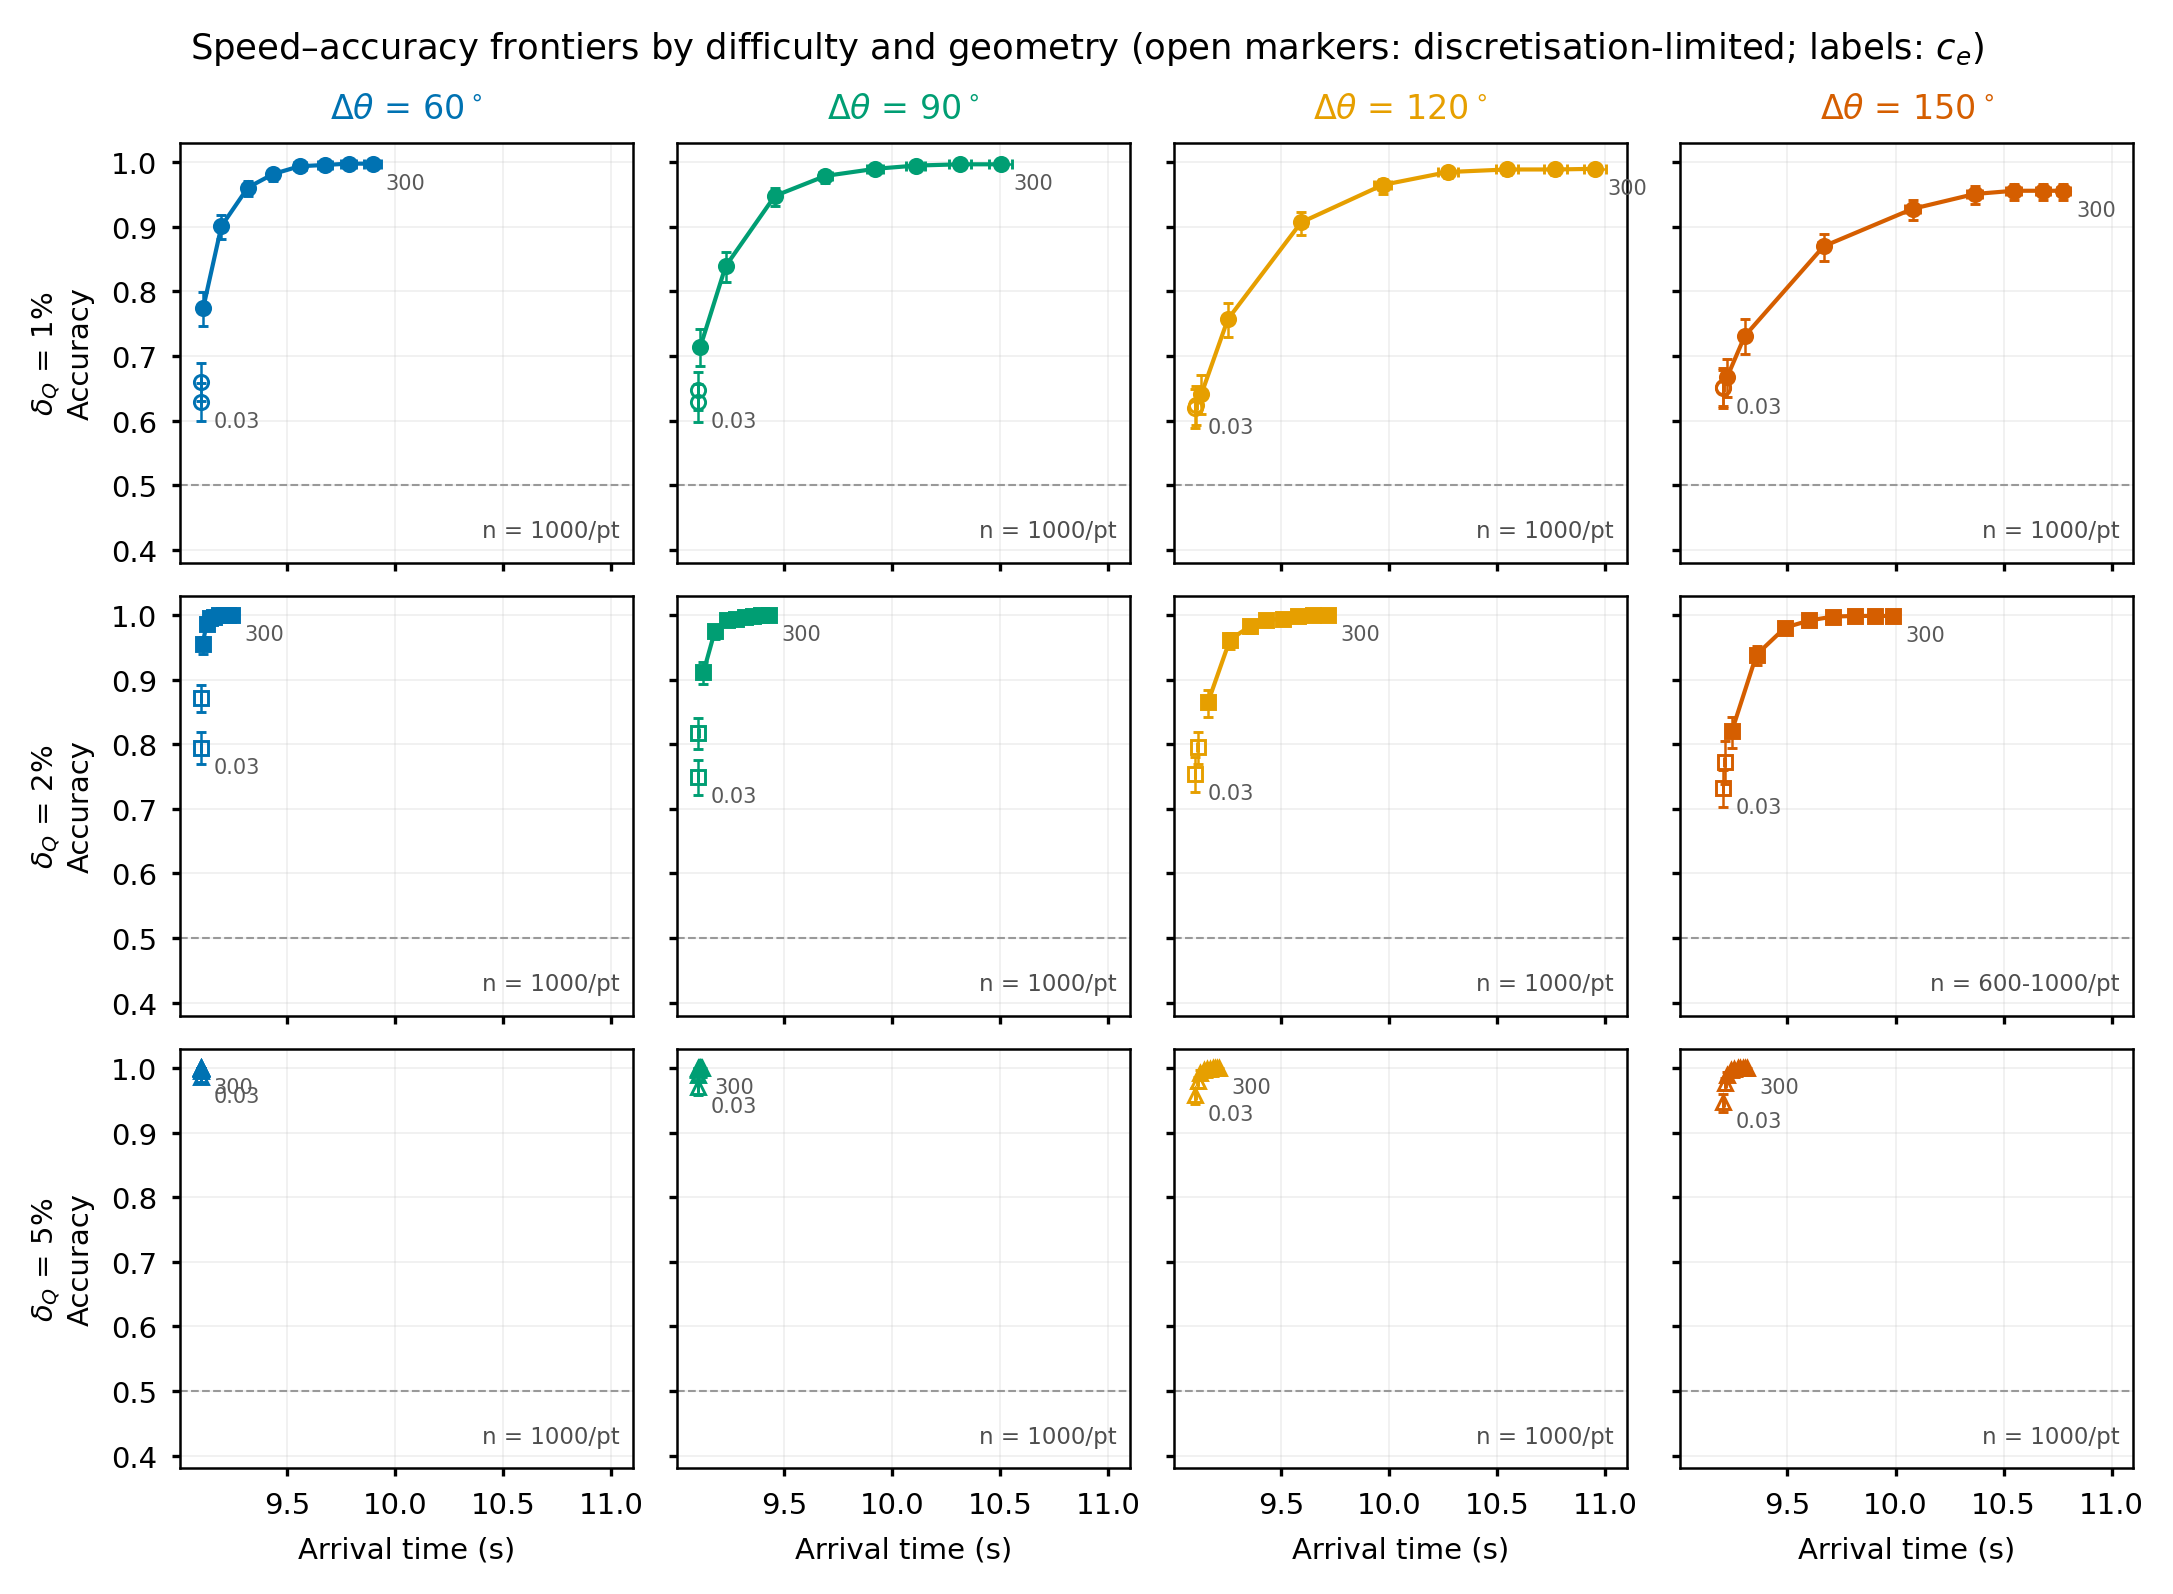

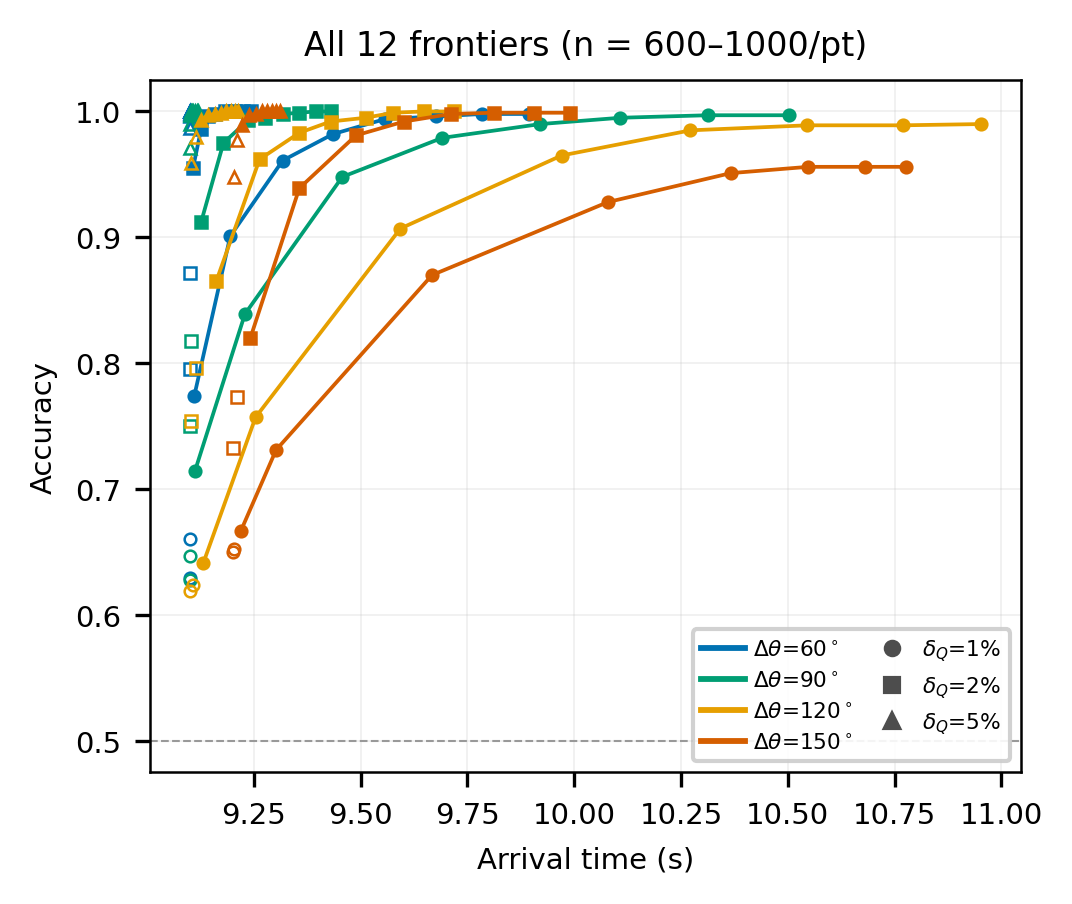

In [42]:
# ANALYSIS_SPEC 4.1 — Figure 1: speed-accuracy frontiers by geometry.
# 3 x 4 grid (rows dQ, columns dtheta), accuracy vs ARRIVAL time, one point per
# criterion, SHARED axes (the between-panel comparison is the point). Wilson CIs
# vertical, bootstrap CIs horizontal. Discretisation-limited points are OPEN
# markers, never on the fitted line. Plus a single-panel overlay for the paper.
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as sps

CAMPAIGN_ROOT = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/ddm-characterisation")
FIG_DIR = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Okabe-Ito, fixed order by dtheta; validated colourblind-safe (adjacent-pair CVD
# dE >= 8.6). Marker shape carries dQ so no identity is colour-alone.
THETA_COLOR = {60: "#0072B2", 90: "#009E73", 120: "#E69F00", 150: "#D55E00"}
DQ_MARKER = {0.01: "o", 0.02: "s", 0.05: "^"}


def wilson_ci(k, n, conf=0.95):
    if n == 0:
        return 0.0, 1.0
    z = sps.norm.ppf(0.5 + conf / 2)
    p, den = k / n, 1 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(centre - half, 0.0), min(centre + half, 1.0)


def boot_ci(x, n_boot=10_000, conf=0.95, seed=0):
    x = np.asarray(x, dtype=float)
    idx = np.random.default_rng(seed).integers(0, x.size, (n_boot, x.size))
    return tuple(np.percentile(x[idx].mean(axis=1),
                               [100 * (0.5 - conf / 2), 100 * (0.5 + conf / 2)]))


def save_fig(fig, name, payload):
    """Section 7: vector PDF + 300 dpi PNG + sidecar JSON with the plotted data."""
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300)
    payload["analysis_commit"] = subprocess.run(
        ["git", "rev-parse", "HEAD"], capture_output=True, text=True,
        cwd="/home/sindiso/Documents/PhD/ring-attractor/CollectiPy").stdout.strip()
    (FIG_DIR / f"{name}.json").write_text(json.dumps(payload, indent=1, default=float))
    print(f"wrote {FIG_DIR / name}.{{pdf,png,json}}")


trials = pd.read_parquet(CAMPAIGN_ROOT / "tidy_trials.parquet")
main = trials[trials.arm == "main"]

cells = []
for (dq, dth, ce), g in main.groupby(["dQ", "dtheta", "c_e"], sort=True):
    k = int(g.correct.sum())
    wlo, whi = wilson_ci(k, len(g))
    blo, bhi = boot_ci(g.arrival_time.values, seed=hash((dq, dth, ce)) % 2**31)
    cells.append(dict(dQ=dq, dtheta=dth, c_e=ce, n=len(g), acc=k / len(g),
                      wlo=wlo, whi=whi, arr=g.arrival_time.mean(), blo=blo, bhi=bhi,
                      flag=bool(g.discretisation_limited.iloc[0])))
cells = pd.DataFrame(cells)

# figure.dpi scales the INLINE render only (3x the notebook default of 100);
# the saved PDFs keep their true ICRA print geometry and 7 pt fonts.
plt.rcParams.update({"font.size": 7, "axes.linewidth": 0.6, "figure.dpi": 300})
DQS, DTHS = [0.01, 0.02, 0.05], [60, 90, 120, 150]
fig, axes = plt.subplots(3, 4, figsize=(7.13, 5.2), sharex=True, sharey=True,
                         constrained_layout=True)
for i, dq in enumerate(DQS):
    for j, dth in enumerate(DTHS):
        ax = axes[i][j]
        sub = cells[(cells.dQ == dq) & (cells.dtheta == dth)].sort_values("c_e")
        col, mk = THETA_COLOR[dth], DQ_MARKER[dq]
        good, bad = sub[~sub.flag], sub[sub.flag]
        # the frontier line runs through the UNFLAGGED points only
        ax.plot(good.arr, good.acc, color=col, lw=1.0, zorder=2)
        for part, face in ((good, col), (bad, "none")):
            ax.errorbar(part.arr, part.acc,
                        yerr=[part.acc - part.wlo, part.whi - part.acc],
                        xerr=[part.arr - part.blo, part.bhi - part.arr],
                        fmt=mk, ms=3.4, color=col, markerfacecolor=face,
                        markeredgewidth=0.7, elinewidth=0.6, capsize=1.2,
                        linestyle="none", zorder=3)
        for _, r in sub.iloc[[0, -1]].iterrows():   # sweep direction, lightly
            ax.annotate(f"{r.c_e:g}", (r.arr, r.acc), textcoords="offset points",
                        xytext=(3, -6), fontsize=5, color="0.35")
        ax.axhline(0.5, color="0.6", lw=0.5, ls="--")
        n_txt = ("n = 1000/pt" if (sub.n == 1000).all()
                 else f"n = {sub.n.min()}-{sub.n.max()}/pt")
        ax.text(0.97, 0.06, n_txt, transform=ax.transAxes, ha="right", fontsize=5.5,
                color="0.3")
        if i == 0:
            ax.set_title(f"$\\Delta\\theta$ = {dth}$^\\circ$", fontsize=8,
                         color=col)
        if i == 2:
            ax.set_xlabel("Arrival time (s)")
        if j == 0:
            ax.set_ylabel(f"$\\delta_Q$ = {dq:.0%}\nAccuracy")
        ax.grid(True, alpha=0.2, lw=0.4)
        ax.tick_params(length=2)
axes[0][0].set_ylim(0.38, 1.03)
fig.suptitle("Speed–accuracy frontiers by difficulty and geometry "
             "(open markers: discretisation-limited; labels: $c_e$)", fontsize=8.5)
save_fig(fig, "fig1_frontiers",
         {"panel_grid": "rows dQ x cols dtheta", "cells": cells.to_dict("records")})
plt.show()

# --- single-panel overlay (paper fallback if space is tight) --------------------
fig, ax = plt.subplots(figsize=(3.46, 2.9), constrained_layout=True)
for dth in DTHS:
    for dq in DQS:
        sub = cells[(cells.dQ == dq) & (cells.dtheta == dth)].sort_values("c_e")
        good, bad = sub[~sub.flag], sub[sub.flag]
        ax.plot(good.arr, good.acc, color=THETA_COLOR[dth], lw=0.9,
                marker=DQ_MARKER[dq], ms=2.8, markerfacecolor=THETA_COLOR[dth],
                markeredgewidth=0.6)
        ax.plot(bad.arr, bad.acc, color=THETA_COLOR[dth], lw=0, marker=DQ_MARKER[dq],
                ms=2.8, markerfacecolor="none", markeredgewidth=0.6)
ax.axhline(0.5, color="0.6", lw=0.5, ls="--")
ax.set_xlabel("Arrival time (s)")
ax.set_ylabel("Accuracy")
handles = ([plt.Line2D([], [], color=THETA_COLOR[t], lw=1.4,
                       label=f"$\\Delta\\theta$={t}$^\\circ$") for t in DTHS]
           + [plt.Line2D([], [], color="0.3", lw=0, marker=DQ_MARKER[q], ms=3.2,
                         markerfacecolor="0.3", label=f"$\\delta_Q$={q:.0%}")
              for q in DQS])
ax.legend(handles=handles, fontsize=5.2, ncol=2, loc="lower right",
          framealpha=0.9, borderpad=0.4, handletextpad=0.4, columnspacing=0.8)
ax.grid(True, alpha=0.2, lw=0.4)
ax.set_title("All 12 frontiers (n = 600–1000/pt)", fontsize=8)
#save_fig(fig, "fig1_overlay", {"cells": cells.to_dict("records")})
plt.show()

## Figure 2 — the geometry effect (spec 4.2, headline)

**Does the cost of deliberating depend on where the targets are?** Three panels
against `c_tau(0) = 1 - cos(dtheta/2)`, with `T_max` annotated on (a) because the two
mechanisms **covary by construction** — a wider separation makes each second of
deliberation costlier *and* leaves fewer of them — and this campaign cannot separate
them (a fixed-`T_max` sweep varying `d` alongside `dtheta` would; flagged as a
limitation).

- **(a)** best achievable accuracy falls with `c_tau` only at `dQ = 1%`
  (0.998 -> 0.956); at 2% and 5% the task is too easy for geometry to bite.
- **(b)** embodied regret at matched accuracy 0.90: arrival excess over the oracle —
  which drives straight and, like every trial, finishes at the 0.05 m termination
  radius, so the oracle is 9.0 s, not 10 — rises from 0.19 s to 0.88 s across the
  geometry at `dQ = 1%`.
- **(c)** the spec's literal formula (minimise `c_tau*DT + c_e*ER` over the sweep's
  own `c_e`) is **degenerate** — both terms vanish together as `c_e -> 0`, so the
  argmin is always the smallest criterion (verified: 0.03 in all 12 cells). The
  non-degenerate rendering of the same question is **self-consistency**: under a fixed
  evaluation price `c*`, the regret-minimising operating point should be `c_e = c*`
  at every geometry. It tracks the diagonal at 60 deg but caps early at wide
  separations — at 150 deg no operating point above `c_e = 50` ever pays for itself.

wrote /home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation/fig2_geometry.{pdf,png,json}


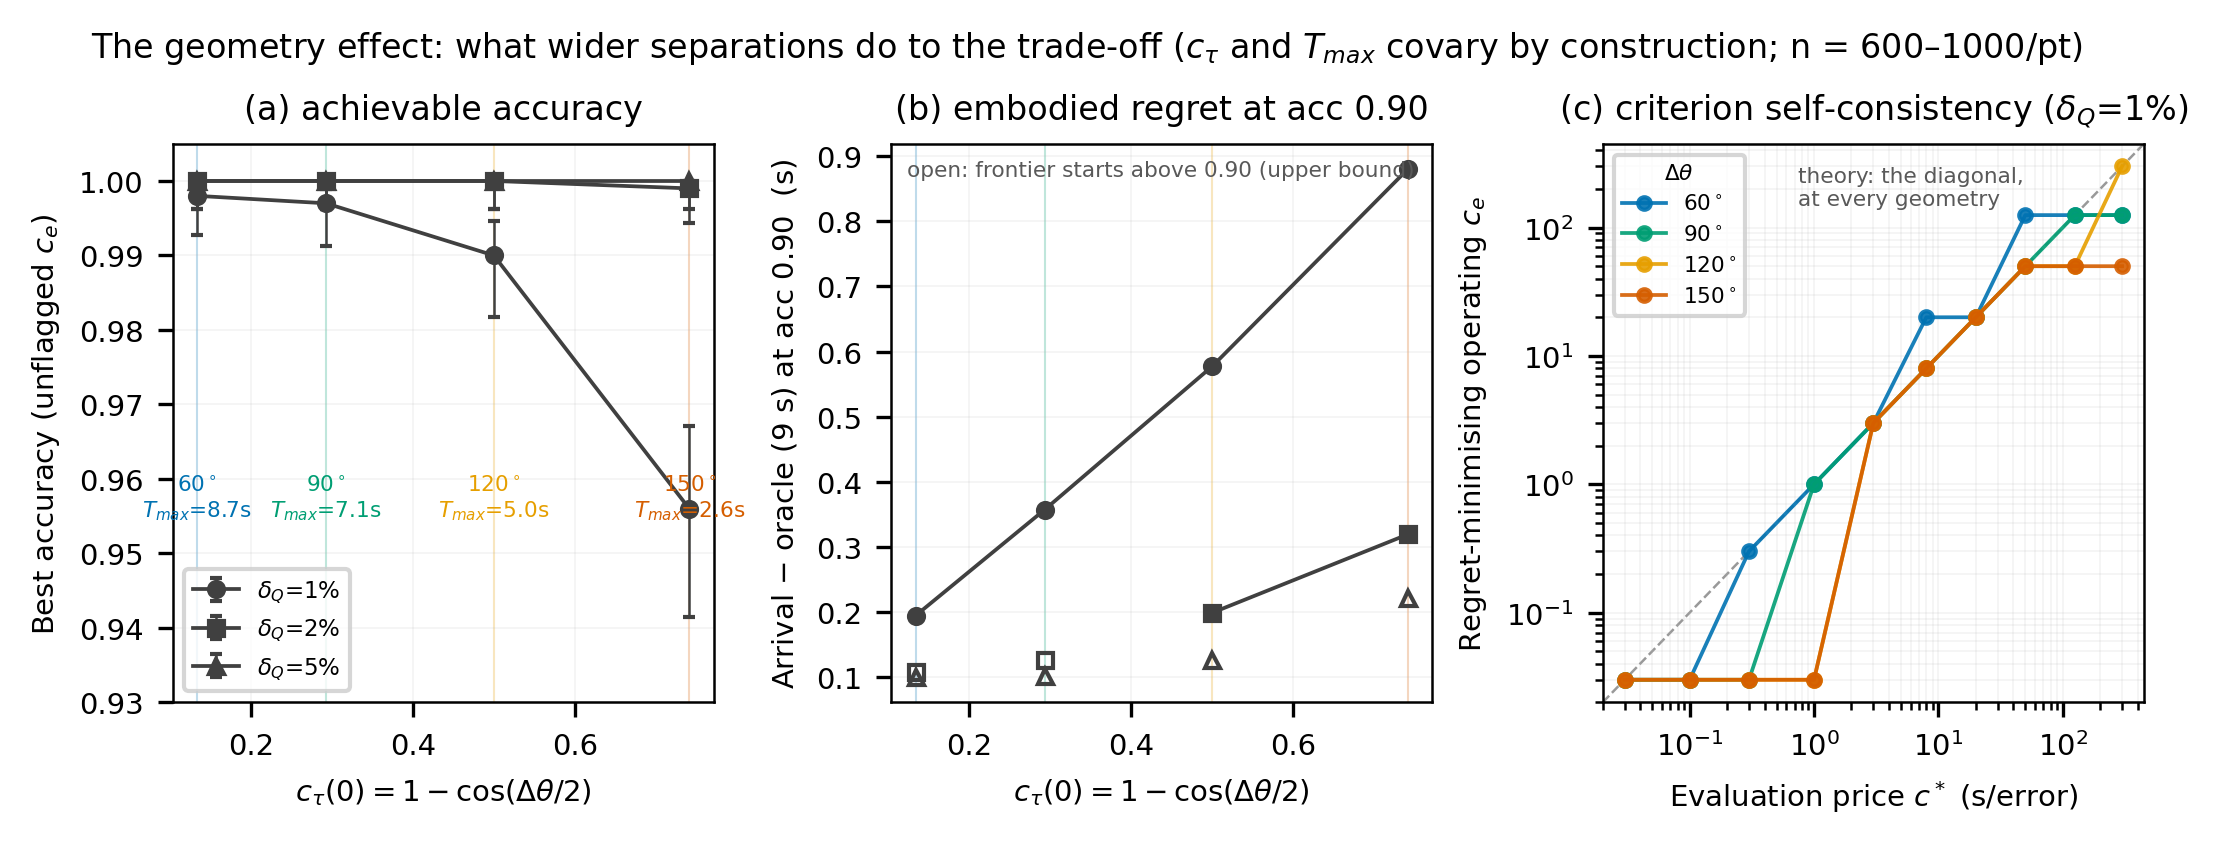

  dQ  dtheta   c_tau0  c_star  c_e_opt    regret
0.01      60 0.133975    0.03     0.03  0.015962
0.01      60 0.133975    0.10     0.03  0.041932
0.01      60 0.133975    0.30     0.30  0.114391
0.01      60 0.133975    1.00     1.00  0.225643
0.01      60 0.133975    3.00     3.00  0.327928
0.01      60 0.133975    8.00    20.00  0.388903
0.01      60 0.133975   20.00    20.00  0.460903
0.01      60 0.133975   50.00   125.00  0.544477
0.01      60 0.133975  125.00   125.00  0.694477
0.01      60 0.133975  300.00   125.00  1.044477
0.01      90 0.292893    0.03     0.03  0.015328
0.01      90 0.292893    0.10     0.03  0.041368
0.01      90 0.292893    0.30     0.03  0.115768
0.01      90 0.292893    1.00     1.00  0.319069
0.01      90 0.292893    3.00     3.00  0.492273
0.01      90 0.292893    8.00     8.00  0.665741
0.01      90 0.292893   20.00    20.00  0.840675
0.01      90 0.292893   50.00    50.00  1.002507
0.01      90 0.292893  125.00   125.00  1.238885
0.01      90 0.29289

In [43]:
# ANALYSIS_SPEC 4.2 — Figure 2: the geometry effect (headline).
# (a) best achievable accuracy vs c_tau(0)   (b) excess arrival over an oracle at
# matched accuracy 0.90   (c) the criterion minimising measured regret.
# c_tau and T_max COVARY by construction (wider separation = costlier second AND
# fewer of them); T_max is annotated so the confound is visible, not buried.
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as sps

CAMPAIGN_ROOT = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/ddm-characterisation")
FIG_DIR = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation")
THETA_COLOR = {60: "#0072B2", 90: "#009E73", 120: "#E69F00", 150: "#D55E00"}
DQ_MARKER = {0.01: "o", 0.02: "s", 0.05: "^"}
ORACLE_S = (0.5 - 0.05) / 0.05   # (d - termination radius) / v: the oracle
# knew at t = 0 and drove straight; its run ENDS at the 0.05 m proximity
# radius, exactly as every measured trial does


def wilson_ci(k, n, conf=0.95):
    if n == 0:
        return 0.0, 1.0
    z = sps.norm.ppf(0.5 + conf / 2)
    p, den = k / n, 1 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(centre - half, 0.0), min(centre + half, 1.0)


def save_fig(fig, name, payload):
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300)
    payload["analysis_commit"] = subprocess.run(
        ["git", "rev-parse", "HEAD"], capture_output=True, text=True,
        cwd="/home/sindiso/Documents/PhD/ring-attractor/CollectiPy").stdout.strip()
    (FIG_DIR / f"{name}.json").write_text(json.dumps(payload, indent=1, default=float))
    print(f"wrote {FIG_DIR / name}.{{pdf,png,json}}")


trials = pd.read_parquet(CAMPAIGN_ROOT / "tidy_trials.parquet")
main = trials[trials.arm == "main"]
agg = (main.groupby(["dQ", "dtheta", "c_e"], sort=True)
       .agg(n=("correct", "size"), k=("correct", "sum"), acc=("correct", "mean"),
            arr=("arrival_time", "mean"), dt=("commit_time", "mean"),
            c_tau0=("c_tau0", "first"), T_max=("T_max", "first"),
            flag=("discretisation_limited", "first"))
       .reset_index())
best_rows, excess_rows, opt_rows = [], [], []
for (dq, dth), g in agg.groupby(["dQ", "dtheta"]):
    good = g[~g.flag].sort_values("c_e")
    b = good.loc[good.acc.idxmax()]
    blo, bhi = wilson_ci(int(b.k), int(b.n))
    best_rows.append(dict(dQ=dq, dtheta=dth, c_tau0=b.c_tau0, T_max=b.T_max,
                          acc=b.acc, lo=blo, hi=bhi, c_e=b.c_e))
    # (b) — interpolate arrival(accuracy) to 0.90 along the unflagged frontier.
    # A cell whose whole frontier already exceeds 0.90 reaches it at its fastest
    # measured point; that point is an upper BOUND, drawn open.
    acc_sorted = good.sort_values("acc")
    if good.acc.min() <= 0.90 <= good.acc.max():
        arr90 = float(np.interp(0.90, acc_sorted.acc, acc_sorted.arr))
        bound = False
    elif good.acc.min() > 0.90:
        arr90, bound = float(good.arr.min()), True
    else:
        arr90, bound = np.nan, False       # never reaches 0.90 — omitted, stated
    excess_rows.append(dict(dQ=dq, dtheta=dth, c_tau0=b.c_tau0,
                            excess=arr90 - ORACLE_S, bound=bound))
    # (c) — the spec's literal formula (minimise c_tau*DT + c_e*ER with c_e the
    # sweep variable) is DEGENERATE: both terms vanish together as c_e -> 0, so
    # the argmin is always the smallest criterion (verified: 0.03 in all 12
    # cells). The non-degenerate rendering of the same question: under a FIXED
    # evaluation price c*, which operating point minimises measured regret
    # c_tau*DT(c_e) + c* * ER(c_e)? The theory says the point labelled c_e = c*,
    # for every geometry; panel (c) tests that self-consistency.
    for c_star in g.c_e.sort_values():
        regret_at = g.c_tau0 * g.dt + c_star * (1 - g.acc)
        o = g.loc[regret_at.idxmin()]
        opt_rows.append(dict(dQ=dq, dtheta=dth, c_tau0=o.c_tau0, c_star=c_star,
                             c_e_opt=o.c_e, regret=float(regret_at.min())))
best, excess, opt = map(pd.DataFrame, (best_rows, excess_rows, opt_rows))

# figure.dpi scales the INLINE render only (3x the notebook default of 100);
# the saved PDFs keep their true ICRA print geometry and 7 pt fonts.
plt.rcParams.update({"font.size": 7, "axes.linewidth": 0.6, "figure.dpi": 300})
fig, axes = plt.subplots(1, 3, figsize=(7.13, 2.7), constrained_layout=True)
for dq in [0.01, 0.02, 0.05]:
    mk = DQ_MARKER[dq]
    b = best[best.dQ == dq].sort_values("c_tau0")
    axes[0].errorbar(b.c_tau0, b.acc, yerr=[b.acc - b.lo, b.hi - b.acc], fmt=mk,
                     ms=3.6, color="0.25", markerfacecolor="0.25", lw=0.9, ls="-",
                     elinewidth=0.6, capsize=1.4, label=f"$\\delta_Q$={dq:.0%}")
    e = excess[excess.dQ == dq].sort_values("c_tau0")
    solid = e[~e.bound]
    axes[1].plot(solid.c_tau0, solid.excess, ls="-", lw=0.9, marker=mk, ms=3.6,
                 color="0.25", markerfacecolor="0.25")
    axes[1].plot(e[e.bound].c_tau0, e[e.bound].excess, ls="none", marker=mk,
                 ms=3.6, color="0.25", markerfacecolor="none")
if True:   # (c) is drawn once, for the hardest difficulty, one line per geometry
    o1 = opt[opt.dQ == 0.01]
    for dth in [60, 90, 120, 150]:
        oo = o1[o1.dtheta == dth].sort_values("c_star")
        axes[2].plot(oo.c_star, oo.c_e_opt, ls="-", lw=0.9, marker="o", ms=3.0,
                     color=THETA_COLOR[dth], markerfacecolor=THETA_COLOR[dth],
                     alpha=0.9, label=f"{dth}$^\circ$")
    lims = [0.02, 450]
    axes[2].plot(lims, lims, ls="--", lw=0.6, color="0.6", zorder=0)
    axes[2].set_xscale("log")
    axes[2].set_xlim(*lims); axes[2].set_ylim(*lims)
    axes[2].legend(fontsize=5.2, loc="upper left", title="$\\Delta\\theta$",
                   title_fontsize=5.2)
for ax in axes[:2]:                          # geometry ticks, coloured by dtheta
    for dth, ct in sorted({(r.dtheta, r.c_tau0) for r in best.itertuples()}):
        ax.axvline(ct, color=THETA_COLOR[dth], lw=0.5, alpha=0.25, zorder=0)
    ax.grid(True, alpha=0.15, lw=0.4)
    ax.set_xlabel("$c_\\tau(0) = 1-\\cos(\\Delta\\theta/2)$")
axes[2].grid(True, alpha=0.15, lw=0.4, which="both")
for r in best[best.dQ == 0.01].itertuples():   # the confound, annotated (a)
    axes[0].annotate(f"{r.dtheta:g}$^\\circ$\n$T_{{max}}$={r.T_max:.1f}s",
                     (r.c_tau0, 0.955), ha="center", fontsize=5.2,
                     color=THETA_COLOR[r.dtheta])
axes[0].set_ylabel("Best accuracy (unflagged $c_e$)")
axes[0].set_ylim(0.93, 1.005)
axes[0].set_title("(a) achievable accuracy", fontsize=8)
axes[0].legend(fontsize=5.5, loc="lower left")
axes[1].set_ylabel(f"Arrival $-$ oracle ({ORACLE_S:.0f} s) at acc 0.90  (s)")
axes[1].set_title("(b) embodied regret at acc 0.90", fontsize=8)
axes[1].text(0.03, 0.97, "open: frontier starts above 0.90 (upper bound)",
             transform=axes[1].transAxes, va="top", fontsize=5.2, color="0.35")
axes[2].set_yscale("log")
axes[2].set_xlabel("Evaluation price $c^*$ (s/error)")
axes[2].set_ylabel("Regret-minimising operating $c_e$")
axes[2].set_title("(c) criterion self-consistency ($\\delta_Q$=1%)",
                  fontsize=8)
axes[2].text(0.36, 0.96, "theory: the diagonal,\nat every geometry",
             transform=axes[2].transAxes, va="top", fontsize=5.2, color="0.35")
fig.suptitle("The geometry effect: what wider separations do to the trade-off "
             "($c_\\tau$ and $T_{max}$ covary by construction; n = 600–1000/pt)",
             fontsize=8)
save_fig(fig, "fig2_geometry", {"best": best.to_dict("records"),
                                "excess": excess.to_dict("records"),
                                "optimal": opt.to_dict("records")})
plt.show()
print(opt.to_string(index=False))

## Figure 3 — reaction-time distributions (spec 4.3)

**(a)** ECDFs at a fast / middle / slow criterion, baseline cell: right-skewed
throughout (skew +0.8 to +1.5), the first-passage signature.

**(b)** the diagnostic that matters: error RT minus correct RT. Equal under a
constant boundary; the spec expected *faster* errors under a collapsing one. The
measurement disagrees with that expected **direction**: errors are *slower*, by an
amount that grows with `c_e` (+9 ms at `c_e = 0.03`, CI excluding zero, to +0.75 s at
`c_e = 8`, borderline) — and the sign is in fact the one a collapsing boundary
produces here: late crossings happen on a *lower* boundary and are therefore
near-chance, so errors concentrate late. What the panel rules out is a
time-homogeneous (static-boundary, fixed-drift) account, under which the two
distributions would be identical. Cells with fewer than 5 errors are skipped and
named — at `c_e >= 50` accuracy is too high to measure the difference at n = 1000.

wrote /home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation/fig3_rt.{pdf,png,json}


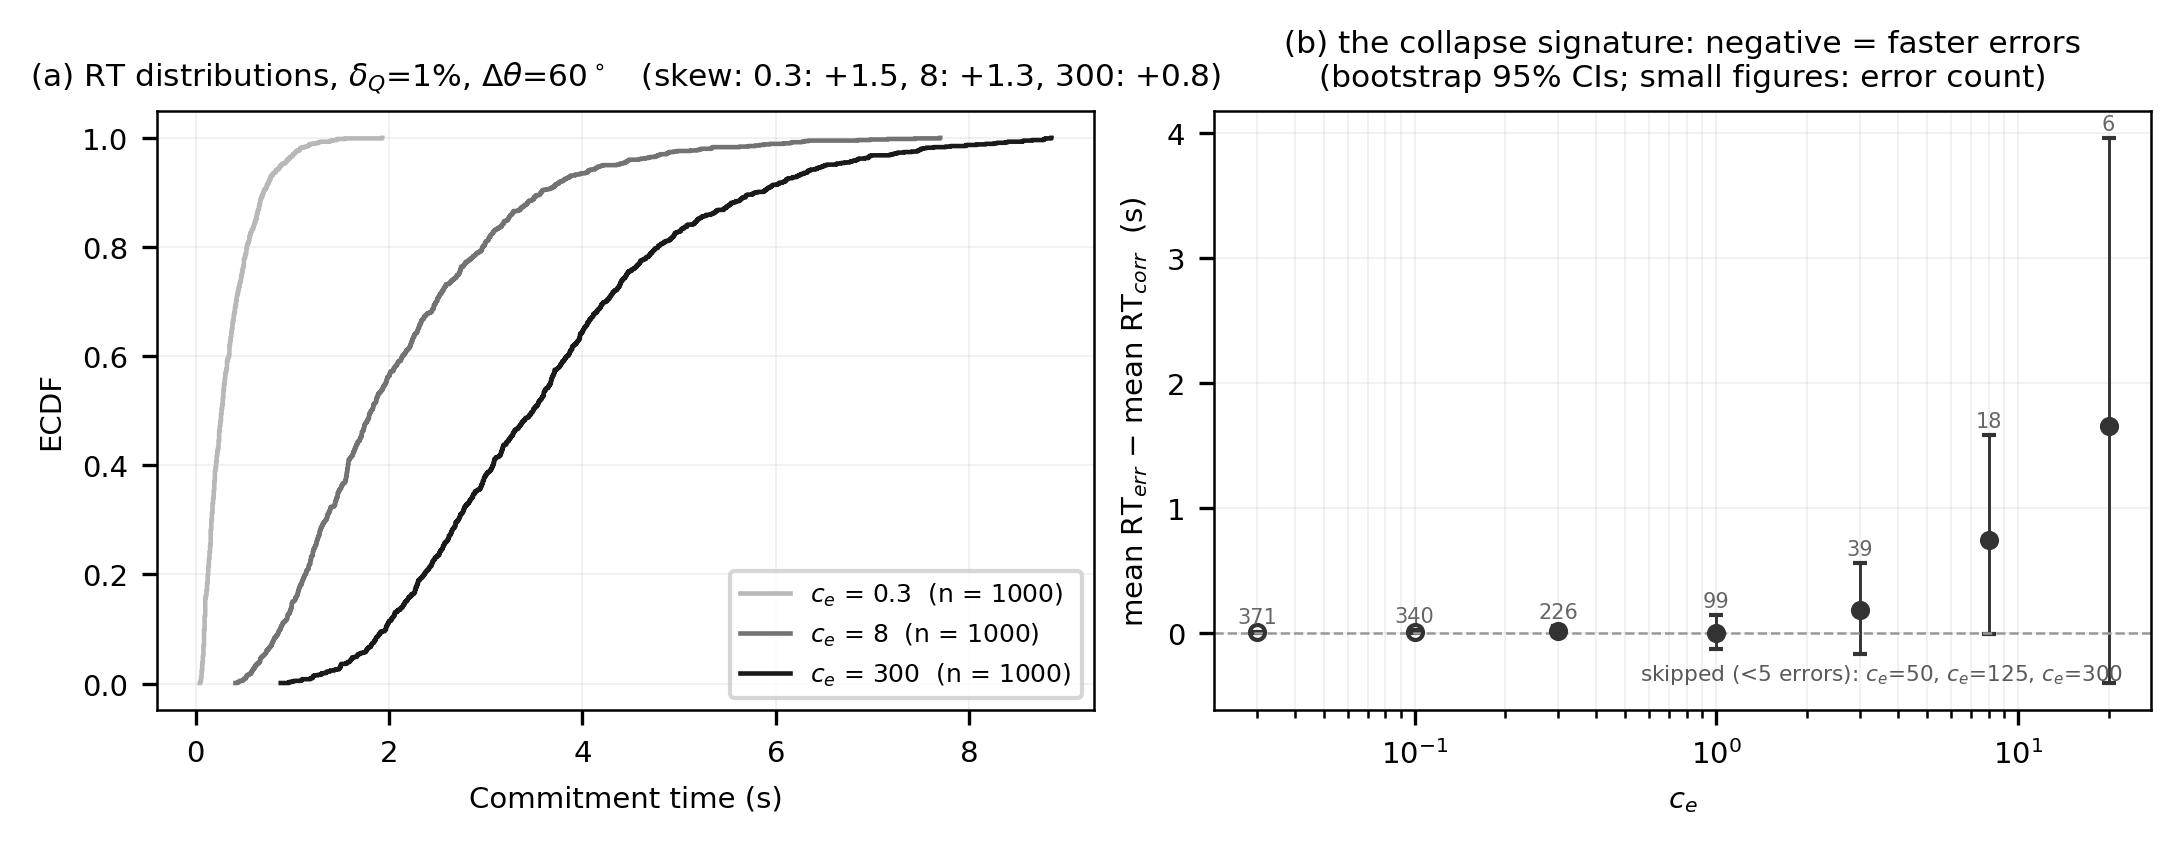

   c_e  n_err  skipped     d_rt        lo       hi  flag
  0.03    371    False 0.008703  0.003717 0.013722  True
  0.10    340    False 0.012170  0.000587 0.024102  True
  0.30    226    False 0.018834 -0.019196 0.058383 False
  1.00     99    False 0.007276 -0.123700 0.147332 False
  3.00     39    False 0.184574 -0.163881 0.561352 False
  8.00     18    False 0.751300 -0.002705 1.587989 False
 20.00      6    False 1.661270 -0.395982 3.963906 False
 50.00      4     True      NaN       NaN      NaN False
125.00      2     True      NaN       NaN      NaN False
300.00      2     True      NaN       NaN      NaN False


In [44]:
# ANALYSIS_SPEC 4.3 — Figure 3: reaction-time distributions at the baseline cell.
# (a) RT ECDFs at a fast / middle / slow criterion (ECDFs, not histograms).
# (b) THE diagnostic: error RT minus correct RT across the criterion grid.
#     Equal under a constant boundary; FASTER ERRORS under a collapsing one —
#     the direct behavioural test that the boundary genuinely collapses.
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CAMPAIGN_ROOT = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/ddm-characterisation")
FIG_DIR = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation")
BASE_Q, BASE_TH = 0.01, 60
ECDF_CES = [0.3, 8, 300]                     # fast / middle / slow, all unflagged
MIN_ERRORS = 5                               # below this a bootstrap CI is noise


def boot_ci_diff(a, b, n_boot=10_000, conf=0.95, seed=0):
    a, b = np.asarray(a, float), np.asarray(b, float)
    rng = np.random.default_rng(seed)
    d = (a[rng.integers(0, a.size, (n_boot, a.size))].mean(axis=1)
         - b[rng.integers(0, b.size, (n_boot, b.size))].mean(axis=1))
    return tuple(np.percentile(d, [100 * (0.5 - conf / 2), 100 * (0.5 + conf / 2)]))


def save_fig(fig, name, payload):
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300)
    payload["analysis_commit"] = subprocess.run(
        ["git", "rev-parse", "HEAD"], capture_output=True, text=True,
        cwd="/home/sindiso/Documents/PhD/ring-attractor/CollectiPy").stdout.strip()
    (FIG_DIR / f"{name}.json").write_text(json.dumps(payload, indent=1, default=float))
    print(f"wrote {FIG_DIR / name}.{{pdf,png,json}}")


trials = pd.read_parquet(CAMPAIGN_ROOT / "tidy_trials.parquet")
base = trials[(trials.arm == "main") & (trials.dQ == BASE_Q)
              & (trials.dtheta == BASE_TH)]

# figure.dpi scales the INLINE render only (3x the notebook default of 100);
# the saved PDFs keep their true ICRA print geometry and 7 pt fonts.
plt.rcParams.update({"font.size": 7, "axes.linewidth": 0.6, "figure.dpi": 300})
fig, axes = plt.subplots(1, 2, figsize=(7.13, 2.7), constrained_layout=True)

# --- (a) ECDFs ------------------------------------------------------------------
shade = {0.3: "0.72", 8: "0.45", 300: "0.1"}     # one hue, darkness = slowness
skew_note = []
for ce in ECDF_CES:
    rt = np.sort(base[base.c_e == ce].commit_time.values)
    axes[0].step(rt, np.arange(1, rt.size + 1) / rt.size, where="post",
                 color=shade[ce], lw=1.1, label=f"$c_e$ = {ce:g}  (n = {rt.size})")
    skew_note.append((ce, float(pd.Series(rt).skew())))
axes[0].set_xlabel("Commitment time (s)")
axes[0].set_ylabel("ECDF")
axes[0].set_title(f"(a) RT distributions, $\\delta_Q$={BASE_Q:.0%}, "
                  f"$\\Delta\\theta$={BASE_TH}$^\\circ$   "
                  f"(skew: {', '.join(f'{c:g}: {s:+.1f}' for c, s in skew_note)})",
                  fontsize=7.5)
axes[0].legend(fontsize=6, loc="lower right")
axes[0].grid(True, alpha=0.2, lw=0.4)

# --- (b) error-vs-correct RT across the grid ------------------------------------
rows = []
for ce, g in base.groupby("c_e"):
    err = g.loc[~g.correct, "commit_time"].values
    cor = g.loc[g.correct, "commit_time"].values
    if err.size < MIN_ERRORS:
        rows.append(dict(c_e=ce, n_err=int(err.size), skipped=True,
                         d_rt=np.nan, lo=np.nan, hi=np.nan,
                         flag=bool(g.discretisation_limited.iloc[0])))
        continue
    lo, hi = boot_ci_diff(err, cor, seed=int(ce * 1000) % 2**31)
    rows.append(dict(c_e=ce, n_err=int(err.size), skipped=False,
                     d_rt=float(err.mean() - cor.mean()), lo=lo, hi=hi,
                     flag=bool(g.discretisation_limited.iloc[0])))
rt_diff = pd.DataFrame(rows).sort_values("c_e")
ok = rt_diff[~rt_diff.skipped]
for _, r in ok.iterrows():
    axes[1].errorbar([r.c_e], [r.d_rt], yerr=[[r.d_rt - r.lo], [r.hi - r.d_rt]],
                     fmt="o", ms=3.6, color="0.2",
                     markerfacecolor="none" if r.flag else "0.2",
                     elinewidth=0.7, capsize=1.6)
    axes[1].annotate(f"{r.n_err}", (r.c_e, r.hi), textcoords="offset points",
                     xytext=(0, 2), ha="center", fontsize=5, color="0.4")
skipped = rt_diff[rt_diff.skipped]
if len(skipped):
    axes[1].text(0.97, 0.05, "skipped (<" f"{MIN_ERRORS} errors): "
                 + ", ".join(f"$c_e$={c:g}" for c in skipped.c_e),
                 transform=axes[1].transAxes, ha="right", fontsize=5.2, color="0.35")
axes[1].axhline(0, color="0.6", lw=0.6, ls="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("$c_e$")
axes[1].set_ylabel("mean RT$_{err}$ $-$ mean RT$_{corr}$  (s)")
axes[1].set_title("(b) the collapse signature: negative = faster errors\n"
                  "(bootstrap 95% CIs; small figures: error count)", fontsize=7.5)
axes[1].grid(True, alpha=0.2, lw=0.4, which="both")
save_fig(fig, "fig3_rt", {"ecdf_skew": skew_note,
                          "rt_diff": rt_diff.to_dict("records")})
plt.show()
print(rt_diff.to_string(index=False))

## Figure 4 — what the Bellman policy buys (spec 4.4)

**Does solving the free-boundary problem beat the quasi-static approximation?**
Baseline cell, matched criterion grid, and genuinely paired: at the same
(replicate, `c_e`) both arms saw the identical sensory realisation, so the paired
per-replicate regret differences in (b) are far tighter than independent means.

**The answer is a null, and it is reported as one** — with the point estimates, if
anything, *favouring the quasi-static approximation* (the difference is negative,
i.e. quasi-static achieves lower measured regret, significantly so at `c_e = 1` and
`c_e = 8`; everywhere else the CI includes zero). This is the honest headline of the
control: at `DT/T_max` up to ~0.43, solving the full free-boundary problem buys
nothing here that re-evaluating the static optimum each tick does not, and the
horizon-truncated terminal collapse drags the Bellman boundary slightly low.

The companion panel shows why, mechanistically: the two boundaries only separate
appreciably in the last ~3 s of the horizon, and by then most decisions have already
terminated — the RT mass sits at 2–5 s, where the boundaries still nearly coincide.

The static (fixed-boundary) frontier is absent because its defining parameter was
never resolved (CAMPAIGN_SPEC 5.2); with `z_manual := z_bellman(0)` now available in
the precompute report, that arm can be run and dropped into this figure unchanged.

wrote /home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation/fig4_controls.{pdf,png,json}


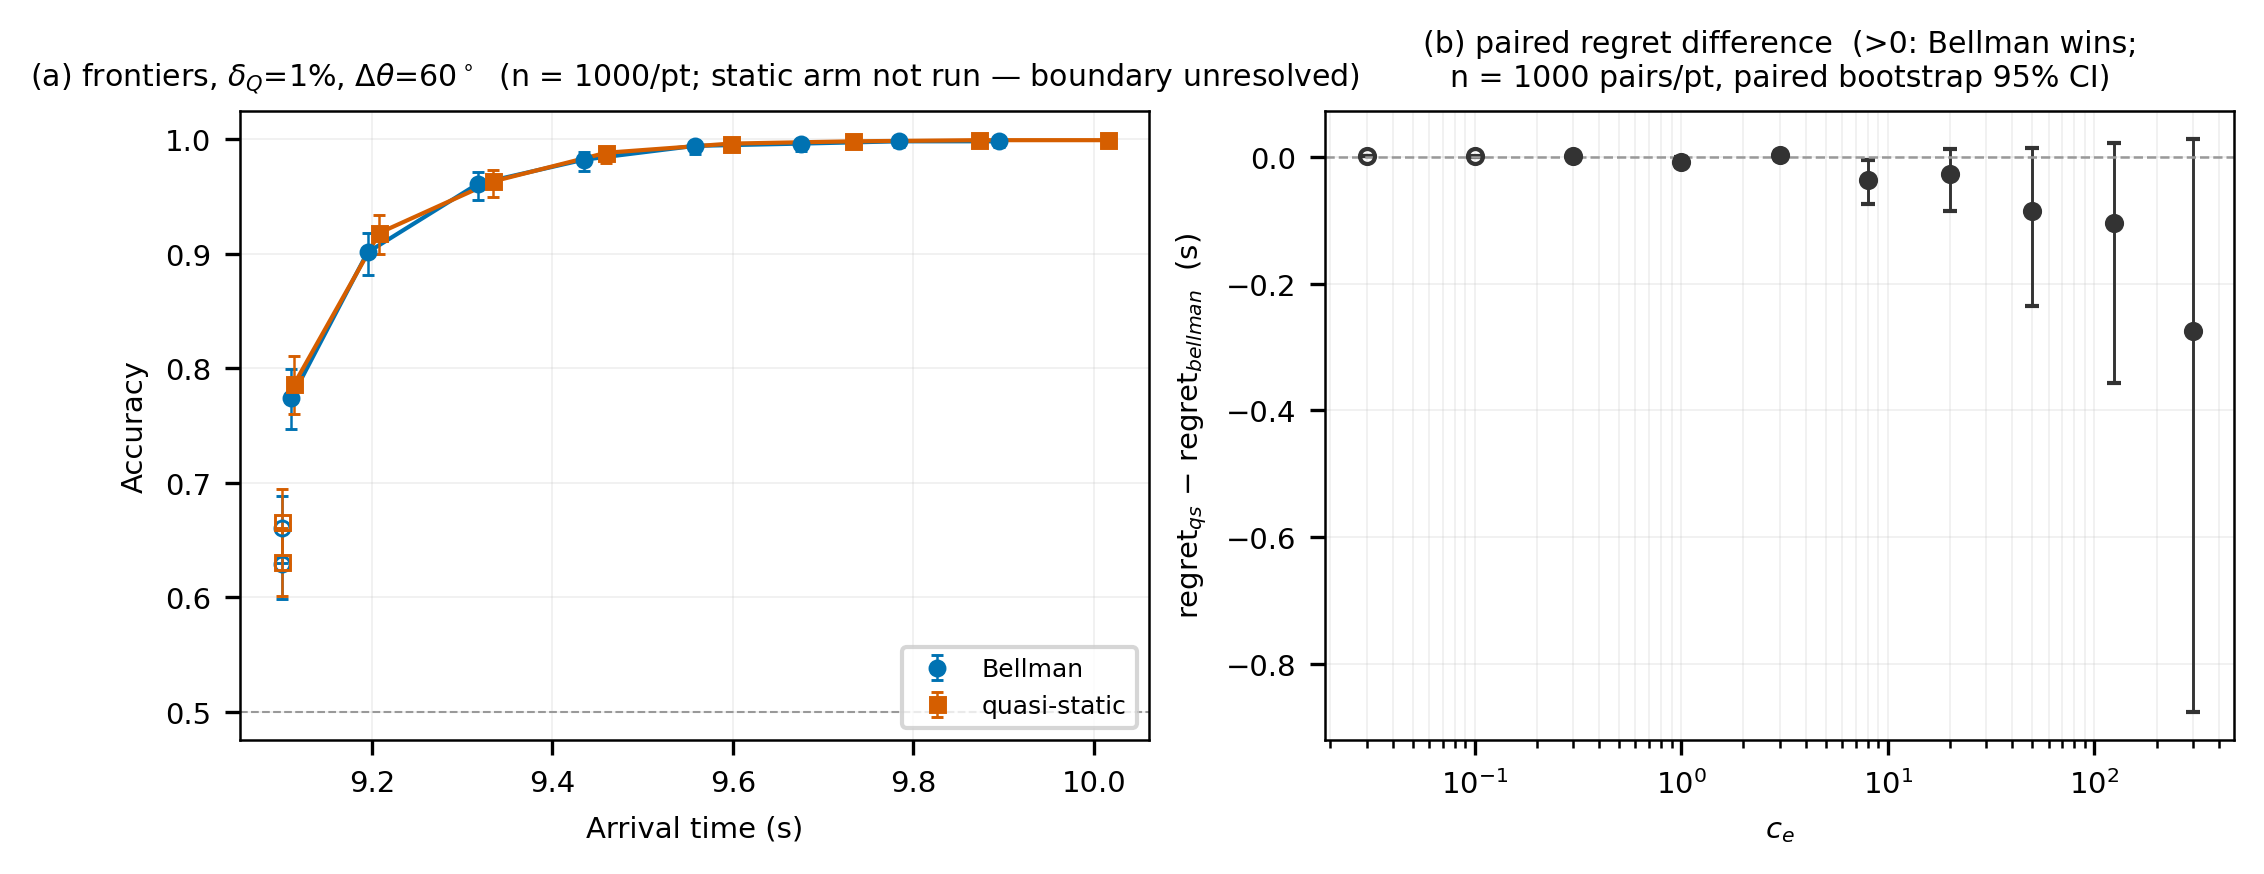

   c_e  n_pairs  d_regret        lo        hi  flag
  0.03     1000  0.001347  0.001065  0.001649  True
  0.10     1000  0.000880  0.000024  0.001753  True
  0.30     1000  0.000732 -0.001594  0.002969 False
  1.00     1000 -0.007476 -0.015499 -0.000376 False
  3.00     1000  0.003178 -0.005340  0.009153 False
  8.00     1000 -0.035740 -0.074551 -0.004452 False
 20.00     1000 -0.027370 -0.085702  0.011701 False
 50.00     1000 -0.085825 -0.235374  0.014345 False
125.00     1000 -0.105086 -0.356132  0.021917 False
300.00     1000 -0.274371 -0.875216  0.027848 False
wrote /home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation/fig4_boundaries.{pdf,png,json}


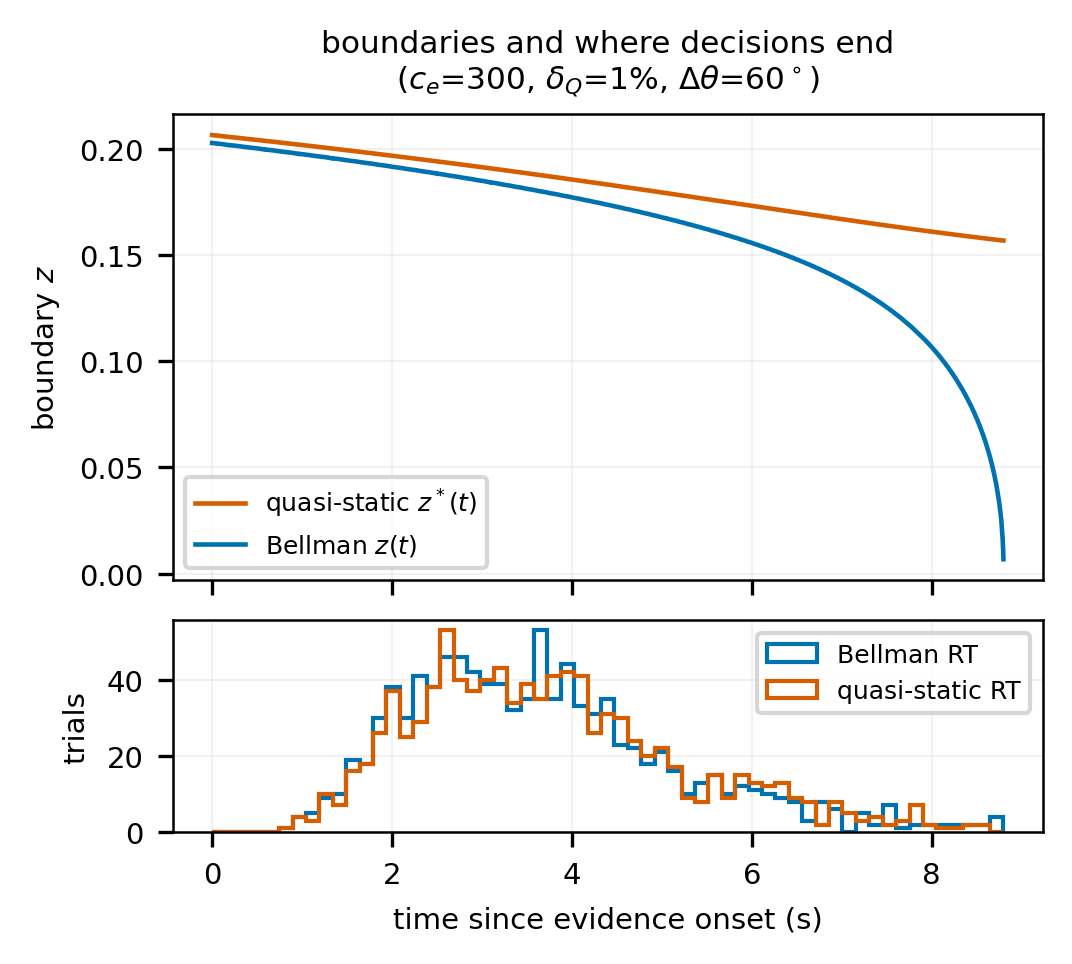

In [45]:
# ANALYSIS_SPEC 4.4 — Figure 4: what the Bellman policy buys over the quasi-static
# approximation. Baseline cell, matched criterion grid, PAIRED seeds (the sensory
# realisation is identical across the two arms at the same (replicate, c_e)).
# The STATIC arm did not run — its boundary is an unresolved methodological
# parameter (CAMPAIGN_SPEC 5.2) — so both panels carry two frontiers, and say so.
# A null result here is a result and is reported as one.
import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as sps

CAMPAIGN_ROOT = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/ddm-characterisation")
FIG_DIR = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation")
SRC = Path("/home/sindiso/Documents/PhD/ring-attractor/CollectiPy/src")
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
BASE_Q, BASE_TH = 0.01, 60
BOUNDARY_CE = 300          # deepest into the horizon: DT/T_max ~ 0.43
POLICY_STYLE = {"bellman": dict(color="#0072B2", marker="o", label="Bellman"),
                "geometric": dict(color="#D55E00", marker="s",
                                  label="quasi-static")}


def wilson_ci(k, n, conf=0.95):
    z = sps.norm.ppf(0.5 + conf / 2)
    p, den = k / n, 1 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(centre - half, 0.0), min(centre + half, 1.0)


def boot_ci_paired(d, n_boot=10_000, conf=0.95, seed=0):
    """Percentile CI on the mean of PAIRED per-replicate differences."""
    d = np.asarray(d, float)
    idx = np.random.default_rng(seed).integers(0, d.size, (n_boot, d.size))
    return tuple(np.percentile(d[idx].mean(axis=1),
                               [100 * (0.5 - conf / 2), 100 * (0.5 + conf / 2)]))


def save_fig(fig, name, payload):
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300)
    payload["analysis_commit"] = subprocess.run(
        ["git", "rev-parse", "HEAD"], capture_output=True, text=True,
        cwd="/home/sindiso/Documents/PhD/ring-attractor/CollectiPy").stdout.strip()
    (FIG_DIR / f"{name}.json").write_text(json.dumps(payload, indent=1, default=float))
    print(f"wrote {FIG_DIR / name}.{{pdf,png,json}}")


trials = pd.read_parquet(CAMPAIGN_ROOT / "tidy_trials.parquet")
base = trials[(trials.dQ == BASE_Q) & (trials.dtheta == BASE_TH)]
c_tau0 = base.c_tau0.iloc[0]

# figure.dpi scales the INLINE render only (3x the notebook default of 100);
# the saved PDFs keep their true ICRA print geometry and 7 pt fonts.
plt.rcParams.update({"font.size": 7, "axes.linewidth": 0.6, "figure.dpi": 300})
fig, axes = plt.subplots(1, 2, figsize=(7.13, 2.8), constrained_layout=True)

# --- (a) the two frontiers, same criterion grid ---------------------------------
front = {}
for pol, g in base.groupby("policy"):
    agg = (g.groupby("c_e")
           .agg(n=("correct", "size"), k=("correct", "sum"),
                arr=("arrival_time", "mean"),
                flag=("discretisation_limited", "first")).reset_index())
    ci = np.array([wilson_ci(int(k), int(n)) for k, n in zip(agg.k, agg.n)])
    agg["acc"], agg["lo"], agg["hi"] = agg.k / agg.n, ci[:, 0], ci[:, 1]
    front[pol] = agg
    st = POLICY_STYLE[pol]
    good, bad = agg[~agg.flag], agg[agg.flag]
    axes[0].plot(good.arr, good.acc, color=st["color"], lw=1.0)
    for part, face in ((good, st["color"]), (bad, "none")):
        axes[0].errorbar(part.arr, part.acc,
                         yerr=[part.acc - part.lo, part.hi - part.acc],
                         fmt=st["marker"], ms=3.6, color=st["color"],
                         markerfacecolor=face, markeredgewidth=0.7,
                         elinewidth=0.6, capsize=1.4, linestyle="none",
                         label=st["label"] if face != "none" else None)
axes[0].axhline(0.5, color="0.6", lw=0.5, ls="--")
axes[0].set_xlabel("Arrival time (s)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title(f"(a) frontiers, $\\delta_Q$={BASE_Q:.0%}, "
                  f"$\\Delta\\theta$={BASE_TH}$^\\circ$  (n = 1000/pt; "
                  "static arm not run — boundary unresolved)", fontsize=7.2)
axes[0].legend(fontsize=6, loc="lower right")
axes[0].grid(True, alpha=0.2, lw=0.4)

# --- (b) paired regret difference: quasi-static minus Bellman -------------------
b = base[base.policy == "bellman"][["c_e", "replicate", "commit_time", "correct"]]
q = base[base.policy == "geometric"][["c_e", "replicate", "commit_time", "correct"]]
mg = b.merge(q, on=["c_e", "replicate"], suffixes=("_b", "_q"))
rows = []
for ce, g in mg.groupby("c_e"):
    d = (c_tau0 * g.commit_time_q + ce * (~g.correct_q).astype(float)) \
        - (c_tau0 * g.commit_time_b + ce * (~g.correct_b).astype(float))
    lo, hi = boot_ci_paired(d.values, seed=int(ce * 977) % 2**31)
    rows.append(dict(c_e=ce, n_pairs=len(g), d_regret=float(d.mean()),
                     lo=lo, hi=hi,
                     flag=ce in (0.03, 0.1)))
reg = pd.DataFrame(rows).sort_values("c_e")
for _, r in reg.iterrows():
    axes[1].errorbar([r.c_e], [r.d_regret],
                     yerr=[[r.d_regret - r.lo], [r.hi - r.d_regret]], fmt="o",
                     ms=3.6, color="0.2", markerfacecolor="none" if r.flag else "0.2",
                     elinewidth=0.7, capsize=1.6)
axes[1].axhline(0, color="0.6", lw=0.6, ls="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("$c_e$")
axes[1].set_ylabel("regret$_{qs}$ $-$ regret$_{bellman}$  (s)")
axes[1].set_title(f"(b) paired regret difference  (>0: Bellman wins;\n"
                  f"n = {int(reg.n_pairs.min())} pairs/pt, paired bootstrap 95% CI)",
                  fontsize=7.2)
axes[1].grid(True, alpha=0.2, lw=0.4, which="both")
save_fig(fig, "fig4_controls",
         {"frontiers": {p: front[p].to_dict("records") for p in front},
          "regret_diff": reg.to_dict("records"),
          "static_arm": "not run (CAMPAIGN_SPEC 5.2: z_manual unresolved)"})
plt.show()
print(reg.to_string(index=False))

# --- the boundaries themselves, with where decisions actually end ---------------
from models.bellman_boundary import myopic_z  # noqa: E402  (same closed form the sim uses)

cache = CAMPAIGN_ROOT / "table_cache"
A_manifest = base[base.policy == "bellman"].A.iloc[0]
# (c_e, A, N_t) identifies the cell uniquely across the whole grid — A alone
# would also match the other three geometries at this dQ.
N_t_expect = math.ceil(base[base.policy == "bellman"].T_max.iloc[0] / 1e-3)
hit = None
for pth in sorted(cache.glob("bellman_*.npz")):
    with np.load(pth, allow_pickle=False) as dz:
        meta = dict(zip([str(x) for x in dz["input_names"]],
                        [float(v) for v in dz["input_values"]]))
        if meta["c_e"] == BOUNDARY_CE and int(meta["N_t"]) == N_t_expect \
                and math.isclose(meta["A"], A_manifest, rel_tol=1e-9):
            t_grid, z_arr, hit = np.array(dz["t_grid"]), np.array(dz["z_arr"]), meta
            break
assert hit is not None, "no cached table matched the baseline cell"
# the quasi-static boundary along the same trajectory the solver assumed
half_L, r0m, v = hit["L"] / 2, hit["r0"], hit["v"]
z_qs = np.array([myopic_z(hit["A"], hit["c"], hit["c_e"],
                          1 - math.cos(math.atan2(half_L, max(r0m - v * t, 1e-6))))
                 for t in t_grid])

fig, (ax_z, ax_rt) = plt.subplots(2, 1, figsize=(3.46, 3.1), sharex=True,
                                  constrained_layout=True,
                                  height_ratios=[2.2, 1.0])
ax_z.plot(t_grid, z_qs, color="#D55E00", lw=1.1, label="quasi-static $z^*(t)$")
ax_z.plot(t_grid, z_arr, color="#0072B2", lw=1.1, label="Bellman $z(t)$")
ax_z.set_ylabel("boundary $z$")
ax_z.legend(fontsize=6, loc="lower left")
ax_z.set_title(f"boundaries and where decisions end\n"
               f"($c_e$={BOUNDARY_CE:g}, $\\delta_Q$={BASE_Q:.0%}, "
               f"$\\Delta\\theta$={BASE_TH}$^\\circ$)", fontsize=7.5)
ax_z.grid(True, alpha=0.2, lw=0.4)
for pol in ("bellman", "geometric"):
    rt = base[(base.policy == pol) & (base.c_e == BOUNDARY_CE)].commit_time
    ax_rt.hist(rt, bins=np.linspace(0, t_grid[-1], 60), histtype="step",
               lw=1.0, color=POLICY_STYLE[pol]["color"],
               label=f"{POLICY_STYLE[pol]['label']} RT")
ax_rt.set_xlabel("time since evidence onset (s)")
ax_rt.set_ylabel("trials")
ax_rt.legend(fontsize=6)
ax_rt.grid(True, alpha=0.2, lw=0.4)
save_fig(fig, "fig4_boundaries",
         {"c_e": BOUNDARY_CE, "t_grid_max": float(t_grid[-1]),
          "z_bellman_0": float(z_arr[0]), "z_qs_0": float(z_qs[0])})
plt.show()

## Table 1 — per-cell summary (spec 5)

One row per condition-point: n, censoring, Wilson-bounded accuracy, mean *and
median* commitment and arrival times with bootstrap CIs, excess over the oracle,
intended vs realised log-odds, measured regret, and flags. Machine-readable CSV for
everything; a LaTeX subset of the baseline cell (the rows Figure 4 discusses) for
the paper.

In [46]:
# ANALYSIS_SPEC Section 5 — Table 1: one row per condition-point.
# Machine-readable CSV for everything; a LaTeX subset (the baseline cell, both
# policies) for the paper. Sorted dQ, dtheta, c_e.
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats as sps

CAMPAIGN_ROOT = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/ddm-characterisation")
FIG_DIR = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation")
ORACLE_S = (0.5 - 0.05) / 0.05


def wilson_ci(k, n, conf=0.95):
    z = sps.norm.ppf(0.5 + conf / 2)
    p, den = k / n, 1 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(centre - half, 0.0), min(centre + half, 1.0)


def boot_ci(x, n_boot=10_000, conf=0.95, seed=0):
    x = np.asarray(x, float)
    idx = np.random.default_rng(seed).integers(0, x.size, (n_boot, x.size))
    return tuple(np.percentile(x[idx].mean(axis=1),
                               [100 * (0.5 - conf / 2), 100 * (0.5 + conf / 2)]))


trials = pd.read_parquet(CAMPAIGN_ROOT / "tidy_trials.parquet")
rows = []
for (arm, dq, dth, ce), g in trials.groupby(["arm", "dQ", "dtheta", "c_e"],
                                            sort=True):
    n, k = len(g), int(g.correct.sum())
    wlo, whi = wilson_ci(k, n)
    seed = abs(hash((arm, dq, dth, ce))) % 2**31
    clo, chi = boot_ci(g.commit_time.values, seed=seed)
    alo, ahi = boot_ci(g.arrival_time.values, seed=seed + 1)
    flags = ";".join([f for f, on in
                      [("disc-limited", bool(g.discretisation_limited.iloc[0])),
                       ("short", n < 1000)] if on])
    rows.append({
        "arm": arm, "dQ": dq, "dtheta": dth, "c_e": ce, "n": n,
        "pct_censored": 100 * g.censored.mean(),
        "accuracy": k / n, "acc_wilson_lo": wlo, "acc_wilson_hi": whi,
        "commit_mean": g.commit_time.mean(), "commit_median": g.commit_time.median(),
        "commit_ci_lo": clo, "commit_ci_hi": chi,
        "arrival_mean": g.arrival_time.mean(),
        "arrival_median": g.arrival_time.median(),
        "arrival_ci_lo": alo, "arrival_ci_hi": ahi,
        "excess_over_oracle": g.arrival_time.mean() - ORACLE_S,
        "a_intended": g.a_intended.iloc[0], "a_realised": g.a_realised.mean(),
        "regret_s": g.c_tau0.iloc[0] * g.commit_time.mean() + ce * (1 - k / n),
        "flags": flags,
    })
tab = pd.DataFrame(rows).sort_values(["arm", "dQ", "dtheta", "c_e"])
tab.to_csv(FIG_DIR / "table1_per_cell.csv", index=False)
print(f"wrote {FIG_DIR / 'table1_per_cell.csv'}  ({len(tab)} rows)")

# LaTeX subset: the baseline cell, both policies — the rows Figure 4 discusses.
sub = tab[(tab.dQ == 0.01) & (tab.dtheta == 60)]
lines = [r"\begin{tabular}{llrrrrrr}", r"\toprule",
         r"policy & $c_e$ & $n$ & acc.\ [95\% CI] & commit (s) & arrival (s) & "
         r"$a_{\mathrm{real}}/a_{\mathrm{int}}$ & regret (s) \\", r"\midrule"]
for _, r in sub.iterrows():
    lines.append(
        f"{'Bellman' if r.arm == 'main' else 'quasi-static'} & {r.c_e:g} & {r.n} & "
        f"{r.accuracy:.3f} [{r.acc_wilson_lo:.3f}, {r.acc_wilson_hi:.3f}] & "
        f"{r.commit_mean:.2f} & {r.arrival_mean:.2f} & "
        f"{r.a_realised / r.a_intended:.2f} & {r.regret_s:.3f} \\\\")
lines += [r"\bottomrule", r"\end{tabular}"]
(FIG_DIR / "table1_baseline.tex").write_text("\n".join(lines))
print(f"wrote {FIG_DIR / 'table1_baseline.tex'}  ({len(sub)} rows)")
print(tab.head(4).to_string(index=False))

wrote /home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation/table1_per_cell.csv  (130 rows)
wrote /home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation/table1_baseline.tex  (20 rows)
 arm   dQ  dtheta  c_e    n  pct_censored  accuracy  acc_wilson_lo  acc_wilson_hi  commit_mean  commit_median  commit_ci_lo  commit_ci_hi  arrival_mean  arrival_median  arrival_ci_lo  arrival_ci_hi  excess_over_oracle  a_intended  a_realised  regret_s        flags
main 0.01      60 0.03 1000           0.0     0.629       0.598619       0.658394     0.036069        0.01875      0.033800      0.038438        9.1000             9.1         9.1000         9.1000              0.1000    0.114123    0.100364  0.015962 disc-limited
main 0.01      60 0.10 1000           0.0     0.660       0.630077       0.688698     0.109100        0.07500      0.103537      0.114837        9.1000             9.1         9.1000         9.1000              0.1000    0.376348    0.360445  

## Supplementary (spec 6)

- **S1** — %censored against predicted `DT/T_max`: zero everywhere, including cells
  where the closed form predicts `DT > T_max`. The spec expected a monotone
  relationship to justify exclusions; the stronger result is that there is nothing to
  exclude — the collapsing boundary always commits before arrival.
- **S2** — realised vs intended log-odds across the whole grid: the direct test of
  whether the simulation ran the intended policy. On the line everywhere except the
  two predicted departures: disc-limited overshoot above, collapse-depth below.
- **S3/S4** — psychometric and chronometric cuts at `c_e = 20`; S4 lays the
  closed-form `DT ~ c^2/A^2` prediction under the measurements — the 30x drop in
  mean DT from `dQ = 1%` to `5%` follows it, with the measured points sitting
  slightly below the quasi-static dashes at wide separations (collapse, again).
- **S6** — commitment vs arrival accuracy: identical in all 130 cells (printed, not
  plotted — a diagonal of coincident points carries no information).
- **S5** — not producible from the bulk output (path length needs the per-tick raw
  archives); requires a `--keep-raw` rerun of the cells of interest.

wrote /home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation/figS_supplementary.{pdf,png,json}


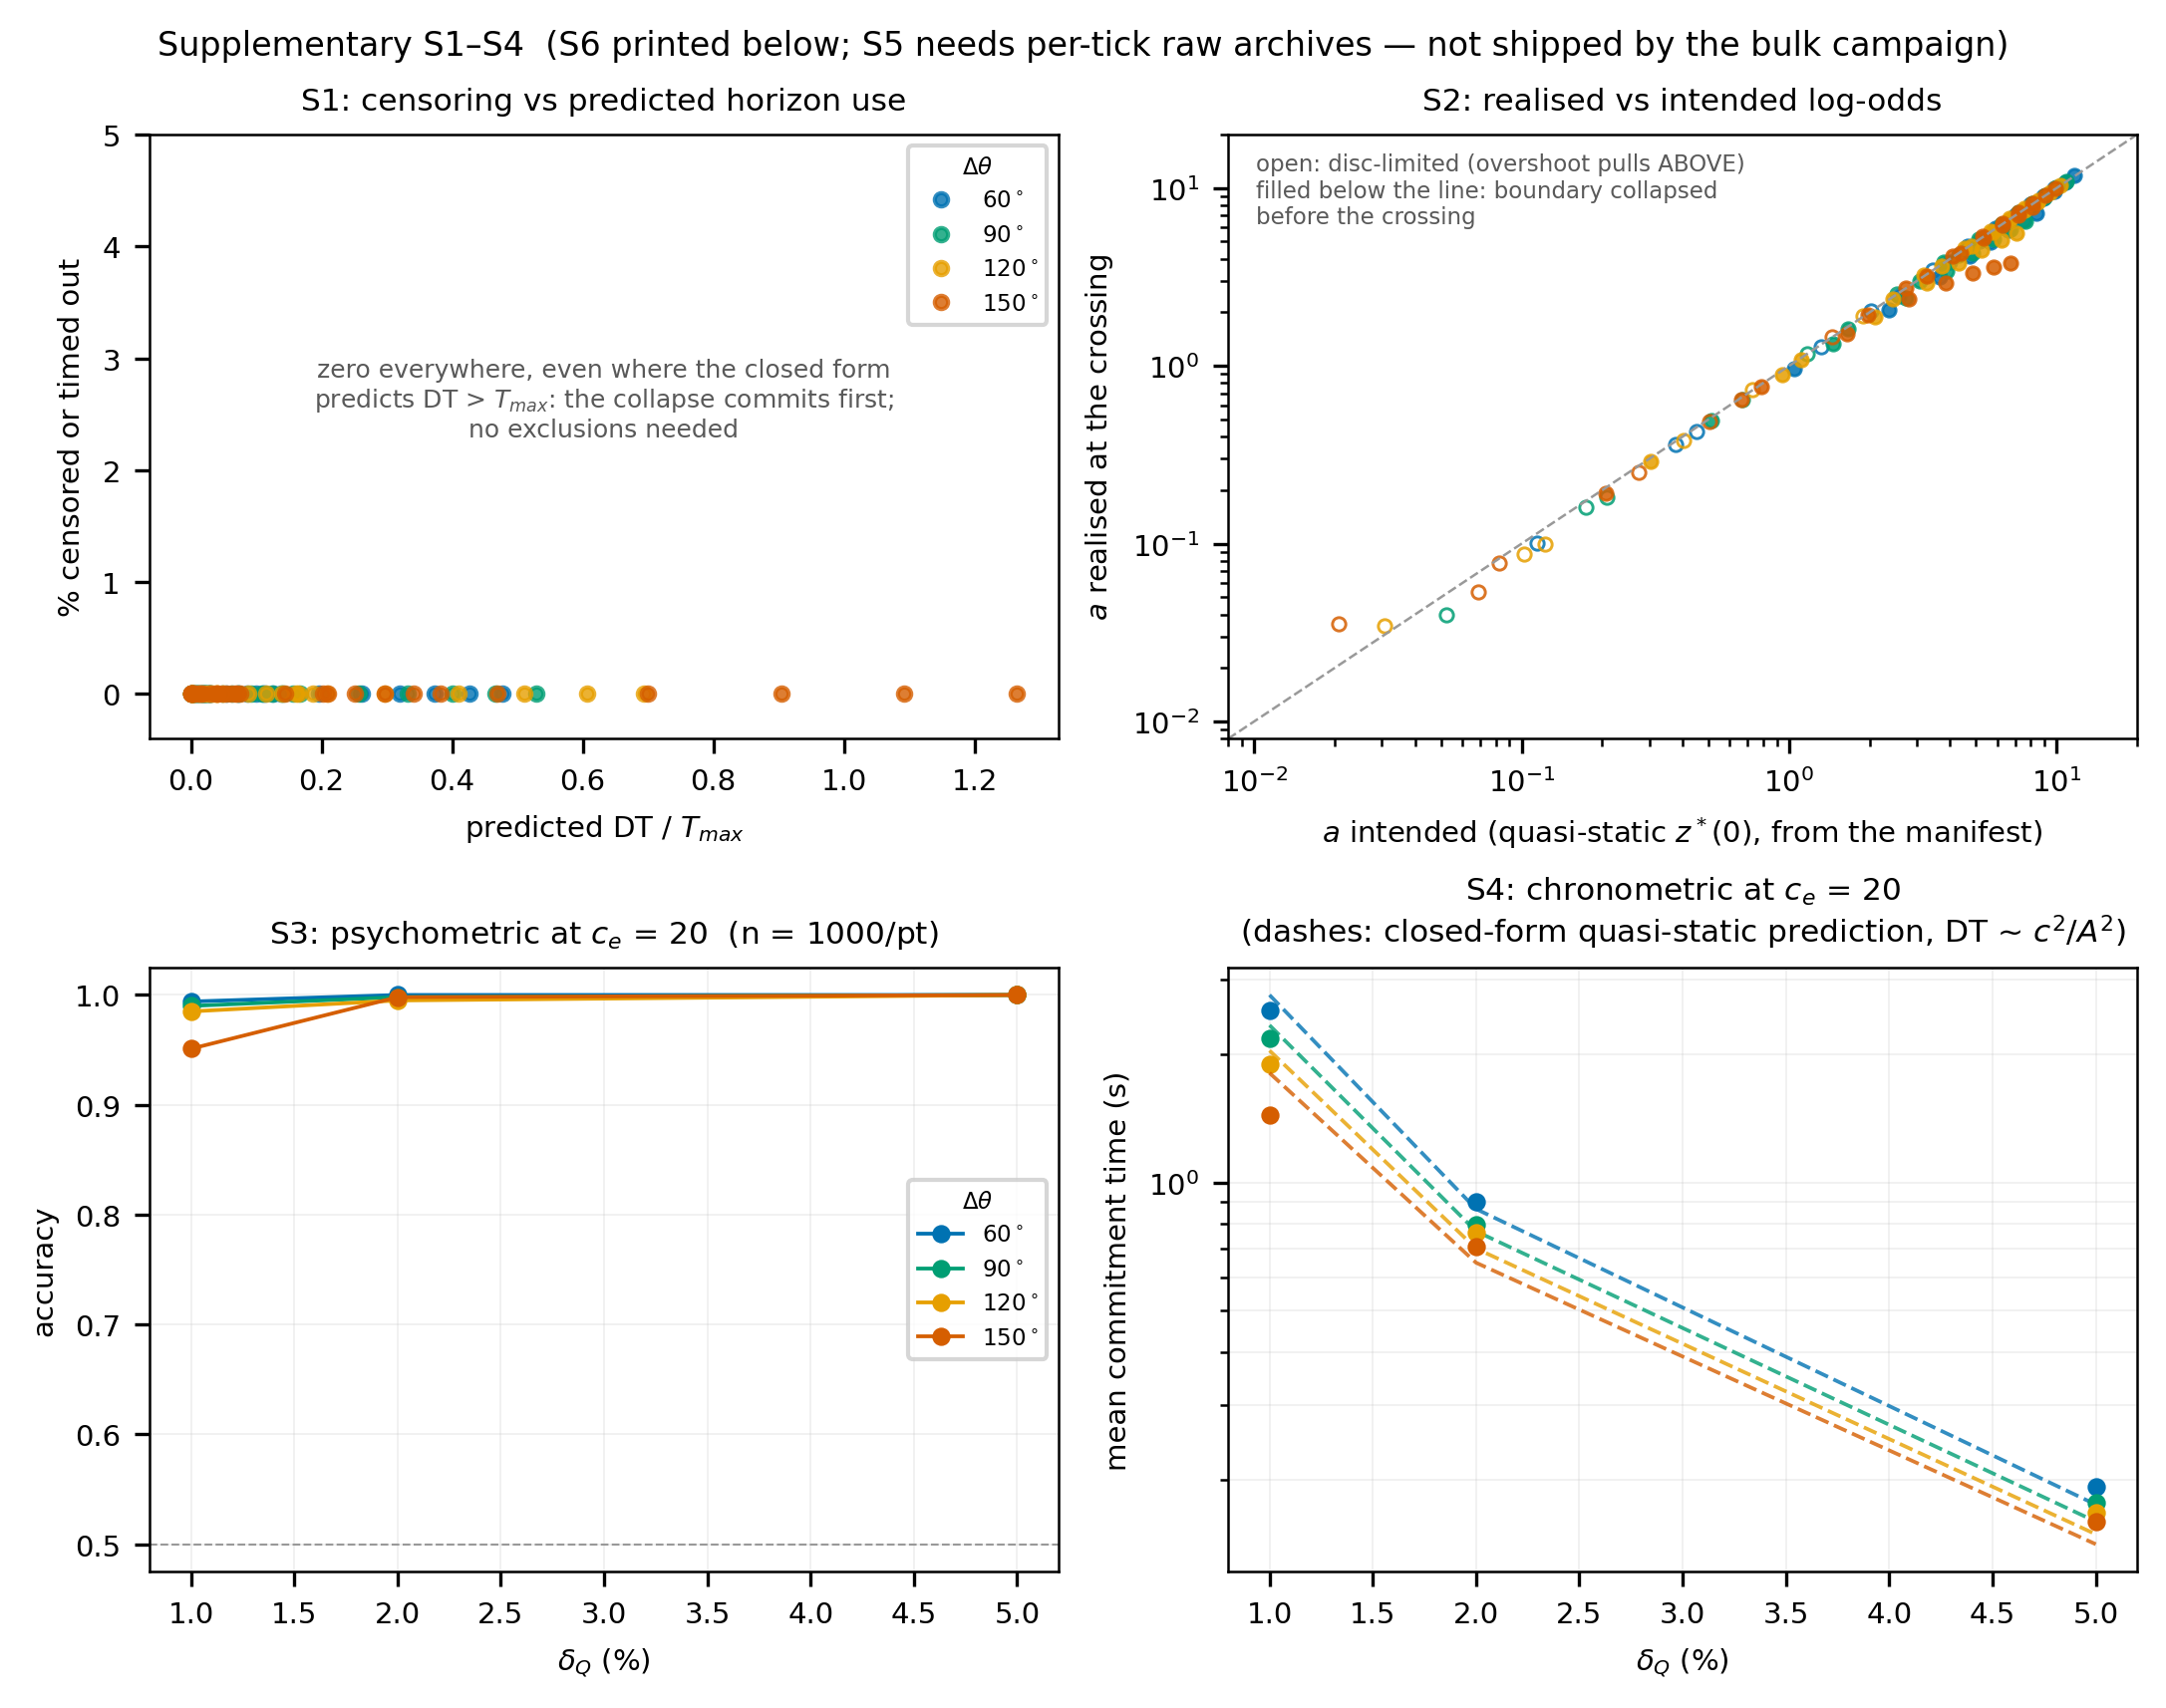

S6: |acc(commit) - acc(arrival)| max over 130 cells = 0.00e+00 (identical in every cell; the motion controller never flips a decision, so a scatter would be a diagonal of 130 coincident points)


In [47]:
# ANALYSIS_SPEC Section 6 — supplementary figures S1-S4, S6.
# S5 (path length vs a straight-line oracle) is NOT PRODUCIBLE from the bulk
# campaign: per-trial path length lives only in the per-tick raw archives, which
# the bulk run does not ship (Section 7.4 of the campaign spec). A --keep-raw
# rerun of the relevant cells would enable it; stated as a limitation.
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CAMPAIGN_ROOT = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/ddm-characterisation")
FIG_DIR = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-plots/ddm-characterisation")
THETA_COLOR = {60: "#0072B2", 90: "#009E73", 120: "#E69F00", 150: "#D55E00"}
DQ_MARKER = {0.01: "o", 0.02: "s", 0.05: "^"}
S3_CE = 20                          # the fixed criterion for S3/S4


def save_fig(fig, name, payload):
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300)
    payload["analysis_commit"] = subprocess.run(
        ["git", "rev-parse", "HEAD"], capture_output=True, text=True,
        cwd="/home/sindiso/Documents/PhD/ring-attractor/CollectiPy").stdout.strip()
    (FIG_DIR / f"{name}.json").write_text(json.dumps(payload, indent=1, default=float))
    print(f"wrote {FIG_DIR / name}.{{pdf,png,json}}")


trials = pd.read_parquet(CAMPAIGN_ROOT / "tidy_trials.parquet")
main = trials[trials.arm == "main"]
agg = (main.groupby(["dQ", "dtheta", "c_e"], sort=True)
       .agg(n=("correct", "size"), acc=("correct", "mean"),
            cen=("censored", "mean"), timeo=("timeout", "mean"),
            dt=("commit_time", "mean"), dt_pred=("dt_pred", "first"),
            dt_frac_pred=("dt_frac_pred", "first"),
            a_int=("a_intended", "first"), a_real=("a_realised", "mean"),
            commit_acc=("commit_correct", "mean"),
            flag=("discretisation_limited", "first")).reset_index())

# figure.dpi scales the INLINE render only (3x the notebook default of 100);
# the saved PDFs keep their true ICRA print geometry and 7 pt fonts.
plt.rcParams.update({"font.size": 7, "axes.linewidth": 0.6, "figure.dpi": 300})
fig, axes = plt.subplots(2, 2, figsize=(7.13, 5.6), constrained_layout=True)

# --- S1: censoring against predicted DT/T_max -----------------------------------
ax = axes[0][0]
for dth in THETA_COLOR:
    g = agg[agg.dtheta == dth]
    ax.plot(g.dt_frac_pred, 100 * (g.cen + g.timeo), ls="none", marker="o", ms=3.2,
            color=THETA_COLOR[dth], markerfacecolor=THETA_COLOR[dth], alpha=0.8,
            label=f"{dth}$^\\circ$")
ax.set_xlabel("predicted DT / $T_{max}$")
ax.set_ylabel("% censored or timed out")
ax.set_ylim(-0.4, 5)
ax.set_title("S1: censoring vs predicted horizon use", fontsize=7.5)
ax.text(0.5, 0.5, "zero everywhere, even where the closed form\n"
        "predicts DT > $T_{max}$: the collapse commits first;\nno exclusions needed",
        transform=ax.transAxes, ha="center", fontsize=6, color="0.35")
ax.legend(fontsize=5.5, title="$\\Delta\\theta$", title_fontsize=5.5)

# --- S2: realised vs intended log-odds across the WHOLE grid --------------------
ax = axes[0][1]
for dth in THETA_COLOR:
    for flag, face in ((False, None), (True, "none")):
        g = agg[(agg.dtheta == dth) & (agg.flag == flag)]
        ax.plot(g.a_int, g.a_real, ls="none", marker="o", ms=3.2,
                color=THETA_COLOR[dth],
                markerfacecolor=THETA_COLOR[dth] if face is None else "none",
                markeredgewidth=0.7, alpha=0.85)
lims = [0.008, 20]
ax.plot(lims, lims, ls="--", lw=0.6, color="0.6")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(*lims); ax.set_ylim(*lims)
ax.set_xlabel("$a$ intended (quasi-static $z^*(0)$, from the manifest)")
ax.set_ylabel("$a$ realised at the crossing")
ax.set_title("S2: realised vs intended log-odds", fontsize=7.5)
ax.text(0.03, 0.97, "open: disc-limited (overshoot pulls ABOVE)\n"
        "filled below the line: boundary collapsed\nbefore the crossing",
        transform=ax.transAxes, va="top", fontsize=5.5, color="0.35")

# --- S3: psychometric — accuracy vs dQ at fixed criterion -----------------------
ax = axes[1][0]
for dth in THETA_COLOR:
    g = agg[(agg.dtheta == dth) & (agg.c_e == S3_CE)].sort_values("dQ")
    ax.plot(100 * g.dQ, g.acc, marker="o", ms=3.4, lw=0.9,
            color=THETA_COLOR[dth], markerfacecolor=THETA_COLOR[dth],
            label=f"{dth}$^\\circ$")
ax.axhline(0.5, color="0.6", lw=0.5, ls="--")
ax.set_xlabel("$\\delta_Q$ (%)")
ax.set_ylabel("accuracy")
ax.set_title(f"S3: psychometric at $c_e$ = {S3_CE:g}  (n = 1000/pt)", fontsize=7.5)
ax.legend(fontsize=5.5, title="$\\Delta\\theta$", title_fontsize=5.5)
ax.grid(True, alpha=0.2, lw=0.4)

# --- S4: chronometric — mean DT vs dQ, against the closed form ------------------
ax = axes[1][1]
for dth in THETA_COLOR:
    g = agg[(agg.dtheta == dth) & (agg.c_e == S3_CE)].sort_values("dQ")
    ax.plot(100 * g.dQ, g.dt, marker="o", ms=3.4, lw=0, color=THETA_COLOR[dth],
            markerfacecolor=THETA_COLOR[dth], label=f"{dth}$^\\circ$ measured")
    ax.plot(100 * g.dQ, g.dt_pred, lw=0.9, ls="--", color=THETA_COLOR[dth],
            alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("$\\delta_Q$ (%)")
ax.set_ylabel("mean commitment time (s)")
ax.set_title(f"S4: chronometric at $c_e$ = {S3_CE:g}\n"
             "(dashes: closed-form quasi-static prediction, DT ~ $c^2/A^2$)",
             fontsize=7.5)
ax.grid(True, alpha=0.2, lw=0.4, which="both")

fig.suptitle("Supplementary S1–S4  (S6 printed below; S5 needs per-tick raw "
             "archives — not shipped by the bulk campaign)", fontsize=8)
save_fig(fig, "figS_supplementary", {"per_cell": agg.to_dict("records"),
                                     "S5": "not producible from bulk output"})
plt.show()

# --- S6: accuracy at commitment vs at arrival — as numbers, not a figure --------
diff = (agg.commit_acc - agg.acc).abs()
print(f"S6: |acc(commit) - acc(arrival)| max over 130 cells = {diff.max():.2e} "
      "(identical in every cell; the motion controller never flips a decision, "
      "so a scatter would be a diagonal of 130 coincident points)")

# RA vs DDM

The two **seed-paired frontier campaigns** at δ_Q = 1 %, Δθ = 60° (spec: `ra-ddm-frontier-slice-envelope-experiment.md`; implementation and decision log: `scripts/ra_ddm_frontier/`, `RECON.md`):

- **RA slices** — 100 cells: Set R sweeps û = u/u\*(v) ∈ {0.45 … 1.50} across kernel shapes v ∈ {0.2, 0.3, 0.4, 0.5}; Set U sweeps absolute u ∈ {0 … 15} (including the u = 0 no-coupling control). n = 1000/cell → `../seoul-data/beta-1/ra_ddm_frontier_slices`
- **DDM rerun** — the Bellman policy's c_e grid {0.03 … 300}, n = 1000/point → `../seoul-data/beta-1/ra_ddm_frontier_ddm`

Both campaigns share one environment frame (1 s control tick, v = 0.05 m/s, targets 5.0 / 4.95 at 0.5 m) and the calibration **evidence-channel noise c = √2·white_rate = 2ΔQ = 0.1**. Seeds follow `frontier-v1`: at equal run_id the two models receive **bitwise-identical percept realizations**, which licenses the per-trial paired tests below. Prerequisite: `scripts/ra_ddm_frontier/aggregate.py` has been run for each campaign (it writes the `trials.parquet` these cells read).

In [48]:
# RA vs DDM — the two seed-paired frontier campaigns (delta_Q = 1 %, dtheta = 60 deg).
# Self-contained: re-derives its own helpers, so the cell runs on its own.
#
# Data = aggregate.py output of the frontier campaigns (seed scheme frontier-v1;
# evidence-channel noise c = sqrt(2)*white_rate = 2*dQ = 0.1; both models on a
# 1 s control tick, identical percept realizations per run_id):
#   RA slices  ../seoul-data/beta-1/ra_ddm_frontier_slices  (100 cells  x 1000)
#   DDM rerun  ../seoul-data/beta-1/ra_ddm_frontier_ddm     (10 points x 1000)
import math
from pathlib import Path

import pandas as pd

RA_FRONTIER_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_slices")
DDM_FRONTIER_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm")


def _load_frontier_trials(stem: Path) -> pd.DataFrame:
    path = stem.with_suffix(".parquet")
    if not path.is_file():
        raise FileNotFoundError(
            f"{path} not found — run scripts/ra_ddm_frontier/aggregate.py first")
    df = pd.read_parquet(path)
    for col in ("correct", "decided", "timeout"):
        df[col] = df[col].astype(bool)
    return df


def _wilson(k: int, n: int, z: float = 1.959964):
    if n == 0:
        return float("nan"), float("nan"), float("nan")
    p = k / n
    den = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return p, max(0.0, centre - half), min(1.0, centre + half)


ra_frontier = _load_frontier_trials(RA_FRONTIER_ROOT / "trials")
ddm_frontier = _load_frontier_trials(DDM_FRONTIER_ROOT / "ddm_trials")

print("=== data-quality report — read before any figure ===")
for name, df, key, n_expected in (("RA", ra_frontier, "cell_id", 100 * 1000),
                                  ("DDM", ddm_frontier, "point_id", 10 * 1000)):
    n_err = int((df["error"] != "").sum())
    print(f"{name:>3}: {len(df):6d}/{n_expected} trials over "
          f"{df[key].nunique()} groups | decided "
          f"{df['decided'].mean():.4f} | scoring errors {n_err}")
    assert len(df) == n_expected, f"{name} campaign incomplete — resubmit"

print("\nu = 0 pure-replicate gate (v is inert at u = 0, so the four cells")
print("must agree trial-for-trial — this checks seeding AND environment):")
u0 = ra_frontier[(ra_frontier["sweep"] == "absolute")
                 & (ra_frontier["u"].astype(float) == 0.0)]
u0_ok = True
base = u0[u0["cell_id"] == sorted(u0["cell_id"].unique())[0]].set_index("run_id")
for cid, g in u0.groupby("cell_id"):
    g = g.set_index("run_id")
    identical = bool((g["correct"] == base.loc[g.index, "correct"]).all())
    u0_ok &= identical
    acc, lo, hi = _wilson(int(g["correct"].sum()), len(g))
    print(f"  {cid}: acc_all {acc:.3f} [{lo:.3f}, {hi:.3f}] "
          f"decided {g['decided'].mean():.3f} "
          f"{'(trial-for-trial identical)' if identical else '*** DIVERGES ***'}")
print(f"  gate: {'PASS' if u0_ok else 'FAIL — halt and diagnose'}")

anchor = ra_frontier[ra_frontier["cell_id"] == "R_v0.5_h1"]
acc, lo, hi = _wilson(int(anchor["correct"].sum()), len(anchor))
med_commit = anchor.loc[anchor["decided"], "t_commit_ticks"].median()
print(f"\nfactorial-anchor cell (v=0.5, u_hat=1.00): acc_all {acc:.3f} "
      f"[{lo:.3f}, {hi:.3f}], median commit {med_commit:.0f} ticks")
print("  (informational: the factorial's 0.765 / 11 ticks was measured at "
      "white_rate 0.035; this campaign runs c = 2*dQ)")

=== data-quality report — read before any figure ===
 RA: 174000/100000 trials over 174 groups | decided 1.0000 | scoring errors 0


AssertionError: RA campaign incomplete — resubmit

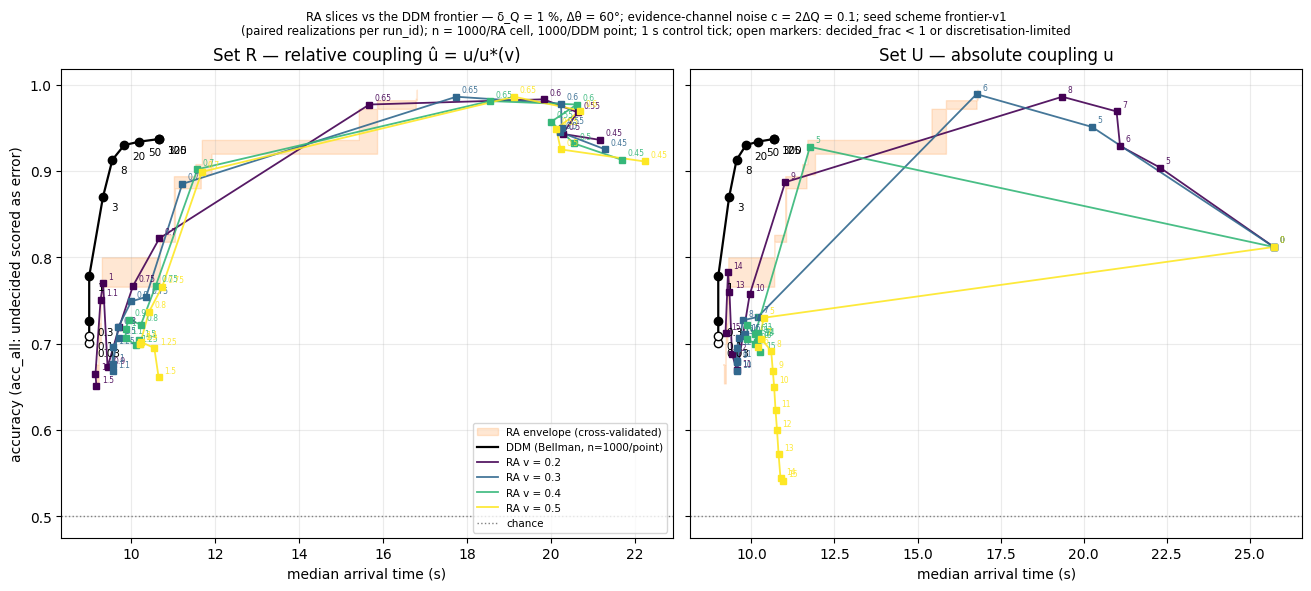

In [ ]:
# RA vs DDM — the main overlay: accuracy vs median arrival time (s).
# Self-contained: re-derives its own loader and helpers, so the cell runs on its own.
# Layers: DDM c_e-swept frontier (labels = c_e); four RA u_hat-slices per kernel
# shape v (Set R, connected in u_hat order — the fold is plotted, not truncated);
# Set-U slices (absolute u) in a companion panel; the cross-validated Pareto
# envelope (split-half selection, both directions) as a shaded band; chance line.
# Open markers: decided_frac < 1 or a discretisation-limited DDM point.
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_RA_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_slices")
_DDM_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm")
_V_GRID = [0.2, 0.3, 0.4, 0.5]
_DISC_LIMITED_CE = {0.03, 0.1}      # boundary below one evidence substep (RECON D-11)


def _load(stem):
    df = pd.read_parquet(Path(stem).with_suffix(".parquet"))
    for col in ("correct", "decided"):
        df[col] = df[col].astype(bool)
    return df


def _group_stats(df, key):
    """Per group: acc_all (undecided scored as error), median arrival s, decided_frac."""
    rows = []
    for ident, g in df.groupby(key, sort=False):
        arr = g.loc[g["decided"], "t_arrival_s"].astype(float)
        rows.append({key: ident, "n": len(g),
                     "acc_all": g["correct"].mean(),
                     "median_t": arr.median() if len(arr) else float("nan"),
                     "decided_frac": g["decided"].mean()})
    return pd.DataFrame(rows)


def _pareto(points):
    """cell_id -> (t, acc); keep the non-dominated set (min t, max acc)."""
    keep = []
    for cid, (t, a) in points.items():
        if not any((t2 <= t and a2 >= a) and (t2 < t or a2 > a)
                   for c2, (t2, a2) in points.items() if c2 != cid):
            keep.append(cid)
    return keep


def _half_points(df, mask):
    pts = {}
    for cid, g in df[mask].groupby("cell_id"):
        arr = g.loc[g["decided"], "t_arrival_s"].astype(float)
        if len(arr):
            pts[cid] = (float(arr.median()), float(g["correct"].mean()))
    return pts


def _envelope_staircases(df):
    """Both CV directions (select on one run_id-parity half, evaluate on the
    other): upper-left staircases through the evaluation-half points."""
    parity = df["run_id"].astype(int) % 2
    stairs = []
    for sel, ev in ((1, 0), (0, 1)):
        chosen = _pareto(_half_points(df, parity == sel))
        eval_pts = _half_points(df, parity == ev)
        pts = sorted(eval_pts[c] for c in chosen if c in eval_pts)
        stair, best = [], -1.0
        for t, a in pts:
            if a > best:
                stair.append((t, a))
                best = a
        stairs.append(stair)
    return stairs


def _step_at(stair, q):
    """Accuracy of a staircase at time q (last point at or before q)."""
    t = np.array([p[0] for p in stair]); a = np.array([p[1] for p in stair])
    if len(t) == 0 or q < t[0]:
        return np.nan
    return a[min(int(np.searchsorted(t, q, side="right")) - 1, len(a) - 1)]


ra_df, ddm_df = _load(_RA_ROOT / "trials"), _load(_DDM_ROOT / "ddm_trials")
ddm_stats = _group_stats(ddm_df, "point_id")
ddm_stats["c_e"] = [float(str(p).replace("D_ce", "")) for p in ddm_stats["point_id"]]
ddm_stats = ddm_stats.sort_values("median_t")
stairs = _envelope_staircases(ra_df)
n_ra = int(ra_df.groupby("cell_id").size().median())
n_ddm = int(ddm_df.groupby("point_id").size().median())

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), sharey=True,
                         constrained_layout=True)
_V_COLORS = {0.2: "#0072B2", 0.3: "#009E73", 0.4: "#D55E00", 0.5: "#CC79A7"}   # Okabe-Ito, no yellow
v_colors = _V_COLORS

for ax, sweep, order_col, label_fmt in (
        (axes[0], "relative", "u_hat", "{val:g}"),
        (axes[1], "absolute", "u", "{val:g}")):
    # envelope band (between the two CV directions' staircases)
    if all(stairs):
        tmin = min(s[0][0] for s in stairs)
        tmax = max(max(p[0] for p in s) for s in stairs)
        grid = np.linspace(tmin, tmax, 300)
        curves = np.array([[_step_at(s, q) for q in grid] for s in stairs])
        ax.fill_between(grid, np.nanmin(curves, 0), np.nanmax(curves, 0),
                        step="post", alpha=0.18, color="tab:orange", zorder=1,
                        label="RA envelope (cross-validated)")

    # the DDM frontier
    ax.plot(ddm_stats["median_t"], ddm_stats["acc_all"], "-", color="black",
            lw=1.6, zorder=3, label=f"DDM (Bellman, n={n_ddm}/point)")
    for _i, s in ddm_stats.iterrows():
        open_m = s["c_e"] in _DISC_LIMITED_CE or s["decided_frac"] < 1.0
        ax.plot(s["median_t"], s["acc_all"], "o", ms=6, zorder=4,
                mfc="white" if open_m else "black", mec="black")
        ax.annotate(f"{s['c_e']:g}", (s["median_t"], s["acc_all"]),
                    textcoords="offset points", xytext=(6, -10), fontsize=7.5)

    # RA slices, one curve per v, connected in sweep order (fold included)
    sub = ra_df[ra_df["sweep"] == sweep]
    for v in _V_GRID:
        gv = sub[np.isclose(sub["v"].astype(float), v)]
        order = gv.groupby("cell_id")[order_col].first().astype(float)
        st = _group_stats(gv, "cell_id").set_index("cell_id")
        st["order"] = order
        st = st.sort_values("order").dropna(subset=["median_t"])
        ax.plot(st["median_t"], st["acc_all"], "-", color=v_colors[v], lw=1.3,
                alpha=0.9, zorder=2, label=f"RA v = {v:g}")
        for cid, s in st.iterrows():
            ax.plot(s["median_t"], s["acc_all"], "s", ms=4, zorder=3,
                    mfc="white" if s["decided_frac"] < 1 else v_colors[v],
                    mec=v_colors[v])
            ax.annotate(label_fmt.format(val=s["order"]),
                        (s["median_t"], s["acc_all"]),
                        textcoords="offset points", xytext=(4, 3),
                        fontsize=5.5, color=v_colors[v], alpha=0.9)

    ax.axhline(0.5, color="gray", ls=":", lw=1, label="chance")
    ax.set_xlabel("median arrival time (s)")
    ax.set_title("Set R — relative coupling û = u/u*(v)" if sweep == "relative"
                 else "Set U — absolute coupling u")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("accuracy (acc_all: undecided scored as error)")
axes[0].legend(fontsize=7.5, loc="lower right")
fig.suptitle(
    "RA slices vs the DDM frontier — δ_Q = 1 %, Δθ = 60°; evidence-channel "
    "noise c = 2ΔQ = 0.1; seed scheme frontier-v1\n"
    f"(paired realizations per run_id); n = {n_ra}/RA cell, {n_ddm}/DDM point; "
    "1 s control tick; open markers: decided_frac < 1 or discretisation-limited",
    fontsize=8.5)
plt.show()

In [ ]:
# RA vs DDM — regret against the normative frontier, and the paired per-run_id
# contrasts the seed scheme licenses.
# Self-contained: imports the campaign package (scripts/ra_ddm_frontier) so the
# statistics are the same code the CLI analysis runs.
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path("scripts/ra_ddm_frontier").resolve()))
import importlib
import seeding, frontier, aggregate, analyze_overlay as ao  # noqa: E402
# reload the WHOLE package chain so a live kernel picks up module updates
for _m in (seeding, frontier, aggregate):
    importlib.reload(_m)
ao = importlib.reload(ao)

_ra = ao.load_trials(Path("../seoul-data/beta-1/ra_ddm_frontier_slices/trials"))
_ddm = ao.load_trials(Path("../seoul-data/beta-1/ra_ddm_frontier_ddm/ddm_trials"))

# --- how far each frontier reaches ------------------------------------------
_env_pts = [(e["median_t"], e["acc_all"]) for e in ao.envelope(_ra)]
_t_r, _a_r = ao.monotone_curve(_env_pts)
_ddm_pts = [(s["median_t"], s["acc_all"]) for s in ao.group_stats(_ddm, "point_id")]
_t_d, _a_d = ao.monotone_curve(_ddm_pts)
print(f"curve reach: RA envelope up to acc {_a_r[-1]:.3f} (at {_t_r[-1]:.1f} s); "
      f"DDM frontier up to acc {_a_d[-1]:.3f} (at {_t_d[-1]:.1f} s).")
print("A matched-accuracy regret above the DDM ceiling is undefined — the "
      "Bellman policy, horizon-bound at r0/v = 8.66 s of deliberation, never "
      "reaches the RA's slow sub-critical accuracies.\n")

# --- regret at matched accuracy / matched time (bootstrap CIs) --------------
ao.N_BOOT = 300          # ~3-6 min; raise for publication-final CIs
regret = ao.regret_with_ci(_ra, _ddm)
print("regret of the RA envelope vs the monotone DDM frontier")
print("(dt > 0: the RA reaches that accuracy LATER than the DDM):")
for a, r in regret["matched_accuracy_dt_s"].items():
    if r["estimate"] == r["estimate"]:
        print(f"  dt(acc={a}) = {r['estimate']:+6.2f} s   "
              f"CI95 [{r['ci95'][0]:+.2f}, {r['ci95'][1]:+.2f}]")
    else:
        print(f"  dt(acc={a}) undefined (outside a curve's accuracy range)")
lo, hi = regret["time_support_overlap_s"]
print(f"\nmatched-time dacc over the overlapping support [{lo:.1f}, {hi:.1f}] s")
print("(dacc > 0: the RA envelope is MORE accurate at that arrival time):")
for t, r in regret["matched_time_dacc"].items():
    print(f"  dacc(t={t} s) = {r['estimate']:+.3f}   "
          f"CI95 [{r['ci95'][0]:+.3f}, {r['ci95'][1]:+.3f}]")

# --- paired McNemar: each Set-R cell vs the DDM point nearest in time -------
mc = pd.DataFrame(ao.mcnemar(_ra, _ddm))
sig = mc[(mc["dacc_lo"] > 0) | (mc["dacc_hi"] < 0)]
print(f"\npaired McNemar (per run_id, licensed by the shared seed scheme): "
      f"{len(mc)} Set-R cells vs nearest-time DDM points; "
      f"{len(sig)} with a 95% CI excluding zero.")
cols = ["cell_id", "ddm_point", "ra_median_t", "ddm_median_t",
        "paired_dacc", "dacc_lo", "dacc_hi", "mcnemar_z"]
print("\nlargest paired differences (dacc = P(RA correct) - P(DDM correct)):")
print(mc.reindex(mc["paired_dacc"].abs().sort_values(ascending=False).index)
        [cols].head(12).to_string(index=False, float_format=lambda x: f"{x:8.3f}"))

curve reach: RA envelope up to acc 0.994 (at 17.8 s); DDM frontier up to acc 0.937 (at 10.7 s).
A matched-accuracy regret above the DDM ceiling is undefined — the Bellman policy, horizon-bound at r0/v = 8.66 s of deliberation, never reaches the RA's slow sub-critical accuracies.

regret of the RA envelope vs the monotone DDM frontier
(dt > 0: the RA reaches that accuracy LATER than the DDM):
  dt(acc=0.90) =  +1.76 s   CI95 [+1.34, +2.20]
  dt(acc=0.95) undefined (outside a curve's accuracy range)
  dt(acc=0.99) undefined (outside a curve's accuracy range)

matched-time dacc over the overlapping support [9.1, 10.7] s
(dacc > 0: the RA envelope is MORE accurate at that arrival time):
  dacc(t=9.15 s) = -0.102   CI95 [-0.152, -0.050]
  dacc(t=9.53 s) = -0.070   CI95 [-0.114, -0.040]
  dacc(t=9.91 s) = -0.130   CI95 [-0.173, -0.096]
  dacc(t=10.28 s) = -0.134   CI95 [-0.178, -0.112]
  dacc(t=10.66 s) = -0.137   CI95 [-0.174, -0.084]

paired McNemar (per run_id, licensed by the shared seed

### Per-kernel view — the absolute-u sweep alone against the DDM

One panel per kernel shape v (2 × 2), absolute-u results only (Set U + the U-v2 top-up), connected in u order. The DDM frontier is repeated in every panel as the fixed reference; RA points carry Wilson 95 % error bars; labels are thinned inside clusters.

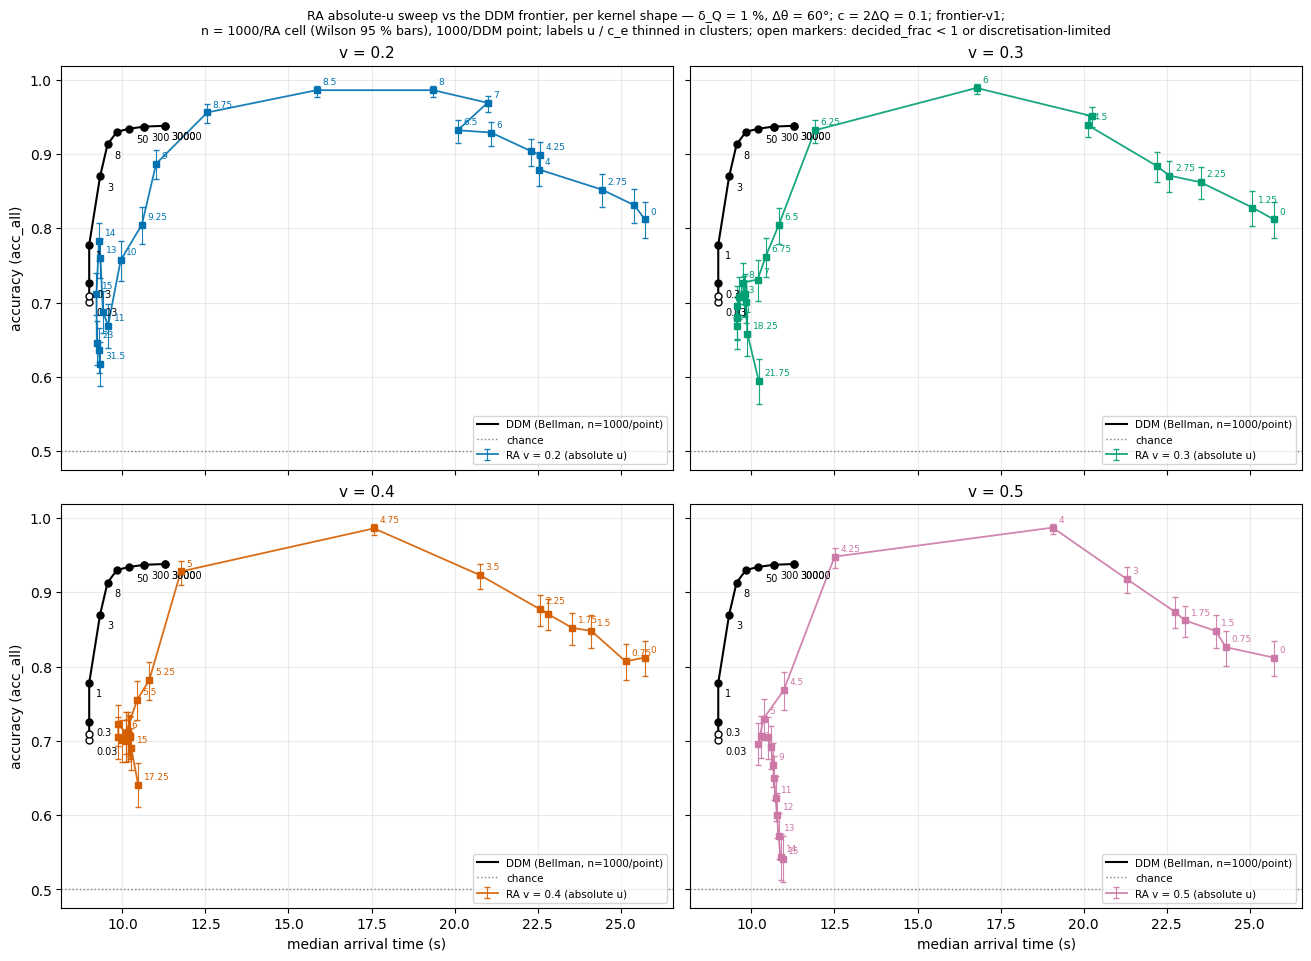

In [ ]:
# RA vs DDM — one panel per kernel shape v, absolute-u sweep only (Set U + the
# U-v2 top-up), each against the same DDM frontier. 2 x 2 grid.
# Self-contained: re-derives its own loader and helpers, so the cell runs on its own.
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_RA_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_slices")
_DDM_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm")
_V_GRID = [0.2, 0.3, 0.4, 0.5]
_DISC_LIMITED_CE = {0.03, 0.1}      # boundary below one evidence substep (RECON D-11)
# Okabe–Ito, no yellow: readable and colorblind-safe.
_V_COLORS = {0.2: "#0072B2", 0.3: "#009E73", 0.4: "#D55E00", 0.5: "#CC79A7"}


def _load(stem):
    df = pd.read_parquet(Path(stem).with_suffix(".parquet"))
    for col in ("correct", "decided"):
        df[col] = df[col].astype(bool)
    return df


def _wilson_bounds(k, n, z=1.959964):
    p = k / n
    den = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(0.0, centre - half), min(1.0, centre + half)


def _group_stats(df, key):
    rows = []
    for ident, g in df.groupby(key, sort=False):
        arr = g.loc[g["decided"], "t_arrival_s"].astype(float)
        lo, hi = _wilson_bounds(int(g["correct"].sum()), len(g))
        rows.append({key: ident, "n": len(g), "acc_all": g["correct"].mean(),
                     "acc_lo": lo, "acc_hi": hi,
                     "median_t": arr.median() if len(arr) else float("nan"),
                     "decided_frac": g["decided"].mean()})
    return pd.DataFrame(rows)


def _thinned(points, dt_min=0.4, dacc_min=0.02):
    """Label endpoints always; in clusters, thin the labels, not the points."""
    if not points:
        return set()
    keep, last = {0, len(points) - 1}, points[0]
    for i, p in enumerate(points[1:-1], start=1):
        if abs(p[0] - last[0]) >= dt_min or abs(p[1] - last[1]) >= dacc_min:
            keep.add(i)
            last = p
    return keep


ra_df, ddm_df = _load(_RA_ROOT / "trials"), _load(_DDM_ROOT / "ddm_trials")
ddm_stats = _group_stats(ddm_df, "point_id")
ddm_stats["c_e"] = [float(str(p).replace("D_ce", "")) for p in ddm_stats["point_id"]]
ddm_stats = ddm_stats.sort_values("median_t")
n_ra = int(ra_df.groupby("cell_id").size().median())
n_ddm = int(ddm_df.groupby("point_id").size().median())

fig, axes = plt.subplots(2, 2, figsize=(13, 9.5), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, v in zip(axes.ravel(), _V_GRID):
    # the DDM frontier — identical in every panel
    ax.plot(ddm_stats["median_t"], ddm_stats["acc_all"], "-", color="black",
            lw=1.5, zorder=3, label=f"DDM (Bellman, n={n_ddm}/point)")
    ddm_pts = list(zip(ddm_stats["median_t"], ddm_stats["acc_all"]))
    lab = _thinned(ddm_pts)
    for i, (_idx, s) in enumerate(ddm_stats.iterrows()):
        open_m = s["c_e"] in _DISC_LIMITED_CE or s["decided_frac"] < 1.0
        ax.plot(s["median_t"], s["acc_all"], "o", ms=5, zorder=4,
                mfc="white" if open_m else "black", mec="black")
        if i in lab:
            ax.annotate(f"{s['c_e']:g}", ddm_pts[i],
                        textcoords="offset points", xytext=(5, -10), fontsize=7)

    # this kernel's absolute-u sweep, connected in u order, Wilson bars
    gv = ra_df[(ra_df["sweep"] == "absolute")
               & np.isclose(ra_df["v"].astype(float), v)]
    order = gv.groupby("cell_id")["u"].first().astype(float)
    st = _group_stats(gv, "cell_id").set_index("cell_id")
    st["u"] = order
    st = st.sort_values("u").dropna(subset=["median_t"])
    color = _V_COLORS[v]
    ax.errorbar(st["median_t"], st["acc_all"],
                yerr=[st["acc_all"] - st["acc_lo"],
                      st["acc_hi"] - st["acc_all"]],
                fmt="-", color=color, lw=1.3, elinewidth=0.8, capsize=2,
                alpha=0.9, zorder=2, label=f"RA v = {v:g} (absolute u)")
    pts = list(zip(st["median_t"], st["acc_all"]))
    lab = _thinned(pts)
    for i, (cid, s) in enumerate(st.iterrows()):
        ax.plot(s["median_t"], s["acc_all"], "s", ms=4.5, zorder=3,
                mfc="white" if s["decided_frac"] < 1 else color, mec=color)
        if i in lab:
            ax.annotate(f"{s['u']:g}", pts[i], textcoords="offset points",
                        xytext=(4, 4), fontsize=6.5, color=color)

    ax.axhline(0.5, color="gray", ls=":", lw=1, label="chance")
    ax.set_title(f"v = {v:g}", fontsize=11)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7.5, loc="lower right")
for ax in axes[-1]:
    ax.set_xlabel("median arrival time (s)")
for ax in axes[:, 0]:
    ax.set_ylabel("accuracy (acc_all)")
fig.suptitle(
    "RA absolute-u sweep vs the DDM frontier, per kernel shape — δ_Q = 1 %, "
    "Δθ = 60°; c = 2ΔQ = 0.1; frontier-v1;\n"
    f"n = {n_ra}/RA cell (Wilson 95 % bars), {n_ddm}/DDM point; labels u / c_e "
    "thinned in clusters; open markers: decided_frac < 1 or "
    "discretisation-limited", fontsize=9)
plt.show()

### Tuning curves (wave 2: Set U-v2 at ~0.025·u* cliff resolution + deep super-critical tails)

Accuracy vs absolute coupling u on log-x, per kernel shape — the view u_dec(v) is read from. The same structure at every v: rise to a peak just below u*(v), a cliff through the u = 0 floor near ~0.7·u*, the committed plateau at ≈ 0.70, and a monotone slide **below the no-coupling floor** deep in the super-critical regime — now a cross-kernel result, not a v = 0.5-only observation.

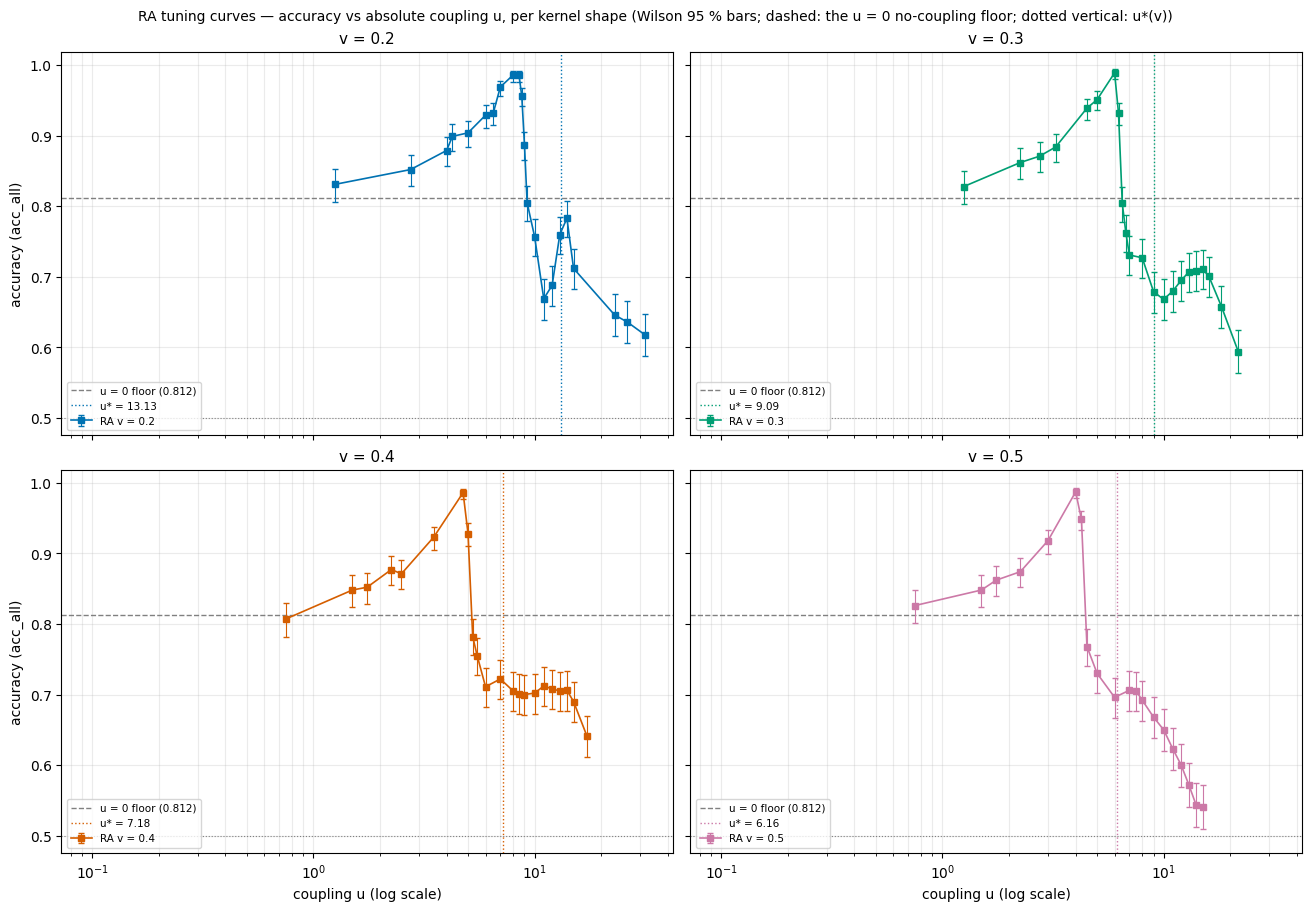

In [ ]:
# RA tuning curves — accuracy vs absolute coupling u (log-x), per kernel shape:
# the view u_dec(v) is read from. Wave 2 (Set U-v2) fills the cliff at ~0.025 u*
# resolution and adds the deep super-critical tails.
# Self-contained: re-derives its own loader and helpers, so the cell runs on its own.
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_RA_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_slices")
_V_GRID = [0.2, 0.3, 0.4, 0.5]


def _wilson(k, n, z=1.959964):
    p = k / n
    den = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return p, max(0.0, centre - half), min(1.0, centre + half)


ra_df = pd.read_parquet(_RA_ROOT / "trials.parquet")
for col in ("correct", "decided"):
    ra_df[col] = ra_df[col].astype(bool)

_V_COLORS = {0.2: "#0072B2", 0.3: "#009E73", 0.4: "#D55E00", 0.5: "#CC79A7"}   # Okabe-Ito, no yellow
v_colors = _V_COLORS
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, v in zip(axes.ravel(), _V_GRID):
    gv = ra_df[(ra_df["sweep"] == "absolute")
               & np.isclose(ra_df["v"].astype(float), v)]
    u_star = float(gv["u_star"].astype(float).iloc[0])
    stats = []
    for cid, g in gv.groupby("cell_id"):
        acc, lo, hi = _wilson(int(g["correct"].sum()), len(g))
        stats.append({"u": float(g["u"].iloc[0]), "acc": acc,
                      "lo": lo, "hi": hi})
    stats.sort(key=lambda s: s["u"])
    color = v_colors[v]
    floor = next((s for s in stats if s["u"] == 0.0), None)
    if floor is not None:
        ax.axhline(floor["acc"], color="gray", ls="--", lw=1,
                   label=f"u = 0 floor ({floor['acc']:.3f})")
    pos = [s for s in stats if s["u"] > 0]
    ax.errorbar([s["u"] for s in pos], [s["acc"] for s in pos],
                yerr=[[s["acc"] - s["lo"] for s in pos],
                      [s["hi"] - s["acc"] for s in pos]],
                fmt="s-", color=color, ms=4, lw=1.2, elinewidth=0.8,
                capsize=2, label=f"RA v = {v:g}")
    ax.axvline(u_star, color=color, ls=":", lw=1, label=f"u* = {u_star:.2f}")
    ax.axhline(0.5, color="gray", ls=":", lw=0.8)
    ax.set_xscale("log")
    ax.set_title(f"v = {v:g}", fontsize=11)
    ax.grid(alpha=0.25, which="both")
    ax.legend(fontsize=7.5, loc="lower left")
for ax in axes[-1]:
    ax.set_xlabel("coupling u (log scale)")
for ax in axes[:, 0]:
    ax.set_ylabel("accuracy (acc_all)")
fig.suptitle("RA tuning curves — accuracy vs absolute coupling u, per kernel "
             "shape (Wilson 95 % bars; dashed: the u = 0 no-coupling floor; "
             "dotted vertical: u*(v))", fontsize=10)
plt.show()

### DDM ceiling verification (§11)

The extreme-c_e points (3000, 30000) pin the DDM family at its analytic infinite-patience asymptote Φ((A/c)·√(r₀/v)) — the horizon-bound Bellman policy cannot buy more accuracy with any evidence cost. The RA claim is judged on the cross-validated envelope peak (evaluation-half trials only).

In [ ]:
# DDM ceiling verification (§11) — the claim "the RA sub-critical peak exceeds
# the DDM family" requires the cross-validated RA envelope peak (eval-half
# trials, no winner's curse) to clear BOTH the analytic infinite-patience
# asymptote and the best measured DDM point (extreme c_e = 3000, 30000
# included) with CI separation.
# Self-contained: imports the campaign package for the shared statistics.
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts/ra_ddm_frontier").resolve()))
import importlib
import seeding, frontier, aggregate, analyze_overlay as ao  # noqa: E402
# reload the WHOLE package chain so a live kernel picks up module updates
for _m in (seeding, frontier, aggregate):
    importlib.reload(_m)
ao = importlib.reload(ao)

_ra = ao.load_trials(Path("../seoul-data/beta-1/ra_ddm_frontier_slices/trials"))
_ddm = ao.load_trials(Path("../seoul-data/beta-1/ra_ddm_frontier_ddm/ddm_trials"))
ceiling = ao.ceiling_check(_ra, _ddm, ao.envelope(_ra))

print(f"analytic infinite-patience asymptote Phi((A/c)*sqrt(r0/v)) "
      f"= {ceiling['analytic_asymptote']:.4f}")
b = ceiling["ddm_best_point"]
print(f"best measured DDM point ({b['point_id']}, extreme-c_e points "
      f"{'included' if ceiling['empirical_ceiling_points_present'] else 'MISSING'}): "
      f"{b['acc_all']:.4f} [{b['acc_lo']:.4f}, {b['acc_hi']:.4f}]")
for p in ceiling["ra_envelope_peaks_eval_half"]:
    print(f"RA envelope peak [{p['direction']}]: {p['cell_id']} "
          f"{p['acc']:.4f} [{p['acc_lo']:.4f}, {p['acc_hi']:.4f}] "
          f"(n_eval = {p['n_eval']})")
stands = (ceiling["ra_clears_analytic_asymptote_with_CI"]
          and ceiling["ra_clears_measured_ddm_with_CI"])
print(f"\nclaim 'RA sub-critical peak exceeds the DDM family': "
      f"{'STANDS' if stands else 'DOES NOT STAND'} (CI separation "
      f"vs asymptote: {ceiling['ra_clears_analytic_asymptote_with_CI']}, "
      f"vs measured DDM: {ceiling['ra_clears_measured_ddm_with_CI']})")

analytic infinite-patience asymptote Phi((A/c)*sqrt(r0/v)) = 0.9294
best measured DDM point (D_ce3000, extreme-c_e points included): 0.9380 [0.9213, 0.9513]
RA envelope peak [select_odd_eval_even]: U_v0.3_u6 0.9840 [0.9687, 0.9919] (n_eval = 500)
RA envelope peak [select_even_eval_odd]: U_v0.3_u6 0.9940 [0.9825, 0.9980] (n_eval = 500)

claim 'RA sub-critical peak exceeds the DDM family': STANDS (CI separation vs asymptote: True, vs measured DDM: True)


# RA vs DDM — spec v3: halt-at-midpoint DDM (two bound families) + Set U-v3 kernels

The comparison above used the **forced-choice** DDM: an agent arriving at the midpoint undecided was committed by geometry, so the high-c_e accuracy ceiling (≈ 0.94) was an *interrogation artifact* of the travel deadline, not a property of the inference. Spec v3 (`ra-ddm-frontier-slice-envelope-experiment.md` §2b; RECON D-13/D-14/D-15) fixes this and extends both sides:

- **Halt-at-midpoint motion policy** — an agent reaching the midpoint undecided **halts (v = 0)** and keeps integrating against the flat threshold z_halt until a bound is crossed or the 60 s budget hits. The Bellman bounds no longer collapse to zero; they floor at z_halt > 0. New campaign tree → `../seoul-data/beta-1/ra_ddm_frontier_ddm_halt` (26 points × 1000): the previous c_e grid verbatim + extreme-c_e ceiling points {3000, 30000} + a **static-bound family** (14 log-spaced b ∈ [0.0028, 0.529], wired as the degenerate flat table through the same Bellman machinery — one code path). The forced-choice tree is frozen as the regression reference.
- **Set U-v3** — output-plane arc-length re-spacing at v ∈ {0.2…0.5} (sub-critical chord fills) and **kernel extension to v ∈ {0.6, 0.8}** with full grids, deep tails û ∈ {1.75, 2.0, 2.4} and u = 0 controls. RA tree now 174 cells × 1000 over six kernel shapes.

Everything remains in the `frontier-v1` seed universe: at equal run_id, every RA cell and every DDM point of *both* families sees the identical percept realization. Prerequisite: `aggregate.py` has been run on all three roots (it writes the parquet these cells read). The next cell is the gate report — read it before any figure.


In [ ]:
# Spec v3 gates — read before any figure below.
# Self-contained: re-derives its own helpers, so the cell runs on its own.
#
#   RA (waves 1+2+3)   ../seoul-data/beta-1/ra_ddm_frontier_slices    174 x 1000
#   DDM halt campaign  ../seoul-data/beta-1/ra_ddm_frontier_ddm_halt   26 x 1000
#   DDM forced-choice  ../seoul-data/beta-1/ra_ddm_frontier_ddm        12 x 1000 (frozen reference)
import math
from pathlib import Path

import pandas as pd

_RA_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_slices")
_HALT_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm_halt")
_FROZEN_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm")


def _load(stem):
    df = pd.read_parquet(Path(stem).with_suffix(".parquet"))
    for col in ("correct", "decided", "timeout"):
        df[col] = df[col].astype(bool)
    if "halted" in df:
        df["halted"] = df["halted"].apply(lambda x: x is True)
    return df


def _wilson(k, n, z=1.959964):
    p = k / n
    den = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return p, max(0.0, centre - half), min(1.0, centre + half)


ra = _load(_RA_ROOT / "trials")
halt = _load(_HALT_ROOT / "ddm_trials")
frozen = _load(_FROZEN_ROOT / "ddm_trials")

print("=== data-quality report ===")
for name, df, key, n_exp in (("RA", ra, "cell_id", 174 * 1000),
                             ("DDM halt", halt, "point_id", 26 * 1000),
                             ("DDM frozen", frozen, "point_id", 12 * 1000)):
    n_err = int((df["error"] != "").sum())
    print(f"{name:>10}: {len(df):6d}/{n_exp} trials over "
          f"{df[key].nunique():3d} groups | decided {df['decided'].mean():.4f}"
          f" | scoring errors {n_err}")
    assert len(df) == n_exp, f"{name} campaign incomplete — resubmit"

print("\nu = 0 pure-replicate gate — SIX-way after U-v3 (v is inert at u = 0,")
print("so all six cells must agree trial-for-trial):")
u0 = ra[(ra["sweep"] == "absolute") & (ra["u"].astype(float) == 0.0)]
base = u0[u0["cell_id"] == sorted(u0["cell_id"].unique())[0]].set_index("run_id")
u0_ok = True
for cid, g in u0.groupby("cell_id"):
    g = g.set_index("run_id")
    identical = bool((g["correct"] == base.loc[g.index, "correct"]).all())
    u0_ok &= identical
    acc, lo, hi = _wilson(int(g["correct"].sum()), len(g))
    print(f"  {cid:>12}: acc_all {acc:.3f} [{lo:.3f}, {hi:.3f}] "
          f"{'(trial-for-trial identical)' if identical else '*** DIVERGES ***'}")
print(f"  gate: {'PASS' if u0_ok else 'FAIL — halt and diagnose'}")

print("\nzero-halt regression gate (§9): where the halt never triggers, the")
print("halt rerun must REPRODUCE the frozen forced-choice run (same")
print("calibration, same frontier-v1 seeds; the model-seed re-key is inert):")
hb = halt[halt["variant"] == "bellman"].copy()
hb["c_e_f"] = hb["c_e"].astype(float)
fz = frozen.copy()
fz["c_e_f"] = fz["c_e"].astype(float)
gate_ok = True
for ce, g in sorted(hb.groupby("c_e_f"), key=lambda kv: kv[0]):
    halt_frac = g["halted"].mean()
    prev = fz[fz["c_e_f"] == ce]
    if prev.empty:
        continue
    m = g[["run_id", "correct", "t_commit_ticks"]].merge(
        prev[["run_id", "correct", "t_commit_ticks"]], on="run_id",
        suffixes=("_halt", "_fc"))
    mism = int((m["correct_halt"] != m["correct_fc"]).sum())
    if halt_frac == 0.0:
        gate_ok &= mism == 0
        tag = ("trial-for-trial identical" if mism == 0
               else f"*** {mism} mismatches ***")
        print(f"  c_e={ce:>7g}  halt_frac 0.000  {tag}")
    else:
        dacc = g["correct"].mean() - prev["correct"].mean()
        print(f"  c_e={ce:>7g}  halt_frac {halt_frac:.3f}  expected departure: "
              f"dacc {dacc:+.3f}, {mism} per-trial flips "
              f"(slower + more accurate is the policy fix)")
print(f"  gate: {'PASS' if gate_ok else 'FAIL — env/template drift; halt and diagnose'}")

print("\nhalt-campaign censoring (60 s budget kept, §13 — reported, not hidden):")
for pid, g in halt.groupby("point_id"):
    cen = (~g["decided"]).mean()
    if cen > 0:
        print(f"  {pid:>12}: censored {cen:.3f}  halt_frac {g['halted'].mean():.3f}"
              f"  guard hits {int(g['halt_guard_hits'].fillna(0).sum())}")
print(f"  total guard hits across the campaign: "
      f"{int(halt['halt_guard_hits'].fillna(0).sum())} (expected 0)")


### What the halt-at-midpoint policy buys — the interrogation artifact removed

Same Bellman policy, same c_e grid, same seeds — only the motion policy at arrival differs. Under forced choice the frontier saturates at ≈ 0.94: geometry commits the undecided. Under halt-at-midpoint the undecided agent stops and finishes the SPRT against the z_halt floor, so the high-patience end climbs to ≈ 0.998 at the price of the halt time — the asymptote is now a genuine free-response property of the inference. Left: both frontiers with per-c_e connectors (the four zero-halt points coincide trial-for-trial). Right: what the halt costs and how often it happens.


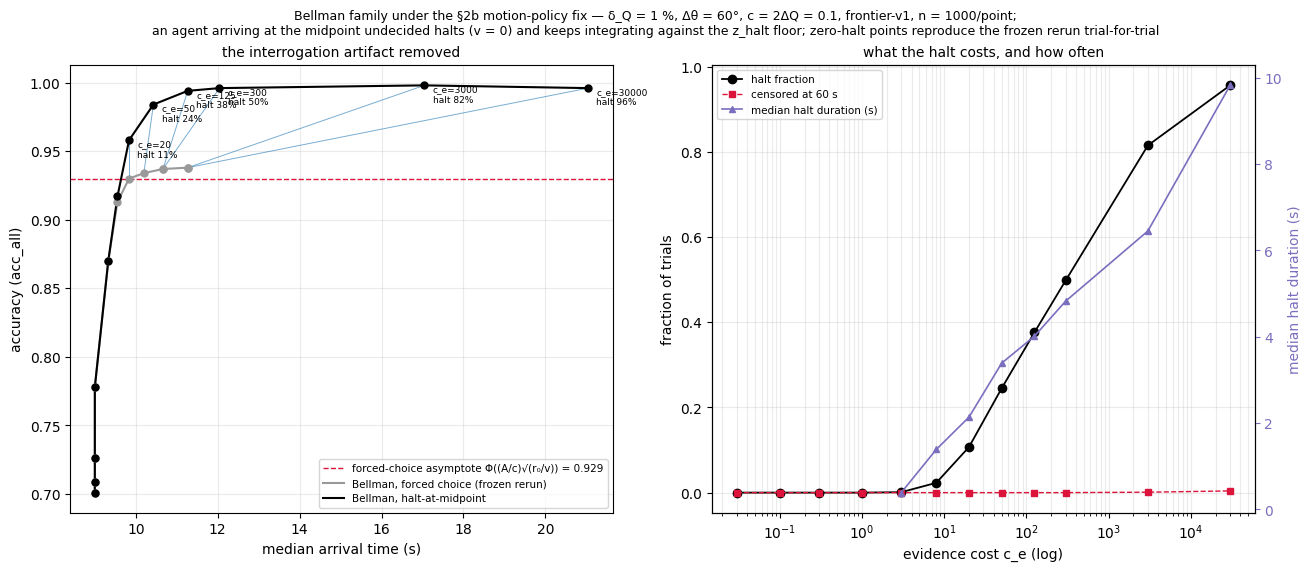

per-c_e effect of the policy fix (paired by construction):
  c_e=   0.03: acc 0.701 -> 0.701 (+0.000), median arrival  9.00 ->  9.00 s, halt_frac 0.000
  c_e=    0.1: acc 0.709 -> 0.709 (+0.000), median arrival  9.00 ->  9.00 s, halt_frac 0.000
  c_e=    0.3: acc 0.726 -> 0.726 (+0.000), median arrival  9.00 ->  9.00 s, halt_frac 0.000
  c_e=      1: acc 0.778 -> 0.778 (+0.000), median arrival  9.00 ->  9.00 s, halt_frac 0.000
  c_e=      3: acc 0.870 -> 0.870 (+0.000), median arrival  9.33 ->  9.33 s, halt_frac 0.001
  c_e=      8: acc 0.913 -> 0.917 (+0.004), median arrival  9.55 ->  9.55 s, halt_frac 0.023
  c_e=     20: acc 0.930 -> 0.958 (+0.028), median arrival  9.84 ->  9.84 s, halt_frac 0.107
  c_e=     50: acc 0.934 -> 0.984 (+0.050), median arrival 10.20 -> 10.43 s, halt_frac 0.245
  c_e=    125: acc 0.937 -> 0.994 (+0.057), median arrival 10.66 -> 11.27 s, halt_frac 0.376
  c_e=    300: acc 0.937 -> 0.996 (+0.059), median arrival 10.66 -> 12.04 s, halt_frac 0.498
  c_e=   30

In [ ]:
# The halt-at-midpoint policy fix: Bellman frontier, forced choice vs halt —
# same c_e grid, same frontier-v1 seeds, only the motion policy at arrival
# differs. Self-contained: re-derives its own loader and helpers.
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statistics import NormalDist

_HALT_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm_halt")
_FROZEN_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm")
# analytic infinite-patience asymptote of the FORCED-CHOICE observer:
# integrate the whole r0/v horizon, then answer (RECON D-12).
_A, _C, _R0, _V = 0.05, 0.1, 0.5 * math.cos(math.radians(30)), 0.05
_FC_ASYMPTOTE = NormalDist().cdf((_A / _C) * math.sqrt(_R0 / _V))


def _load(stem):
    df = pd.read_parquet(Path(stem).with_suffix(".parquet"))
    for col in ("correct", "decided"):
        df[col] = df[col].astype(bool)
    if "halted" in df:
        df["halted"] = df["halted"].apply(lambda x: x is True)
    return df


def _bellman_stats(df):
    rows = []
    for pid, g in df.groupby("point_id"):
        if str(g["variant"].iloc[0] or "bellman") != "bellman":
            continue
        arr = g.loc[g["decided"], "t_arrival_s"].astype(float)
        rows.append({"c_e": float(g["c_e"].iloc[0]),
                     "acc": g["correct"].mean(),
                     "median_t": arr.median(),
                     "halt_frac": g["halted"].mean() if "halted" in g else 0.0,
                     "halt_med": g.loc[g["halted"], "halt_duration"].median()
                     if "halted" in g and g["halted"].any() else float("nan"),
                     "censored": (~g["decided"]).mean()})
    return pd.DataFrame(rows).sort_values("c_e").reset_index(drop=True)


halt = _bellman_stats(_load(_HALT_ROOT / "ddm_trials"))
frozen = _bellman_stats(_load(_FROZEN_ROOT / "ddm_trials"))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6),
                               constrained_layout=True)

# --- left: the two frontiers, per-c_e connectors ----------------------------
axL.axhline(_FC_ASYMPTOTE, color="crimson", ls="--", lw=1,
            label=f"forced-choice asymptote Φ((A/c)√(r₀/v)) = {_FC_ASYMPTOTE:.3f}")
for df, color, marker, name in ((frozen, "#999999", "o",
                                 "forced choice (frozen rerun)"),
                                (halt, "black", "o", "halt-at-midpoint")):
    axL.plot(df["median_t"], df["acc"], "-", color=color, lw=1.5, zorder=3,
             label=f"Bellman, {name}")
    axL.plot(df["median_t"], df["acc"], marker, ms=5, color=color, zorder=4)
merged = frozen.merge(halt, on="c_e", suffixes=("_fc", "_halt"))
for _i, r in merged.iterrows():
    axL.plot([r["median_t_fc"], r["median_t_halt"]],
             [r["acc_fc"], r["acc_halt"]], "-", color="tab:blue", lw=0.7,
             alpha=0.6, zorder=2)
    if r["halt_frac_halt"] > 0.05:
        axL.annotate(f"c_e={r['c_e']:g}\nhalt {r['halt_frac_halt']:.0%}",
                     (r["median_t_halt"], r["acc_halt"]),
                     textcoords="offset points", xytext=(6, -12), fontsize=6.5)
axL.set_xlabel("median arrival time (s)")
axL.set_ylabel("accuracy (acc_all)")
axL.set_title("the interrogation artifact removed", fontsize=10)
axL.grid(alpha=0.25)
axL.legend(fontsize=7.5, loc="lower right")

# --- right: halt fraction and halt cost along the c_e grid ------------------
axR.plot(halt["c_e"], halt["halt_frac"], "o-", color="black", lw=1.3,
         label="halt fraction")
axR.plot(halt["c_e"], halt["censored"], "s--", color="crimson", lw=1,
         ms=4, label="censored at 60 s")
axR.set_xscale("log")
axR.set_xlabel("evidence cost c_e (log)")
axR.set_ylabel("fraction of trials")
axR2 = axR.twinx()
axR2.plot(halt["c_e"], halt["halt_med"], "^-", color="#7A6FBE", lw=1.2,
          ms=5, label="median halt duration (s)")
axR2.set_ylabel("median halt duration (s)", color="#7A6FBE")
axR2.tick_params(axis="y", colors="#7A6FBE")
h1, l1 = axR.get_legend_handles_labels()
h2, l2 = axR2.get_legend_handles_labels()
axR.legend(h1 + h2, l1 + l2, fontsize=7.5, loc="upper left")
axR.set_title("what the halt costs, and how often", fontsize=10)
axR.grid(alpha=0.25, which="both")

fig.suptitle(
    "Bellman family under the §2b motion-policy fix — δ_Q = 1 %, Δθ = 60°, "
    "c = 2ΔQ = 0.1, frontier-v1, n = 1000/point;\n"
    "an agent arriving at the midpoint undecided halts (v = 0) and keeps "
    "integrating against the z_halt floor; zero-halt points reproduce the "
    "frozen rerun trial-for-trial", fontsize=9)
plt.show()

print("per-c_e effect of the policy fix (paired by construction):")
for _i, r in merged.iterrows():
    print(f"  c_e={r['c_e']:>7g}: acc {r['acc_fc']:.3f} -> {r['acc_halt']:.3f} "
          f"({r['acc_halt'] - r['acc_fc']:+.3f}), median arrival "
          f"{r['median_t_fc']:5.2f} -> {r['median_t_halt']:5.2f} s, "
          f"halt_frac {r['halt_frac_halt']:.3f}")


### Main overlay — six kernels against both DDM families (spec v3, §11)

One panel per kernel shape v ∈ {0.2, 0.3, 0.4, 0.5, 0.6, 0.8} (2 × 3): the absolute-u sweep (Sets U, U-v2, U-v3 pooled), connected in u order, against the same two halt-policy DDM references in every panel — the Bellman frontier labeled by c_e and the static-bound family labeled by b with the **derived** optima b\*_cost (star) and b\*_RR (diamond) marked. Open markers: decided_frac < 1 or a boundary below the 1 s-tick evidence substep (0.025). The forced-choice asymptote line is kept for orientation — the halted DDM now sails past it.


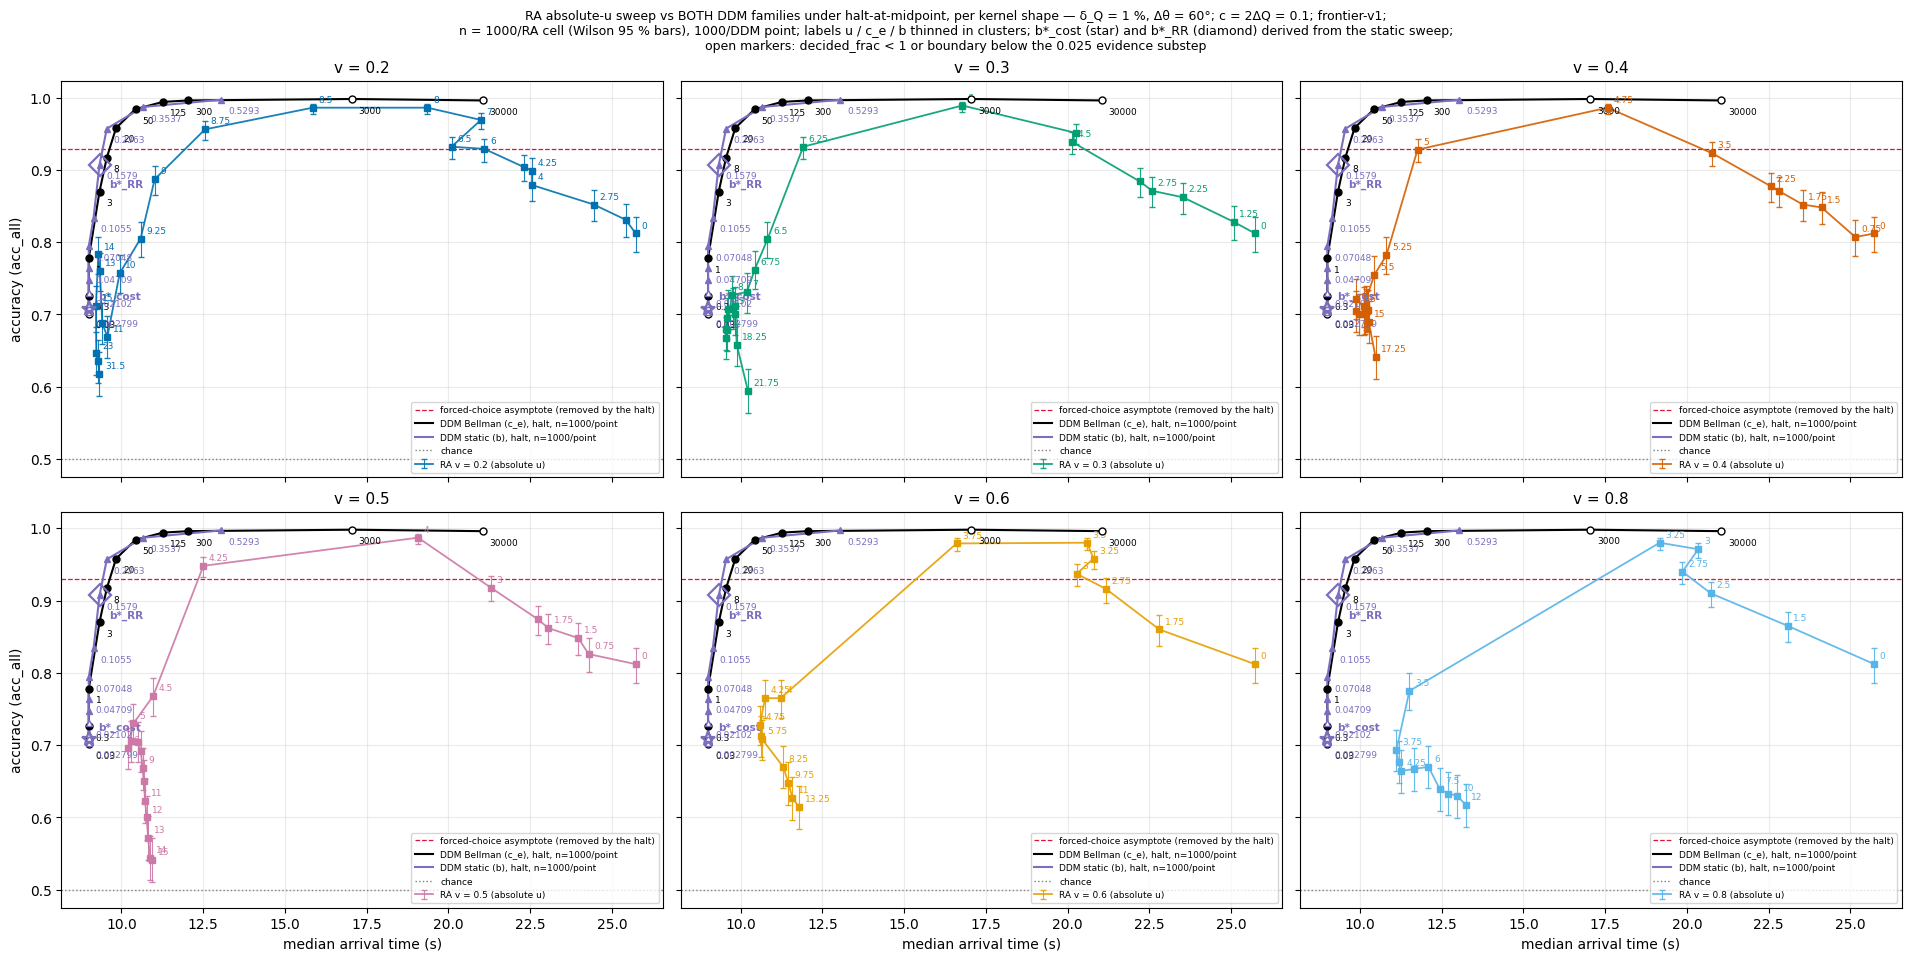

In [ ]:
# RA vs DDM (spec v3) — one panel per kernel shape v (2 x 3, six kernels after
# U-v3), absolute-u sweep against BOTH halt-policy DDM families: Bellman
# (labels = c_e) and static bounds (labels = b, with the derived b*_cost and
# b*_RR marked). Self-contained: re-derives its own loader and helpers.
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statistics import NormalDist

_RA_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_slices")
_DDM_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm_halt")
_V_GRID = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]
_V_COLORS = {0.2: "#0072B2", 0.3: "#009E73", 0.4: "#D55E00", 0.5: "#CC79A7",
             0.6: "#E69F00", 0.8: "#56B4E9"}       # Okabe-Ito, no yellow
_STATIC_COLOR = "#7A6FBE"
_DISC_LIMITED_CE = {0.03, 0.1}   # Bellman z* below one evidence substep (D-11)
_SUBSTEP = 0.025                 # c*sqrt(dt/n_sub) at the 1 s tick
_COST_RATE = 0.1                 # b*_cost functional: P(err) + 0.1 * E[T], c = 2dQ
_TIME_LIMIT = 60.0
_A, _C = 0.05, 0.1
_FC_ASYMPTOTE = NormalDist().cdf(
    (_A / _C) * math.sqrt(0.5 * math.cos(math.radians(30)) / 0.05))


def _load(stem):
    df = pd.read_parquet(Path(stem).with_suffix(".parquet"))
    for col in ("correct", "decided"):
        df[col] = df[col].astype(bool)
    return df


def _wilson_bounds(k, n, z=1.959964):
    p = k / n
    den = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(0.0, centre - half), min(1.0, centre + half)


def _group_stats(df, key):
    rows = []
    for ident, g in df.groupby(key, sort=False):
        arr = g.loc[g["decided"], "t_arrival_s"].astype(float)
        lo, hi = _wilson_bounds(int(g["correct"].sum()), len(g))
        rows.append({key: ident, "n": len(g), "acc_all": g["correct"].mean(),
                     "acc_lo": lo, "acc_hi": hi,
                     "median_t": arr.median() if len(arr) else float("nan"),
                     "decided_frac": g["decided"].mean()})
    return pd.DataFrame(rows)


def _thinned(points, dt_min=0.4, dacc_min=0.02):
    if not points:
        return set()
    keep, last = {0, len(points) - 1}, points[0]
    for i, p in enumerate(points[1:-1], start=1):
        if abs(p[0] - last[0]) >= dt_min or abs(p[1] - last[1]) >= dacc_min:
            keep.add(i)
            last = p
    return keep


ra_df, ddm_df = _load(_RA_ROOT / "trials"), _load(_DDM_ROOT / "ddm_trials")
n_ra = int(ra_df.groupby("cell_id").size().median())
n_ddm = int(ddm_df.groupby("point_id").size().median())

fam = {}
for variant in ("bellman", "static"):
    fd = ddm_df[ddm_df["variant"] == variant]
    st = _group_stats(fd, "point_id")
    st["bound"] = [float(fd[fd["point_id"] == p]["bound"].iloc[0])
                   for p in st["point_id"]]
    fam[variant] = st.sort_values("median_t").reset_index(drop=True)

# b*_cost / b*_RR point estimates from the swept static data (§2b): censored
# trials charged the full 60 s budget; bootstrap CIs live in the next cell.
_bstar = {}
_obj = []
for pid, g in ddm_df[ddm_df["variant"] == "static"].groupby("point_id"):
    b = float(g["bound"].iloc[0])
    n_cens = int((~g["decided"]).sum())
    mean_rt = (g.loc[g["decided"], "rt"].astype(float).sum()
               + n_cens * _TIME_LIMIT) / len(g)
    mean_arr = (g.loc[g["decided"], "t_arrival_s"].astype(float).sum()
                + n_cens * _TIME_LIMIT) / len(g)
    err = 1.0 - g["correct"].mean()
    _obj.append({"b": b, "cost": err + _COST_RATE * mean_rt,
                 "rr": (1.0 - err) / mean_arr})
_obj = pd.DataFrame(_obj)
_bstar["cost"] = float(_obj.loc[_obj["cost"].idxmin(), "b"])
_bstar["rr"] = float(_obj.loc[_obj["rr"].idxmax(), "b"])

fig, axes = plt.subplots(2, 3, figsize=(19, 9.5), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, v in zip(axes.ravel(), _V_GRID):
    ax.axhline(_FC_ASYMPTOTE, color="crimson", ls="--", lw=0.9,
               label="forced-choice asymptote (removed by the halt)")
    # both DDM families — identical in every panel
    for variant, color, marker, lab in (
            ("bellman", "black", "o", "DDM Bellman (c_e), halt"),
            ("static", _STATIC_COLOR, "^", "DDM static (b), halt")):
        st = fam[variant]
        ax.plot(st["median_t"], st["acc_all"], "-", color=color, lw=1.5,
                zorder=3, label=f"{lab}, n={n_ddm}/point")
        pts = list(zip(st["median_t"], st["acc_all"]))
        lab_ix = _thinned(pts)
        for i, (_x, s) in enumerate(st.iterrows()):
            open_m = ((s["bound"] in _DISC_LIMITED_CE
                       if variant == "bellman" else s["bound"] < _SUBSTEP)
                      or s["decided_frac"] < 1.0)
            ax.plot(s["median_t"], s["acc_all"], marker, ms=5, zorder=4,
                    mfc="white" if open_m else color, mec=color)
            if i in lab_ix:
                ax.annotate(f"{s['bound']:g}", pts[i],
                            textcoords="offset points", xytext=(5, -10),
                            fontsize=6.5, color=color)
    for key, mk, txt, off in (("cost", "*", "b*_cost", (7, 7)),
                              ("rr", "D", "b*_RR", (7, -16))):
        s = fam["static"][np.isclose(fam["static"]["bound"], _bstar[key])]
        if len(s):
            ax.plot(s["median_t"].iloc[0], s["acc_all"].iloc[0], mk, ms=11,
                    mfc="none", mec=_STATIC_COLOR, mew=1.6, zorder=5)
            ax.annotate(txt, (s["median_t"].iloc[0], s["acc_all"].iloc[0]),
                        textcoords="offset points", xytext=off, fontsize=7.5,
                        color=_STATIC_COLOR, fontweight="bold")

    # this kernel's absolute-u sweep, connected in u order, Wilson bars
    gv = ra_df[(ra_df["sweep"] == "absolute")
               & np.isclose(ra_df["v"].astype(float), v)]
    order = gv.groupby("cell_id")["u"].first().astype(float)
    st = _group_stats(gv, "cell_id").set_index("cell_id")
    st["u"] = order
    st = st.sort_values("u").dropna(subset=["median_t"])
    color = _V_COLORS[v]
    ax.errorbar(st["median_t"], st["acc_all"],
                yerr=[st["acc_all"] - st["acc_lo"],
                      st["acc_hi"] - st["acc_all"]],
                fmt="-", color=color, lw=1.3, elinewidth=0.8, capsize=2,
                alpha=0.9, zorder=2, label=f"RA v = {v:g} (absolute u)")
    pts = list(zip(st["median_t"], st["acc_all"]))
    lab_ix = _thinned(pts)
    for i, (cid, s) in enumerate(st.iterrows()):
        ax.plot(s["median_t"], s["acc_all"], "s", ms=4.5, zorder=3,
                mfc="white" if s["decided_frac"] < 1 else color, mec=color)
        if i in lab_ix:
            ax.annotate(f"{s['u']:g}", pts[i], textcoords="offset points",
                        xytext=(4, 4), fontsize=6.5, color=color)

    ax.axhline(0.5, color="gray", ls=":", lw=1, label="chance")
    ax.set_title(f"v = {v:g}", fontsize=11)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=6.5, loc="lower right")
for ax in axes[-1]:
    ax.set_xlabel("median arrival time (s)")
for ax in axes[:, 0]:
    ax.set_ylabel("accuracy (acc_all)")
fig.suptitle(
    "RA absolute-u sweep vs BOTH DDM families under halt-at-midpoint, per "
    "kernel shape — δ_Q = 1 %, Δθ = 60°; c = 2ΔQ = 0.1; frontier-v1;\n"
    f"n = {n_ra}/RA cell (Wilson 95 % bars), {n_ddm}/DDM point; labels "
    "u / c_e / b thinned in clusters; b*_cost (star) and b*_RR (diamond) "
    "derived from the static sweep;\nopen markers: decided_frac < 1 or "
    "boundary below the 0.025 evidence substep", fontsize=9)
plt.show()


### Bellman vs static on equal footing — the artifact removed

The previous overlay invites a misreading: its median-arrival axis hides the halt tail that the Bellman policy pays for its extra accuracy, its sparse c_e grid draws chords under the frontier exactly where the log-spaced b grid is dense, and the two families are labeled in incommensurable units (c_e is an error *price*; b is the boundary *itself*). This figure removes all three:

- **A** — the plane in the currency the Bellman functional actually optimizes: **mean** arrival time (censored trials charged the full 60 s). The c_τ time cost is the linearized marginal arrival delay, so E[arrival] is the honest axis; here the Bellman points sit on or above the static points everywhere.
- **B** — both families against the one commensurable quantity, **boundary height** (the Bellman point's z_halt floor vs the static b), log-x with Wilson CIs: at matched boundary the collapsing-from-above Bellman boundary is at least as accurate at every height, visibly more in the knee. Shaded: below the 0.025 evidence substep, where any boundary is floor-limited.
- **C** — the verdict the shared seeds license: **paired per-run_id Δaccuracy (Bellman − static)** at matched boundary, McNemar 95 % CIs, with the mean-arrival price annotated. Positive throughout the knee (up to +0.12 at z ≈ 0.035), zero within noise elsewhere; the extreme-c_e points have no swept b near their z_halt (0.73, 0.96 > b_max = 0.53) and are excluded rather than mismatched.

Read together: the static family traces the *same* trade-off; nowhere does it beat the optimal policy at equal footing.


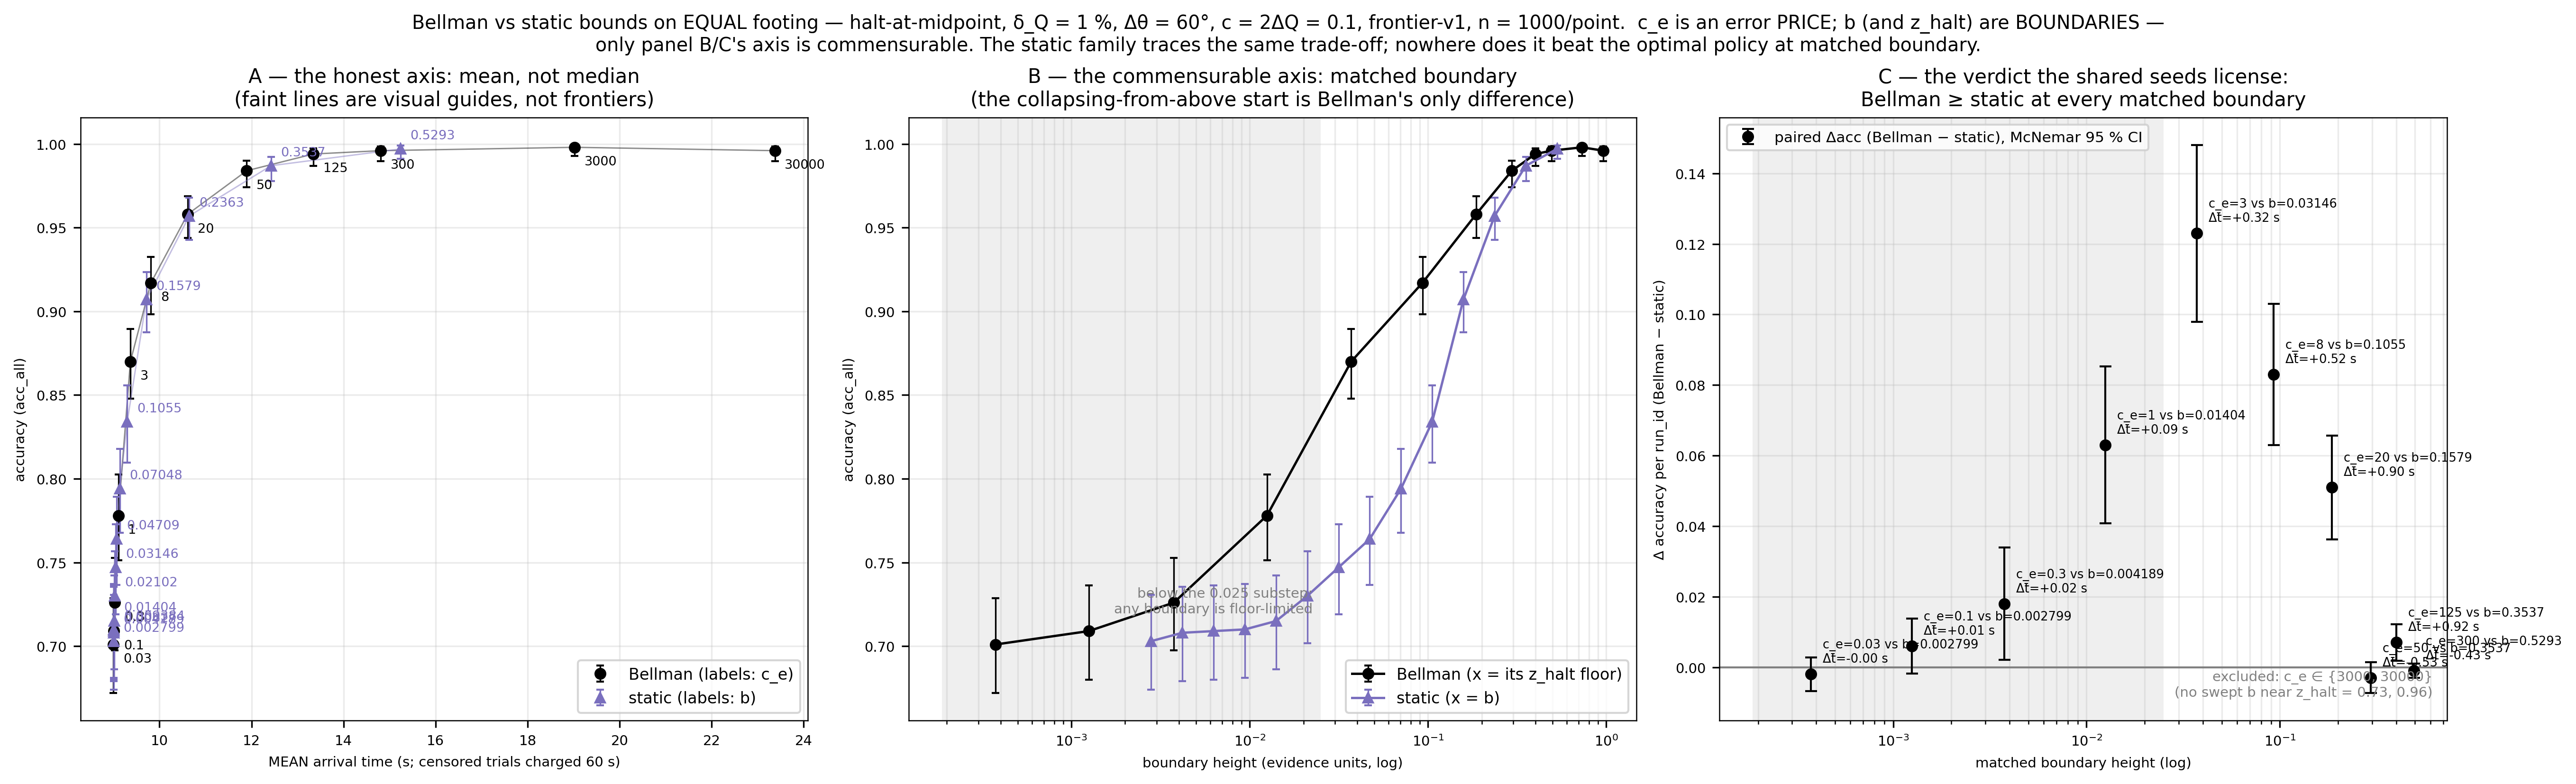

matched pairs (Bellman vs static at equal boundary, paired per run_id):
  c_e=   0.03 (z_halt 0.0004) vs b=0.002799: Δacc=-0.0020 [-0.0068, +0.0028]  Δmean_t=-0.00 s
  c_e=    0.1 (z_halt 0.0012) vs b=0.002799: Δacc=+0.0060 [-0.0018, +0.0138]  Δmean_t=+0.01 s
  c_e=    0.3 (z_halt 0.0037) vs b=0.004189: Δacc=+0.0180 [+0.0021, +0.0339]  Δmean_t=+0.02 s
  c_e=      1 (z_halt 0.0125) vs b=0.01404: Δacc=+0.0630 [+0.0407, +0.0853]  Δmean_t=+0.09 s
  c_e=      3 (z_halt 0.0371) vs b=0.03146: Δacc=+0.1230 [+0.0979, +0.1481]  Δmean_t=+0.32 s
  c_e=      8 (z_halt 0.0930) vs b=0.1055: Δacc=+0.0830 [+0.0630, +0.1030]  Δmean_t=+0.52 s
  c_e=     20 (z_halt 0.1861) vs b=0.1579: Δacc=+0.0510 [+0.0363, +0.0657]  Δmean_t=+0.90 s
  c_e=     50 (z_halt 0.2952) vs b=0.3537: Δacc=-0.0030 [-0.0074, +0.0014]  Δmean_t=-0.53 s
  c_e=    125 (z_halt 0.3999) vs b=0.3537: Δacc=+0.0070 [+0.0018, +0.0122]  Δmean_t=+0.92 s
  c_e=    300 (z_halt 0.4943) vs b=0.5293: Δacc=-0.0010 [-0.0030, +0.0010]  Δmean_t=-0.43 s


In [49]:
# Bellman vs static on EQUAL footing — removes the three artifacts of the
# overlay reading: median-vs-mean, chord drawing across the sparse c_e grid,
# and incommensurable labels (c_e is an error PRICE; b is the boundary ITSELF).
# Self-contained: re-derives its own loader and helpers.
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq

_DDM_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm_halt")
_TL = 60.0                       # time budget; censored trials charged in full
_A, _C = 0.05, 0.1               # A = dQ, c = 2 dQ (evidence channel)
_K = 2 * _A / _C ** 2            # = 10
_SUBSTEP = 0.025                 # evidence substep at the 1 s tick (RECON D-11)
_STATIC_COLOR = "#7A6FBE"
_MATCH_RATIO = 1.3               # a pair is 'matched' if boundaries agree to 30 %


def _z_halt_of_ce(ce):
    """The Bellman halt floor: sinh(a) + a = ce*k*A/2, z = a/k (c_h = 1)."""
    rho = ce * _K * _A / 2.0
    return brentq(lambda a: math.sinh(a) + a - rho, 0.0, 60.0) / _K


def _wilson(k, n, z=1.959964):
    p = k / n
    den = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return p, max(0.0, centre - half), min(1.0, centre + half)


ddm = pd.read_parquet(_DDM_ROOT / "ddm_trials.parquet")
for c in ("correct", "decided"):
    ddm[c] = ddm[c].astype(bool)

pts = []
for pid, g in ddm.groupby("point_id"):
    variant = g["variant"].iloc[0]
    bound = float(g["bound"].iloc[0])
    arr = g.loc[g["decided"], "t_arrival_s"].astype(float)
    n_cens = int((~g["decided"]).sum())
    acc, lo, hi = _wilson(int(g["correct"].sum()), len(g))
    pts.append({"pid": pid, "variant": variant, "bound": bound,
                "z": bound if variant == "static" else _z_halt_of_ce(bound),
                "acc": acc, "acc_lo": lo, "acc_hi": hi,
                "mean_t": (arr.sum() + n_cens * _TL) / len(g)})
pts = pd.DataFrame(pts)
bell = pts[pts.variant == "bellman"].sort_values("z").reset_index(drop=True)
stat = pts[pts.variant == "static"].sort_values("z").reset_index(drop=True)
n_pt = int(ddm.groupby("point_id").size().median())

# --- matched pairs + per-run_id paired contrast (frontier-v1 seeds) ---------
pairs = []
for _i, rb in bell.iterrows():
    rs = stat.iloc[(np.log(stat["z"]) - np.log(rb["z"])).abs().idxmin()]
    matched = (max(rb["z"], rs["z"]) / min(rb["z"], rs["z"]) <= _MATCH_RATIO
               or (rb["z"] < _SUBSTEP and rs["z"] < _SUBSTEP))
    j = (ddm[ddm.point_id == rb["pid"]].set_index("run_id")[["correct"]]
         .join(ddm[ddm.point_id == rs["pid"]].set_index("run_id")[["correct"]],
               lsuffix="_b", rsuffix="_s"))
    n = len(j)
    n01 = int((j.correct_b & ~j.correct_s).sum())
    n10 = int((~j.correct_b & j.correct_s).sum())
    dacc = (n01 - n10) / n
    se = math.sqrt(max(n01 + n10 - (n01 - n10) ** 2 / n, 0.0)) / n
    pairs.append({"ce": rb["bound"], "b": rs["bound"], "z": rb["z"],
                  "dacc": dacc, "lo": dacc - 1.959964 * se,
                  "hi": dacc + 1.959964 * se,
                  "dt_mean": rb["mean_t"] - rs["mean_t"], "matched": matched})
pairs = pd.DataFrame(pairs)

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(18, 5.4),
                                    constrained_layout=True)

# --- A: the plane in the functional's currency (MEAN arrival) ---------------
for df, color, marker, name in ((bell, "black", "o", "Bellman (labels: c_e)"),
                                (stat, _STATIC_COLOR, "^",
                                 "static (labels: b)")):
    axA.errorbar(df["mean_t"], df["acc"],
                 yerr=[df["acc"] - df["acc_lo"], df["acc_hi"] - df["acc"]],
                 fmt=marker, color=color, ms=5, elinewidth=0.8, capsize=2,
                 lw=0, label=name)
    axA.plot(df["mean_t"], df["acc"], "-", color=color, lw=0.7, alpha=0.45)
    for _i, r in df.iterrows():
        axA.annotate(f"{r['bound']:g}", (r["mean_t"], r["acc"]),
                     textcoords="offset points",
                     xytext=(5, -9) if color == "black" else (5, 5),
                     fontsize=6.5, color=color)
axA.set_xlabel("MEAN arrival time (s; censored trials charged 60 s)")
axA.set_ylabel("accuracy (acc_all)")
axA.set_title("A — the honest axis: mean, not median\n"
              "(faint lines are visual guides, not frontiers)", fontsize=10)
axA.grid(alpha=0.25)
axA.legend(fontsize=8, loc="lower right")

# --- B: equal footing — accuracy vs boundary height -------------------------
for df, color, marker, name in (
        (bell, "black", "o", "Bellman (x = its z_halt floor)"),
        (stat, _STATIC_COLOR, "^", "static (x = b)")):
    axB.errorbar(df["z"], df["acc"],
                 yerr=[df["acc"] - df["acc_lo"], df["acc_hi"] - df["acc"]],
                 fmt=marker + "-", color=color, ms=5, lw=1.2, elinewidth=0.8,
                 capsize=2, label=name)
axB.axvspan(pts["z"].min() / 2, _SUBSTEP, color="gray", alpha=0.12, lw=0)
axB.text(_SUBSTEP * 0.9, 0.72, "below the 0.025 substep:\nany boundary is "
         "floor-limited", fontsize=7, ha="right", color="gray")
axB.set_xscale("log")
axB.set_xlabel("boundary height (evidence units, log)")
axB.set_ylabel("accuracy (acc_all)")
axB.set_title("B — the commensurable axis: matched boundary\n"
              "(the collapsing-from-above start is Bellman's only difference)",
              fontsize=10)
axB.grid(alpha=0.25, which="both")
axB.legend(fontsize=8, loc="lower right")

# --- C: the seed-paired verdict ---------------------------------------------
m = pairs[pairs.matched]
axC.axhline(0, color="gray", lw=1)
axC.errorbar(m["z"], m["dacc"], yerr=[m["dacc"] - m["lo"], m["hi"] - m["dacc"]],
             fmt="o", color="black", ms=5, elinewidth=1.0, capsize=3,
             label="paired Δacc (Bellman − static), McNemar 95 % CI")
for _i, r in m.iterrows():
    axC.annotate(f"c_e={r['ce']:g} vs b={r['b']:g}\nΔt̄={r['dt_mean']:+.2f} s",
                 (r["z"], r["dacc"]), textcoords="offset points",
                 xytext=(6, 6), fontsize=6.2)
excl = pairs[~pairs.matched]
if len(excl):
    axC.text(0.98, 0.04, "excluded: c_e ∈ {"
             + ", ".join(f"{c:g}" for c in excl["ce"]) + "}\n(no swept b near "
             "z_halt = " + ", ".join(f"{z:.2f}" for z in excl["z"]) + ")",
             transform=axC.transAxes, ha="right", fontsize=7, color="gray")
axC.axvspan(pts["z"].min() / 2, _SUBSTEP, color="gray", alpha=0.12, lw=0)
axC.set_xscale("log")
axC.set_xlabel("matched boundary height (log)")
axC.set_ylabel("Δ accuracy per run_id (Bellman − static)")
axC.set_title("C — the verdict the shared seeds license:\n"
              "Bellman ≥ static at every matched boundary", fontsize=10)
axC.grid(alpha=0.25, which="both")
axC.legend(fontsize=7.5, loc="upper left")

fig.suptitle(
    "Bellman vs static bounds on EQUAL footing — halt-at-midpoint, δ_Q = 1 %, "
    f"Δθ = 60°, c = 2ΔQ = 0.1, frontier-v1, n = {n_pt}/point.  "
    "c_e is an error PRICE; b (and z_halt) are BOUNDARIES —\nonly panel B/C's "
    "axis is commensurable. The static family traces the same trade-off; "
    "nowhere does it beat the optimal policy at matched boundary.", fontsize=9.5)
plt.show()

print("matched pairs (Bellman vs static at equal boundary, paired per run_id):")
for _i, r in pairs.iterrows():
    tag = "" if r["matched"] else "  [excluded: boundaries not comparable]"
    print(f"  c_e={r['ce']:>7g} (z_halt {r['z']:.4f}) vs b={r['b']:g}: "
          f"Δacc={r['dacc']:+.4f} [{r['lo']:+.4f}, {r['hi']:+.4f}]  "
          f"Δmean_t={r['dt_mean']:+.2f} s{tag}")
n_win = int(((pairs.matched) & (pairs.lo > 0)).sum())
n_tie = int(((pairs.matched) & (pairs.lo <= 0) & (pairs.hi >= 0)).sum())
print(f"\nof {int(pairs.matched.sum())} matched pairs: Bellman significantly "
      f"more accurate in {n_win}, statistical tie in {n_tie}, static ahead "
      f"in {int((pairs.matched & (pairs.hi < 0)).sum())}.")


### Companion: Bellman *without* the halt vs the static bounds

The same comparison with the halt taken away from the Bellman side only — the frozen forced-choice rerun (commitment forced by geometry at arrival, z(T_max) = 0) against the halted static family, still seed-paired per run_id. This separates the two ingredients of the previous figure: **boundary optimality** and **motion policy**. Expect the sign of the paired contrast to flip along the boundary axis: through the knee the collapsing Bellman boundary still wins (the halt is barely engaged at those heights, so taking it away costs nothing), but at high boundaries the forced-choice Bellman is capped by the interrogation artifact at ≈ 0.94 while a plain static bound *allowed to halt* sails past it — at the ceiling the motion policy matters more than the boundary family.


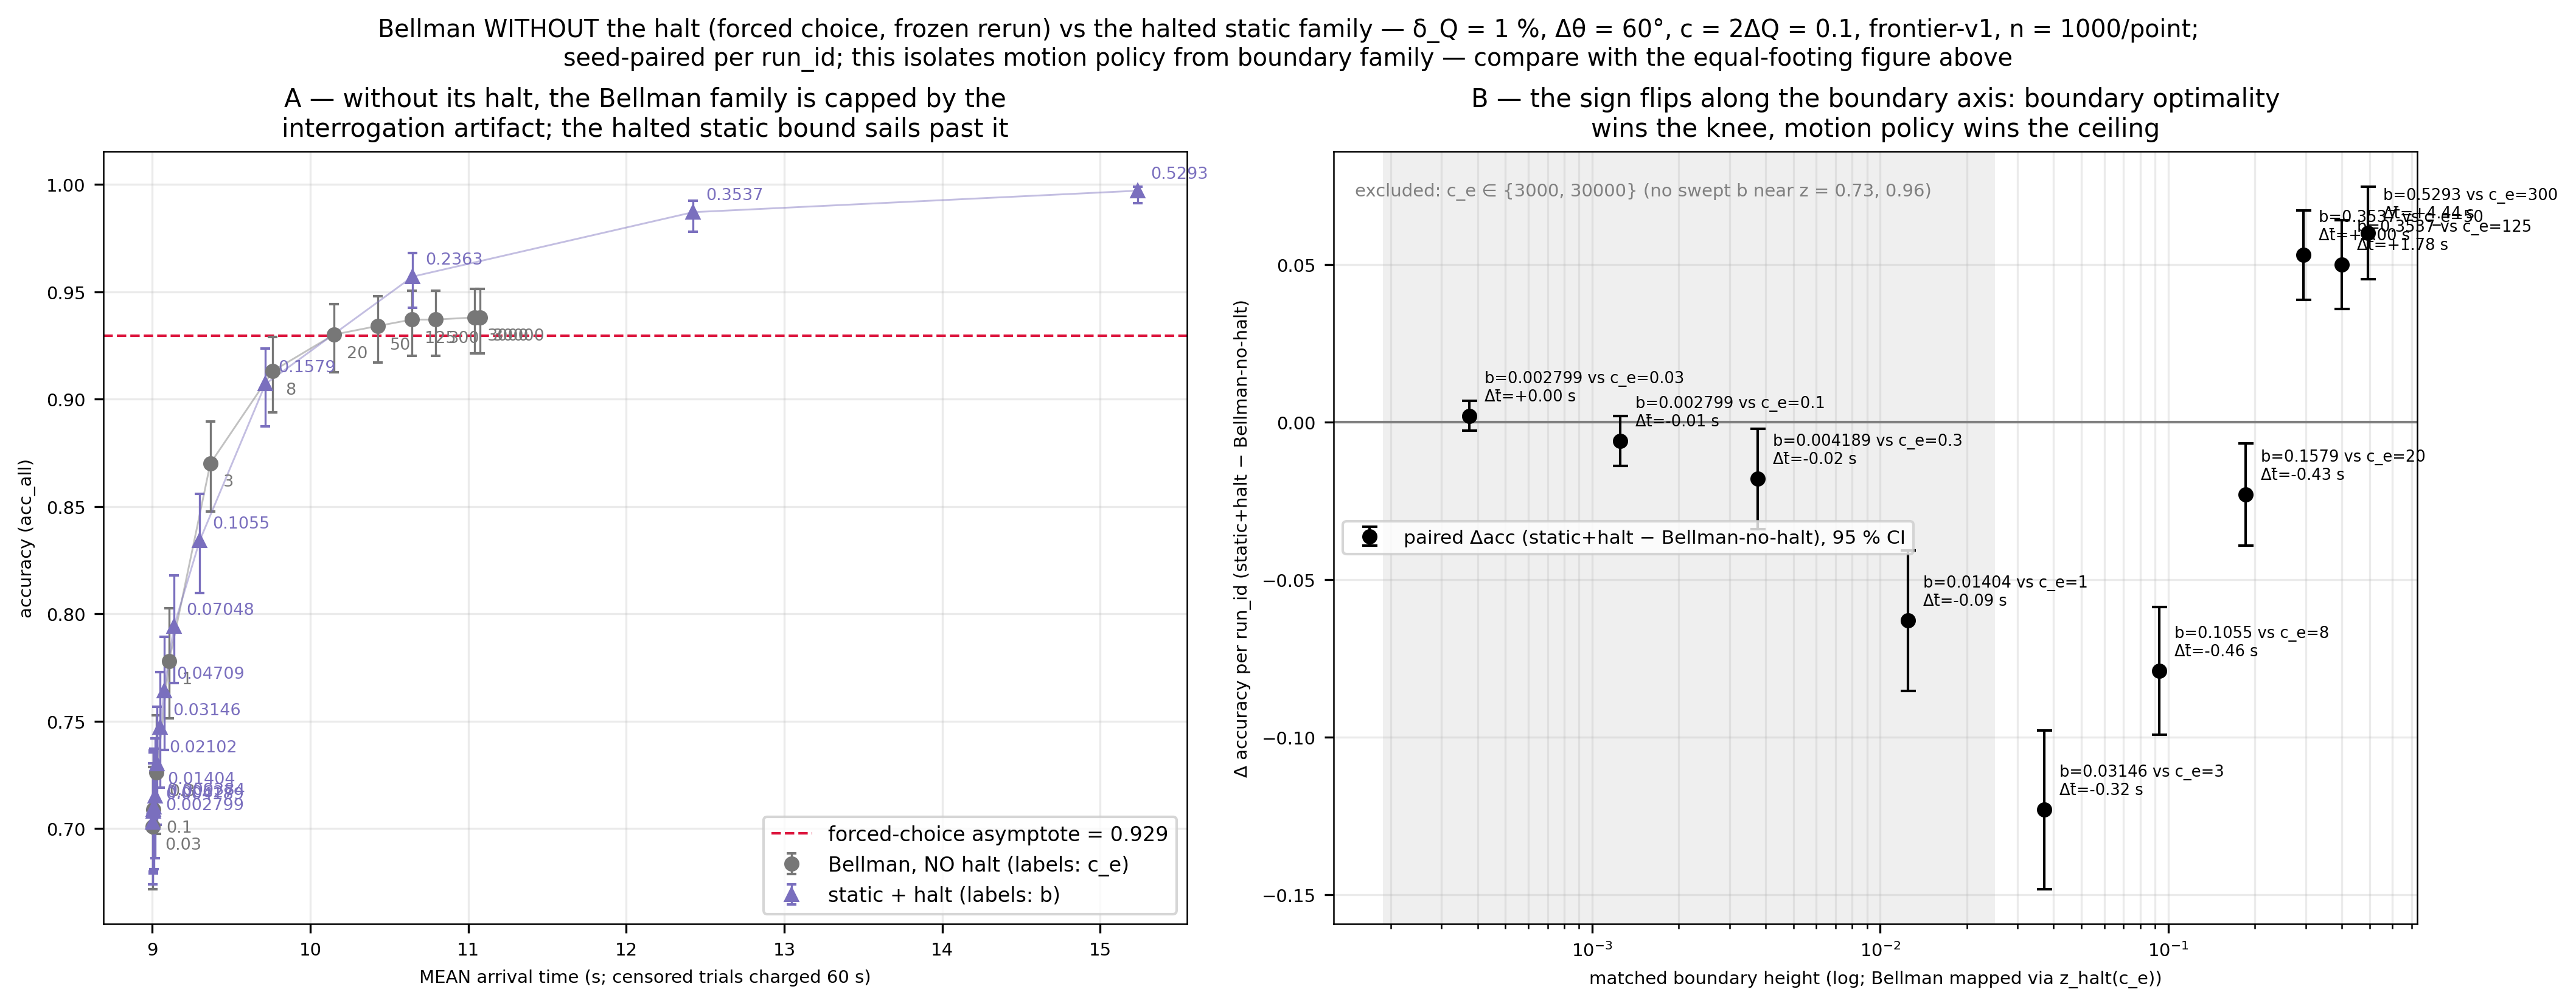

matched pairs (static+halt vs forced-choice Bellman at equal boundary):
  b= 0.002799 vs c_e=   0.03 (z 0.0004): Δacc=+0.0020 [-0.0028, +0.0068]  Δmean_t=+0.00 s
  b= 0.002799 vs c_e=    0.1 (z 0.0012): Δacc=-0.0060 [-0.0138, +0.0018]  Δmean_t=-0.01 s
  b= 0.004189 vs c_e=    0.3 (z 0.0037): Δacc=-0.0180 [-0.0339, -0.0021]  Δmean_t=-0.02 s
  b=  0.01404 vs c_e=      1 (z 0.0125): Δacc=-0.0630 [-0.0853, -0.0407]  Δmean_t=-0.09 s
  b=  0.03146 vs c_e=      3 (z 0.0371): Δacc=-0.1230 [-0.1481, -0.0979]  Δmean_t=-0.32 s
  b=   0.1055 vs c_e=      8 (z 0.0930): Δacc=-0.0790 [-0.0993, -0.0587]  Δmean_t=-0.46 s
  b=   0.1579 vs c_e=     20 (z 0.1861): Δacc=-0.0230 [-0.0392, -0.0068]  Δmean_t=-0.43 s
  b=   0.3537 vs c_e=     50 (z 0.2952): Δacc=+0.0530 [+0.0388, +0.0672]  Δmean_t=+2.00 s
  b=   0.3537 vs c_e=    125 (z 0.3999): Δacc=+0.0500 [+0.0359, +0.0641]  Δmean_t=+1.78 s
  b=   0.5293 vs c_e=    300 (z 0.4943): Δacc=+0.0600 [+0.0453, +0.0747]  Δmean_t=+4.44 s
  b=   0.5293 vs c_e=   3000

In [50]:
# Bellman WITHOUT the halt (frozen forced-choice rerun) vs the halted static
# family — boundary optimality separated from motion policy. Seed-paired.
# Self-contained: re-derives its own loader and helpers.
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from statistics import NormalDist

_FC_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm")        # forced choice
_HALT_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm_halt")  # static lives here
_TL = 60.0
_A, _C = 0.05, 0.1
_K = 2 * _A / _C ** 2
_SUBSTEP = 0.025
_STATIC_COLOR = "#7A6FBE"
_FC_COLOR = "#777777"
_MATCH_RATIO = 1.3
_FC_ASYMPTOTE = NormalDist().cdf(
    (_A / _C) * math.sqrt(0.5 * math.cos(math.radians(30)) / 0.05))


def _z_of_ce(ce):
    """The boundary scale of a c_e: the z_halt the halted problem floors at —
    used purely as the matching coordinate between the families."""
    rho = ce * _K * _A / 2.0
    return brentq(lambda a: math.sinh(a) + a - rho, 0.0, 60.0) / _K


def _wilson(k, n, z=1.959964):
    p = k / n
    den = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return p, max(0.0, centre - half), min(1.0, centre + half)


def _load(stem):
    df = pd.read_parquet(Path(stem).with_suffix(".parquet"))
    for c in ("correct", "decided"):
        df[c] = df[c].astype(bool)
    return df


fc = _load(_FC_ROOT / "ddm_trials")                     # 12 Bellman points, no halt
stat_tr = _load(_HALT_ROOT / "ddm_trials")
stat_tr = stat_tr[stat_tr["variant"] == "static"]       # 14 static points, halt

def _points(df, is_static):
    rows = []
    for pid, g in df.groupby("point_id"):
        bound = float(g["bound"].iloc[0] if is_static else g["c_e"].iloc[0])
        arr = g.loc[g["decided"], "t_arrival_s"].astype(float)
        n_cens = int((~g["decided"]).sum())
        acc, lo, hi = _wilson(int(g["correct"].sum()), len(g))
        rows.append({"pid": pid, "bound": bound,
                     "z": bound if is_static else _z_of_ce(bound),
                     "acc": acc, "acc_lo": lo, "acc_hi": hi,
                     "mean_t": (arr.sum() + n_cens * _TL) / len(g)})
    return pd.DataFrame(rows).sort_values("z").reset_index(drop=True)


bell_fc = _points(fc, is_static=False)
stat = _points(stat_tr, is_static=True)
n_pt = int(fc.groupby("point_id").size().median())

# --- matched pairs, paired per run_id (static − forced-choice Bellman) ------
pairs = []
for _i, rb in bell_fc.iterrows():
    rs = stat.iloc[(np.log(stat["z"]) - np.log(rb["z"])).abs().idxmin()]
    matched = (max(rb["z"], rs["z"]) / min(rb["z"], rs["z"]) <= _MATCH_RATIO
               or (rb["z"] < _SUBSTEP and rs["z"] < _SUBSTEP))
    j = (stat_tr[stat_tr.point_id == rs["pid"]].set_index("run_id")[["correct"]]
         .join(fc[fc.point_id == rb["pid"]].set_index("run_id")[["correct"]],
               lsuffix="_s", rsuffix="_b"))
    n = len(j)
    n01 = int((j.correct_s & ~j.correct_b).sum())
    n10 = int((~j.correct_s & j.correct_b).sum())
    dacc = (n01 - n10) / n
    se = math.sqrt(max(n01 + n10 - (n01 - n10) ** 2 / n, 0.0)) / n
    pairs.append({"ce": rb["bound"], "b": rs["bound"], "z": rb["z"],
                  "dacc": dacc, "lo": dacc - 1.959964 * se,
                  "hi": dacc + 1.959964 * se,
                  "dt_mean": rs["mean_t"] - rb["mean_t"], "matched": matched})
pairs = pd.DataFrame(pairs)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5.4), constrained_layout=True)

# --- A: the plane, mean axis ------------------------------------------------
axA.axhline(_FC_ASYMPTOTE, color="crimson", ls="--", lw=1,
            label=f"forced-choice asymptote = {_FC_ASYMPTOTE:.3f}")
for df, color, marker, name in (
        (bell_fc, _FC_COLOR, "o", "Bellman, NO halt (labels: c_e)"),
        (stat, _STATIC_COLOR, "^", "static + halt (labels: b)")):
    axA.errorbar(df["mean_t"], df["acc"],
                 yerr=[df["acc"] - df["acc_lo"], df["acc_hi"] - df["acc"]],
                 fmt=marker, color=color, ms=5, elinewidth=0.8, capsize=2,
                 lw=0, label=name)
    axA.plot(df["mean_t"], df["acc"], "-", color=color, lw=0.7, alpha=0.45)
    for _i, r in df.iterrows():
        axA.annotate(f"{r['bound']:g}", (r["mean_t"], r["acc"]),
                     textcoords="offset points",
                     xytext=(5, -9) if color == _FC_COLOR else (5, 5),
                     fontsize=6.5, color=color)
axA.set_xlabel("MEAN arrival time (s; censored trials charged 60 s)")
axA.set_ylabel("accuracy (acc_all)")
axA.set_title("A — without its halt, the Bellman family is capped by the\n"
              "interrogation artifact; the halted static bound sails past it",
              fontsize=10)
axA.grid(alpha=0.25)
axA.legend(fontsize=8, loc="lower right")

# --- B: paired verdict along the boundary axis ------------------------------
m = pairs[pairs.matched]
axB.axhline(0, color="gray", lw=1)
axB.errorbar(m["z"], m["dacc"], yerr=[m["dacc"] - m["lo"], m["hi"] - m["dacc"]],
             fmt="o", color="black", ms=5, elinewidth=1.0, capsize=3,
             label="paired Δacc (static+halt − Bellman-no-halt), 95 % CI")
for _i, r in m.iterrows():
    axB.annotate(f"b={r['b']:g} vs c_e={r['ce']:g}\nΔt̄={r['dt_mean']:+.2f} s",
                 (r["z"], r["dacc"]), textcoords="offset points",
                 xytext=(6, 6), fontsize=6.2)
excl = pairs[~pairs.matched]
if len(excl):
    axB.text(0.02, 0.96, "excluded: c_e ∈ {"
             + ", ".join(f"{c:g}" for c in excl["ce"]) + "} (no swept b near "
             "z = " + ", ".join(f"{z:.2f}" for z in excl["z"]) + ")",
             transform=axB.transAxes, ha="left", va="top", fontsize=7,
             color="gray")
axB.axvspan(min(pairs["z"].min(), stat["z"].min()) / 2, _SUBSTEP,
            color="gray", alpha=0.12, lw=0)
axB.set_xscale("log")
axB.set_xlabel("matched boundary height (log; Bellman mapped via z_halt(c_e))")
axB.set_ylabel("Δ accuracy per run_id (static+halt − Bellman-no-halt)")
axB.set_title("B — the sign flips along the boundary axis: boundary optimality\n"
              "wins the knee, motion policy wins the ceiling", fontsize=10)
axB.grid(alpha=0.25, which="both")
axB.legend(fontsize=7.5, loc="center left")

fig.suptitle(
    "Bellman WITHOUT the halt (forced choice, frozen rerun) vs the halted "
    f"static family — δ_Q = 1 %, Δθ = 60°, c = 2ΔQ = 0.1, frontier-v1, "
    f"n = {n_pt}/point;\nseed-paired per run_id; this isolates motion policy "
    "from boundary family — compare with the equal-footing figure above",
    fontsize=9.5)
plt.show()

print("matched pairs (static+halt vs forced-choice Bellman at equal boundary):")
for _i, r in pairs.iterrows():
    tag = "" if r["matched"] else "  [excluded: boundaries not comparable]"
    print(f"  b={r['b']:>9g} vs c_e={r['ce']:>7g} (z {r['z']:.4f}): "
          f"Δacc={r['dacc']:+.4f} [{r['lo']:+.4f}, {r['hi']:+.4f}]  "
          f"Δmean_t={r['dt_mean']:+.2f} s{tag}")
mm = pairs[pairs.matched]
print(f"\nof {len(mm)} matched pairs: static+halt significantly ahead in "
      f"{int((mm.lo > 0).sum())}, tie in "
      f"{int(((mm.lo <= 0) & (mm.hi >= 0)).sum())}, Bellman-no-halt ahead in "
      f"{int((mm.hi < 0).sum())}.")


### Five commensurable comparisons — outcomes, price, criterion, realization, reference

Every defensible way to put the two families on one footing, in one place:

1. **Same outcomes — the plane.** (P_correct, T) is defined for any policy. Δt at matched accuracy and Δacc at matched time by interpolation along each family curve — reported on **both** time statistics with one censoring rule (censored trials charged the full 60 s), because mean and median disagree here for a real reason: the halt makes decision times bimodal.
2. **Same price — the scalar cost.** J = c_e·P_err + E[arrival] is a number for any policy at any price. For each c_e: Bellman(c_e) vs the best static bound at that same price, argmin_b J(b; c_e) — the matched-**preference** comparison, the only test that speaks to "optimal" because it is the solver's own objective evaluated on both families. The frontier-v1 pairing turns it into a per-run_id ΔJ with a CI. Reward rate is the price-free cousin.
3. **Same effective criterion.** Boundaries are commensurable only as the height at which decisions actually occur: z̄ = E[z(T_dec)] for Bellman (from the campaign's own solved tables), b for static. The floor z_halt is just the bottom of the bracket [z_halt, z(0)]; matching on z̄ isolates what the collapse *shape* contributes, separately from patience.
4. **Same evidence realization.** On identical percept streams: how often do the two policies choose the same target, and who is right when they disagree — McNemar's raw ingredients at matched price, in units of decisions.
5. **Same theoretical reference.** The fixed-drift SPRT frontier acc = 1/(1+e^{−kb}), DT = (b/A)·tanh(kb/2) is the optimal stationary trade-off; both empirical curves are measured as distance from it (absolute efficiency, in decision time). The effective SNR k_eff is **fitted** from the static sweep (logit(acc) = k_eff·b above the substep) — if it is not the solver's k = 10, the reference itself moves.


1. SAME OUTCOMES — the plane, both time statistics, one censoring rule

  MEAN arrival axis (censored trials charged 60 s):
    Δt at matched accuracy (negative: Bellman earlier):
      acc   0.9: Bellman   9.65 s  static   9.68 s  Δt = -0.02 s
      acc  0.95: Bellman  10.46 s  static  10.52 s  Δt = -0.06 s
      acc  0.99: Bellman  12.76 s  static  13.27 s  Δt = -0.50 s
      acc 0.995: Bellman  14.08 s  static  14.67 s  Δt = -0.60 s
    Δacc at matched time (positive: Bellman more accurate):
      t =  9.5 s: Bellman 0.8700  static 0.8340  Δacc = +0.0360
      t = 10.5 s: Bellman 0.9170  static 0.9070  Δacc = +0.0100
      t = 12.0 s: Bellman 0.9840  static 0.9570  Δacc = +0.0270
      t = 14.0 s: Bellman 0.9940  static 0.9870  Δacc = +0.0070

  MEDIAN arrival axis (censored trials charged 60 s):
    Δt at matched accuracy (negative: Bellman earlier):
      acc   0.9: Bellman   9.47 s  static   9.31 s  Δt = +0.16 s
      acc  0.95: Bellman   9.78 s  static   9.52 s  Δt = +0.26 s
   

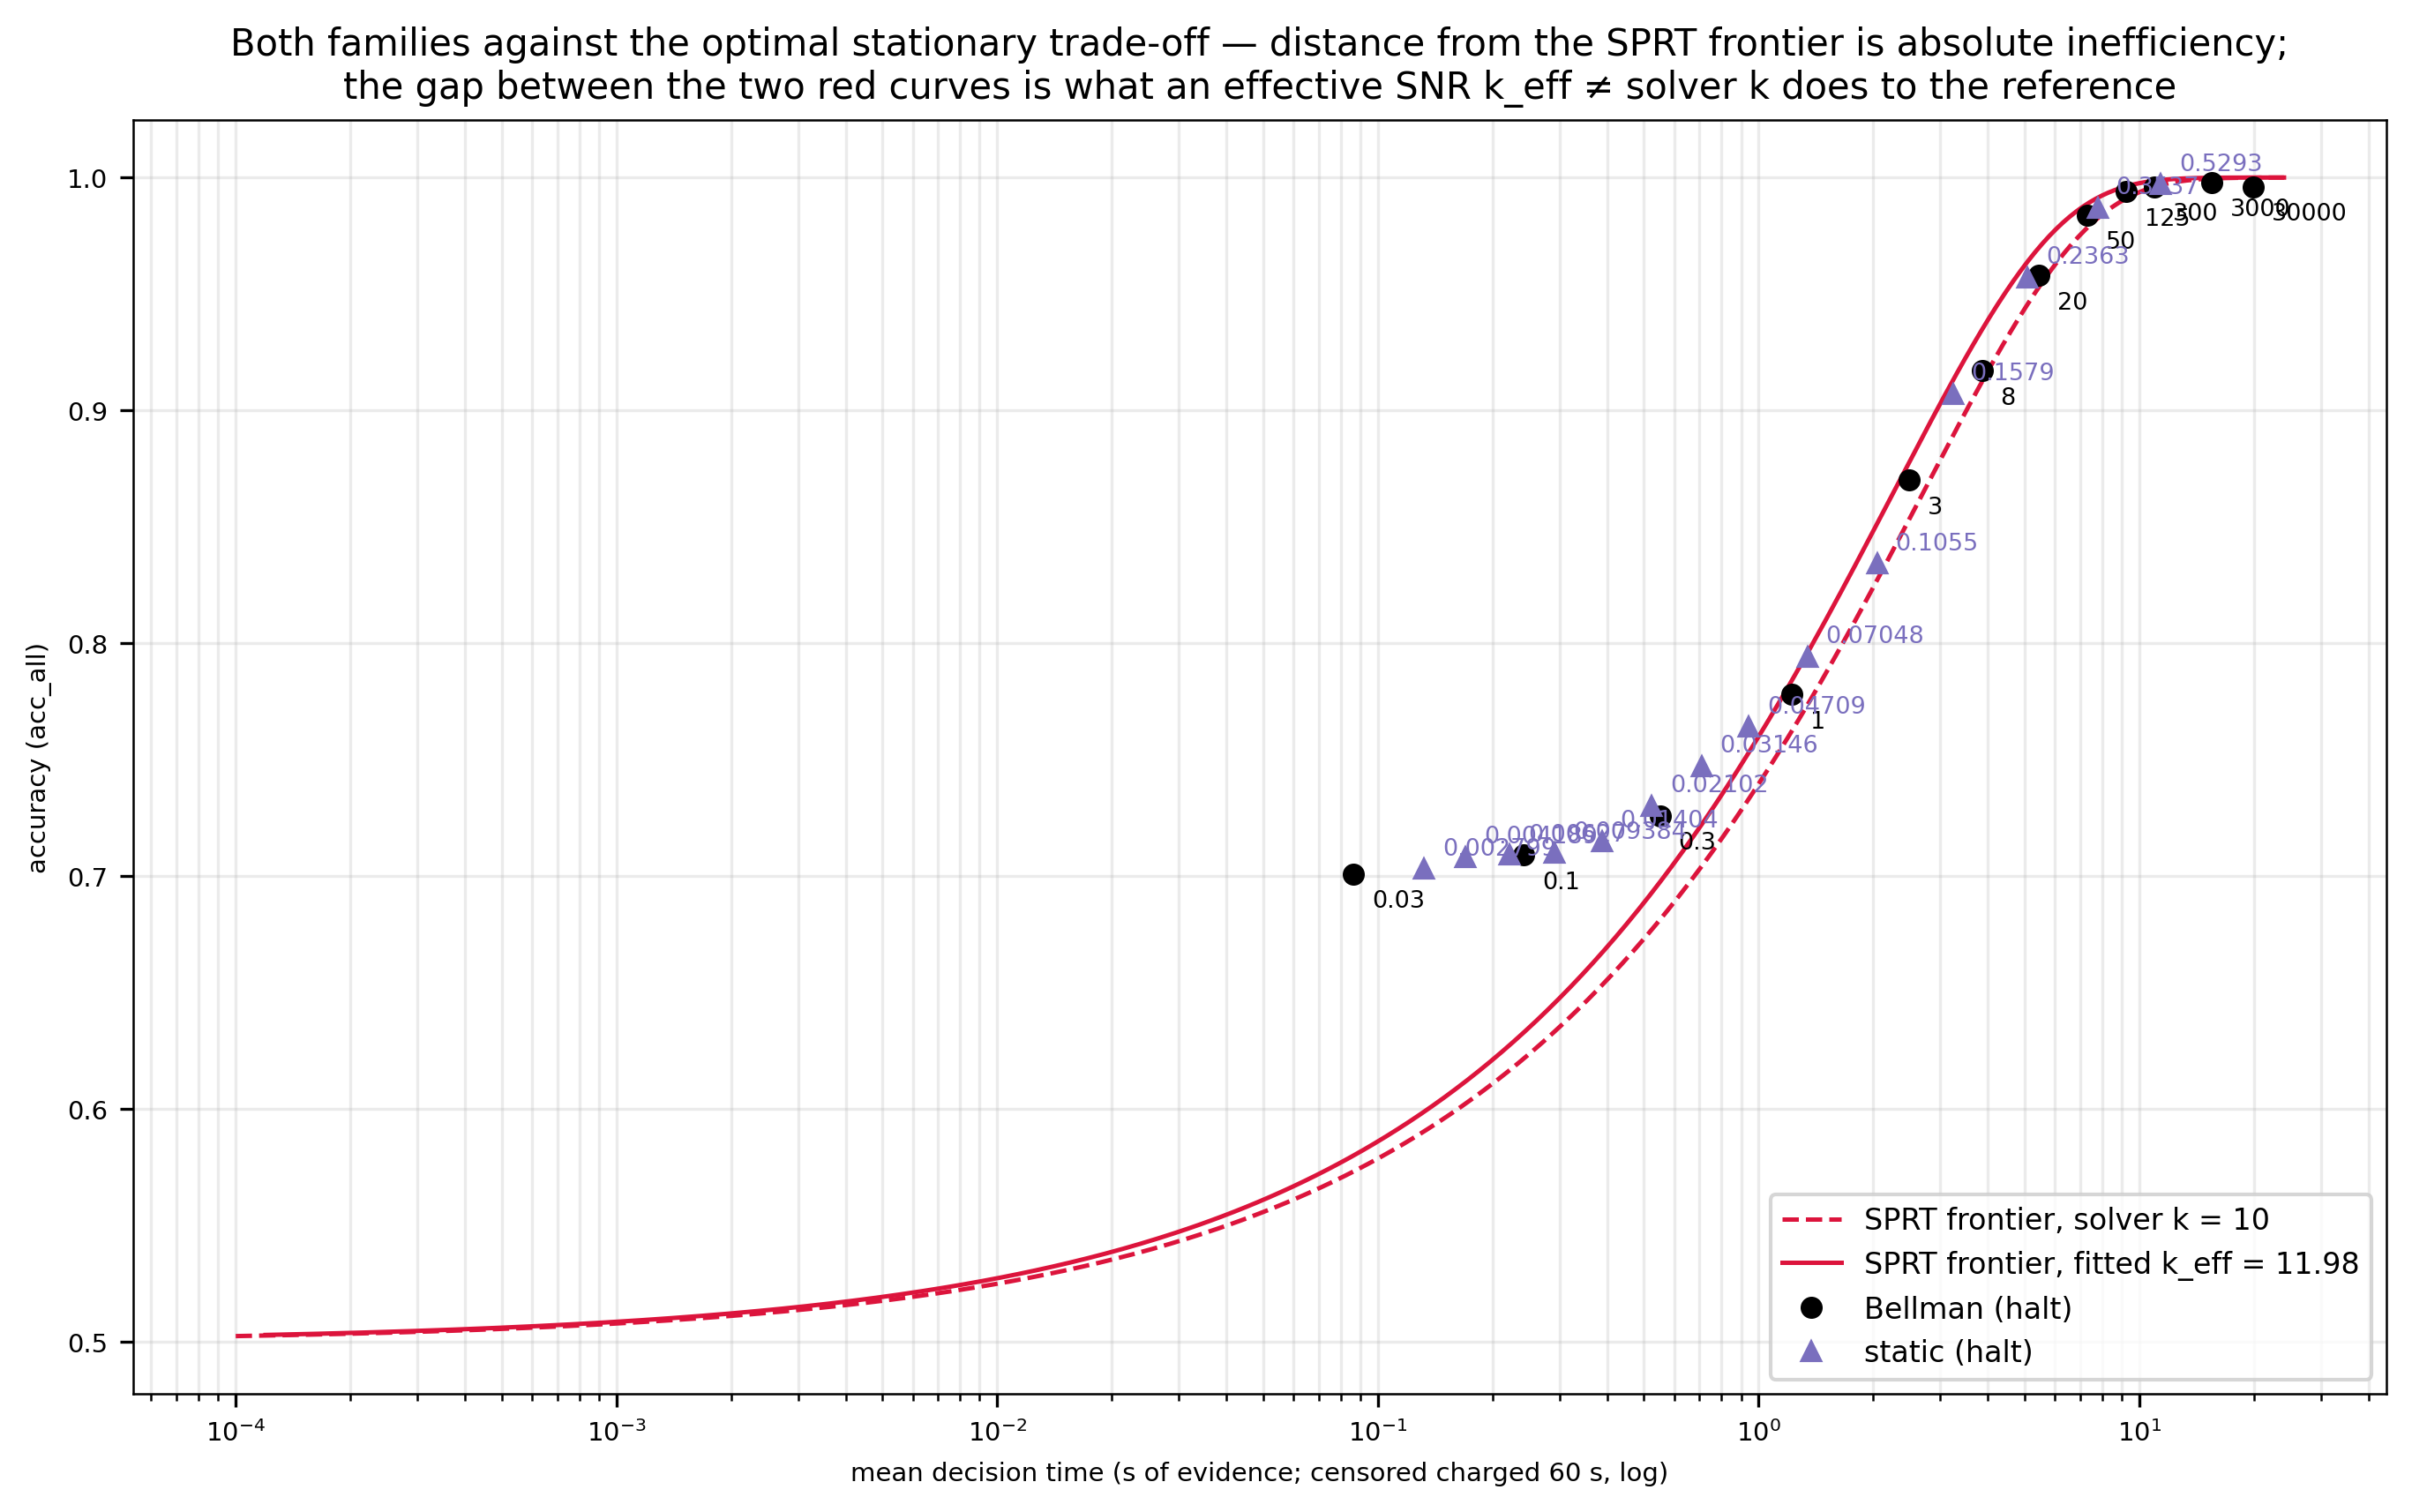

In [51]:
# Five commensurable Bellman-vs-static comparisons (halt campaign, both
# families, frontier-v1 seeds): outcomes / price / effective criterion /
# evidence realization / theoretical reference.
# Self-contained: re-derives its own loader and helpers.
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm_halt")
_TL = 60.0                      # one censoring rule, both sides, all sections
_A, _C = 0.05, 0.1
_K_SOLVER = 2 * _A / _C ** 2    # = 10, the solver's SNR
_SUBSTEP = 0.025
_STATIC_COLOR = "#7A6FBE"

ddm = pd.read_parquet(_ROOT / "ddm_trials.parquet")
for c in ("correct", "decided"):
    ddm[c] = ddm[c].astype(bool)
# per-trial times under the single censoring rule
ddm["arr_c"] = ddm["t_arrival_s"].where(ddm["decided"], _TL).astype(float)
ddm["rt_c"] = ddm["rt"].where(ddm["decided"], _TL).astype(float)

pts = []
for pid, g in ddm.groupby("point_id"):
    variant = g["variant"].iloc[0]
    bound = float(g["bound"].iloc[0])
    arr = g.loc[g["decided"], "t_arrival_s"].astype(float)
    pts.append({"pid": pid, "variant": variant, "bound": bound,
                "acc": g["correct"].mean(), "err": 1 - g["correct"].mean(),
                "med": float(arr.median()), "mean": g["arr_c"].mean(),
                "mean_rt": g["rt_c"].mean()})
pts = pd.DataFrame(pts)
bell = pts[pts.variant == "bellman"].sort_values("bound").reset_index(drop=True)
stat = pts[pts.variant == "static"].sort_values("bound").reset_index(drop=True)


# ===========================================================================
print("=" * 76)
print("1. SAME OUTCOMES — the plane, both time statistics, one censoring rule")
print("=" * 76)
def _monotone(p, xcol):
    p = p.sort_values(xcol)
    return p[xcol].to_numpy(), np.maximum.accumulate(p["acc"].to_numpy())
def _t_at(t, a, target):
    if target > a[-1] or target < a[0]:
        return float("nan")
    i = int(np.searchsorted(a, target))
    return float(t[i] if (a[i] == target or i == 0) else
                 np.interp(target, [a[i - 1], a[i]], [t[i - 1], t[i]]))
def _a_at(t, a, q):
    if q < t[0]:
        return float("nan")
    return float(a[min(int(np.searchsorted(t, q, side="right")) - 1, len(a) - 1)])

for xcol, name in (("mean", "MEAN arrival"), ("med", "MEDIAN arrival")):
    tb, ab = _monotone(bell, xcol)
    ts, as_ = _monotone(stat, xcol)
    print(f"\n  {name} axis (censored trials charged {_TL:.0f} s):")
    print("    Δt at matched accuracy (negative: Bellman earlier):")
    for a in (0.90, 0.95, 0.99, 0.995):
        db, ds = _t_at(tb, ab, a), _t_at(ts, as_, a)
        print(f"      acc {a:5}: Bellman {db:6.2f} s  static {ds:6.2f} s  "
              f"Δt = {db - ds:+.2f} s")
    print("    Δacc at matched time (positive: Bellman more accurate):")
    for q in (9.5, 10.5, 12.0, 14.0):
        da, dsa = _a_at(tb, ab, q), _a_at(ts, as_, q)
        print(f"      t = {q:4.1f} s: Bellman {da:.4f}  static {dsa:.4f}  "
              f"Δacc = {da - dsa:+.4f}")
print("\n  (mean and median disagree for a real reason — the halt makes the")
print("   decision-time distribution bimodal; both are reported, same rule.)")


# ===========================================================================
print("\n" + "=" * 76)
print("2. SAME PRICE — J = c_e*P_err + E[arrival]; matched-preference pairs,")
print("   per-run_id paired ΔJ with CI (the solver's own objective)")
print("=" * 76)
price_pairs = []
for _i, rb in bell.iterrows():
    ce = rb["bound"]
    js = ce * stat["err"] + stat["mean"]
    rs = stat.loc[js.idxmin()]
    gb = ddm[ddm.point_id == rb["pid"]].set_index("run_id")
    gs = ddm[ddm.point_id == rs["pid"]].set_index("run_id")
    j = gb[["correct", "arr_c"]].join(gs[["correct", "arr_c"]],
                                      lsuffix="_b", rsuffix="_s")
    dJ = (ce * ((~j.correct_b).astype(float) - (~j.correct_s).astype(float))
          + (j.arr_c_b - j.arr_c_s))
    m, se = float(dJ.mean()), float(dJ.std(ddof=1) / math.sqrt(len(dJ)))
    lo, hi = m - 1.959964 * se, m + 1.959964 * se
    verdict = ("Bellman better" if hi < 0 else
               "static better" if lo > 0 else "TIE (CI spans 0)")
    price_pairs.append({"ce": ce, "b_opt": rs["bound"], "pid_s": rs["pid"],
                        "pid_b": rb["pid"]})
    print(f"  c_e={ce:>7g}: J_bellman={ce * rb['err'] + rb['mean']:8.3f}  "
          f"best static b={rs['bound']:g} J={float(js.min()):8.3f}  "
          f"paired ΔJ(B−S) = {m:+7.3f} [{lo:+7.3f}, {hi:+7.3f}]  {verdict}")
rr_note = []
for name, fam in (("Bellman", bell), ("static", stat)):
    rbest = fam.loc[(fam["acc"] / fam["mean"]).idxmax()]
    g = ddm[ddm.point_id == rbest["pid"]]
    rng = np.random.default_rng(1)
    boots = [g.iloc[rng.integers(0, len(g), len(g))].pipe(
        lambda s: s["correct"].mean() / s["arr_c"].mean()) for _ in range(500)]
    rr_note.append(f"{name}: best RR {rbest['acc'] / rbest['mean']:.5f} /s at "
                   f"{rbest['pid']} (CI95 [{np.percentile(boots, 2.5):.5f}, "
                   f"{np.percentile(boots, 97.5):.5f}])")
print("\n  price-free cousin — reward rate P(correct)/E[arrival]:")
for line in rr_note:
    print(f"    {line}")


# ===========================================================================
print("\n" + "=" * 76)
print("3. SAME EFFECTIVE CRITERION — z̄ = E[z(T_dec)] from the solved tables;")
print("   the floor z_halt is only the bottom of the bracket [z_halt, z(0)]")
print("=" * 76)
tables = {}
for f in sorted((_ROOT / "table_cache").glob("*.npz")):
    z = np.load(f, allow_pickle=True)
    names = [str(n) for n in z["input_names"]]
    ce = float(z["input_values"][names.index("c_e")])
    tables[ce] = (np.asarray(z["t_grid"], float), np.asarray(z["z_arr"], float))
zbar_rows = []
for _i, rb in bell.iterrows():
    ce = rb["bound"]
    if ce not in tables:
        continue
    tg, za = tables[ce]
    g = ddm[(ddm.point_id == rb["pid"]) & ddm.decided]
    # z at the moment of decision; np.interp clamps past the horizon to the
    # table's explicit final row z(T_max) = z_halt (the runtime's hold rule).
    zdec = np.interp(g["rt"].astype(float).to_numpy(), tg, za)
    zbar = float(zdec.mean())
    rs = stat.iloc[(np.log(stat["bound"]) - np.log(max(zbar, 1e-6)))
                   .abs().idxmin()]
    gb = ddm[ddm.point_id == rb["pid"]].set_index("run_id")
    gs = ddm[ddm.point_id == rs["pid"]].set_index("run_id")
    j = gb[["correct"]].join(gs[["correct"]], lsuffix="_b", rsuffix="_s")
    n01 = int((j.correct_b & ~j.correct_s).sum())
    n10 = int((~j.correct_b & j.correct_s).sum())
    dacc = (n01 - n10) / len(j)
    zbar_rows.append((ce, za[0], za[-1], zbar, rs["bound"], dacc))
    print(f"  c_e={ce:>7g}: z(0)={za[0]:.4f}  z_halt={za[-1]:.4f}  "
          f"z̄(T_dec)={zbar:.4f}  -> nearest b={rs['bound']:g}: "
          f"paired Δacc(B−S)={dacc:+.4f}")
print("\n  matching on z̄ (not the floor) shows the collapse shape's own")
print("  contribution: decisions occur high on the collapsing boundary, so the")
print("  Bellman point behaves like a LARGER static bound than z_halt suggests.")


# ===========================================================================
print("\n" + "=" * 76)
print("4. SAME EVIDENCE REALIZATION — agreement + discordant decisions on")
print("   identical percept streams, at the matched-price pairs of section 2")
print("=" * 76)
for pp in price_pairs:
    gb = ddm[ddm.point_id == pp["pid_b"]].set_index("run_id")
    gs = ddm[ddm.point_id == pp["pid_s"]].set_index("run_id")
    j = gb[["correct", "choice", "decided"]].join(
        gs[["correct", "choice", "decided"]], lsuffix="_b", rsuffix="_s")
    both = j[j.decided_b & j.decided_s]
    agree = float((both.choice_b == both.choice_s).mean())
    dis = both[both.choice_b != both.choice_s]
    n01 = int((j.correct_b & ~j.correct_s).sum())
    n10 = int((~j.correct_b & j.correct_s).sum())
    b_right = float(dis["correct_b"].mean()) if len(dis) else float("nan")
    print(f"  c_e={pp['ce']:>7g} vs b={pp['b_opt']:g}: same choice "
          f"{agree:.3f}; disagree on {len(dis):3d} trials, Bellman right in "
          f"{b_right:.2f} of them; discordant-correctness cells "
          f"n01(B only right)={n01:3d}, n10(S only right)={n10:3d}")


# ===========================================================================
print("\n" + "=" * 76)
print("5. SAME THEORETICAL REFERENCE — the fixed-drift SPRT frontier, with")
print("   k_eff FITTED from the static sweep (logit(acc) = k_eff * b)")
print("=" * 76)
fit = stat[stat["bound"] >= _SUBSTEP]
logit = np.log(fit["acc"] / (1 - fit["acc"]))
k_eff = float((fit["bound"] * logit).sum() / (fit["bound"] ** 2).sum())
print(f"  solver k = {_K_SOLVER:g};  fitted k_eff = {k_eff:.3f} "
      f"(static points b >= {_SUBSTEP}; per-point implied k: "
      + ", ".join(f"{lg / b:.1f}" for b, lg in zip(fit['bound'], logit)) + ")")

def _sprt(k, b):
    return 1.0 / (1.0 + np.exp(-k * b)), b / _A * np.tanh(0.5 * k * b)

print("\n  absolute efficiency: excess mean DECISION time over the SPRT at the")
print("  same accuracy (k_eff reference; censored charged 60 s):")
for name, fam in (("Bellman", bell), ("static", stat)):
    for _i, r in fam.iterrows():
        if not (0.5 < r["acc"] < 1.0):
            continue
        b_ref = math.log(r["acc"] / (1 - r["acc"])) / k_eff
        dt_ref = b_ref / _A * math.tanh(0.5 * k_eff * b_ref)
        print(f"    {name:>7} {r['pid']:>12}: acc {r['acc']:.4f}  mean DT "
              f"{r['mean_rt']:6.2f} s  SPRT {dt_ref:5.2f} s  excess "
              f"{r['mean_rt'] - dt_ref:+6.2f} s")

fig, ax = plt.subplots(figsize=(9, 5.6), constrained_layout=True)
bdense = np.geomspace(1e-3, 1.2, 400)
for k, ls, lab in ((_K_SOLVER, "--", f"SPRT frontier, solver k = {_K_SOLVER:g}"),
                   (k_eff, "-", f"SPRT frontier, fitted k_eff = {k_eff:.2f}")):
    acc_k, dt_k = _sprt(k, bdense)
    ax.plot(dt_k, acc_k, ls, color="crimson", lw=1.2, label=lab)
for fam, color, marker, name in ((bell, "black", "o", "Bellman (halt)"),
                                 (stat, _STATIC_COLOR, "^", "static (halt)")):
    ax.plot(fam["mean_rt"], fam["acc"], marker, color=color, ms=5, lw=0,
            label=name)
    for _i, r in fam.iterrows():
        ax.annotate(f"{r['bound']:g}", (r["mean_rt"], r["acc"]),
                    textcoords="offset points",
                    xytext=(5, -9) if color == "black" else (5, 4),
                    fontsize=6.5, color=color)
ax.set_xscale("log")
ax.set_xlabel("mean decision time (s of evidence; censored charged 60 s, log)")
ax.set_ylabel("accuracy (acc_all)")
ax.set_title("Both families against the optimal stationary trade-off — "
             "distance from the SPRT frontier is absolute inefficiency;\n"
             "the gap between the two red curves is what an effective SNR "
             "k_eff ≠ solver k does to the reference", fontsize=10)
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=8, loc="lower right")
plt.show()


### The static-bound family in detail — deriving b\*_cost and b\*_RR (§2b)

The optimum boundaries are **derived from the swept data, never assumed**. Left: the cost functional the collapsing policy optimizes, cost(b) = P(error) + c·E[T_decision] with c = 2ΔQ = 0.1 (censored trials charged the full 60 s). Middle: reward rate P(correct)/E[T_arrival]. Both panels carry the Wald constant-drift analytic (ER(b) = 1/(1+e^{kb}), DT(b) = (b/A)·tanh(kb/2), k = 2A/c² = 10) as a sanity anchor — the embodied task's time-varying geometry shifts the empirical optimum, and the discrepancy is reported, not hidden. Right: what each b buys — accuracy and arrival time, with the halt fraction underneath. Bootstrap CIs (500 resamples over trials) on the argmin/argmax use the same code the CLI analysis runs.

Expect b\*_RR to sit near its Wald anchor, but b\*_cost to land in a **flat basin across the discretisation-limited zone** far below the Wald prediction: at the 1 s tick the first evidence substep (0.025) dwarfs any tiny boundary, so the measured error there is set by single-substep SNR (≈ 0.29), well below Wald's ≈ 0.5 — cheap-and-fast beats the analytic optimum for this functional. That is D-11 physics, not noise; the wide CI on b\*_cost says exactly this.


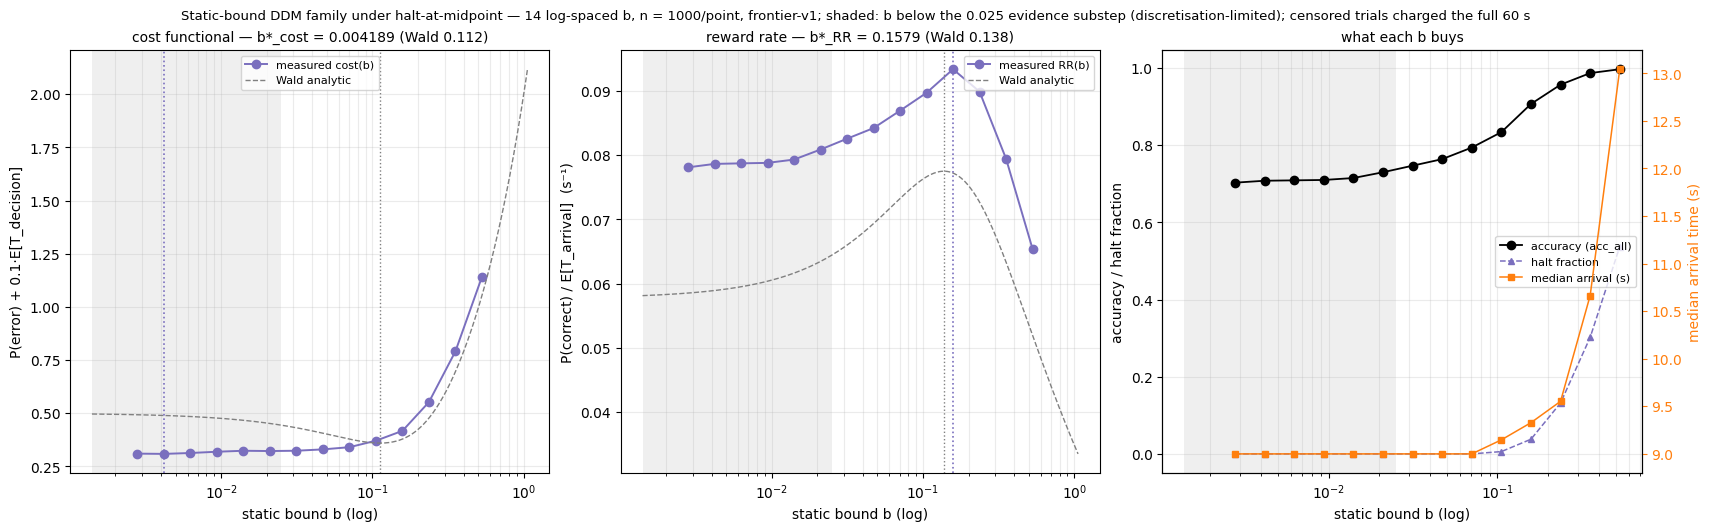

b*_cost = 0.004189  CI95 [0.002799, 0.03146]  (Wald analytic 0.1124, discrepancy -0.1082)
b*_RR   = 0.1579  CI95 [0.1579, 0.1579]  (Wald analytic 0.1376, discrepancy +0.02031)
(500 bootstrap resamples; functional: P(error) + c*E[T_decision], c = 2*dQ = 0.1; censored trials count the full 60 s budget)


In [ ]:
# The static-bound family (§2b): cost functional, reward rate, and the derived
# optima b*_cost / b*_RR with bootstrap CIs and the Wald analytic anchor.
# Self-contained: imports the campaign package (scripts/ra_ddm_frontier) so the
# b* statistics are the same code the CLI analysis runs.
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("scripts/ra_ddm_frontier").resolve()))
import importlib
import seeding, frontier, aggregate, analyze_overlay as ao  # noqa: E402
for _m in (seeding, frontier, aggregate):
    importlib.reload(_m)
ao = importlib.reload(ao)

_ddm = ao.load_trials(Path("../seoul-data/beta-1/ra_ddm_frontier_ddm_halt/ddm_trials"))
_static = _ddm[_ddm["variant"] == "static"].copy()
_static["halted"] = _static["halted"].apply(lambda x: x is True)

bstar = ao.static_bstar(_static)
bs = np.array(bstar["b_grid"])
cost = np.array([bstar["b_star_cost"]["cost_at_b"][f"{b:g}"] for b in bs])
rr = np.array([bstar["b_star_rr"]["rr_at_b"][f"{b:g}"] for b in bs])

# Wald constant-drift analytic on a dense grid (the anchor, not the truth)
_k, _A = 10.0, 0.05
_t_travel = 0.5 * math.cos(math.radians(30)) / 0.05
dense = np.geomspace(bs[0] / 2, bs[-1] * 2, 800)
w_er = 1.0 / (1.0 + np.exp(_k * dense))
w_dt = dense / _A * np.tanh(0.5 * _k * dense)
w_cost = w_er + ao.COST_TIME_RATE * w_dt
w_rr = (1.0 - w_er) / (_t_travel + w_dt)

per_b = []
for pid, g in _static.groupby("point_id"):
    arr = g.loc[g["decided"], "t_arrival_s"].astype(float)
    per_b.append({"b": float(g["bound"].iloc[0]), "acc": g["correct"].mean(),
                  "median_t": arr.median(), "halt_frac": g["halted"].mean()})
per_b = pd.DataFrame(per_b).sort_values("b").reset_index(drop=True)

fig, (axC, axR, axB) = plt.subplots(1, 3, figsize=(17, 5.2),
                                    constrained_layout=True)
for ax in (axC, axR, axB):
    ax.set_xscale("log")
    ax.axvspan(bs[0] / 2, ao.frontier.EVIDENCE_SUBSTEP, color="gray",
               alpha=0.12, lw=0)
    ax.grid(alpha=0.25, which="both")
    ax.set_xlabel("static bound b (log)")

axC.plot(bs, cost, "o-", color="#7A6FBE", lw=1.4, label="measured cost(b)")
axC.plot(dense, w_cost, "--", color="gray", lw=1, label="Wald analytic")
b_c = bstar["b_star_cost"]["estimate"]
axC.axvline(b_c, color="#7A6FBE", ls=":", lw=1.2)
axC.axvline(bstar["wald_analytic"]["b_star_cost"], color="gray", ls=":", lw=1)
axC.set_ylabel("P(error) + 0.1·E[T_decision]")
axC.set_title(f"cost functional — b*_cost = {b_c:g} "
              f"(Wald {bstar['wald_analytic']['b_star_cost']:.3g})", fontsize=10)
axC.legend(fontsize=8)

axR.plot(bs, rr, "o-", color="#7A6FBE", lw=1.4, label="measured RR(b)")
axR.plot(dense, w_rr, "--", color="gray", lw=1, label="Wald analytic")
b_r = bstar["b_star_rr"]["estimate"]
axR.axvline(b_r, color="#7A6FBE", ls=":", lw=1.2)
axR.axvline(bstar["wald_analytic"]["b_star_rr"], color="gray", ls=":", lw=1)
axR.set_ylabel("P(correct) / E[T_arrival]  (s⁻¹)")
axR.set_title(f"reward rate — b*_RR = {b_r:g} "
              f"(Wald {bstar['wald_analytic']['b_star_rr']:.3g})", fontsize=10)
axR.legend(fontsize=8)

axB.plot(per_b["b"], per_b["acc"], "o-", color="black", lw=1.3,
         label="accuracy (acc_all)")
axB.plot(per_b["b"], per_b["halt_frac"], "^--", color="#7A6FBE", lw=1.1,
         ms=5, label="halt fraction")
axB.set_ylabel("accuracy / halt fraction")
axB2 = axB.twinx()
axB2.plot(per_b["b"], per_b["median_t"], "s-", color="tab:orange", lw=1.1,
          ms=4, label="median arrival (s)")
axB2.set_ylabel("median arrival time (s)", color="tab:orange")
axB2.tick_params(axis="y", colors="tab:orange")
h1, l1 = axB.get_legend_handles_labels()
h2, l2 = axB2.get_legend_handles_labels()
axB.legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")
axB.set_title("what each b buys", fontsize=10)

fig.suptitle(
    "Static-bound DDM family under halt-at-midpoint — 14 log-spaced b, "
    "n = 1000/point, frontier-v1; shaded: b below the 0.025 evidence substep "
    "(discretisation-limited); censored trials charged the full 60 s", fontsize=9.5)
plt.show()

print(f"b*_cost = {b_c:g}  CI95 {bstar['b_star_cost']['ci95']}  "
      f"(Wald analytic {bstar['wald_analytic']['b_star_cost']:.4g}, "
      f"discrepancy {bstar['wald_analytic']['discrepancy_cost']:+.4g})")
print(f"b*_RR   = {b_r:g}  CI95 {bstar['b_star_rr']['ci95']}  "
      f"(Wald analytic {bstar['wald_analytic']['b_star_rr']:.4g}, "
      f"discrepancy {bstar['wald_analytic']['discrepancy_rr']:+.4g})")
print(f"({bstar['n_boot']} bootstrap resamples; functional: "
      f"{bstar['cost_functional']})")


### Tuning curves at six kernels (wave 3: Set U-v3)

Accuracy vs absolute coupling u on log-x, now per six kernel shapes — the kernel extension tests û_dec and peak-height invariance beyond the frontier-dominant range. The same structure repeats at every v: rise to a peak just below u\*(v), the cliff through the u = 0 floor near ~0.7·u\*, the committed plateau ≈ 0.70, and the deep super-critical slide **below the no-coupling floor** — with wave 3 a six-kernel result. The six u = 0 controls are trial-for-trial identical (the gate above), so a single floor line serves every panel.


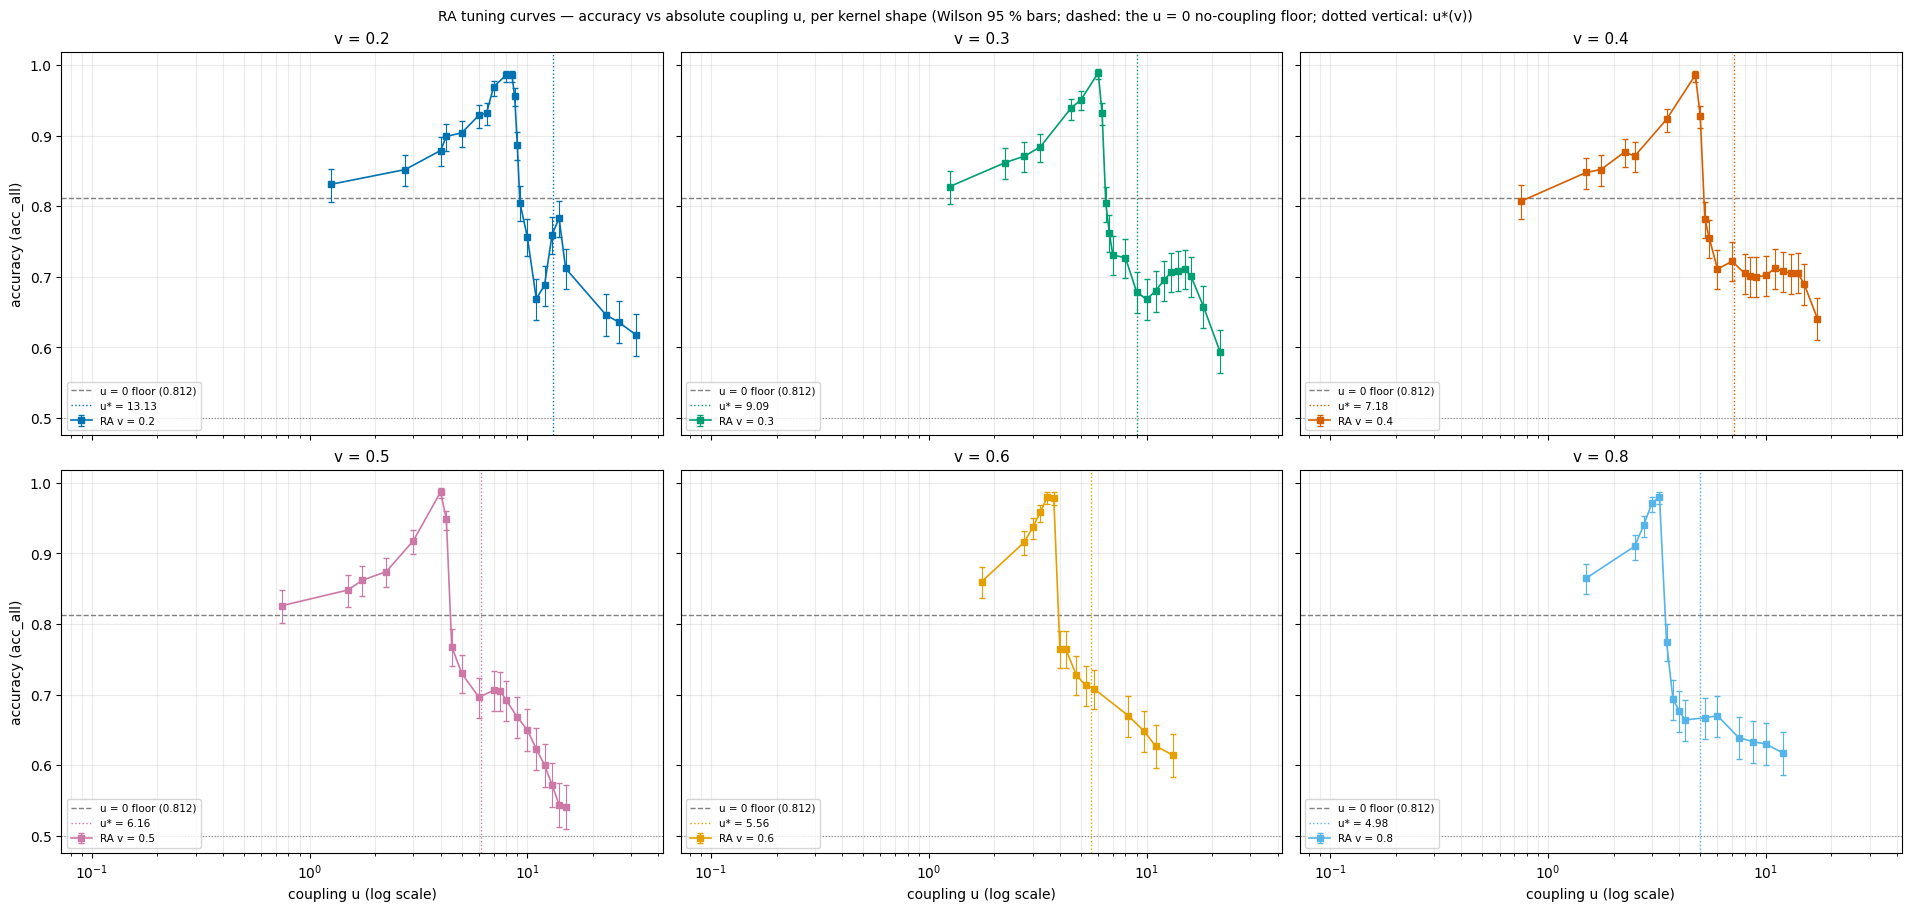

In [ ]:
# RA tuning curves — accuracy vs absolute coupling u (log-x), per kernel shape.
# Wave 3 (Set U-v3) extends the family to v in {0.6, 0.8}: full arc-length
# grids, deep tails u_hat in {1.75, 2.0, 2.4} and u = 0 controls — six panels.
# Self-contained: re-derives its own loader and helpers, so the cell runs on its own.
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_RA_ROOT = Path("../seoul-data/beta-1/ra_ddm_frontier_slices")
_V_GRID = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8]


def _wilson(k, n, z=1.959964):
    p = k / n
    den = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return p, max(0.0, centre - half), min(1.0, centre + half)


ra_df = pd.read_parquet(_RA_ROOT / "trials.parquet")
for col in ("correct", "decided"):
    ra_df[col] = ra_df[col].astype(bool)

_V_COLORS = {0.2: "#0072B2", 0.3: "#009E73", 0.4: "#D55E00", 0.5: "#CC79A7",
             0.6: "#E69F00", 0.8: "#56B4E9"}   # Okabe-Ito, no yellow
v_colors = _V_COLORS
fig, axes = plt.subplots(2, 3, figsize=(19, 9), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, v in zip(axes.ravel(), _V_GRID):
    gv = ra_df[(ra_df["sweep"] == "absolute")
               & np.isclose(ra_df["v"].astype(float), v)]
    u_star = float(gv["u_star"].astype(float).iloc[0])
    stats = []
    for cid, g in gv.groupby("cell_id"):
        acc, lo, hi = _wilson(int(g["correct"].sum()), len(g))
        stats.append({"u": float(g["u"].iloc[0]), "acc": acc,
                      "lo": lo, "hi": hi})
    stats.sort(key=lambda s: s["u"])
    color = v_colors[v]
    floor = next((s for s in stats if s["u"] == 0.0), None)
    if floor is not None:
        ax.axhline(floor["acc"], color="gray", ls="--", lw=1,
                   label=f"u = 0 floor ({floor['acc']:.3f})")
    pos = [s for s in stats if s["u"] > 0]
    ax.errorbar([s["u"] for s in pos], [s["acc"] for s in pos],
                yerr=[[s["acc"] - s["lo"] for s in pos],
                      [s["hi"] - s["acc"] for s in pos]],
                fmt="s-", color=color, ms=4, lw=1.2, elinewidth=0.8,
                capsize=2, label=f"RA v = {v:g}")
    ax.axvline(u_star, color=color, ls=":", lw=1, label=f"u* = {u_star:.2f}")
    ax.axhline(0.5, color="gray", ls=":", lw=0.8)
    ax.set_xscale("log")
    ax.set_title(f"v = {v:g}", fontsize=11)
    ax.grid(alpha=0.25, which="both")
    ax.legend(fontsize=7.5, loc="lower left")
for ax in axes[-1]:
    ax.set_xlabel("coupling u (log scale)")
for ax in axes[:, 0]:
    ax.set_ylabel("accuracy (acc_all)")
fig.suptitle("RA tuning curves — accuracy vs absolute coupling u, per kernel "
             "shape (Wilson 95 % bars; dashed: the u = 0 no-coupling floor; "
             "dotted vertical: u*(v))", fontsize=10)
plt.show()

### Regret, paired contrasts, and the ceiling verdict — against the halted DDM (§11)

The normative benchmark is now the halt-policy DDM (both families pooled into one monotone family-best curve). Regret is reported for the cross-validated RA envelope at matched accuracy (Δt) and matched time (Δacc), with bootstrap CIs; the paired per-run_id McNemar contrasts are licensed by the shared `frontier-v1` seeds. The §11 ceiling verification is the decisive test: with the interrogation artifact removed and the extreme-c_e points measured under halt, the DDM's free-response ceiling is genuine — the RA claim must clear **both** the measured DDM best and what remains of the analytic bound with CI separation.


In [ ]:
# RA vs the HALTED DDM — regret, paired per-run_id contrasts, and the §11
# ceiling verdict. Self-contained: imports the campaign package
# (scripts/ra_ddm_frontier) so the statistics are the same code the CLI runs.
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path("scripts/ra_ddm_frontier").resolve()))
import importlib
import seeding, frontier, aggregate, analyze_overlay as ao  # noqa: E402
for _m in (seeding, frontier, aggregate):
    importlib.reload(_m)
ao = importlib.reload(ao)

_ra = ao.load_trials(Path("../seoul-data/beta-1/ra_ddm_frontier_slices/trials"))
_ddm = ao.load_trials(Path("../seoul-data/beta-1/ra_ddm_frontier_ddm_halt/ddm_trials"))

# --- how far each frontier reaches ------------------------------------------
_env_pts = [(e["median_t"], e["acc_all"]) for e in ao.envelope(_ra)]
_t_r, _a_r = ao.monotone_curve(_env_pts)
_ddm_pts = [(s["median_t"], s["acc_all"])
            for s in ao.group_stats(_ddm, "point_id")
            if s["median_t"] == s["median_t"]]
_t_d, _a_d = ao.monotone_curve(_ddm_pts)
print(f"curve reach: RA envelope up to acc {_a_r[-1]:.3f} (at {_t_r[-1]:.1f} s); "
      f"halted DDM family-best up to acc {_a_d[-1]:.3f} (at {_t_d[-1]:.1f} s).")
print("Under halt-at-midpoint the DDM is no longer horizon-bound: its "
      "free-response ceiling is genuine, and matched-accuracy regret is "
      "defined all the way up.\n")

# --- regret at matched accuracy / matched time (bootstrap CIs) --------------
ao.N_BOOT = 300          # ~5-10 min; raise for publication-final CIs
regret = ao.regret_with_ci(_ra, _ddm)
print("regret of the RA envelope vs the monotone halted-DDM curve")
print("(dt > 0: the RA reaches that accuracy LATER than the DDM):")
for a, r in regret["matched_accuracy_dt_s"].items():
    if r["estimate"] == r["estimate"]:
        print(f"  dt(acc={a}) = {r['estimate']:+6.2f} s   "
              f"CI95 [{r['ci95'][0]:+.2f}, {r['ci95'][1]:+.2f}]")
    else:
        print(f"  dt(acc={a}) undefined (outside a curve's accuracy range)")
lo, hi = regret["time_support_overlap_s"]
print(f"\nmatched-time dacc over the overlapping support [{lo:.1f}, {hi:.1f}] s")
print("(dacc > 0: the RA envelope is MORE accurate at that arrival time):")
for t, r in regret["matched_time_dacc"].items():
    print(f"  dacc(t={t} s) = {r['estimate']:+.3f}   "
          f"CI95 [{r['ci95'][0]:+.3f}, {r['ci95'][1]:+.3f}]")

# --- paired McNemar: each Set-R cell vs the nearest-time DDM point ----------
# (both families are candidates; the chosen point_id names the family)
mc = pd.DataFrame(ao.mcnemar(_ra, _ddm))
sig = mc[(mc["dacc_lo"] > 0) | (mc["dacc_hi"] < 0)]
print(f"\npaired McNemar (per run_id, licensed by the shared seed scheme): "
      f"{len(mc)} Set-R cells vs nearest-time DDM points; "
      f"{len(sig)} with a 95% CI excluding zero.")
cols = ["cell_id", "ddm_point", "ra_median_t", "ddm_median_t",
        "paired_dacc", "dacc_lo", "dacc_hi", "mcnemar_z"]
print("\nlargest paired differences (dacc = P(RA correct) - P(DDM correct)):")
print(mc.reindex(mc["paired_dacc"].abs().sort_values(ascending=False).index)
        [cols].head(12).to_string(index=False, float_format=lambda x: f"{x:8.3f}"))

# --- §11 ceiling verdict, now against the halted family ---------------------
ceiling = ao.ceiling_check(_ra, _ddm, ao.envelope(_ra))
print(f"\nanalytic forced-choice asymptote (for orientation only — the halt "
      f"removes it): {ceiling['analytic_asymptote']:.4f}")
b = ceiling["ddm_best_point"]
print(f"best measured halted-DDM point ({b['point_id']}, extreme-c_e "
      f"{'included' if ceiling['empirical_ceiling_points_present'] else 'MISSING'}): "
      f"{b['acc_all']:.4f} [{b['acc_lo']:.4f}, {b['acc_hi']:.4f}]")
for p in ceiling["ra_envelope_peaks_eval_half"]:
    print(f"RA envelope peak [{p['direction']}]: {p['cell_id']} "
          f"{p['acc']:.4f} [{p['acc_lo']:.4f}, {p['acc_hi']:.4f}] "
          f"(n_eval = {p['n_eval']})")
stands = (ceiling["ra_clears_analytic_asymptote_with_CI"]
          and ceiling["ra_clears_measured_ddm_with_CI"])
print(f"\nclaim 'RA sub-critical peak exceeds the DDM family' under the "
      f"halt policy: {'STANDS' if stands else 'DOES NOT STAND'} "
      f"(CI separation vs asymptote: "
      f"{ceiling['ra_clears_analytic_asymptote_with_CI']}, vs measured "
      f"halted DDM: {ceiling['ra_clears_measured_ddm_with_CI']})")


# RA-DDM Flexibility

Post-commitment reversal under a mid-trial world change, on a **matched sensory-noise
realisation**: the trial seed is derived from `(delta, replicate)` with the arm
excluded, so all three arms replay the identical noise at every cell.

The agent commits to one of two targets; the arena then exchanges the two target
**strengths** at fixed positions, so the option it chose becomes the worse one. The
measured outcome is **reversal**, not accuracy.

`seoul-data/beta-1/flexibility_sweep` — 7700 runs: 26 deltas for the RA arms and 25
for the DDM (which has no delta = 0, having no gap to deduce |A| from) x 100
replicates. The log leg runs 0.4163% to 80% at a constant ratio of 1.245.

In [55]:
import csv
import io
import json
import math
import re
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# ── configuration ─────────────────────────────────────────────────────────────
# Three arms on a MATCHED sensory-noise realisation (the trial seed excludes the arm,
# so all three replay the same noise at the same (delta, replicate)):
#   ra_u6.2      ring attractor, near-critical gain u = 6.2 (kernel v = 0.5)
#   ra_u8        ring attractor, deep attractor u = 8
#   ddm_bellman  collapsing Bellman boundary, terminal halt_sprt
#
# static_0 is PINNED at 5.0 and sits at (+0.433, -0.25); static_1 = 5.0*(1 - delta)
# and sits at (+0.433, +0.25). After the agent commits, the arena EXCHANGES the two
# STRENGTHS at fixed positions, so the post-swap better option is static_1.
#   reversal        = terminal target differs from the committed target
#   post-swap acc.  = agent arrived at static_1, the post-swap better option
# delta = 0 exists for the RA arms only: with a zero gap the DDM cannot deduce |A|.

_RD_BASE   = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/flexibility_sweep")
_RD_ARMS   = [("ra_u6.2", "u = 6.2 (RA)"), ("ra_u8", "u = 8 (RA)"), ("ddm_bellman", "DDM (Bellman)")]
_RD_RADIUS = 0.05
_RD_TARGETS = {"static_0": (0.4330127018922193, -0.25),
               "static_1": (0.4330127018922193, +0.25)}


def _rd_score_run(run_zip):
    """Outcome of one run: what it committed to, where it ended, whether it reversed."""
    with zipfile.ZipFile(run_zip) as z:
        root = z.namelist()[0].split("/")[0]
        events = json.load(io.TextIOWrapper(z.open(f"{root}/events.json")))
        with z.open(f"{root}/movable_0.m#0_position.csv") as raw:
            rows = list(csv.DictReader(io.TextIOWrapper(raw)))
    bif = events.get("bifurcation_events") or []
    swaps = events.get("swap_events") or []
    last = rows[-1]
    x, y = float(last["pos_x"]), float(last["pos_y"])
    dist = {k: math.hypot(x - px, y - py) for k, (px, py) in _RD_TARGETS.items()}
    nearest = min(dist, key=dist.get)
    arrived = dist[nearest] <= _RD_RADIUS
    committed = bif[0]["target"].split(".")[0] if bif else None
    final = nearest if arrived else None
    return {
        "committed": committed,
        "final": final,
        "arrived": arrived,
        "reversed": bool(committed and final and final != committed),
        "n_bif": len(bif),
        "t_commit": bif[0]["tick"] if bif else None,
        "t_swap": swaps[0]["tick"] if swaps else None,
        "last_tick": int(last["tick"]),
    }


def _rd_scan():
    """Every run, as a flat list of dicts with arm and delta attached."""
    recs = []
    for arm, _ in _RD_ARMS:
        arm_dir = _RD_BASE / arm
        if not arm_dir.is_dir():
            continue
        for diff_dir in sorted(arm_dir.glob("diff_*pct"),
                               key=lambda p: float(re.search(r"diff_([\d.]+)pct", p.name).group(1))):
            delta = float(re.search(r"diff_([\d.]+)pct", diff_dir.name).group(1))
            for rep_dir in sorted(diff_dir.glob("replicate_*")):
                for run_zip in sorted((rep_dir / "config_folder_0").glob("run_*.zip")):
                    try:
                        rec = _rd_score_run(run_zip)
                    except Exception:
                        continue
                    rec["arm"] = arm
                    rec["delta"] = delta
                    recs.append(rec)
    return recs


def _rd_rate(recs, numer, denom):
    """Proportion with binomial standard error, over the subset `denom` selects."""
    sub = [r for r in recs if denom(r)]
    n = len(sub)
    if n == 0:
        return float("nan"), float("nan"), 0
    p = sum(1 for r in sub if numer(r)) / n
    return p, math.sqrt(p * (1 - p) / n), n


# ── scan and summarise ────────────────────────────────────────────────────────
_rd_recs = _rd_scan()
print(f"{len(_rd_recs)} runs scanned\n")

hdr = (f"{'arm':<14}{'delta%':>8}{'n':>5}{'arrived':>8}{'commit->0':>10}"
       f"{'commit->1':>10}{'post-swap acc':>14}{'reversal|c0':>12}{'multi-bif':>10}")
print(hdr)
print("-" * len(hdr))
for arm, _ in _RD_ARMS:
    for delta in sorted({r["delta"] for r in _rd_recs if r["arm"] == arm}):
        g = [r for r in _rd_recs if r["arm"] == arm and r["delta"] == delta]
        acc, _, n = _rd_rate(g, lambda r: r["final"] == "static_1", lambda r: True)
        rev, _, n0 = _rd_rate(g, lambda r: r["reversed"],
                              lambda r: r["committed"] == "static_0")
        c0 = sum(r["committed"] == "static_0" for r in g)
        c1 = sum(r["committed"] == "static_1" for r in g)
        multi = sum(r["n_bif"] > 1 for r in g)
        rev_s = "     n/a" if n0 == 0 else f"{rev:>12.3f}"
        print(f"{arm:<14}{delta:>8.4f}{n:>5}{sum(r['arrived'] for r in g):>8}"
              f"{c0:>10}{c1:>10}{acc:>14.3f}{rev_s}{multi:>10}")

n_cens = sum(1 for r in _rd_recs if not r["arrived"])
print(f"\ncensored (never reached a target): {n_cens} / {len(_rd_recs)}")

7700 runs scanned

arm             delta%    n arrived commit->0 commit->1 post-swap acc reversal|c0 multi-bif
-------------------------------------------------------------------------------------------
ra_u6.2         0.0000  100     100        51        49         0.490       0.000         0
ra_u6.2         0.4163  100     100        60        40         0.400       0.000         0
ra_u6.2         0.5182  100     100        62        38         0.380       0.000         0
ra_u6.2         0.6452  100     100        69        31         0.310       0.000         0
ra_u6.2         0.8032  100     100        67        33         0.330       0.000         0
ra_u6.2         1.0000  100     100        69        31         0.310       0.000         0
ra_u6.2         1.2450  100     100        76        24         0.240       0.000         0
ra_u6.2         1.5499  100     100        75        25         0.250       0.000         0
ra_u6.2         1.9296  100     100        89        11      

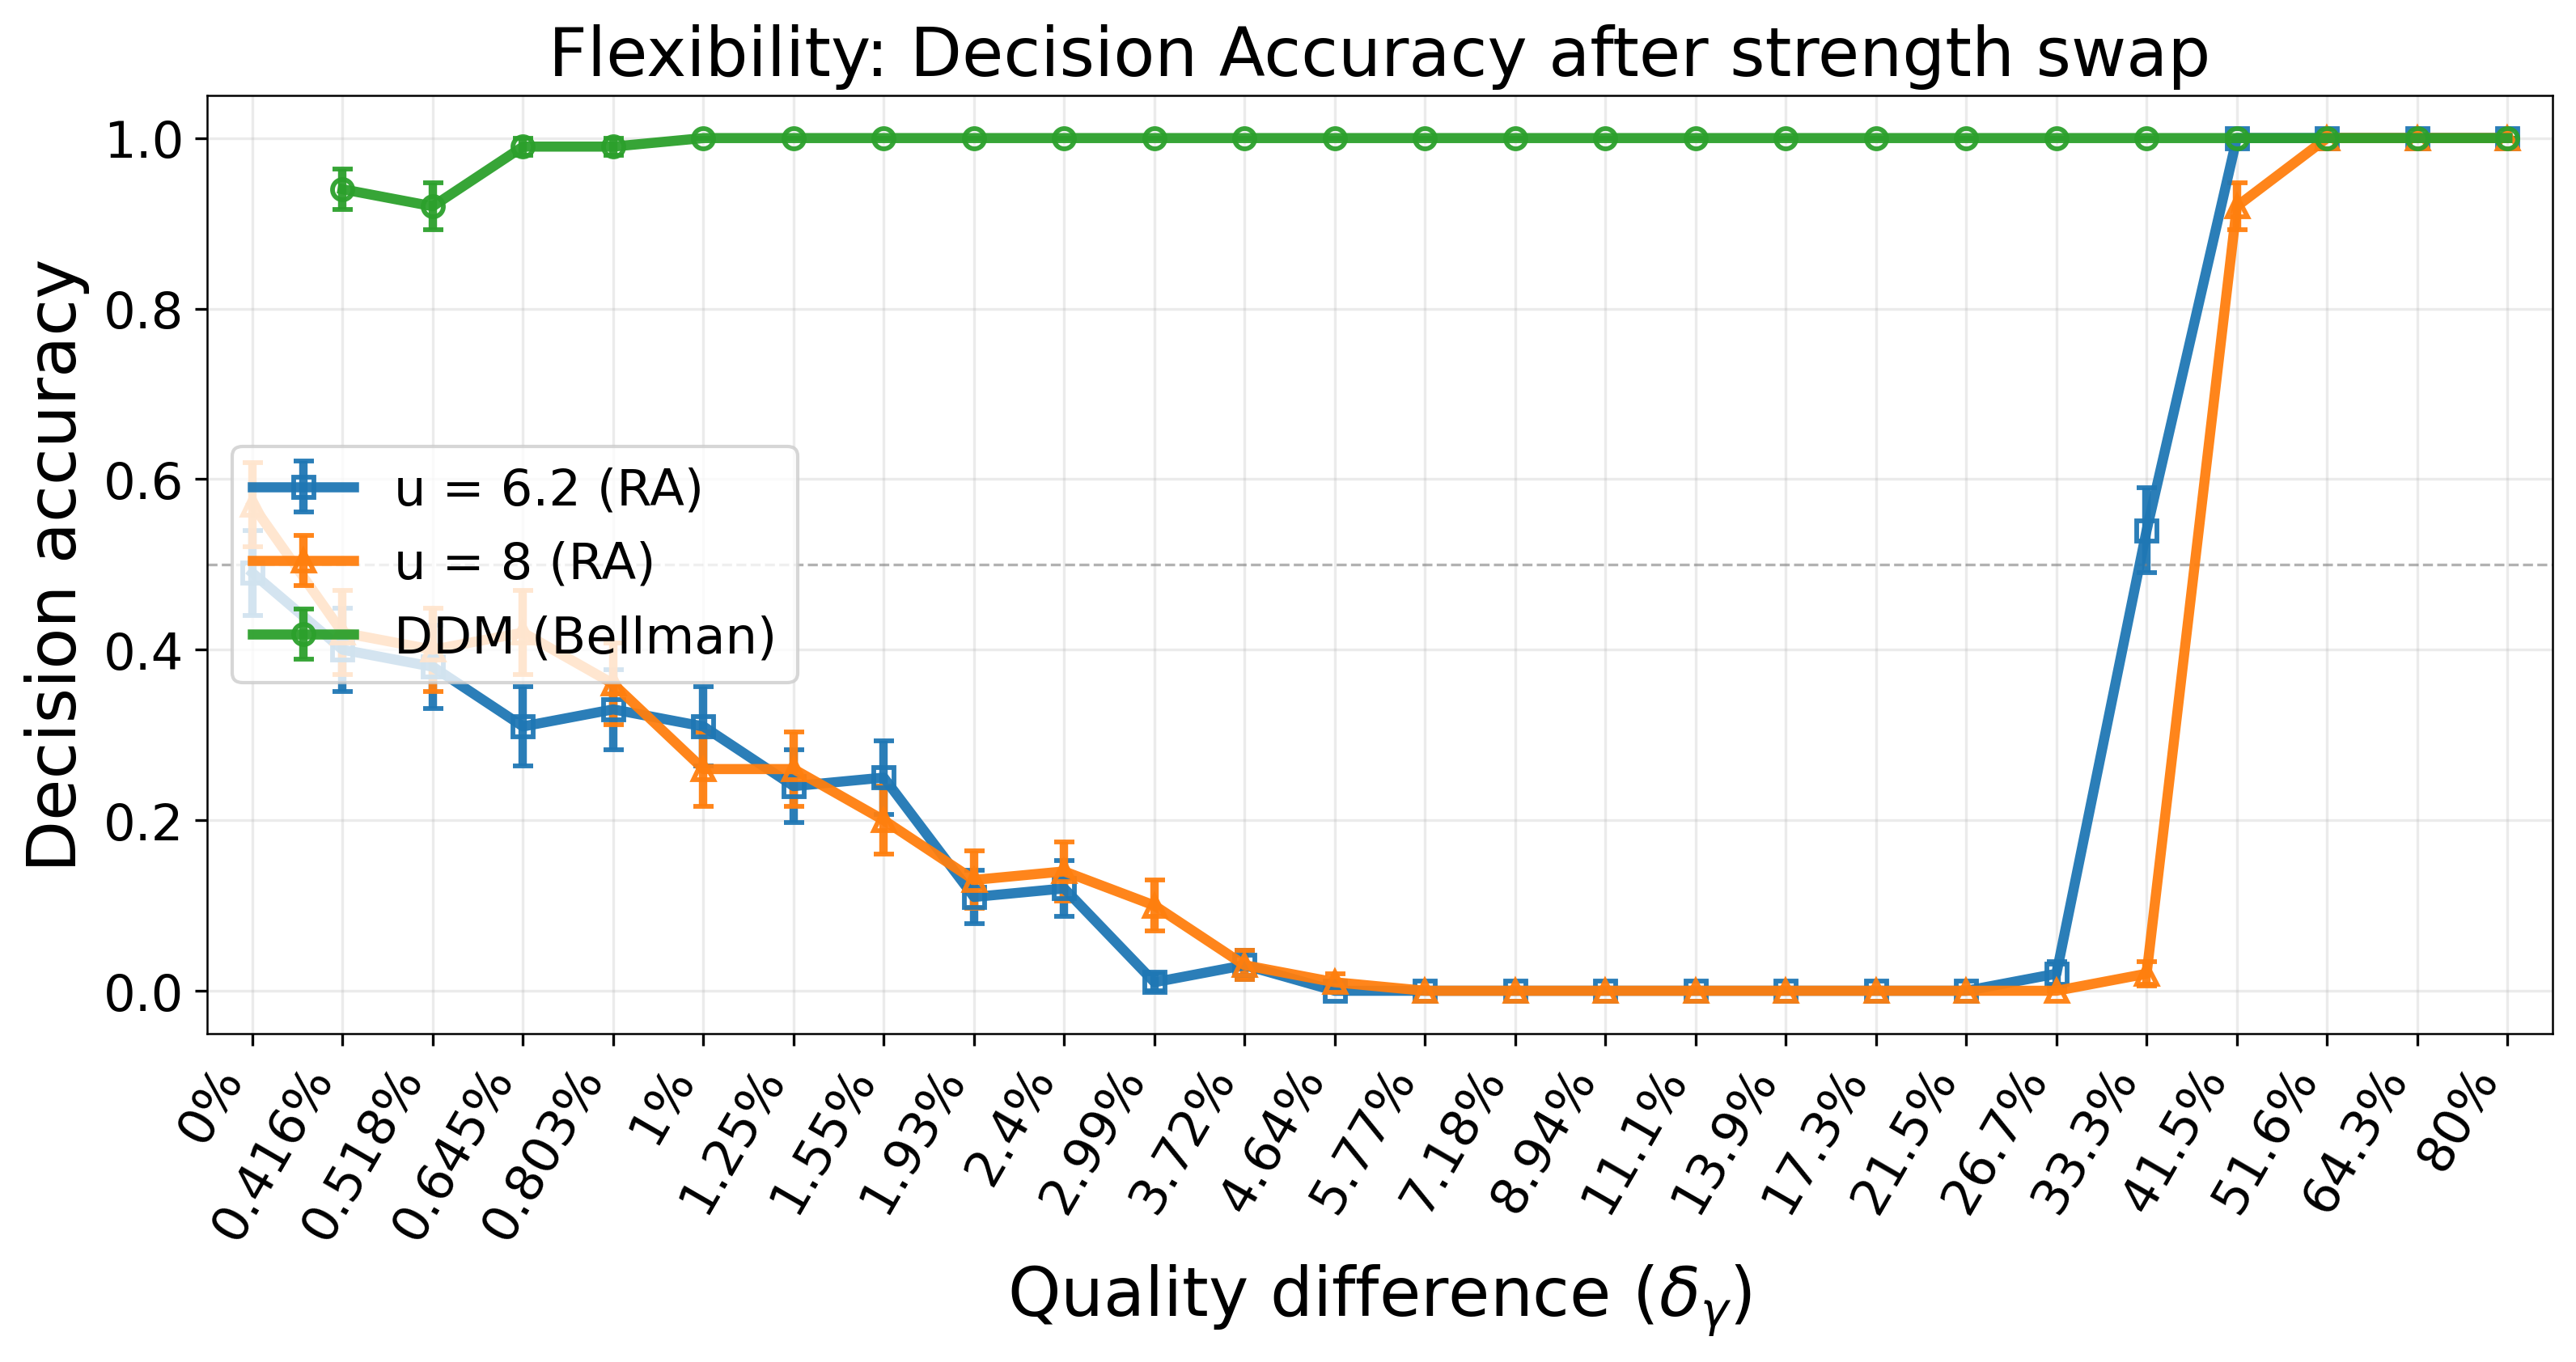

In [56]:
import csv
import io
import json
import math
import re
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# ── configuration ─────────────────────────────────────────────────────────────
# Three arms on a MATCHED sensory-noise realisation (the trial seed excludes the arm,
# so all three replay the same noise at the same (delta, replicate)):
#   ra_u6.2      ring attractor, near-critical gain u = 6.2 (kernel v = 0.5)
#   ra_u8        ring attractor, deep attractor u = 8
#   ddm_bellman  collapsing Bellman boundary, terminal halt_sprt
#
# static_0 is PINNED at 5.0 and sits at (+0.433, -0.25); static_1 = 5.0*(1 - delta)
# and sits at (+0.433, +0.25). After the agent commits, the arena EXCHANGES the two
# STRENGTHS at fixed positions, so the post-swap better option is static_1.
#   reversal        = terminal target differs from the committed target
#   post-swap acc.  = agent arrived at static_1, the post-swap better option
# delta = 0 exists for the RA arms only: with a zero gap the DDM cannot deduce |A|.

_RD_BASE   = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/flexibility_sweep")
_RD_ARMS   = [("ra_u6.2", "u = 6.2 (RA)"), ("ra_u8", "u = 8 (RA)"), ("ddm_bellman", "DDM (Bellman)")]
_RD_RADIUS = 0.05
_RD_TARGETS = {"static_0": (0.4330127018922193, -0.25),
               "static_1": (0.4330127018922193, +0.25)}


def _rd_score_run(run_zip):
    """Outcome of one run: what it committed to, where it ended, whether it reversed."""
    with zipfile.ZipFile(run_zip) as z:
        root = z.namelist()[0].split("/")[0]
        events = json.load(io.TextIOWrapper(z.open(f"{root}/events.json")))
        with z.open(f"{root}/movable_0.m#0_position.csv") as raw:
            rows = list(csv.DictReader(io.TextIOWrapper(raw)))
    bif = events.get("bifurcation_events") or []
    swaps = events.get("swap_events") or []
    last = rows[-1]
    x, y = float(last["pos_x"]), float(last["pos_y"])
    dist = {k: math.hypot(x - px, y - py) for k, (px, py) in _RD_TARGETS.items()}
    nearest = min(dist, key=dist.get)
    arrived = dist[nearest] <= _RD_RADIUS
    committed = bif[0]["target"].split(".")[0] if bif else None
    final = nearest if arrived else None
    return {
        "committed": committed,
        "final": final,
        "arrived": arrived,
        "reversed": bool(committed and final and final != committed),
        "n_bif": len(bif),
        "t_commit": bif[0]["tick"] if bif else None,
        "t_swap": swaps[0]["tick"] if swaps else None,
        "last_tick": int(last["tick"]),
    }


def _rd_scan():
    """Every run, as a flat list of dicts with arm and delta attached."""
    recs = []
    for arm, _ in _RD_ARMS:
        arm_dir = _RD_BASE / arm
        if not arm_dir.is_dir():
            continue
        for diff_dir in sorted(arm_dir.glob("diff_*pct"),
                               key=lambda p: float(re.search(r"diff_([\d.]+)pct", p.name).group(1))):
            delta = float(re.search(r"diff_([\d.]+)pct", diff_dir.name).group(1))
            for rep_dir in sorted(diff_dir.glob("replicate_*")):
                for run_zip in sorted((rep_dir / "config_folder_0").glob("run_*.zip")):
                    try:
                        rec = _rd_score_run(run_zip)
                    except Exception:
                        continue
                    rec["arm"] = arm
                    rec["delta"] = delta
                    recs.append(rec)
    return recs


def _rd_rate(recs, numer, denom):
    """Proportion with binomial standard error, over the subset `denom` selects."""
    sub = [r for r in recs if denom(r)]
    n = len(sub)
    if n == 0:
        return float("nan"), float("nan"), 0
    p = sum(1 for r in sub if numer(r)) / n
    return p, math.sqrt(p * (1 - p) / n), n


# ── scan ──────────────────────────────────────────────────────────────────────
_rd_recs = _rd_scan()

# ── plot: post-swap decision accuracy ─────────────────────────────────────────
markers    = ["s", "^", "o", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

fig, ax = plt.subplots(figsize=(10.5, 5.5), constrained_layout=True)

xticks   = sorted({r["delta"] for r in _rd_recs})
tick_pos = {v: i for i, v in enumerate(xticks)}

for idx, (arm, label) in enumerate(_RD_ARMS):
    deltas = sorted({r["delta"] for r in _rd_recs if r["arm"] == arm})
    if not deltas:
        continue
    stats = [_rd_rate([r for r in _rd_recs if r["arm"] == arm and r["delta"] == d],
                      lambda r: r["final"] == "static_1", lambda r: True)
             for d in deltas]
    ax.errorbar(
        [tick_pos[d] for d in deltas],
        [s[0] for s in stats], yerr=[s[1] for s in stats],
        marker=markers[idx % len(markers)],
        linestyle=linestyles[(idx // len(markers)) % len(linestyles)],
        linewidth=3, markersize=6,
        markerfacecolor="none", markeredgewidth=1.4,
        alpha=0.95, elinewidth=2.5, capsize=3, capthick=2.5,
        label=label,
    )

ax.set_xticks(range(len(xticks)))
ax.set_xticklabels([f"{x:.3g}%" for x in xticks], fontsize=7)
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
ax.set_xlim(-0.5, len(xticks) - 0.5)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.legend(loc="center left", fontsize=15)
ax.tick_params(axis="both", labelsize=15)
ax.set_title("Flexibility: Decision Accuracy after strength swap", fontsize=20)
ax.set_xlabel("Quality difference ($\\delta_{\\gamma}$)", fontsize=20)
ax.set_ylabel("Decision accuracy", fontsize=20)
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.grid(True, alpha=0.25)
plt.show()

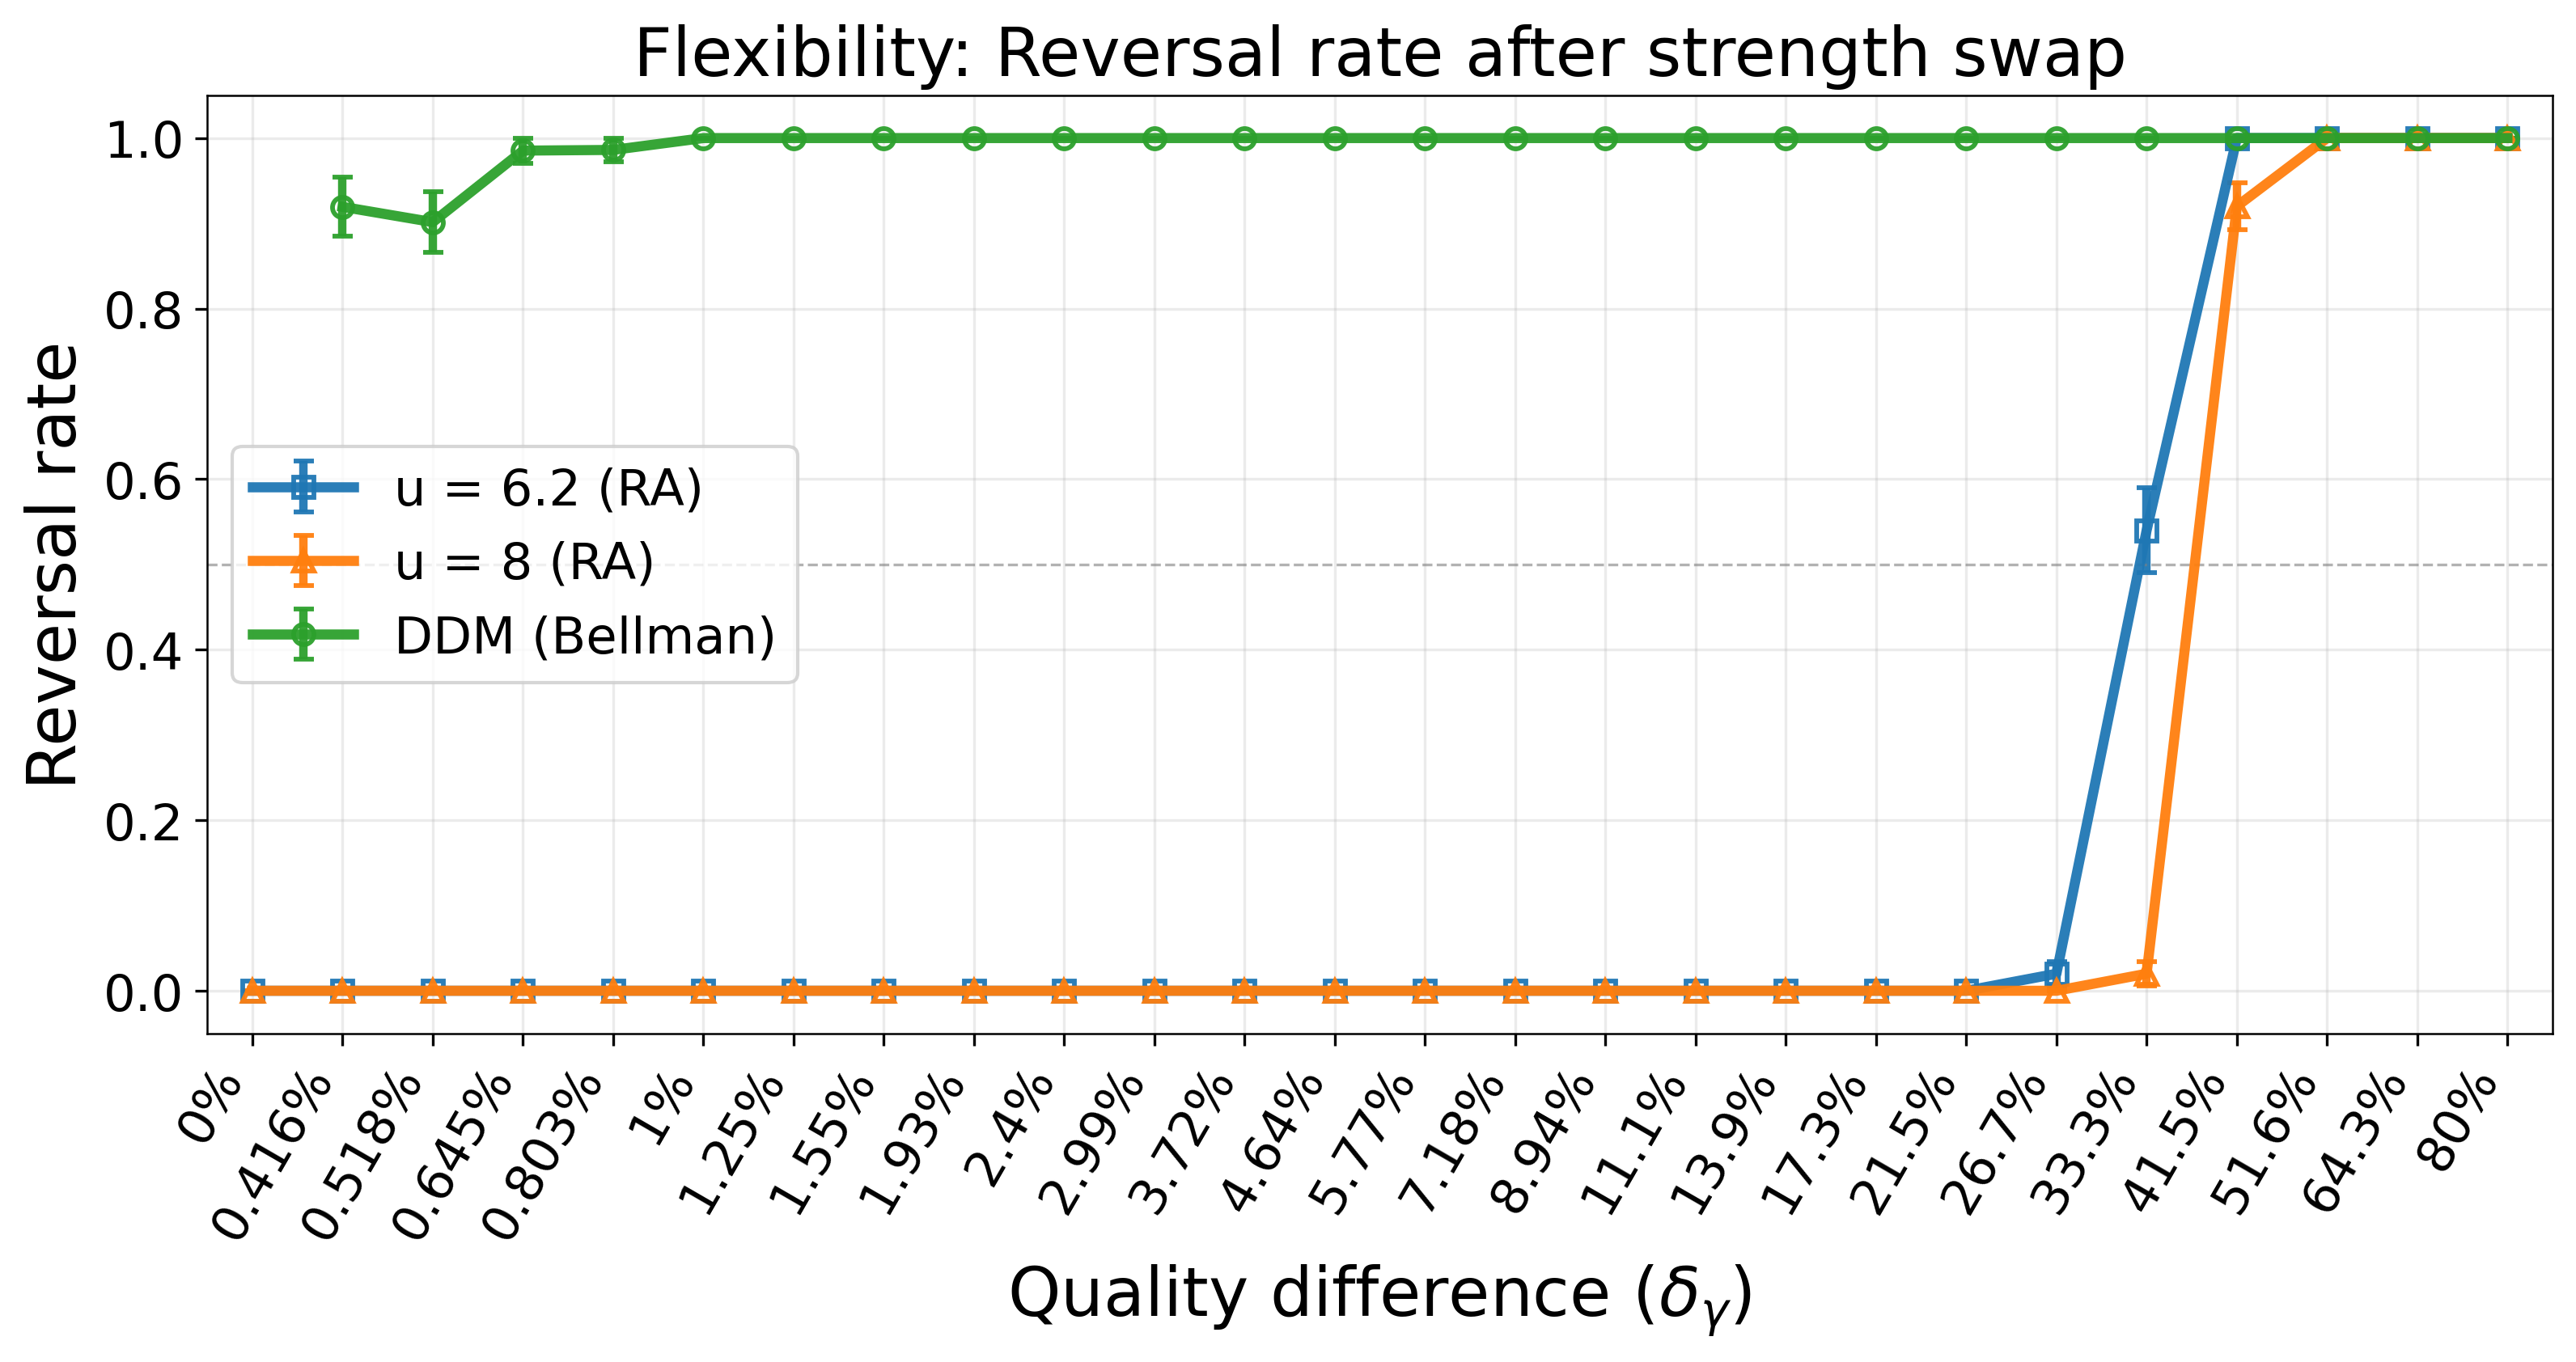

In [57]:
import csv
import io
import json
import math
import re
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# ── configuration ─────────────────────────────────────────────────────────────
# Three arms on a MATCHED sensory-noise realisation (the trial seed excludes the arm,
# so all three replay the same noise at the same (delta, replicate)):
#   ra_u6.2      ring attractor, near-critical gain u = 6.2 (kernel v = 0.5)
#   ra_u8        ring attractor, deep attractor u = 8
#   ddm_bellman  collapsing Bellman boundary, terminal halt_sprt
#
# static_0 is PINNED at 5.0 and sits at (+0.433, -0.25); static_1 = 5.0*(1 - delta)
# and sits at (+0.433, +0.25). After the agent commits, the arena EXCHANGES the two
# STRENGTHS at fixed positions, so the post-swap better option is static_1.
#   reversal        = terminal target differs from the committed target
#   post-swap acc.  = agent arrived at static_1, the post-swap better option
# delta = 0 exists for the RA arms only: with a zero gap the DDM cannot deduce |A|.

_RD_BASE   = Path("/home/sindiso/Documents/PhD/ring-attractor/seoul-data/beta-1/flexibility_sweep")
_RD_ARMS   = [("ra_u6.2", "u = 6.2 (RA)"), ("ra_u8", "u = 8 (RA)"), ("ddm_bellman", "DDM (Bellman)")]
_RD_RADIUS = 0.05
_RD_TARGETS = {"static_0": (0.4330127018922193, -0.25),
               "static_1": (0.4330127018922193, +0.25)}


def _rd_score_run(run_zip):
    """Outcome of one run: what it committed to, where it ended, whether it reversed."""
    with zipfile.ZipFile(run_zip) as z:
        root = z.namelist()[0].split("/")[0]
        events = json.load(io.TextIOWrapper(z.open(f"{root}/events.json")))
        with z.open(f"{root}/movable_0.m#0_position.csv") as raw:
            rows = list(csv.DictReader(io.TextIOWrapper(raw)))
    bif = events.get("bifurcation_events") or []
    swaps = events.get("swap_events") or []
    last = rows[-1]
    x, y = float(last["pos_x"]), float(last["pos_y"])
    dist = {k: math.hypot(x - px, y - py) for k, (px, py) in _RD_TARGETS.items()}
    nearest = min(dist, key=dist.get)
    arrived = dist[nearest] <= _RD_RADIUS
    committed = bif[0]["target"].split(".")[0] if bif else None
    final = nearest if arrived else None
    return {
        "committed": committed,
        "final": final,
        "arrived": arrived,
        "reversed": bool(committed and final and final != committed),
        "n_bif": len(bif),
        "t_commit": bif[0]["tick"] if bif else None,
        "t_swap": swaps[0]["tick"] if swaps else None,
        "last_tick": int(last["tick"]),
    }


def _rd_scan():
    """Every run, as a flat list of dicts with arm and delta attached."""
    recs = []
    for arm, _ in _RD_ARMS:
        arm_dir = _RD_BASE / arm
        if not arm_dir.is_dir():
            continue
        for diff_dir in sorted(arm_dir.glob("diff_*pct"),
                               key=lambda p: float(re.search(r"diff_([\d.]+)pct", p.name).group(1))):
            delta = float(re.search(r"diff_([\d.]+)pct", diff_dir.name).group(1))
            for rep_dir in sorted(diff_dir.glob("replicate_*")):
                for run_zip in sorted((rep_dir / "config_folder_0").glob("run_*.zip")):
                    try:
                        rec = _rd_score_run(run_zip)
                    except Exception:
                        continue
                    rec["arm"] = arm
                    rec["delta"] = delta
                    recs.append(rec)
    return recs


def _rd_rate(recs, numer, denom):
    """Proportion with binomial standard error, over the subset `denom` selects."""
    sub = [r for r in recs if denom(r)]
    n = len(sub)
    if n == 0:
        return float("nan"), float("nan"), 0
    p = sum(1 for r in sub if numer(r)) / n
    return p, math.sqrt(p * (1 - p) / n), n


# ── scan ──────────────────────────────────────────────────────────────────────
_rd_recs = _rd_scan()

# ── plot: reversal rate, among trials with something to reverse ───────────────
# Restricted to trials that committed to static_0, the PRE-swap better option. A
# trial that committed to static_1 was already heading for the post-swap better
# option, so it has nothing to reverse and would dilute the measure.
markers    = ["s", "^", "o", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

fig, ax = plt.subplots(figsize=(10.5, 5.5), constrained_layout=True)

xticks   = sorted({r["delta"] for r in _rd_recs})
tick_pos = {v: i for i, v in enumerate(xticks)}

for idx, (arm, label) in enumerate(_RD_ARMS):
    xs, ys, es = [], [], []
    for d in sorted({r["delta"] for r in _rd_recs if r["arm"] == arm}):
        g = [r for r in _rd_recs if r["arm"] == arm and r["delta"] == d]
        p, se, n0 = _rd_rate(g, lambda r: r["reversed"],
                             lambda r: r["committed"] == "static_0")
        if n0 == 0:
            continue
        xs.append(tick_pos[d]); ys.append(p); es.append(se)
    if not xs:
        continue
    ax.errorbar(
        xs, ys, yerr=es,
        marker=markers[idx % len(markers)],
        linestyle=linestyles[(idx // len(markers)) % len(linestyles)],
        linewidth=3, markersize=6,
        markerfacecolor="none", markeredgewidth=1.4,
        alpha=0.95, elinewidth=2.5, capsize=3, capthick=2.5,
        label=label,
    )

ax.set_xticks(range(len(xticks)))
ax.set_xticklabels([f"{x:.3g}%" for x in xticks], fontsize=7)
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
ax.set_xlim(-0.5, len(xticks) - 0.5)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.legend(loc="center left", fontsize=15)
ax.tick_params(axis="both", labelsize=15)
ax.set_title("Flexibility: Reversal rate after strength swap", fontsize=20)
ax.set_xlabel("Quality difference ($\\delta_{\\gamma}$)", fontsize=20)
ax.set_ylabel("Reversal rate", fontsize=20)
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.grid(True, alpha=0.25)
plt.show()

# Pareto in three levels

### Three δ_Q levels on one speed/accuracy plane, per RA kernel

The two campaigns now exist at **three quality differences** — δ_Q = 0.5 %, 1 %
and 2 % — each in its own tree under `ra_ddm_frontier_slices/` and
`ra_ddm_frontier_ddm_halt/`. They are separate campaigns, not re-labellings of
one: δ_Q enters the seed (`diff_bp`), the target strengths (`5.0` vs
`5.0·(1−δ_Q)`), the sensory noise (`white_rate = √2·ΔQ`) and the DDM's own
Bellman tables. Nothing is shared between the panels but the design grid.

The figure below draws each RA kernel shape *v* once, with all three δ_Q levels
overlaid: RA in orange (light → dark with δ_Q), the halted DDM's two families
in blue.

Two things to read off it.

**The DDM is δ_Q-invariant here, by construction.** The calibration fixes
`c = 2·ΔQ`, so the drift-to-noise ratio `A/c = ½` at *every* δ_Q, and with it
the whole Bellman frontier and the infinite-patience ceiling `Φ((A/c)·√(r₀/v))
= 0.929`. The three blue bundles coincide to within sampling noise — that
coincidence is the control, and it is what makes the RA's movement
interpretable rather than a rescaling artifact.

**The RA is not.** Its peak accuracy climbs monotonically with δ_Q
(0.970 → 0.986 → 0.993 at v = 0.2) and the gap to the Bellman DDM at matched
median time narrows with it (−0.028 → −0.011 → −0.006). The peak also drifts
slightly *down* in u as δ_Q grows at the flatter kernels. The ring is driven by
*absolute* strengths against a fixed nonlinearity, so halving ΔQ and its noise
together is not a neutral rescaling for it, the way it is for the DDM.

Two caveats on the grid. The 0.5 % and 2 % panels were run on the **wave-1
design only** (100 cells: Set R × 13 û levels + Set U × 12 absolute-u levels,
v ∈ {0.2, 0.3, 0.4, 0.5}), so this figure is restricted to those cells in all
three panels — matched cell-for-cell, since u*(v) does not depend on δ_Q. The
U-v2 cliff resolution, the U-v3 arc-length re-spacing and the v ∈ {0.6, 0.8}
kernels exist only at 1 %. And one 0.5 % cell (`R_v0.3_h0.65`) is short 366
replicates; the cell reports it.

In [ ]:
# Pareto in three levels — the RA and the halted DDM on one speed/accuracy
# plane at THREE quality differences (delta_Q = 0.5 %, 1 %, 2 %), one panel per
# RA kernel shape v. Self-contained: re-derives its own loader and helpers.
import math
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_SLICES = Path("../seoul-data/beta-1/ra_ddm_frontier_slices")
_HALT = Path("../seoul-data/beta-1/ra_ddm_frontier_ddm_halt")
#: delta_Q -> the panel's own tree suffix. Every panel is a SEPARATE campaign:
#: its own manifest, its own frontier-v1 seeds (diff_bp enters the seed), its
#: own Bellman tables. Nothing is shared between them but the design grid.
_PANELS = {0.005: "0.5", 0.010: "1.0", 0.020: "2.0"}
_V_GRID = [0.2, 0.3, 0.4, 0.5]          # wave-1 kernels — the grid all three share
_RA_COLORS = {0.005: "#F2A03D", 0.010: "#D55E00", 0.020: "#7F2704"}
_DDM_COLORS = {0.005: "#9ECAE1", 0.010: "#3182BD", 0.020: "#08306B"}
#: c = 2*dQ by calibration, so A/c = 1/2 at EVERY delta_Q: the DDM's
#: infinite-patience ceiling is one number for all three panels.
_CEILING = NormalDist().cdf(0.5 * math.sqrt(0.5 * math.cos(math.radians(30)) / 0.05))


def _load(stem):
    df = pd.read_parquet(Path(stem).with_suffix(".parquet"))
    for col in ("correct", "decided"):
        df[col] = df[col].astype(bool)
    return df


def _wilson_bounds(k, n, z=1.959964):
    p = k / n
    den = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return max(0.0, centre - half), min(1.0, centre + half)


def _group_stats(df, key):
    rows = []
    for ident, g in df.groupby(key, sort=False):
        arr = g.loc[g["decided"], "t_arrival_s"].astype(float)
        lo, hi = _wilson_bounds(int(g["correct"].sum()), len(g))
        rows.append({key: ident, "n": len(g), "acc_all": g["correct"].mean(),
                     "acc_lo": lo, "acc_hi": hi,
                     "median_t": arr.median() if len(arr) else float("nan"),
                     "decided_frac": g["decided"].mean()})
    return pd.DataFrame(rows)


ra, ddm = {}, {}
for dq, tag in _PANELS.items():
    # Wave-1 cells only (cell_id R_* / U_*): the 0.5 % and 2 % panels were run
    # on the wave-1 design, so this is the grid on which the three are matched
    # cell-for-cell. u*(v) is independent of delta_Q, so the u values agree
    # exactly across panels.
    r = _load(_SLICES / f"ra_ddm_frontier_slices_{tag}" / "trials")
    ra[dq] = r[r["cell_id"].str.match(r"^[RU]_")].copy()
    ddm[dq] = _load(_HALT / f"ra_ddm_frontier_ddm_halt_{tag}" / "ddm_trials")

short = pd.concat([_group_stats(ra[dq], "cell_id").assign(delta_Q=dq)
                   for dq in _PANELS])
short = short[short["n"] < 1000]
print("completeness of the RA wave-1 grid (100 cells x 1000 runs per panel):")
if len(short):
    for _i, r in short.iterrows():
        print(f"  δ_Q = {r['delta_Q']:.1%}  {r['cell_id']:>14}: n = {int(r['n'])}"
              f" — {1000 - int(r['n'])} replicates missing, resubmit to fill")
else:
    print("  all three panels COMPLETE")

fig, axes = plt.subplots(2, 2, figsize=(15.5, 10.5), sharex=True, sharey=True,
                         constrained_layout=True)
summary = []
for ax, v in zip(axes.ravel(), _V_GRID):
    ax.axhline(_CEILING, color="crimson", ls="--", lw=0.9, zorder=1)
    ax.axhline(0.5, color="gray", ls=":", lw=1, zorder=1)
    for dq in _PANELS:
        dcol, rcol = _DDM_COLORS[dq], _RA_COLORS[dq]
        # ---- the DDM's two halted families: identical in every v panel -----
        for variant, ls, lw, alpha, marker in (("bellman", "--", 1.6, 1.0, "o"),
                                               ("static", ":", 1.0, 0.55, None)):
            fd = ddm[dq][ddm[dq]["variant"] == variant]
            st = _group_stats(fd, "point_id").sort_values("median_t")
            ax.plot(st["median_t"], st["acc_all"], ls, color=dcol, lw=lw,
                    alpha=alpha, zorder=3)
            if marker:
                ax.plot(st["median_t"], st["acc_all"], marker, ms=4,
                        mfc="white", mec=dcol, mew=1.1, zorder=4)
        # ---- this kernel's RA sweep, connected in u order ------------------
        gv = ra[dq][np.isclose(ra[dq]["v"].astype(float), v)]
        st = _group_stats(gv, "cell_id").set_index("cell_id")
        st["u"] = gv.groupby("cell_id")["u"].first().astype(float)
        st = st.sort_values("u").dropna(subset=["median_t"])
        ax.errorbar(st["median_t"], st["acc_all"],
                    yerr=[st["acc_all"] - st["acc_lo"],
                          st["acc_hi"] - st["acc_all"]],
                    fmt="-s", ms=3.8, color=rcol, lw=1.4, elinewidth=0.6,
                    capsize=1.5, alpha=0.95, zorder=5)
        pk = st.loc[st["acc_all"].idxmax()]
        ax.plot(pk["median_t"], pk["acc_all"], "*", ms=14, mfc="none",
                mec=rcol, mew=1.6, zorder=6)
        # peak read-out in the empty lower-right band — annotating the stars
        # in place is unreadable, the three peaks sit on top of one another
        ax.text(0.985, 0.085 + 0.062 * (2 - list(_PANELS).index(dq)),
                f"δ_Q {dq:.1%}:  peak {pk['acc_all']:.3f} at u = {pk['u']:.3g}, "
                f"{pk['median_t']:.1f} s", transform=ax.transAxes, ha="right",
                va="bottom", fontsize=8, color=rcol, fontweight="bold")
        bel = _group_stats(ddm[dq][ddm[dq]["variant"] == "bellman"],
                           "point_id").sort_values("median_t")
        summary.append({
            "v": v, "delta_Q": dq, "u_peak": pk["u"], "n": int(pk["n"]),
            "RA_acc": pk["acc_all"], "RA_lo": pk["acc_lo"], "RA_hi": pk["acc_hi"],
            "RA_median_t": pk["median_t"],
            "DDM_acc_at_t": float(np.interp(pk["median_t"], bel["median_t"],
                                            bel["acc_all"])),
            "RA_t_at_DDM_acc": float(np.interp(
                pk["acc_all"], bel["acc_all"], bel["median_t"]))})
    ax.set_title(f"kernel v = {v:g}", fontsize=11)
    ax.set_ylim(0.47, 1.045)
    ax.grid(alpha=0.25)

handles = ([plt.Line2D([], [], color=_RA_COLORS[d], marker="s", ms=4, lw=1.4,
                       label=f"RA, δ_Q = {d:.1%} (absolute + relative u)")
            for d in _PANELS]
           + [plt.Line2D([], [], color=_DDM_COLORS[d], ls="--", marker="o",
                         ms=4, mfc="white", lw=1.6,
                         label=f"DDM Bellman (c_e), halt, δ_Q = {d:.1%}")
              for d in _PANELS]
           + [plt.Line2D([], [], color=_DDM_COLORS[0.010], ls=":", lw=1.0,
                         alpha=0.55, label="DDM static (b), halt — all three δ_Q"),
              plt.Line2D([], [], color="crimson", ls="--", lw=0.9,
                         label=f"infinite-patience ceiling {_CEILING:.3f} "
                               "(A/c = ½ at every δ_Q)"),
              plt.Line2D([], [], color="gray", ls=":", lw=1, label="chance"),
              plt.Line2D([], [], color="k", marker="*", ms=10, mfc="none",
                         ls="none", label="RA peak accuracy for that δ_Q")])
fig.legend(handles=handles, fontsize=8, loc="outside lower center", ncol=4)
for ax in axes[-1]:
    ax.set_xlabel("median arrival time (s)")
for ax in axes[:, 0]:
    ax.set_ylabel("accuracy (acc_all)")
fig.suptitle(
    "Pareto in three levels — the RA and the halted DDM on one speed/accuracy "
    "plane at δ_Q = 0.5 %, 1 % and 2 % (Δθ = 60°, frontier-v1, n = 1000 per "
    "point)\none panel per RA kernel shape v; RA connected in u order over the "
    "shared wave-1 grid (Set R + Set U), Wilson 95 % bars.  The DDM's two "
    "families are δ_Q-INVARIANT by the c = 2ΔQ calibration\n(A/c = ½ at every "
    "δ_Q, so all three blue bundles and the ceiling coincide); the RA's "
    "frontier is not — its peak climbs and its collapse sharpens with δ_Q",
    fontsize=9.5)
plt.show()

s = pd.DataFrame(summary)
s["RA − DDM at matched time"] = s["RA_acc"] - s["DDM_acc_at_t"]
s["DDM speed-up at matched acc"] = s["RA_median_t"] - s["RA_t_at_DDM_acc"]
print("RA peak vs the Bellman DDM, per kernel and quality difference:")
print(s[["v", "delta_Q", "u_peak", "n", "RA_acc", "RA_lo", "RA_hi",
         "RA_median_t", "DDM_acc_at_t", "RA − DDM at matched time",
         "DDM speed-up at matched acc"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))


### Fixed noise: the same three levels with SNR actually moving (`qd_sweep_fixed_noise`)

The section above is the **coupled-noise** campaign: `white_rate = √2·ΔQ`
tracked δ_Q, so A/c = ½ everywhere and the DDM's invariance across panels was
the control. This rerun (spec `qd-sweep-fixed-noise-experiment.md`) **pins the
noise** — `white_rate = 0.07071068`, evidence channel c = 0.1, asserted per
config and measured from the logs (R-1: pooled ĉ = 0.0998, drift ladder
0.0255/0.0475/0.1009) — so actual δ_Q ∈ {0.5, 1, 2} % now moves SNR for real:
A/c = 0.25/0.5/1.0, k = 5/10/20. Arm A is the full RA (u, v) surface
(u ∈ {0, 2…35}, v ∈ {0.1…1.0}, absolute u only); Arm B freezes the DDM
controllers at a *design* δ_Q (12 Bellman c_e via `A_expected` + the two
static b\*) and evaluates every freeze at every *actual* δ_Q. n = 100/cell
(per-cell CIs ≈ ±0.09), `n_sub = 1` (1 s rt resolution), halt-at-midpoint.
All §8 gates PASS — including the u = 0 ladder 0.700 < 0.870 < 0.950 across
δ_Q, the direct proof the old constant-SNR pathology is gone.

Three reads off the figure:

**The old control now moves.** The forced-choice-at-arrival bound
Φ((A/c)·√(r₀/v)) is 0.769 / 0.929 / 0.998 per panel (it was one number, 0.929,
for all three under the coupling), and the DDM families separate accordingly.
Both architectures may *exceed* the dashed bound by paying time — the halt
policy buys post-arrival integration.

**Which architecture wins flips with SNR.** At 0.5 % the RA's cross-(u, v)
Pareto front clears the entire frozen-DDM family (peak 0.910 at `v 0.2, u 8`
vs 0.890 for the best clairvoyant, c_e = 300) — the patient DDM end is
crippled by 60 s-budget censoring at k = 5. At 1 % and 2 % the clairvoyant
DDM reaches the same top accuracy 1.4×/2× sooner than the RA front
(12.0 s vs 17.3 s; 9.6 s vs 19.5 s).

**Misspecification (§5, honestly).** The conservative branch behaves as
pre-registered: actual > design costs no accuracy (mean paired Δacc −0.006)
and +1.3 s of time. The predicted *bold collapse* under actual < design does
**not** appear — at fixed c_e the Bellman plateau *rises* with believed SNR
(z_halt at c_e = 3: 0.019 → 0.037 → 0.065 across designs), so an
overconfident freeze is threshold-conservative, not bold; the real
off-diagonal cost is **censoring of the patient end**, and at c_e ≥ 3000 the
same-c_e clairvoyant at k = 5 censors so badly that the off-design freezes
beat their own diagonal (+0.18 at c_e = 30000). §5.3's boldness ordering
does not materialize. Full matrices, regret CIs and the analytic static
overlays live in `analysis/` next to the data.


In [ ]:
# Pareto in three levels, FIXED NOISE (qd_sweep_fixed_noise): the full RA
# (u, v) surface and the frozen-DDM controller families on one speed/accuracy
# plane at three ACTUAL quality differences. Unlike the section above, the
# noise is pinned (white_rate = 0.07071068, evidence channel c = 0.1) so SNR
# genuinely moves across panels: A/c = 0.25 / 0.5 / 1.0, k = 5 / 10 / 20 —
# and with it the DDM's infinite-patience ceiling, which was one number for
# all three panels under the old coupling. Self-contained.
import math
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_ROOT = Path("../seoul-data/beta-1/ra_ddm_qd_sweep_fixed_noise/qd_sweep_fixed_noise")
_C = 0.1                                     # evidence-channel noise, pinned
_ACTUALS = [50, 100, 200]                    # actual δ_Q in basis points
_A = {bp: 5.0 * bp / 10000.0 for bp in _ACTUALS}
_T_EVIDENCE = (0.5 * math.cos(math.radians(30))) / 0.05   # r0/v = 8.66 s
_RA_CMAP = plt.get_cmap("YlOrBr")
_DESIGN_COLORS = {50: "#9ECAE1", 100: "#3182BD", 200: "#08306B"}
_VARIANT_MARKERS = {"bellman": "o", "static-cost": "D", "static-rr": "^"}

ra = pd.read_csv(_ROOT / "ra_cells.csv")
ddm = pd.read_csv(_ROOT / "ddm_points.csv")
regret = pd.read_csv(_ROOT / "analysis" / "regret.csv")


def _pareto_front(points):
    """Non-dominated set on (median arrival ASC, acc_all DESC)."""
    out, best = [], -1.0
    for t, a, cid in sorted(points):
        if a > best:
            out.append((t, a, cid))
            best = a
    return out


fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.6), sharey=True,
                         constrained_layout=True)
summary = []
for ax, bp in zip(axes, _ACTUALS):
    rsub = ra[(ra["actual_bp"] == bp) & ra["median_arrival_s"].notna()]
    for v, g in rsub.groupby("v"):
        g = g.sort_values("u")
        ax.plot(g["median_arrival_s"], g["acc_all"], "-", lw=0.7, alpha=0.45,
                color=_RA_CMAP(0.3 + 0.65 * (v - 0.1) / 0.9), zorder=1)
    front = _pareto_front(
        (r.median_arrival_s, r.acc_all, r.cell_id) for r in rsub.itertuples())
    ax.plot([p[0] for p in front], [p[1] for p in front], "-", lw=2.4,
            color="#D55E00", zorder=4,
            label="RA Pareto front (over all u, v)")

    dsub = ddm[ddm["actual_bp"] == bp]
    for design, g in dsub.groupby("design_bp"):
        clair = int(design) == bp
        col = _DESIGN_COLORS[int(design)]
        bell = g[g["variant"] == "bellman"].sort_values("median_arrival_s")
        ax.plot(bell["median_arrival_s"], bell["acc_all"], "-", lw=1.6 if clair
                else 0.9, alpha=1.0 if clair else 0.65, color=col, zorder=3)
        for _i, r in g.iterrows():
            ax.plot(r["median_arrival_s"], r["acc_all"],
                    _VARIANT_MARKERS[r["variant"]], ms=7 if clair else 5,
                    mfc=col if clair else "none", mec=col,
                    alpha=1.0 if clair else 0.7, zorder=5 if clair else 3)

    ceiling = NormalDist().cdf(_A[bp] / _C * math.sqrt(_T_EVIDENCE))
    ax.axhline(ceiling, color="gray", lw=1.0, ls="--", zorder=0)
    ax.axhline(0.5, color="gray", lw=0.6, ls=":", zorder=0)
    ax.set_xlabel("median arrival time (s)")
    ax.set_title(f"actual δ_Q = {bp/100:.1f} %   (A/c = {_A[bp]/_C:g}, "
                 f"k = {2*_A[bp]/_C**2:.0f}; ceiling {ceiling:.3f})")
    ax.set_xlim(8.5, 48)

    peak = rsub.loc[rsub["acc_all"].idxmax()]
    diag = dsub[dsub["design_bp"] == bp]
    best_diag = diag.loc[diag["acc_all"].idxmax()]
    summary.append({
        "actual_bp": bp, "ceiling": ceiling,
        "ra_peak_cell": peak["cell_id"], "ra_peak_acc": peak["acc_all"],
        "ra_peak_t": peak["median_arrival_s"],
        "best_clairvoyant": best_diag["point_id"],
        "best_clairvoyant_acc": best_diag["acc_all"],
        "best_clairvoyant_t": best_diag["median_arrival_s"]})

axes[0].set_ylabel("accuracy (all trials; censored = incorrect)")
axes[0].set_ylim(0.35, 1.02)
axes[0].plot([], [], "o", mfc=_DESIGN_COLORS[100], mec=_DESIGN_COLORS[100],
             label="DDM clairvoyant (design = actual)")
axes[0].plot([], [], "o", mfc="none", mec=_DESIGN_COLORS[100],
             label="DDM frozen off-design (light→dark: design 50/100/200 bp)")
axes[0].plot([], [], "D", mfc="none", mec="gray", label="static b*_cost")
axes[0].plot([], [], "^", mfc="none", mec="gray", label="static b*_RR")
axes[0].plot([], [], "--", color="gray", label="forced-choice-at-arrival bound Φ((A/c)√(r₀/v))")
axes[0].legend(fontsize=7, loc="lower right")
fig.suptitle("Pareto in three levels — FIXED noise (c = 0.1): RA (u, v) surface vs frozen-DDM"
             " families; halt-at-midpoint policy, n = 100/cell", fontsize=11)
plt.show()

print(f"{'actual':>7} {'ceiling':>8} {'RA peak':>22} {'acc':>6} {'t(s)':>6} "
      f"{'best clairvoyant DDM':>22} {'acc':>6} {'t(s)':>6}")
for s in summary:
    print(f"{s['actual_bp']:>6}bp {s['ceiling']:>8.3f} {s['ra_peak_cell']:>22} "
          f"{s['ra_peak_acc']:>6.3f} {s['ra_peak_t']:>6.1f} "
          f"{s['best_clairvoyant']:>22} {s['best_clairvoyant_acc']:>6.3f} "
          f"{s['best_clairvoyant_t']:>6.1f}")

# §5.1 asymmetry, straight from the paired regret table: actual < design
# (world weaker than believed -> frozen thresholds too bold) must cost
# accuracy; actual > design is merely conservative (slower, accuracy intact).
off = regret[regret["design_bp"] != regret["actual_bp"]]
bold = off[off["actual_bp"] < off["design_bp"]]     # overconfident freeze
consv = off[off["actual_bp"] > off["design_bp"]]    # conservative freeze
print("\n§5.1 asymmetry (paired Δacc vs the same-actual clairvoyant diagonal):")
print(f"  actual < design (too bold):     mean Δacc = {bold['d_acc'].mean():+.4f} "
      f"over {len(bold)} cells (worst {bold['d_acc'].min():+.3f})")
print(f"  actual > design (conservative): mean Δacc = {consv['d_acc'].mean():+.4f} "
      f"over {len(consv)} cells (worst {consv['d_acc'].min():+.3f}); "
      f"mean Δarrival = {consv['d_arrival_s'].mean():+.2f} s")

# §5.3 boldness ordering under actual < design, Bellman family only.
b = bold[bold["controller"].str.startswith("bellman")].copy()
b["ce"] = b["controller"].str.split("_").str[1].astype(float)
print("\n§5.3 regret by boldness (Bellman, actual < design):")
for ce, g in b.groupby("ce"):
    print(f"  c_e = {ce:<7g} mean Δacc = {g['d_acc'].mean():+.4f}")

clipped = ra[(ra["median_arrival_s"] > 48) | (ra["acc_all"] < 0.35)]
print(f"\n({len(clipped)} RA cells lie outside the frame — slow or near-chance,"
      " every one Pareto-dominated; the full surface is in the §9 heatmaps)")
